In [ ]:
# ============================================================
# FIXED-CANDIDATE FULL CATALOG REBUILD
# ------------------------------------------------------------
# Frozen branch:
#   source: rho_eff ~ (1/r^2) d/dr [ r * V_bar^2 ]
#   screened field equation
#   fixed Rs = 1.5
#   shape map: V/V_flat = U/U_inf
#
# Frozen amplitude law:
#   U(r_t) = 0.6 U_inf
#   V_flat^2 = C * [r_t u(r_t)]^alpha * [Vbar^2(r_t)]^beta
#
# with fixed constants:
#   C     = 164.0
#   alpha = 0.175
#   beta  = 0.55
#
# No fitting in this script.
# ============================================================

import os, re, glob, zipfile, warnings
import numpy as np
import pandas as pd

from scipy.integrate import cumulative_trapezoid
from scipy.interpolate import interp1d, PchipInterpolator
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import spsolve

warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=UserWarning)

# ------------------------------------------------------------
# PATHS
# ------------------------------------------------------------

WORKDIR = "/content/mts_realdata_workspace_v2"
ROTMOD_DIR = os.path.join(WORKDIR, "ROTMOD_LTG_4")
OUTDIR = os.path.join(WORKDIR, "mts_fixed_candidate_catalog_rebuild")
os.makedirs(OUTDIR, exist_ok=True)

ZIP_CANDIDATES = [
    "/content/Rotmod_LTG (4).zip",
    "/content/Rotmod_LTG.zip",
    os.path.join(WORKDIR, "Rotmod_LTG (4).zip"),
    os.path.join(WORKDIR, "Rotmod_LTG.zip"),
]

# ------------------------------------------------------------
# FIXED MODEL SETTINGS
# ------------------------------------------------------------

R_MIN = 1.0e-3
R_MAX = 55.0
N_R   = 700

Rs_fixed = 1.5
m_inf = 0.02
A_src = 0.10

UPS_DISK = 1.0
UPS_BUL  = 1.0

R_CORE = 0.5
SMOOTH_WIN = 9
SOURCE_FLOOR = 1.0e-6

F_FRAC = 0.60
C_AMP  = 164.0
ALPHA  = 0.175
BETA   = 0.55

# ------------------------------------------------------------
# HELPERS
# ------------------------------------------------------------

def display_name_from_path(path):
    base = os.path.basename(path)
    base = re.sub(r"_rotmod\.dat$", "", base, flags=re.IGNORECASE)
    base = re.sub(r"\.dat$", "", base, flags=re.IGNORECASE)
    return base

def moving_average(y, win=7):
    y = np.asarray(y, float)
    if win <= 1:
        return y.copy()
    if win % 2 == 0:
        win += 1
    pad = win // 2
    yp = np.pad(y, (pad, pad), mode="edge")
    ker = np.ones(win) / win
    return np.convolve(yp, ker, mode="valid")

def safe_rmse(a, b):
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    m = np.isfinite(a) & np.isfinite(b)
    if np.sum(m) == 0:
        return np.nan
    return float(np.sqrt(np.mean((a[m] - b[m]) ** 2)))

def safe_mae(a, b):
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    m = np.isfinite(a) & np.isfinite(b)
    if np.sum(m) == 0:
        return np.nan
    return float(np.mean(np.abs(a[m] - b[m])))

def bootstrap_rotmods():
    rotmod_files = sorted(glob.glob(os.path.join(ROTMOD_DIR, "*.dat")))
    if rotmod_files:
        return rotmod_files

    zip_path = None
    for zp in ZIP_CANDIDATES:
        if os.path.exists(zp):
            zip_path = zp
            break

    if zip_path is None:
        raise FileNotFoundError("No LTG rotmod directory or zip archive found.")

    print(f"Auto-extracting LTG rotmods from: {zip_path}")
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(ROTMOD_DIR)

    rotmod_files = sorted(glob.glob(os.path.join(ROTMOD_DIR, "*.dat")))
    if not rotmod_files:
        raise FileNotFoundError(f"No .dat files found in {ROTMOD_DIR} after extraction.")
    return rotmod_files

def read_rotmod_file(path):
    rows = []
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            s = line.strip()
            if not s or s.startswith("#") or s.startswith("%") or s.startswith("//"):
                continue
            parts = re.split(r"\s+", s)
            vals = []
            for p in parts:
                try:
                    vals.append(float(p))
                except Exception:
                    pass
            if len(vals) >= 2:
                rows.append(vals)

    if not rows:
        raise ValueError(f"No numeric rows found in {path}")

    max_cols = max(len(r) for r in rows)
    arr = np.full((len(rows), max_cols), np.nan)
    for i, row in enumerate(rows):
        arr[i, :len(row)] = row

    r = arr[:, 0]
    vobs = arr[:, 1]
    ev = arr[:, 2] if arr.shape[1] >= 3 else np.full_like(vobs, 5.0)
    vgas  = arr[:, 3] if arr.shape[1] >= 4 else np.zeros_like(vobs)
    vdisk = arr[:, 4] if arr.shape[1] >= 5 else np.zeros_like(vobs)
    vbul  = arr[:, 5] if arr.shape[1] >= 6 else np.zeros_like(vobs)

    mask = np.isfinite(r) & np.isfinite(vobs) & np.isfinite(ev)
    mask &= np.isfinite(vgas) & np.isfinite(vdisk) & np.isfinite(vbul)
    mask &= (r > 0) & (ev > 0)

    if np.sum(mask) == 0:
        raise ValueError("No valid points after masking.")

    order = np.argsort(r[mask])
    return {
        "r": r[mask][order],
        "vobs": vobs[mask][order],
        "ev": ev[mask][order],
        "vgas": vgas[mask][order],
        "vdisk": vdisk[mask][order],
        "vbul": vbul[mask][order],
    }

def vbar2_from_rot(rot):
    return (
        rot["vgas"] * np.abs(rot["vgas"])
        + UPS_DISK * rot["vdisk"] * np.abs(rot["vdisk"])
        + UPS_BUL  * rot["vbul"]  * np.abs(rot["vbul"])
    )

def radius_at_fraction(r, y, frac):
    y = np.asarray(y, float)
    r = np.asarray(r, float)
    ymax = np.nanmax(y)
    if not np.isfinite(ymax) or ymax <= 0:
        return np.nan
    target = frac * ymax
    idx = np.where(y >= target)[0]
    if len(idx) == 0:
        return np.nan
    return float(r[idx[0]])

def build_mass_derivative_source(rot):
    r = rot["r"]
    vbar2 = np.maximum(vbar2_from_rot(rot), 0.0)

    mbar_proxy = np.sqrt(r**2 + R_CORE**2) * vbar2
    dmbar_dr = np.gradient(mbar_proxy, r)
    rho_eff = dmbar_dr / np.maximum(r**2 + R_CORE**2, 1.0e-8)

    rho_eff = moving_average(rho_eff, win=SMOOTH_WIN)
    rho_eff = np.maximum(rho_eff, 0.0)

    if np.max(rho_eff) <= 0:
        raise RuntimeError("Source proxy is identically zero.")

    rho_eff = rho_eff / np.max(rho_eff)
    rho_eff = np.maximum(rho_eff, SOURCE_FLOOR)
    return {"r": r, "rho_eff": rho_eff}

def solve_canonical_field_fd(r_eval, rho_r, rho_vals, Rs, m_inf, A_src):
    r_eval = np.asarray(r_eval, float)
    rmax = max(R_MAX, float(np.max(r_eval)) * 1.15)
    r = np.linspace(R_MIN, rmax, N_R)
    dr = r[1] - r[0]

    rho_pchip = PchipInterpolator(rho_r, rho_vals, extrapolate=False)
    rho0 = float(rho_vals[0])

    rho = np.empty_like(r)
    left = r <= rho_r[0]
    mid = (r > rho_r[0]) & (r < rho_r[-1])
    right = r >= rho_r[-1]
    rho[left] = rho0
    rho[mid] = rho_pchip(r[mid])
    rho[right] = 0.0
    rho = np.maximum(rho, 0.0)

    A = lil_matrix((N_R, N_R), dtype=float)
    b = np.zeros(N_R, dtype=float)

    A[0, 0] = 1.0
    A[0, 1] = -1.0
    b[0] = 0.0

    for i in range(1, N_R - 1):
        ri = r[i]
        rip = r[i] + 0.5 * dr
        rim = r[i] - 0.5 * dr

        c_minus = rim**2 / (ri**2 * dr**2)
        c_plus  = rip**2 / (ri**2 * dr**2)
        c0 = -(c_minus + c_plus) - 1.0 / (Rs**2)

        A[i, i - 1] = c_minus
        A[i, i]     = c0
        A[i, i + 1] = c_plus
        b[i] = -A_src * rho[i] - m_inf / (Rs**2)

    A[N_R - 1, N_R - 1] = 1.0
    b[N_R - 1] = m_inf

    m = spsolve(A.tocsr(), b)
    m_interp = interp1d(r, m, kind="linear", bounds_error=False, fill_value=(m[0], m[-1]))
    return {"r": r_eval, "m": m_interp(r_eval)}

# ------------------------------------------------------------
# RUN FULL CATALOG
# ------------------------------------------------------------

rotmod_files = bootstrap_rotmods()
rotmod_map = {display_name_from_path(p): p for p in rotmod_files}

rows = []
fails = []

print("=" * 60)
print("RUNNING FIXED-CANDIDATE FULL CATALOG")
print("=" * 60)
print(f"Candidate files : {len(rotmod_files)}")
print(f"Fixed Rs        : {Rs_fixed}")
print(f"Fixed f         : {F_FRAC}")
print(f"Fixed alpha     : {ALPHA}")
print(f"Fixed beta      : {BETA}")
print(f"Fixed C         : {C_AMP}")
print()

for i, path in enumerate(rotmod_files, start=1):
    galaxy = display_name_from_path(path)

    try:
        rot = read_rotmod_file(path)
        src = build_mass_derivative_source(rot)

        r_obs = rot["r"]
        r_theory = np.linspace(
            max(R_MIN, float(np.min(r_obs)) * 0.5),
            max(float(np.max(r_obs)) * 1.10, 1.0),
            N_R
        )

        field = solve_canonical_field_fd(
            r_eval=r_theory,
            rho_r=src["r"],
            rho_vals=src["rho_eff"],
            Rs=Rs_fixed,
            m_inf=m_inf,
            A_src=A_src
        )

        r = field["r"]
        m = field["m"]
        u = np.maximum(m - m_inf, 0.0)
        U = cumulative_trapezoid(u, r, initial=0.0)
        U = np.maximum(U, 0.0)

        U_inf = float(np.max(U))
        rt = radius_at_fraction(r, U, F_FRAC)

        if not (np.isfinite(U_inf) and U_inf > 0 and np.isfinite(rt) and rt > 0):
            raise RuntimeError("Invalid transition quantities")

        u_interp = interp1d(r, u, kind="linear", bounds_error=False, fill_value="extrapolate")
        vbar2_obs = np.maximum(vbar2_from_rot(rot), 0.0)
        vbar2_interp = interp1d(rot["r"], vbar2_obs, kind="linear", bounds_error=False, fill_value="extrapolate")

        u_t = max(float(u_interp(rt)), 1.0e-30)
        vbar2_t = max(float(vbar2_interp(rt)), 1.0e-30)

        carrier = (rt * u_t) ** ALPHA * (vbar2_t) ** BETA
        V_flat_pred = np.sqrt(max(C_AMP * carrier, 0.0))
        V_theory = V_flat_pred * U / max(U_inf, 1.0e-12)

        V_obs_pred = interp1d(
            r, V_theory,
            kind="linear", bounds_error=False, fill_value="extrapolate"
        )(r_obs)

        rmse = safe_rmse(rot["vobs"], V_obs_pred)
        mae = safe_mae(rot["vobs"], V_obs_pred)
        chi2_mean = float(np.mean(((rot["vobs"] - V_obs_pred) / rot["ev"]) ** 2))

        obs_shape = rot["vobs"] / max(float(np.max(rot["vobs"])), 1.0e-12)
        pred_shape = V_obs_pred / max(float(np.max(V_obs_pred)), 1.0e-12)
        shape_rmse = safe_rmse(obs_shape, pred_shape)

        rows.append({
            "galaxy": galaxy,
            "n_points": len(r_obs),
            "r_max": float(np.max(r_obs)),
            "vmax_obs": float(np.max(rot["vobs"])),
            "Rs_fixed": Rs_fixed,
            "rt": rt,
            "u_t": u_t,
            "vbar2_t": vbar2_t,
            "carrier": carrier,
            "V_flat_pred": V_flat_pred,
            "rmse": rmse,
            "mae": mae,
            "chi2_mean": chi2_mean,
            "shape_rmse": shape_rmse,
        })

    except Exception as e:
        fails.append({"galaxy": galaxy, "reason": str(e)})

    if i % 20 == 0:
        print(f"Processed {i}/{len(rotmod_files)} files")

res_df = pd.DataFrame(rows)
fail_df = pd.DataFrame(fails)

if len(res_df) == 0:
    raise RuntimeError("No successful galaxies processed.")

summary = {
    "successful_galaxies": int(len(res_df)),
    "failed_galaxies": int(len(fail_df)),
    "median_rmse": float(res_df["rmse"].median()),
    "mean_rmse": float(res_df["rmse"].mean()),
    "p90_rmse": float(np.percentile(res_df["rmse"], 90)),
    "p95_rmse": float(np.percentile(res_df["rmse"], 95)),
    "median_mae": float(res_df["mae"].median()),
    "median_chi2_mean": float(res_df["chi2_mean"].median()),
    "median_shape_rmse": float(res_df["shape_rmse"].median()),
}

best20 = res_df.sort_values("rmse").head(20).reset_index(drop=True)
worst20 = res_df.sort_values("rmse", ascending=False).head(20).reset_index(drop=True)

# Simple bins for tail view
res_df["vmax_bin"] = pd.cut(
    res_df["vmax_obs"],
    bins=[-np.inf, 80, 150, np.inf],
    labels=["low", "mid", "high"]
)

bin_summary = (
    res_df.groupby("vmax_bin", observed=True)[["rmse", "mae", "chi2_mean", "shape_rmse"]]
    .median()
    .reset_index()
)

print()
print("=" * 60)
print("FIXED-CANDIDATE SUMMARY")
print("=" * 60)
for k, v in summary.items():
    print(f"{k:22s} = {v}")

print()
print("=" * 60)
print("MEDIAN METRICS BY VMAX BIN")
print("=" * 60)
print(bin_summary.to_string(index=False))

print()
print("=" * 60)
print("BEST 20 BY RMSE")
print("=" * 60)
print(best20[["galaxy", "vmax_obs", "rt", "V_flat_pred", "rmse", "mae", "shape_rmse"]].to_string(index=False))

print()
print("=" * 60)
print("WORST 20 BY RMSE")
print("=" * 60)
print(worst20[["galaxy", "vmax_obs", "rt", "V_flat_pred", "rmse", "mae", "shape_rmse"]].to_string(index=False))

# ------------------------------------------------------------
# SAVE
# ------------------------------------------------------------

RES_CSV = os.path.join(OUTDIR, "fixed_candidate_results.csv")
FAIL_CSV = os.path.join(OUTDIR, "fixed_candidate_failures.csv")
BEST_CSV_OUT = os.path.join(OUTDIR, "fixed_candidate_best20.csv")
WORST_CSV_OUT = os.path.join(OUTDIR, "fixed_candidate_worst20.csv")
BIN_CSV = os.path.join(OUTDIR, "fixed_candidate_bin_summary.csv")
TXT_OUT = os.path.join(OUTDIR, "fixed_candidate_summary.txt")

res_df.to_csv(RES_CSV, index=False)
fail_df.to_csv(FAIL_CSV, index=False)
best20.to_csv(BEST_CSV_OUT, index=False)
worst20.to_csv(WORST_CSV_OUT, index=False)
bin_summary.to_csv(BIN_CSV, index=False)

with open(TXT_OUT, "w", encoding="utf-8") as f:
    f.write("FIXED-CANDIDATE SUMMARY\n")
    f.write("=" * 60 + "\n")
    for k, v in summary.items():
        f.write(f"{k:22s} = {v}\n")
    f.write("\nMEDIAN METRICS BY VMAX BIN\n")
    f.write("=" * 60 + "\n")
    f.write(bin_summary.to_string(index=False))
    f.write("\n\nBEST 20 BY RMSE\n")
    f.write("=" * 60 + "\n")
    f.write(best20[["galaxy", "vmax_obs", "rt", "V_flat_pred", "rmse", "mae", "shape_rmse"]].to_string(index=False))
    f.write("\n\nWORST 20 BY RMSE\n")
    f.write("=" * 60 + "\n")
    f.write(worst20[["galaxy", "vmax_obs", "rt", "V_flat_pred", "rmse", "mae", "shape_rmse"]].to_string(index=False))

print()
print("Saved outputs in:")
print(OUTDIR)

Auto-extracting LTG rotmods from: /content/Rotmod_LTG (4).zip
RUNNING FIXED-CANDIDATE FULL CATALOG
Candidate files : 175
Fixed Rs        : 1.5
Fixed f         : 0.6
Fixed alpha     : 0.175
Fixed beta      : 0.55
Fixed C         : 164.0

Processed 20/175 files
Processed 40/175 files
Processed 60/175 files
Processed 80/175 files
Processed 100/175 files
Processed 120/175 files
Processed 140/175 files
Processed 160/175 files

FIXED-CANDIDATE SUMMARY
successful_galaxies    = 175
failed_galaxies        = 0
median_rmse            = 20.38786367728187
mean_rmse              = 32.72222113537459
p90_rmse               = 77.35749478059131
p95_rmse               = 88.8575199776623
median_mae             = 17.608721572718746
median_chi2_mean       = 26.12511787253237
median_shape_rmse      = 0.15760201986858705

MEDIAN METRICS BY VMAX BIN
vmax_bin      rmse       mae  chi2_mean  shape_rmse
     low 11.457480 10.528257  14.716546    0.128219
     mid 18.074875 15.106115  13.274674    0.115517
    hig

In [ ]:
# ============================================================
# HIGH-END AMPLITUDE TAIL CORRECTION TEST
# ------------------------------------------------------------
# Fixed base branch:
#   Rs = 1.5
#   U(rt) = 0.6 U_inf
#   V/V_flat = U/U_inf
#   V_flat,base^2 = 164 * [rt*u(rt)]^0.175 * [Vbar^2(rt)]^0.55
#
# Tail correction:
#   V_flat,corr = V_flat,base * [1 + eta * (Vbar2_t / V0^2)^delta]
#
# Only amplitude is modified. Source/field/shape stay fixed.
# ============================================================

import os, re, glob, zipfile, warnings
import numpy as np
import pandas as pd

from scipy.integrate import cumulative_trapezoid
from scipy.interpolate import interp1d, PchipInterpolator
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import spsolve

warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=UserWarning)

WORKDIR = "/content/mts_realdata_workspace_v2"
ROTMOD_DIR = os.path.join(WORKDIR, "ROTMOD_LTG_4")
OUTDIR = os.path.join(WORKDIR, "mts_high_end_tail_correction")
os.makedirs(OUTDIR, exist_ok=True)

ZIP_CANDIDATES = [
    "/content/Rotmod_LTG (4).zip",
    "/content/Rotmod_LTG.zip",
    os.path.join(WORKDIR, "Rotmod_LTG (4).zip"),
    os.path.join(WORKDIR, "Rotmod_LTG.zip"),
]

R_MIN = 1.0e-3
R_MAX = 55.0
N_R   = 700

Rs_fixed = 1.5
m_inf = 0.02
A_src = 0.10

UPS_DISK = 1.0
UPS_BUL  = 1.0

R_CORE = 0.5
SMOOTH_WIN = 9
SOURCE_FLOOR = 1.0e-6

F_FRAC = 0.60
C_AMP  = 164.0
ALPHA  = 0.175
BETA   = 0.55

ETA_LIST   = [0.00, 0.05, 0.10, 0.15, 0.20, 0.30]
DELTA_LIST = [0.25, 0.50, 0.75, 1.00]
V0_LIST    = [120.0, 150.0, 180.0, 210.0, 240.0]

def display_name_from_path(path):
    base = os.path.basename(path)
    base = re.sub(r"_rotmod\.dat$", "", base, flags=re.IGNORECASE)
    base = re.sub(r"\.dat$", "", base, flags=re.IGNORECASE)
    return base

def moving_average(y, win=7):
    y = np.asarray(y, float)
    if win <= 1:
        return y.copy()
    if win % 2 == 0:
        win += 1
    pad = win // 2
    yp = np.pad(y, (pad, pad), mode="edge")
    ker = np.ones(win) / win
    return np.convolve(yp, ker, mode="valid")

def safe_rmse(a, b):
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    m = np.isfinite(a) & np.isfinite(b)
    if np.sum(m) == 0:
        return np.nan
    return float(np.sqrt(np.mean((a[m] - b[m]) ** 2)))

def bootstrap_rotmods():
    rotmod_files = sorted(glob.glob(os.path.join(ROTMOD_DIR, "*.dat")))
    if rotmod_files:
        return rotmod_files

    zip_path = None
    for zp in ZIP_CANDIDATES:
        if os.path.exists(zp):
            zip_path = zp
            break

    if zip_path is None:
        raise FileNotFoundError("No LTG rotmod directory or zip archive found.")

    print(f"Auto-extracting LTG rotmods from: {zip_path}")
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(ROTMOD_DIR)

    rotmod_files = sorted(glob.glob(os.path.join(ROTMOD_DIR, "*.dat")))
    if not rotmod_files:
        raise FileNotFoundError(f"No .dat files found in {ROTMOD_DIR} after extraction.")
    return rotmod_files

def read_rotmod_file(path):
    rows = []
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            s = line.strip()
            if not s or s.startswith("#") or s.startswith("%") or s.startswith("//"):
                continue
            parts = re.split(r"\s+", s)
            vals = []
            for p in parts:
                try:
                    vals.append(float(p))
                except Exception:
                    pass
            if len(vals) >= 2:
                rows.append(vals)

    if not rows:
        raise ValueError(f"No numeric rows found in {path}")

    max_cols = max(len(r) for r in rows)
    arr = np.full((len(rows), max_cols), np.nan)
    for i, row in enumerate(rows):
        arr[i, :len(row)] = row

    r = arr[:, 0]
    vobs = arr[:, 1]
    ev = arr[:, 2] if arr.shape[1] >= 3 else np.full_like(vobs, 5.0)
    vgas  = arr[:, 3] if arr.shape[1] >= 4 else np.zeros_like(vobs)
    vdisk = arr[:, 4] if arr.shape[1] >= 5 else np.zeros_like(vobs)
    vbul  = arr[:, 5] if arr.shape[1] >= 6 else np.zeros_like(vobs)

    mask = np.isfinite(r) & np.isfinite(vobs) & np.isfinite(ev)
    mask &= np.isfinite(vgas) & np.isfinite(vdisk) & np.isfinite(vbul)
    mask &= (r > 0) & (ev > 0)

    if np.sum(mask) == 0:
        raise ValueError("No valid points after masking.")

    order = np.argsort(r[mask])
    return {
        "r": r[mask][order],
        "vobs": vobs[mask][order],
        "ev": ev[mask][order],
        "vgas": vgas[mask][order],
        "vdisk": vdisk[mask][order],
        "vbul": vbul[mask][order],
    }

def vbar2_from_rot(rot):
    return (
        rot["vgas"] * np.abs(rot["vgas"])
        + UPS_DISK * rot["vdisk"] * np.abs(rot["vdisk"])
        + UPS_BUL  * rot["vbul"]  * np.abs(rot["vbul"])
    )

def radius_at_fraction(r, y, frac):
    y = np.asarray(y, float)
    r = np.asarray(r, float)
    ymax = np.nanmax(y)
    if not np.isfinite(ymax) or ymax <= 0:
        return np.nan
    target = frac * ymax
    idx = np.where(y >= target)[0]
    if len(idx) == 0:
        return np.nan
    return float(r[idx[0]])

def build_mass_derivative_source(rot):
    r = rot["r"]
    vbar2 = np.maximum(vbar2_from_rot(rot), 0.0)
    mbar_proxy = np.sqrt(r**2 + R_CORE**2) * vbar2
    dmbar_dr = np.gradient(mbar_proxy, r)
    rho_eff = dmbar_dr / np.maximum(r**2 + R_CORE**2, 1.0e-8)
    rho_eff = moving_average(rho_eff, win=SMOOTH_WIN)
    rho_eff = np.maximum(rho_eff, 0.0)
    if np.max(rho_eff) <= 0:
        raise RuntimeError("Source proxy is identically zero.")
    rho_eff = rho_eff / np.max(rho_eff)
    rho_eff = np.maximum(rho_eff, SOURCE_FLOOR)
    return {"r": r, "rho_eff": rho_eff}

def solve_canonical_field_fd(r_eval, rho_r, rho_vals, Rs, m_inf, A_src):
    r_eval = np.asarray(r_eval, float)
    rmax = max(R_MAX, float(np.max(r_eval)) * 1.15)
    r = np.linspace(R_MIN, rmax, N_R)
    dr = r[1] - r[0]

    rho_pchip = PchipInterpolator(rho_r, rho_vals, extrapolate=False)
    rho0 = float(rho_vals[0])

    rho = np.empty_like(r)
    left = r <= rho_r[0]
    mid = (r > rho_r[0]) & (r < rho_r[-1])
    right = r >= rho_r[-1]
    rho[left] = rho0
    rho[mid] = rho_pchip(r[mid])
    rho[right] = 0.0
    rho = np.maximum(rho, 0.0)

    A = lil_matrix((N_R, N_R), dtype=float)
    b = np.zeros(N_R, dtype=float)

    A[0, 0] = 1.0
    A[0, 1] = -1.0
    b[0] = 0.0

    for i in range(1, N_R - 1):
        ri = r[i]
        rip = r[i] + 0.5 * dr
        rim = r[i] - 0.5 * dr
        c_minus = rim**2 / (ri**2 * dr**2)
        c_plus  = rip**2 / (ri**2 * dr**2)
        c0 = -(c_minus + c_plus) - 1.0 / (Rs**2)
        A[i, i - 1] = c_minus
        A[i, i]     = c0
        A[i, i + 1] = c_plus
        b[i] = -A_src * rho[i] - m_inf / (Rs**2)

    A[N_R - 1, N_R - 1] = 1.0
    b[N_R - 1] = m_inf

    m = spsolve(A.tocsr(), b)
    m_interp = interp1d(r, m, kind="linear", bounds_error=False, fill_value=(m[0], m[-1]))
    return {"r": r_eval, "m": m_interp(r_eval)}

rotmod_files = bootstrap_rotmods()

rows = []
print("=" * 60)
print("BUILDING TAIL-CORRECTION TABLE")
print("=" * 60)

for i, path in enumerate(rotmod_files, start=1):
    galaxy = display_name_from_path(path)
    try:
        rot = read_rotmod_file(path)
        src = build_mass_derivative_source(rot)

        r_obs = rot["r"]
        r_theory = np.linspace(max(R_MIN, float(np.min(r_obs)) * 0.5),
                               max(float(np.max(r_obs)) * 1.10, 1.0), N_R)

        field = solve_canonical_field_fd(
            r_eval=r_theory,
            rho_r=src["r"],
            rho_vals=src["rho_eff"],
            Rs=Rs_fixed,
            m_inf=m_inf,
            A_src=A_src
        )

        r = field["r"]
        m = field["m"]
        u = np.maximum(m - m_inf, 0.0)
        U = cumulative_trapezoid(u, r, initial=0.0)
        U = np.maximum(U, 0.0)
        U_inf = float(np.max(U))

        rt = radius_at_fraction(r, U, F_FRAC)
        if not (np.isfinite(U_inf) and U_inf > 0 and np.isfinite(rt) and rt > 0):
            continue

        u_interp = interp1d(r, u, kind="linear", bounds_error=False, fill_value="extrapolate")
        vbar2_obs = np.maximum(vbar2_from_rot(rot), 0.0)
        vbar2_interp = interp1d(rot["r"], vbar2_obs, kind="linear", bounds_error=False, fill_value="extrapolate")

        u_t = max(float(u_interp(rt)), 1.0e-30)
        vbar2_t = max(float(vbar2_interp(rt)), 1.0e-30)

        carrier = (rt * u_t) ** ALPHA * (vbar2_t) ** BETA
        V_flat_base = np.sqrt(max(C_AMP * carrier, 0.0))

        rows.append({
            "galaxy": galaxy,
            "vmax_obs": float(np.max(rot["vobs"])),
            "vbar2_t": vbar2_t,
            "V_flat_base": V_flat_base,
            "r_obs": rot["r"],
            "v_obs": rot["vobs"],
            "e_obs": rot["ev"],
            "r_grid": r,
            "U_grid": U,
            "U_inf": U_inf,
        })

    except Exception:
        pass

    if i % 20 == 0:
        print(f"Processed {i}/{len(rotmod_files)} files")

df = pd.DataFrame(rows)

summary_rows = []

for eta in ETA_LIST:
    for delta in DELTA_LIST:
        for V0 in V0_LIST:
            rmses = []
            vmax_bins = []

            for _, row in df.iterrows():
                correction = 1.0 + eta * (row["vbar2_t"] / (V0**2)) ** delta
                V_flat_pred = row["V_flat_base"] * correction
                V_theory = V_flat_pred * row["U_grid"] / max(row["U_inf"], 1.0e-12)

                V_obs_pred = interp1d(
                    row["r_grid"], V_theory,
                    kind="linear", bounds_error=False, fill_value="extrapolate"
                )(row["r_obs"])

                rmse = safe_rmse(row["v_obs"], V_obs_pred)
                rmses.append(rmse)
                vmax_bins.append(row["vmax_obs"])

            rmses = np.asarray(rmses, float)
            vmax_bins = np.asarray(vmax_bins, float)

            high_mask = vmax_bins >= 150.0
            high_med = np.nan if np.sum(high_mask) == 0 else float(np.median(rmses[high_mask]))

            summary_rows.append({
                "eta": eta,
                "delta": delta,
                "V0": V0,
                "median_rmse": float(np.median(rmses)),
                "p90_rmse": float(np.percentile(rmses, 90)),
                "high_bin_median_rmse": high_med,
            })

summary_df = pd.DataFrame(summary_rows).sort_values(
    ["high_bin_median_rmse", "median_rmse", "p90_rmse"]
).reset_index(drop=True)

print()
print("=" * 60)
print("HIGH-END TAIL CORRECTION SUMMARY")
print("=" * 60)
print(summary_df.head(25).to_string(index=False))

summary_df.to_csv(os.path.join(OUTDIR, "high_end_tail_correction_summary.csv"), index=False)

with open(os.path.join(OUTDIR, "high_end_tail_correction_summary.txt"), "w", encoding="utf-8") as f:
    f.write("HIGH-END TAIL CORRECTION SUMMARY\n")
    f.write("=" * 60 + "\n")
    f.write(summary_df.to_string(index=False))

print()
print("Saved outputs in:")
print(OUTDIR)

BUILDING TAIL-CORRECTION TABLE
Processed 20/175 files
Processed 40/175 files
Processed 60/175 files
Processed 80/175 files
Processed 100/175 files
Processed 120/175 files
Processed 140/175 files
Processed 160/175 files

HIGH-END TAIL CORRECTION SUMMARY
 eta  delta    V0  median_rmse  p90_rmse  high_bin_median_rmse
0.00   0.25 120.0    20.387864 77.357495             63.789441
0.00   0.25 150.0    20.387864 77.357495             63.789441
0.00   0.25 180.0    20.387864 77.357495             63.789441
0.00   0.25 210.0    20.387864 77.357495             63.789441
0.00   0.25 240.0    20.387864 77.357495             63.789441
0.00   0.50 120.0    20.387864 77.357495             63.789441
0.00   0.50 150.0    20.387864 77.357495             63.789441
0.00   0.50 180.0    20.387864 77.357495             63.789441
0.00   0.50 210.0    20.387864 77.357495             63.789441
0.00   0.50 240.0    20.387864 77.357495             63.789441
0.00   0.75 120.0    20.387864 77.357495             6

In [ ]:
# ============================================================
# HIGH-END FAILURE-MODE AUDIT
# ------------------------------------------------------------
# Audits the fixed candidate branch:
#
#   Rs = 1.5
#   U(rt) = 0.6 U_inf
#   V/V_flat = U/U_inf
#   V_flat^2 = 164 * [rt*u(rt)]^0.175 * [Vbar^2(rt)]^0.55
#
# Focus:
#   Understand what the worst high-vmax failures share.
# ============================================================

import os, re, glob, zipfile, warnings
import numpy as np
import pandas as pd

from scipy.integrate import cumulative_trapezoid
from scipy.interpolate import interp1d, PchipInterpolator
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import spsolve

warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=UserWarning)

WORKDIR = "/content/mts_realdata_workspace_v2"
ROTMOD_DIR = os.path.join(WORKDIR, "ROTMOD_LTG_4")
OUTDIR = os.path.join(WORKDIR, "mts_high_end_failure_audit")
os.makedirs(OUTDIR, exist_ok=True)

ZIP_CANDIDATES = [
    "/content/Rotmod_LTG (4).zip",
    "/content/Rotmod_LTG.zip",
    os.path.join(WORKDIR, "Rotmod_LTG (4).zip"),
    os.path.join(WORKDIR, "Rotmod_LTG.zip"),
]

R_MIN = 1.0e-3
R_MAX = 55.0
N_R   = 700

Rs_fixed = 1.5
m_inf = 0.02
A_src = 0.10

UPS_DISK = 1.0
UPS_BUL  = 1.0

R_CORE = 0.5
SMOOTH_WIN = 9
SOURCE_FLOOR = 1.0e-6

F_FRAC = 0.60
C_AMP  = 164.0
ALPHA  = 0.175
BETA   = 0.55

HIGH_VMAX_CUT = 150.0

def display_name_from_path(path):
    base = os.path.basename(path)
    base = re.sub(r"_rotmod\.dat$", "", base, flags=re.IGNORECASE)
    base = re.sub(r"\.dat$", "", base, flags=re.IGNORECASE)
    return base

def moving_average(y, win=7):
    y = np.asarray(y, float)
    if win <= 1:
        return y.copy()
    if win % 2 == 0:
        win += 1
    pad = win // 2
    yp = np.pad(y, (pad, pad), mode="edge")
    ker = np.ones(win) / win
    return np.convolve(yp, ker, mode="valid")

def safe_rmse(a, b):
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    m = np.isfinite(a) & np.isfinite(b)
    if np.sum(m) == 0:
        return np.nan
    return float(np.sqrt(np.mean((a[m] - b[m]) ** 2)))

def safe_mae(a, b):
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    m = np.isfinite(a) & np.isfinite(b)
    if np.sum(m) == 0:
        return np.nan
    return float(np.mean(np.abs(a[m] - b[m])))

def bootstrap_rotmods():
    rotmod_files = sorted(glob.glob(os.path.join(ROTMOD_DIR, "*.dat")))
    if rotmod_files:
        return rotmod_files
    zip_path = None
    for zp in ZIP_CANDIDATES:
        if os.path.exists(zp):
            zip_path = zp
            break
    if zip_path is None:
        raise FileNotFoundError("No LTG rotmod directory or zip archive found.")
    print(f"Auto-extracting LTG rotmods from: {zip_path}")
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(ROTMOD_DIR)
    rotmod_files = sorted(glob.glob(os.path.join(ROTMOD_DIR, "*.dat")))
    if not rotmod_files:
        raise FileNotFoundError(f"No .dat files found in {ROTMOD_DIR} after extraction.")
    return rotmod_files

def read_rotmod_file(path):
    rows = []
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            s = line.strip()
            if not s or s.startswith("#") or s.startswith("%") or s.startswith("//"):
                continue
            parts = re.split(r"\s+", s)
            vals = []
            for p in parts:
                try:
                    vals.append(float(p))
                except Exception:
                    pass
            if len(vals) >= 2:
                rows.append(vals)

    if not rows:
        raise ValueError(f"No numeric rows found in {path}")

    max_cols = max(len(r) for r in rows)
    arr = np.full((len(rows), max_cols), np.nan)
    for i, row in enumerate(rows):
        arr[i, :len(row)] = row

    r = arr[:, 0]
    vobs = arr[:, 1]
    ev = arr[:, 2] if arr.shape[1] >= 3 else np.full_like(vobs, 5.0)
    vgas  = arr[:, 3] if arr.shape[1] >= 4 else np.zeros_like(vobs)
    vdisk = arr[:, 4] if arr.shape[1] >= 5 else np.zeros_like(vobs)
    vbul  = arr[:, 5] if arr.shape[1] >= 6 else np.zeros_like(vobs)

    mask = np.isfinite(r) & np.isfinite(vobs) & np.isfinite(ev)
    mask &= np.isfinite(vgas) & np.isfinite(vdisk) & np.isfinite(vbul)
    mask &= (r > 0) & (ev > 0)

    if np.sum(mask) == 0:
        raise ValueError("No valid points after masking.")

    order = np.argsort(r[mask])
    return {
        "r": r[mask][order],
        "vobs": vobs[mask][order],
        "ev": ev[mask][order],
        "vgas": vgas[mask][order],
        "vdisk": vdisk[mask][order],
        "vbul": vbul[mask][order],
    }

def vbar2_components(rot):
    vgas2  = np.maximum(rot["vgas"] * np.abs(rot["vgas"]), 0.0)
    vdisk2 = np.maximum(UPS_DISK * rot["vdisk"] * np.abs(rot["vdisk"]), 0.0)
    vbul2  = np.maximum(UPS_BUL  * rot["vbul"]  * np.abs(rot["vbul"]), 0.0)
    vbar2  = vgas2 + vdisk2 + vbul2
    return vgas2, vdisk2, vbul2, vbar2

def radius_at_fraction(r, y, frac):
    y = np.asarray(y, float)
    r = np.asarray(r, float)
    ymax = np.nanmax(y)
    if not np.isfinite(ymax) or ymax <= 0:
        return np.nan
    target = frac * ymax
    idx = np.where(y >= target)[0]
    if len(idx) == 0:
        return np.nan
    return float(r[idx[0]])

def build_mass_derivative_source(rot):
    r = rot["r"]
    _, _, _, vbar2 = vbar2_components(rot)
    mbar_proxy = np.sqrt(r**2 + R_CORE**2) * vbar2
    dmbar_dr = np.gradient(mbar_proxy, r)
    rho_eff = dmbar_dr / np.maximum(r**2 + R_CORE**2, 1.0e-8)
    rho_eff = moving_average(rho_eff, win=SMOOTH_WIN)
    rho_eff = np.maximum(rho_eff, 0.0)
    if np.max(rho_eff) <= 0:
        raise RuntimeError("Source proxy is identically zero.")
    rho_eff = rho_eff / np.max(rho_eff)
    rho_eff = np.maximum(rho_eff, SOURCE_FLOOR)
    return {"r": r, "rho_eff": rho_eff}

def solve_canonical_field_fd(r_eval, rho_r, rho_vals, Rs, m_inf, A_src):
    r_eval = np.asarray(r_eval, float)
    rmax = max(R_MAX, float(np.max(r_eval)) * 1.15)
    r = np.linspace(R_MIN, rmax, N_R)
    dr = r[1] - r[0]

    rho_pchip = PchipInterpolator(rho_r, rho_vals, extrapolate=False)
    rho0 = float(rho_vals[0])

    rho = np.empty_like(r)
    left = r <= rho_r[0]
    mid = (r > rho_r[0]) & (r < rho_r[-1])
    right = r >= rho_r[-1]
    rho[left] = rho0
    rho[mid] = rho_pchip(r[mid])
    rho[right] = 0.0
    rho = np.maximum(rho, 0.0)

    A = lil_matrix((N_R, N_R), dtype=float)
    b = np.zeros(N_R, dtype=float)

    A[0, 0] = 1.0
    A[0, 1] = -1.0
    b[0] = 0.0

    for i in range(1, N_R - 1):
        ri = r[i]
        rip = r[i] + 0.5 * dr
        rim = r[i] - 0.5 * dr
        c_minus = rim**2 / (ri**2 * dr**2)
        c_plus  = rip**2 / (ri**2 * dr**2)
        c0 = -(c_minus + c_plus) - 1.0 / (Rs**2)
        A[i, i - 1] = c_minus
        A[i, i]     = c0
        A[i, i + 1] = c_plus
        b[i] = -A_src * rho[i] - m_inf / (Rs**2)

    A[N_R - 1, N_R - 1] = 1.0
    b[N_R - 1] = m_inf

    m = spsolve(A.tocsr(), b)
    m_interp = interp1d(r, m, kind="linear", bounds_error=False, fill_value=(m[0], m[-1]))
    return {"r": r_eval, "m": m_interp(r_eval)}

rotmod_files = bootstrap_rotmods()

rows = []
print("=" * 60)
print("RUNNING FAILURE-MODE AUDIT")
print("=" * 60)

for i, path in enumerate(rotmod_files, start=1):
    galaxy = display_name_from_path(path)
    try:
        rot = read_rotmod_file(path)
        src = build_mass_derivative_source(rot)

        r_obs = rot["r"]
        r_theory = np.linspace(max(R_MIN, float(np.min(r_obs)) * 0.5),
                               max(float(np.max(r_obs)) * 1.10, 1.0), N_R)

        field = solve_canonical_field_fd(
            r_eval=r_theory,
            rho_r=src["r"],
            rho_vals=src["rho_eff"],
            Rs=Rs_fixed,
            m_inf=m_inf,
            A_src=A_src
        )

        r = field["r"]
        m = field["m"]
        u = np.maximum(m - m_inf, 0.0)
        U = cumulative_trapezoid(u, r, initial=0.0)
        U = np.maximum(U, 0.0)
        U_inf = float(np.max(U))

        rt = radius_at_fraction(r, U, F_FRAC)
        if not (np.isfinite(U_inf) and U_inf > 0 and np.isfinite(rt) and rt > 0):
            continue

        u_interp = interp1d(r, u, kind="linear", bounds_error=False, fill_value="extrapolate")

        vgas2, vdisk2, vbul2, vbar2_obs = vbar2_components(rot)
        vgas2_i  = interp1d(rot["r"], vgas2,  kind="linear", bounds_error=False, fill_value="extrapolate")
        vdisk2_i = interp1d(rot["r"], vdisk2, kind="linear", bounds_error=False, fill_value="extrapolate")
        vbul2_i  = interp1d(rot["r"], vbul2,  kind="linear", bounds_error=False, fill_value="extrapolate")
        vbar2_i  = interp1d(rot["r"], vbar2_obs, kind="linear", bounds_error=False, fill_value="extrapolate")

        u_t = max(float(u_interp(rt)), 1.0e-30)
        vgas2_t = max(float(vgas2_i(rt)), 0.0)
        vdisk2_t = max(float(vdisk2_i(rt)), 0.0)
        vbul2_t = max(float(vbul2_i(rt)), 0.0)
        vbar2_t = max(float(vbar2_i(rt)), 1.0e-30)

        bulge_frac_t = vbul2_t / vbar2_t if vbar2_t > 0 else np.nan
        disk_frac_t = vdisk2_t / vbar2_t if vbar2_t > 0 else np.nan
        gas_frac_t = vgas2_t / vbar2_t if vbar2_t > 0 else np.nan

        carrier = (rt * u_t) ** ALPHA * (vbar2_t) ** BETA
        V_flat_pred = np.sqrt(max(C_AMP * carrier, 0.0))
        V_theory = V_flat_pred * U / max(U_inf, 1.0e-12)

        V_obs_pred = interp1d(
            r, V_theory,
            kind="linear", bounds_error=False, fill_value="extrapolate"
        )(r_obs)

        rmse = safe_rmse(rot["vobs"], V_obs_pred)
        mae = safe_mae(rot["vobs"], V_obs_pred)

        rows.append({
            "galaxy": galaxy,
            "n_points": len(r_obs),
            "r_max": float(np.max(r_obs)),
            "vmax_obs": float(np.max(rot["vobs"])),
            "rt": rt,
            "rt_over_rmax": rt / max(float(np.max(r_obs)), 1.0e-12),
            "u_t": u_t,
            "rt_ut": rt * u_t,
            "vbar2_t": vbar2_t,
            "vbar_t": np.sqrt(vbar2_t),
            "bulge_frac_t": bulge_frac_t,
            "disk_frac_t": disk_frac_t,
            "gas_frac_t": gas_frac_t,
            "V_flat_pred": V_flat_pred,
            "Vflat_over_vmax": V_flat_pred / max(float(np.max(rot["vobs"])), 1.0e-12),
            "rmse": rmse,
            "mae": mae,
        })

    except Exception:
        pass

    if i % 20 == 0:
        print(f"Processed {i}/{len(rotmod_files)} files")

df = pd.DataFrame(rows)
high = df[df["vmax_obs"] >= HIGH_VMAX_CUT].copy().sort_values("rmse", ascending=False).reset_index(drop=True)

worst20 = high.head(20).copy()
best20 = high.tail(20).copy().sort_values("rmse").reset_index(drop=True)

summary_vars = [
    "vmax_obs", "r_max", "rt", "rt_over_rmax", "u_t", "rt_ut",
    "vbar2_t", "vbar_t", "bulge_frac_t", "disk_frac_t", "gas_frac_t",
    "V_flat_pred", "Vflat_over_vmax", "rmse", "mae"
]

summary_df = pd.DataFrame({
    "quantity": summary_vars,
    "worst20_median": [float(worst20[c].median()) for c in summary_vars],
    "best20_median": [float(best20[c].median()) for c in summary_vars],
})
summary_df["worst_minus_best"] = summary_df["worst20_median"] - summary_df["best20_median"]

print()
print("=" * 60)
print("HIGH-END FAILURE AUDIT SUMMARY")
print("=" * 60)
print(summary_df.to_string(index=False))

print()
print("=" * 60)
print("WORST 20 HIGH-VMAX GALAXIES")
print("=" * 60)
print(worst20[[
    "galaxy", "vmax_obs", "rt", "rt_over_rmax", "vbar_t",
    "bulge_frac_t", "gas_frac_t", "V_flat_pred", "Vflat_over_vmax", "rmse"
]].to_string(index=False))

print()
print("=" * 60)
print("BEST 20 HIGH-VMAX GALAXIES")
print("=" * 60)
print(best20[[
    "galaxy", "vmax_obs", "rt", "rt_over_rmax", "vbar_t",
    "bulge_frac_t", "gas_frac_t", "V_flat_pred", "Vflat_over_vmax", "rmse"
]].to_string(index=False))

summary_df.to_csv(os.path.join(OUTDIR, "high_end_failure_summary.csv"), index=False)
worst20.to_csv(os.path.join(OUTDIR, "high_end_worst20.csv"), index=False)
best20.to_csv(os.path.join(OUTDIR, "high_end_best20.csv"), index=False)
df.to_csv(os.path.join(OUTDIR, "high_end_full_audit.csv"), index=False)

with open(os.path.join(OUTDIR, "high_end_failure_summary.txt"), "w", encoding="utf-8") as f:
    f.write("HIGH-END FAILURE AUDIT SUMMARY\n")
    f.write("=" * 60 + "\n")
    f.write(summary_df.to_string(index=False))
    f.write("\n\nWORST 20 HIGH-VMAX GALAXIES\n")
    f.write("=" * 60 + "\n")
    f.write(worst20[[
        "galaxy", "vmax_obs", "rt", "rt_over_rmax", "vbar_t",
        "bulge_frac_t", "gas_frac_t", "V_flat_pred", "Vflat_over_vmax", "rmse"
    ]].to_string(index=False))
    f.write("\n\nBEST 20 HIGH-VMAX GALAXIES\n")
    f.write("=" * 60 + "\n")
    f.write(best20[[
        "galaxy", "vmax_obs", "rt", "rt_over_rmax", "vbar_t",
        "bulge_frac_t", "gas_frac_t", "V_flat_pred", "Vflat_over_vmax", "rmse"
    ]].to_string(index=False))

print()
print("Saved outputs in:")
print(OUTDIR)

RUNNING FAILURE-MODE AUDIT
Processed 20/175 files
Processed 40/175 files
Processed 60/175 files
Processed 80/175 files
Processed 100/175 files
Processed 120/175 files
Processed 140/175 files
Processed 160/175 files

HIGH-END FAILURE AUDIT SUMMARY
       quantity  worst20_median  best20_median  worst_minus_best
       vmax_obs      274.000000     186.000000         88.000000
          r_max       44.215000      26.930000         17.285000
             rt        4.236476       3.368903          0.867573
   rt_over_rmax        0.154626       0.124820          0.029805
            u_t        0.097594       0.084961          0.012633
          rt_ut        0.423070       0.275523          0.147548
        vbar2_t    77995.021748   35983.678528      42011.343220
         vbar_t      279.272915     189.684292         89.588623
   bulge_frac_t        0.281828       0.000000          0.281828
    disk_frac_t        0.717890       0.987273         -0.269383
     gas_frac_t        0.000091       

In [ ]:
import numpy as np
import glob
import os
import pandas as pd
from scipy.optimize import minimize_scalar
from numpy.linalg import lstsq

WORKDIR = "/content/mts_realdata_workspace_v2"
ROTMOD_DIR = os.path.join(WORKDIR, "ROTMOD_LTG_4")
ROT_PATH = os.path.join(ROTMOD_DIR, "*.dat")

G = 4.30091e-6
EPS = 1e-12
MAX_POINTS = 80

# locked local closure
DELTA = 1.3
P = 2.3
QEXP = 0.9
MEXP = 1.5

files = sorted(glob.glob(ROT_PATH))

def cumulative_trapz(y, x):
    out = np.zeros_like(y, dtype=float)
    for i in range(1, len(y)):
        out[i] = out[i-1] + 0.5*(y[i] + y[i-1])*(x[i] - x[i-1])
    return out

def corr(a, b):
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    m = np.isfinite(a) & np.isfinite(b)
    if np.sum(m) < 3:
        return np.nan
    if np.std(a[m]) == 0 or np.std(b[m]) == 0:
        return np.nan
    return np.corrcoef(a[m], b[m])[0,1]

def downsample(arrs, max_points=MAX_POINTS):
    n = len(arrs[0])
    if n <= max_points:
        return arrs
    idx = np.unique(np.linspace(0, n-1, max_points).astype(int))
    return [a[idx] for a in arrs]

def build_galaxy(path):
    data = np.genfromtxt(path)
    if data.ndim != 2 or data.shape[1] < 5:
        return None

    r, vo, vg, vd, vb = data[:,0], data[:,1], data[:,2], data[:,3], data[:,4]
    m = np.isfinite(r) & np.isfinite(vo) & np.isfinite(vg) & np.isfinite(vd) & np.isfinite(vb) & (r > 0) & (vo > 0)
    if np.sum(m) < 8:
        return None

    r, vo, vg, vd, vb = r[m], vo[m], vg[m], vd[m], vb[m]
    o = np.argsort(r)
    r, vo, vg, vd, vb = r[o], vo[o], vg[o], vd[o], vb[o]
    r, vo, vg, vd, vb = downsample([r, vo, vg, vd, vb])

    vb2 = np.maximum(vg**2 + vd**2 + vb**2, 0.0)
    gb = vb2 / np.maximum(r, EPS)

    Menc = np.maximum(r * vb2 / G, EPS)
    dMdr = np.gradient(Menc, r)
    rho3d = np.maximum(dMdr / np.maximum(4.0*np.pi*r**2, EPS), EPS)

    Mtot = Menc[-1]
    Rmax = r[-1]
    Phi = G * Mtot / np.maximum(Rmax, EPS)

    idx50 = min(np.searchsorted(Menc, 0.5*Mtot), len(r)-1)
    R50 = max(r[idx50], EPS)
    Cgeom = Rmax / R50

    gb_ref = np.median(np.maximum(gb, EPS))

    return {
        "name": os.path.basename(path),
        "r": r,
        "vo": vo,
        "gb": np.maximum(gb, EPS),
        "rho3d": rho3d,
        "Mtot": Mtot,
        "Rmax": Rmax,
        "R50": R50,
        "Phi": Phi,
        "Cgeom": Cgeom,
        "gb_ref": gb_ref,
        "logM": np.log10(Mtot),
        "logPhi": np.log10(Phi),
        "logCgeom": np.log10(Cgeom),
    }

def solve_qshape(r, source, F0):
    Fsrc = cumulative_trapz((r**DELTA) * source, r)
    F = Fsrc + F0
    base = np.maximum(F / np.maximum(r**DELTA, EPS), 0.0)
    Mp = base**(1.0/(P-1.0))
    return np.maximum(r * Mp, EPS)**QEXP

galaxies = []
for f in files:
    try:
        g = build_galaxy(f)
        if g is not None:
            galaxies.append(g)
    except Exception:
        continue

print("Usable galaxies:", len(galaxies))

# ------------------------------------------------------------
# Step 1: best-F0 per galaxy + sign-class
# ------------------------------------------------------------
LOGF0_MIN = -2.0
LOGF0_MAX = 12.0

rows = []

for g in galaxies:
    r = g["r"]
    vo = g["vo"]
    gb = g["gb"]
    rho3d = g["rho3d"]

    g0 = 0.68 * g["gb_ref"]
    activation = 1.0 - np.exp(-((gb / np.maximum(g0, EPS))**MEXP))
    source = rho3d * activation

    def objective(logF0):
        F0 = 10.0**logF0
        qshape = solve_qshape(r, source, F0)
        C = np.sum((vo**2) * qshape) / np.maximum(np.sum(qshape**2), EPS)
        vp = np.sqrt(np.maximum(C * qshape, 0.0))
        return np.sqrt(np.mean((vo - vp)**2))

    res = minimize_scalar(
        objective,
        bounds=(LOGF0_MIN, LOGF0_MAX),
        method="bounded",
        options={"xatol": 1e-3}
    )

    best_logF0 = float(res.x)
    best_F0 = 10.0**best_logF0
    qshape = solve_qshape(r, source, best_F0)
    C = np.sum((vo**2) * qshape) / np.maximum(np.sum(qshape**2), EPS)
    vp = np.sqrt(np.maximum(C * qshape, 0.0))

    rmse = np.sqrt(np.mean((vo - vp)**2))

    n = len(vo)
    i1 = max(1, n // 3)
    i2 = max(i1 + 1, 2 * n // 3)
    Vscale = max(np.max(vo), EPS)

    s_in  = np.mean(vp[:i1]   - vo[:i1])   / Vscale
    s_mid = np.mean(vp[i1:i2] - vo[i1:i2]) / Vscale
    s_out = np.mean(vp[i2:]   - vo[i2:])   / Vscale

    if g["logM"] >= 10.8:
        neg_count = int(s_in < -0.02) + int(s_mid < -0.02) + int(s_out < -0.02)
        pos_count = int(s_in >  0.02) + int(s_mid >  0.02) + int(s_out >  0.02)
        if neg_count >= 2:
            sign_class = "neg"
        elif pos_count >= 2:
            sign_class = "pos"
        else:
            sign_class = "mixed"
    else:
        sign_class = "lowmass"

    rows.append({
        "name": g["name"],
        "logM": g["logM"],
        "logPhi": g["logPhi"],
        "logCgeom": g["logCgeom"],
        "logF0": best_logF0,
        "rmse": rmse,
        "s_in": s_in,
        "s_mid": s_mid,
        "s_out": s_out,
        "sign_class": sign_class,
    })

fit_df = pd.DataFrame(rows)

print("\nCLASS COUNTS")
print(fit_df["sign_class"].value_counts().to_string())

# ------------------------------------------------------------
# Step 2: fit separate logF0 laws by class
# ------------------------------------------------------------
coef_by_class = {}

for cls in ["lowmass", "mixed", "neg", "pos"]:
    sub = fit_df[fit_df["sign_class"] == cls].copy()
    if len(sub) < 3:
        continue
    X = np.column_stack([
        sub["logM"].values,
        sub["logPhi"].values,
        sub["logCgeom"].values,
        np.ones(len(sub))
    ])
    y = sub["logF0"].values
    coef, _, _, _ = lstsq(X, y, rcond=None)
    coef_by_class[cls] = coef

print("\nPIECEWISE F0 LAWS")
for cls, coef in coef_by_class.items():
    a, b, c, d = coef
    print(f"{cls}: a={a:.4f}, b={b:.4f}, c={c:.4f}, d={d:.4f}")

# ------------------------------------------------------------
# Step 3: global test of piecewise law
# For high-mass galaxies, choose law by simple nearest-centroid in (logPhi,logCgeom)
# using the sign classes found above. Low-mass always uses lowmass law.
# ------------------------------------------------------------
centroids = {}
for cls in ["mixed", "neg", "pos"]:
    sub = fit_df[fit_df["sign_class"] == cls]
    if len(sub) >= 1:
        centroids[cls] = (
            sub["logPhi"].mean(),
            sub["logCgeom"].mean()
        )

def choose_highmass_class(logPhi, logCgeom):
    best_cls = None
    best_d2 = 1e99
    for cls, (mu_phi, mu_cg) in centroids.items():
        d2 = (logPhi - mu_phi)**2 + (logCgeom - mu_cg)**2
        if d2 < best_d2:
            best_d2 = d2
            best_cls = cls
    return best_cls

# reload galaxy objects for forward test
gal_map = {g["name"]: g for g in galaxies}

test_rows = []
num = 0.0
den = 0.0
raw = []

for _, row in fit_df.iterrows():
    g = gal_map[row["name"]]
    r = g["r"]
    vo = g["vo"]
    gb = g["gb"]
    rho3d = g["rho3d"]

    g0 = 0.68 * g["gb_ref"]
    activation = 1.0 - np.exp(-((gb / np.maximum(g0, EPS))**MEXP))
    source = rho3d * activation

    if g["logM"] < 10.8:
        cls = "lowmass"
    else:
        cls = choose_highmass_class(g["logPhi"], g["logCgeom"])

    if cls not in coef_by_class:
        cls = "lowmass"

    a, b, c, d = coef_by_class[cls]
    logF0_pred = a*g["logM"] + b*g["logPhi"] + c*g["logCgeom"] + d
    F0 = 10.0**logF0_pred

    qshape = solve_qshape(r, source, F0)
    y = vo**2
    num += np.sum(y * qshape)
    den += np.sum(qshape**2)
    raw.append((g, qshape, cls, F0))

C_global = num / np.maximum(den, EPS)

for g, qshape, cls, F0 in raw:
    vo = g["vo"]
    vp = np.sqrt(np.maximum(C_global * qshape, 0.0))
    rmse = np.sqrt(np.mean((vo - vp)**2))
    mae = np.mean(np.abs(vo - vp))

    n = len(vo)
    i1 = max(1, n // 3)
    i2 = max(i1 + 1, 2 * n // 3)
    Vscale = max(np.max(vo), EPS)

    s_in  = np.mean(vp[:i1]   - vo[:i1])   / Vscale
    s_mid = np.mean(vp[i1:i2] - vo[i1:i2]) / Vscale
    s_out = np.mean(vp[i2:]   - vo[i2:])   / Vscale

    test_rows.append({
        "name": g["name"],
        "logM": g["logM"],
        "logPhi": g["logPhi"],
        "logCgeom": g["logCgeom"],
        "assigned_class": cls,
        "F0_pred": F0,
        "rmse": rmse,
        "mae": mae,
        "s_in": s_in,
        "s_mid": s_mid,
        "s_out": s_out,
    })

test_df = pd.DataFrame(test_rows)
hi = test_df["logM"] >= 10.8

summary = {
    "global_C": C_global,
    "median_rmse": test_df["rmse"].median(),
    "mean_rmse": test_df["rmse"].mean(),
    "median_rmse_hiM": test_df.loc[hi, "rmse"].median() if np.any(hi) else np.nan,
    "mean_rmse_hiM": test_df.loc[hi, "rmse"].mean() if np.any(hi) else np.nan,
    "inner": test_df["s_in"].median(),
    "mid": test_df["s_mid"].median(),
    "outer": test_df["s_out"].median(),
    "corr_logM": corr(test_df["logM"], test_df["rmse"]),
}

print("\nPIECEWISE GLOBAL TEST SUMMARY")
print(summary)

print("\nWORST HIGH-MASS GALAXIES UNDER PIECEWISE GLOBAL LAW")
print(
    test_df.loc[hi, ["name","assigned_class","logM","logPhi","logCgeom","rmse","s_in","s_mid","s_out"]]
           .sort_values("rmse", ascending=False)
           .head(20)
           .to_string(index=False)
)

Usable galaxies: 143

CLASS COUNTS
sign_class
lowmass    96
mixed      33
neg        11
pos         3

PIECEWISE F0 LAWS
lowmass: a=0.4173, b=0.8618, c=2.1866, d=-1.2750
mixed: a=1.8218, b=-1.3744, c=1.8091, d=-5.6290
neg: a=2.9955, b=-2.2718, c=2.7334, d=-15.7957
pos: a=-0.2907, b=-0.9601, c=17.5944, d=4.2275

PIECEWISE GLOBAL TEST SUMMARY
{'global_C': np.float64(0.0004228701813810393), 'median_rmse': 76.642249886159, 'mean_rmse': np.float64(90.35823562405315), 'median_rmse_hiM': 140.0242110688724, 'mean_rmse_hiM': np.float64(144.40485341850123), 'inner': -0.46368469435724863, 'mid': -0.7018427655444298, 'outer': -0.7813307350050777, 'corr_logM': np.float64(0.7965959043495299)}

WORST HIGH-MASS GALAXIES UNDER PIECEWISE GLOBAL LAW
                  name assigned_class      logM   logPhi  logCgeom       rmse      s_in     s_mid     s_out
   UGC02487_rotmod.dat            pos 11.647878 4.376290  0.727035 307.700521 -0.864094 -0.818755 -0.730587
   UGC11914_rotmod.dat          mixed 11.05

In [ ]:
import numpy as np
import glob
import os
import pandas as pd

WORKDIR = "/content/mts_realdata_workspace_v2"
ROTMOD_DIR = os.path.join(WORKDIR, "ROTMOD_LTG_4")
ROT_PATH = os.path.join(ROTMOD_DIR, "*.dat")

G = 4.30091e-6
EPS = 1e-12
MAX_POINTS = 120

# fixed field model
DELTA = 1.3
P = 2.3
QEXP = 0.9
MEXP = 1.5

files = sorted(glob.glob(ROT_PATH))

def cumulative_trapz(y, x):
    out = np.zeros_like(y, dtype=float)
    for i in range(1, len(y)):
        out[i] = out[i-1] + 0.5*(y[i] + y[i-1])*(x[i] - x[i-1])
    return out

def corr(a, b):
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    m = np.isfinite(a) & np.isfinite(b)
    if np.sum(m) < 3:
        return np.nan
    if np.std(a[m]) == 0 or np.std(b[m]) == 0:
        return np.nan
    return np.corrcoef(a[m], b[m])[0,1]

def downsample(arrs, max_points=MAX_POINTS):
    n = len(arrs[0])
    if n <= max_points:
        return arrs
    idx = np.unique(np.linspace(0, n-1, max_points).astype(int))
    return [a[idx] for a in arrs]

def build_galaxy(path):
    data = np.genfromtxt(path)
    if data.ndim != 2 or data.shape[1] < 5:
        return None

    r, vo, vg, vd, vb = data[:,0], data[:,1], data[:,2], data[:,3], data[:,4]
    m = (
        np.isfinite(r) & np.isfinite(vo) &
        np.isfinite(vg) & np.isfinite(vd) & np.isfinite(vb) &
        (r > 0) & (vo > 0)
    )
    if np.sum(m) < 8:
        return None

    r, vo, vg, vd, vb = r[m], vo[m], vg[m], vd[m], vb[m]
    o = np.argsort(r)
    r, vo, vg, vd, vb = r[o], vo[o], vg[o], vd[o], vb[o]
    r, vo, vg, vd, vb = downsample([r, vo, vg, vd, vb])

    vgas2  = np.maximum(vg**2, 0.0)
    vdisk2 = np.maximum(vd**2, 0.0)
    vbul2  = np.maximum(vb**2, 0.0)
    vbar2  = np.maximum(vgas2 + vdisk2 + vbul2, EPS)

    gb = vbar2 / np.maximum(r, EPS)

    Mgas  = np.maximum(r * vgas2  / G, 0.0)
    Mdisk = np.maximum(r * vdisk2 / G, 0.0)
    Mbul  = np.maximum(r * vbul2  / G, 0.0)
    Menc  = np.maximum(Mgas + Mdisk + Mbul, EPS)

    dMdr = np.gradient(Menc, r)
    rho3d = np.maximum(dMdr / np.maximum(4.0*np.pi*r**2, EPS), EPS)

    Mtot = Menc[-1]
    Rmax = r[-1]

    idx50 = min(np.searchsorted(Menc, 0.5*Mtot), len(r)-1)
    R50 = max(r[idx50], EPS)
    Cgeom = Rmax / R50

    idx20 = min(np.searchsorted(r, 0.2*Rmax), len(r)-1)
    f20 = float(Menc[idx20] / np.maximum(Mtot, EPS))

    Sigma = Mtot / np.maximum(Rmax**2, EPS)
    Gpk = float(np.max(gb))
    gb_ref = np.median(np.maximum(gb, EPS))

    return {
        "name": os.path.basename(path),
        "r": r,
        "vo": vo,
        "vbar2": vbar2,
        "gb": gb,
        "rho3d": rho3d,
        "Mtot": Mtot,
        "Rmax": Rmax,
        "R50": R50,
        "Cgeom": Cgeom,
        "f20": f20,
        "Sigma": Sigma,
        "Gpk": Gpk,
        "gb_ref": gb_ref,
        "logM": np.log10(Mtot),
    }

def solve_qshape_zeroF0(r, source):
    F = cumulative_trapz((r**DELTA) * source, r)
    base = np.maximum(F / np.maximum(r**DELTA, EPS), 0.0)
    Mp = base ** (1.0 / (P - 1.0))
    qshape = np.maximum(r * Mp, EPS) ** QEXP
    return qshape

# ------------------------------------------------------------
# load + precompute
# ------------------------------------------------------------
galaxies = []
for f in files:
    try:
        g = build_galaxy(f)
        if g is not None:
            galaxies.append(g)
    except Exception:
        continue

print("Usable galaxies:", len(galaxies))

raw = []
for g in galaxies:
    r = g["r"]
    gb = g["gb"]
    rho3d = g["rho3d"]

    g0 = 0.68 * g["gb_ref"]
    activation = 1.0 - np.exp(-((gb / np.maximum(g0, EPS)) ** MEXP))
    source = rho3d * activation
    qshape = solve_qshape_zeroF0(r, source)

    if np.all(np.isfinite(qshape)):
        raw.append((g, qshape))

print("Precomputed usable field-channel galaxies:", len(raw))

SIGMASTAR = np.median([g["Sigma"] for g, _ in raw])
GSTAR = np.median([g["Gpk"] for g, _ in raw])

print("SIGMASTAR:", SIGMASTAR)
print("GSTAR:", GSTAR)

# ------------------------------------------------------------
# scan eta1, eta2, lambda0
# lambda_b = lambda0 * sqrt(f20)/Cgeom * (Sigma/SIGMASTAR)^eta1 * (Gpk/GSTAR)^eta2
# ------------------------------------------------------------
eta1_vals = np.linspace(-1.5, 1.5, 13)   # Sigma exponent
eta2_vals = np.linspace(-1.5, 1.5, 13)   # Gpk exponent
lambda0_vals = np.logspace(-2, 1.5, 61)

results = []
best = None
best_score = np.inf
best_df = None

for eta1 in eta1_vals:
    for eta2 in eta2_vals:
        for lambda0 in lambda0_vals:
            num = 0.0
            den = 0.0
            rows_pre = []

            for g, qshape in raw:
                sigma_fac = (np.maximum(g["Sigma"], EPS) / np.maximum(SIGMASTAR, EPS)) ** eta1
                gpk_fac   = (np.maximum(g["Gpk"],   EPS) / np.maximum(GSTAR,   EPS)) ** eta2

                lambda_b = (
                    lambda0
                    * np.sqrt(np.maximum(g["f20"], EPS))
                    / np.maximum(g["Cgeom"], EPS)
                    * sigma_fac
                    * gpk_fac
                )

                y_eff = g["vo"]**2 - lambda_b * g["vbar2"]
                num += np.sum(y_eff * qshape)
                den += np.sum(qshape**2)
                rows_pre.append((g, qshape, lambda_b))

            if den <= 0:
                continue

            C_global = max(num / den, 0.0)

            rows = []
            for g, qshape, lambda_b in rows_pre:
                vpred2 = np.maximum(C_global * qshape + lambda_b * g["vbar2"], 0.0)
                vp = np.sqrt(vpred2)
                vo = g["vo"]

                rmse = np.sqrt(np.mean((vo - vp)**2))
                mae = np.mean(np.abs(vo - vp))

                n = len(vo)
                i1 = max(1, n // 3)
                i2 = max(i1 + 1, 2 * n // 3)
                Vscale = max(np.max(vo), EPS)

                s_in  = np.mean(vp[:i1]   - vo[:i1])   / Vscale
                s_mid = np.mean(vp[i1:i2] - vo[i1:i2]) / Vscale
                s_out = np.mean(vp[i2:]   - vo[i2:])   / Vscale

                rows.append({
                    "name": g["name"],
                    "logM": g["logM"],
                    "lambda_b": lambda_b,
                    "rmse": rmse,
                    "mae": mae,
                    "s_in": s_in,
                    "s_mid": s_mid,
                    "s_out": s_out,
                })

            df = pd.DataFrame(rows)
            hi = df["logM"] >= 10.8
            med_hi = df.loc[hi, "rmse"].median() if np.any(hi) else np.nan
            mean_hi = df.loc[hi, "rmse"].mean() if np.any(hi) else np.nan

            out = {
                "eta1": eta1,
                "eta2": eta2,
                "lambda0": lambda0,
                "global_C": C_global,
                "median_rmse": df["rmse"].median(),
                "mean_rmse": df["rmse"].mean(),
                "median_rmse_hiM": med_hi,
                "mean_rmse_hiM": mean_hi,
                "inner": df["s_in"].median(),
                "mid": df["s_mid"].median(),
                "outer": df["s_out"].median(),
                "corr_logM": corr(df["logM"], df["rmse"]),
                "median_lambda_b": np.median(df["lambda_b"]),
            }
            results.append(out)

            score = (med_hi if np.isfinite(med_hi) else 1e9) + 0.2*out["median_rmse"]
            if score < best_score:
                best_score = score
                best = out.copy()
                best_df = df.copy()

res_df = pd.DataFrame(results).sort_values(["median_rmse_hiM", "median_rmse"])

print("\nTOP 20 SIGMA+GPK MODULATED FIXED-THEORY TESTS")
print(res_df.head(20).to_string(index=False))

print("\nBEST MODEL")
print(best)

print("\nWORST HIGH-MASS GALAXIES UNDER BEST SIGMA+GPK MODULATED THEORY")
hi = best_df["logM"] >= 10.8
print(
    best_df.loc[hi, ["name","logM","lambda_b","rmse","s_in","s_mid","s_out"]]
           .sort_values("rmse", ascending=False)
           .head(20)
           .to_string(index=False)
)

Usable galaxies: 143
Precomputed usable field-channel galaxies: 143
SIGMASTAR: 58084698.97658812
GSTAR: 2342.3742424242423

TOP 20 SIGMA+GPK MODULATED FIXED-THEORY TESTS
 eta1  eta2   lambda0  global_C  median_rmse  mean_rmse  median_rmse_hiM  mean_rmse_hiM     inner       mid     outer  corr_logM  median_lambda_b
-1.50 -1.00 16.155981  0.011041    63.840856  89.143332        40.635864      55.404009  0.327317  0.324778  0.291395  -0.294676         2.795052
-1.50 -0.75 10.797752  0.011786    46.570176  61.706351        41.306755      54.357891  0.252892  0.260529  0.226156  -0.102840         2.175062
-0.25 -1.25 27.648188  0.008544    88.483695  99.813528        41.478491      56.137384  0.570243  0.770394  0.596109  -0.426340         4.969599
-0.25 -1.50 27.648188  0.009455    94.466100 120.307911        41.875453      57.004348  0.641507  0.802343  0.658379  -0.471357         5.150941
-1.25 -1.00 14.125375  0.011713    60.526111  76.486315        41.968510      54.520693  0.292456  0

In [ ]:
import numpy as np
import glob
import os
import pandas as pd

WORKDIR = "/content/mts_realdata_workspace_v2"
ROTMOD_DIR = os.path.join(WORKDIR, "ROTMOD_LTG_4")
ROT_PATH = os.path.join(ROTMOD_DIR, "*.dat")

G = 4.30091e-6
EPS = 1e-12
MAX_POINTS = 120

# fixed field model
DELTA = 1.3
P = 2.3
QEXP = 0.9
MEXP = 1.5

files = sorted(glob.glob(ROT_PATH))

def cumulative_trapz(y, x):
    out = np.zeros_like(y, dtype=float)
    for i in range(1, len(y)):
        out[i] = out[i-1] + 0.5*(y[i] + y[i-1])*(x[i] - x[i-1])
    return out

def corr(a, b):
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    m = np.isfinite(a) & np.isfinite(b)
    if np.sum(m) < 3:
        return np.nan
    if np.std(a[m]) == 0 or np.std(b[m]) == 0:
        return np.nan
    return np.corrcoef(a[m], b[m])[0,1]

def downsample(arrs, max_points=MAX_POINTS):
    n = len(arrs[0])
    if n <= max_points:
        return arrs
    idx = np.unique(np.linspace(0, n-1, max_points).astype(int))
    return [a[idx] for a in arrs]

def build_galaxy(path):
    data = np.genfromtxt(path)
    if data.ndim != 2 or data.shape[1] < 5:
        return None

    r, vo, vg, vd, vb = data[:,0], data[:,1], data[:,2], data[:,3], data[:,4]
    m = (
        np.isfinite(r) & np.isfinite(vo) &
        np.isfinite(vg) & np.isfinite(vd) & np.isfinite(vb) &
        (r > 0) & (vo > 0)
    )
    if np.sum(m) < 8:
        return None

    r, vo, vg, vd, vb = r[m], vo[m], vg[m], vd[m], vb[m]
    o = np.argsort(r)
    r, vo, vg, vd, vb = r[o], vo[o], vg[o], vd[o], vb[o]
    r, vo, vg, vd, vb = downsample([r, vo, vg, vd, vb])

    vgas2  = np.maximum(vg**2, 0.0)
    vdisk2 = np.maximum(vd**2, 0.0)
    vbul2  = np.maximum(vb**2, 0.0)
    vbar2  = np.maximum(vgas2 + vdisk2 + vbul2, EPS)

    gb = vbar2 / np.maximum(r, EPS)

    Mgas  = np.maximum(r * vgas2  / G, 0.0)
    Mdisk = np.maximum(r * vdisk2 / G, 0.0)
    Mbul  = np.maximum(r * vbul2  / G, 0.0)
    Menc  = np.maximum(Mgas + Mdisk + Mbul, EPS)

    dMdr = np.gradient(Menc, r)
    rho3d = np.maximum(dMdr / np.maximum(4.0*np.pi*r**2, EPS), EPS)

    Mtot = Menc[-1]
    Rmax = r[-1]

    idx50 = min(np.searchsorted(Menc, 0.5*Mtot), len(r)-1)
    R50 = max(r[idx50], EPS)
    Cgeom = Rmax / R50

    idx20 = min(np.searchsorted(r, 0.2*Rmax), len(r)-1)
    f20 = float(Menc[idx20] / np.maximum(Mtot, EPS))

    Sigma = Mtot / np.maximum(Rmax**2, EPS)
    gb_ref = np.median(np.maximum(gb, EPS))

    return {
        "name": os.path.basename(path),
        "r": r,
        "vo": vo,
        "vbar2": vbar2,
        "gb": gb,
        "rho3d": rho3d,
        "Mtot": Mtot,
        "Rmax": Rmax,
        "R50": R50,
        "Cgeom": Cgeom,
        "f20": f20,
        "Sigma": Sigma,
        "logSigma": np.log10(np.maximum(Sigma, EPS)),
        "gb_ref": gb_ref,
        "logM": np.log10(Mtot),
    }

def solve_qshape_zeroF0(r, source):
    F = cumulative_trapz((r**DELTA) * source, r)
    base = np.maximum(F / np.maximum(r**DELTA, EPS), 0.0)
    Mp = base ** (1.0 / (P - 1.0))
    qshape = np.maximum(r * Mp, EPS) ** QEXP
    return qshape

# ------------------------------------------------------------
# load + precompute
# ------------------------------------------------------------
galaxies = []
for f in files:
    try:
        g = build_galaxy(f)
        if g is not None:
            galaxies.append(g)
    except Exception:
        continue

print("Usable galaxies:", len(galaxies))

raw = []
for g in galaxies:
    r = g["r"]
    gb = g["gb"]
    rho3d = g["rho3d"]

    g0 = 0.68 * g["gb_ref"]
    activation = 1.0 - np.exp(-((gb / np.maximum(g0, EPS)) ** MEXP))
    source = rho3d * activation
    qshape = solve_qshape_zeroF0(r, source)

    if np.all(np.isfinite(qshape)):
        raw.append((g, qshape))

print("Precomputed usable field-channel galaxies:", len(raw))

sigma_vals = np.array([g["Sigma"] for g, _ in raw], float)
logSigma_vals = np.log10(np.maximum(sigma_vals, EPS))
SIGMASTAR = np.median(sigma_vals)

print("SIGMASTAR:", SIGMASTAR)
print("logSigma median:", np.median(logSigma_vals))

# ------------------------------------------------------------
# fixed best hard-branch mixing law from previous run
# lambda_b = lambda0 * sqrt(f20)/Cgeom * branch_factor
# branch_factor = 1 below threshold, s above threshold
# ------------------------------------------------------------
LAMBDA0_FIXED = 6.189658188912603
LOGSIGMA_C_FIXED = 7.899353167309059
S_FIXED = 0.525

print("\nUSING FIXED BRANCH LAW")
print("lambda0     =", LAMBDA0_FIXED)
print("logSigma_c  =", LOGSIGMA_C_FIXED)
print("s           =", S_FIXED)

# ------------------------------------------------------------
# scan epsilon in C_eff = C0 * (Sigma/SIGMASTAR)^epsilon
# solve best C0 analytically
# ------------------------------------------------------------
eps_vals = np.linspace(-0.5, 0.5, 41)

results = []
best = None
best_score = np.inf
best_df = None

for eps_amp in eps_vals:
    num = 0.0
    den = 0.0
    rows_pre = []

    for g, qshape in raw:
        branch_factor = S_FIXED if g["logSigma"] >= LOGSIGMA_C_FIXED else 1.0
        lambda_b = LAMBDA0_FIXED * np.sqrt(np.maximum(g["f20"], EPS)) / np.maximum(g["Cgeom"], EPS) * branch_factor

        amp_fac = (np.maximum(g["Sigma"], EPS) / np.maximum(SIGMASTAR, EPS)) ** eps_amp
        qeff = amp_fac * qshape

        y_eff = g["vo"]**2 - lambda_b * g["vbar2"]
        num += np.sum(y_eff * qeff)
        den += np.sum(qeff**2)
        rows_pre.append((g, qshape, qeff, lambda_b, amp_fac, branch_factor))

    if den <= 0:
        continue

    C0 = max(num / den, 0.0)

    rows = []
    for g, qshape, qeff, lambda_b, amp_fac, branch_factor in rows_pre:
        vpred2 = np.maximum(C0 * qeff + lambda_b * g["vbar2"], 0.0)
        vp = np.sqrt(vpred2)
        vo = g["vo"]

        rmse = np.sqrt(np.mean((vo - vp)**2))
        mae = np.mean(np.abs(vo - vp))

        n = len(vo)
        i1 = max(1, n // 3)
        i2 = max(i1 + 1, 2 * n // 3)
        Vscale = max(np.max(vo), EPS)

        s_in  = np.mean(vp[:i1]   - vo[:i1])   / Vscale
        s_mid = np.mean(vp[i1:i2] - vo[i1:i2]) / Vscale
        s_out = np.mean(vp[i2:]   - vo[i2:])   / Vscale

        rows.append({
            "name": g["name"],
            "logM": g["logM"],
            "logSigma": g["logSigma"],
            "branch_factor": branch_factor,
            "amp_fac": amp_fac,
            "lambda_b": lambda_b,
            "rmse": rmse,
            "mae": mae,
            "s_in": s_in,
            "s_mid": s_mid,
            "s_out": s_out,
        })

    df = pd.DataFrame(rows)
    hi = df["logM"] >= 10.8
    med_hi = df.loc[hi, "rmse"].median() if np.any(hi) else np.nan
    mean_hi = df.loc[hi, "rmse"].mean() if np.any(hi) else np.nan

    out = {
        "eps_amp": eps_amp,
        "C0": C0,
        "median_rmse": df["rmse"].median(),
        "mean_rmse": df["rmse"].mean(),
        "median_rmse_hiM": med_hi,
        "mean_rmse_hiM": mean_hi,
        "inner": df["s_in"].median(),
        "mid": df["s_mid"].median(),
        "outer": df["s_out"].median(),
        "corr_logM": corr(df["logM"], df["rmse"]),
        "median_lambda_b": np.median(df["lambda_b"]),
        "median_amp_fac": np.median(df["amp_fac"]),
        "frac_suppressed": np.mean(df["branch_factor"] < 0.999),
    }
    results.append(out)

    score = (med_hi if np.isfinite(med_hi) else 1e9) + 0.2*out["median_rmse"]
    if score < best_score:
        best_score = score
        best = out.copy()
        best_df = df.copy()

res_df = pd.DataFrame(results).sort_values(["median_rmse_hiM", "median_rmse"])

print("\nTOP 20 AMPLITUDE-SCALED HARD-BRANCH TESTS")
print(res_df.head(20).to_string(index=False))

print("\nBEST MODEL")
print(best)

print("\nWORST HIGH-MASS GALAXIES UNDER BEST AMPLITUDE-SCALED HARD-BRANCH THEORY")
hi = best_df["logM"] >= 10.8
print(
    best_df.loc[hi, ["name","logM","logSigma","branch_factor","amp_fac","lambda_b","rmse","s_in","s_mid","s_out"]]
           .sort_values("rmse", ascending=False)
           .head(20)
           .to_string(index=False)
)

Usable galaxies: 143
Precomputed usable field-channel galaxies: 143
SIGMASTAR: 58084698.97658812
logSigma median: 7.764061742971893

USING FIXED BRANCH LAW
lambda0     = 6.189658188912603
logSigma_c  = 7.899353167309059
s           = 0.525

TOP 20 AMPLITUDE-SCALED HARD-BRANCH TESTS
 eps_amp       C0  median_rmse  mean_rmse  median_rmse_hiM  mean_rmse_hiM    inner      mid     outer  corr_logM  median_lambda_b  median_amp_fac  frac_suppressed
  -0.225 0.009611    18.534397  25.572891        37.887057      46.540671 0.042265 0.026270 -0.016786   0.639537         0.916224             1.0         0.335664
   0.000 0.008549    17.551343  26.234920        38.119541      48.056796 0.033572 0.009987 -0.046986   0.642896         0.916224             1.0         0.335664
  -0.025 0.008711    17.334552  26.090467        38.143453      47.843637 0.040703 0.017512 -0.040517   0.643751         0.916224             1.0         0.335664
  -0.050 0.008862    17.139770  25.963866        38.173952      4

In [ ]:
import numpy as np
import glob
import os
import pandas as pd

WORKDIR = "/content/mts_realdata_workspace_v2"
ROTMOD_DIR = os.path.join(WORKDIR, "ROTMOD_LTG_4")
ROT_PATH = os.path.join(ROTMOD_DIR, "*.dat")

G = 4.30091e-6
EPS = 1e-12
MAX_POINTS = 120

# fixed field model
DELTA = 1.3
P = 2.3
QEXP = 0.9
MEXP = 1.5

# fixed best hard-Sigma branch law
LAMBDA0_FIXED = 6.189658188912603
LOGSIGMA_C_FIXED = 7.899353167309059
S_SIGMA_FIXED = 0.525

files = sorted(glob.glob(ROT_PATH))

def cumulative_trapz(y, x):
    out = np.zeros_like(y, dtype=float)
    for i in range(1, len(y)):
        out[i] = out[i-1] + 0.5*(y[i] + y[i-1])*(x[i] - x[i-1])
    return out

def corr(a, b):
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    m = np.isfinite(a) & np.isfinite(b)
    if np.sum(m) < 3:
        return np.nan
    if np.std(a[m]) == 0 or np.std(b[m]) == 0:
        return np.nan
    return np.corrcoef(a[m], b[m])[0,1]

def downsample(arrs, max_points=MAX_POINTS):
    n = len(arrs[0])
    if n <= max_points:
        return arrs
    idx = np.unique(np.linspace(0, n-1, max_points).astype(int))
    return [a[idx] for a in arrs]

def fit_slope_loglog(x, y):
    x = np.asarray(x, float)
    y = np.asarray(y, float)
    m = np.isfinite(x) & np.isfinite(y) & (x > 0) & (y > 0)
    if np.sum(m) < 3:
        return np.nan
    X = np.column_stack([np.log10(x[m]), np.ones(np.sum(m))])
    Y = np.log10(y[m])
    coef, _, _, _ = np.linalg.lstsq(X, Y, rcond=None)
    return float(coef[0])

def build_galaxy(path):
    data = np.genfromtxt(path)
    if data.ndim != 2 or data.shape[1] < 5:
        return None

    r, vo, vg, vd, vb = data[:,0], data[:,1], data[:,2], data[:,3], data[:,4]
    m = (
        np.isfinite(r) & np.isfinite(vo) &
        np.isfinite(vg) & np.isfinite(vd) & np.isfinite(vb) &
        (r > 0) & (vo > 0)
    )
    if np.sum(m) < 8:
        return None

    r, vo, vg, vd, vb = r[m], vo[m], vg[m], vd[m], vb[m]
    o = np.argsort(r)
    r, vo, vg, vd, vb = r[o], vo[o], vg[o], vd[o], vb[o]
    r, vo, vg, vd, vb = downsample([r, vo, vg, vd, vb])

    vgas2  = np.maximum(vg**2, 0.0)
    vdisk2 = np.maximum(vd**2, 0.0)
    vbul2  = np.maximum(vb**2, 0.0)
    vbar2  = np.maximum(vgas2 + vdisk2 + vbul2, EPS)

    gb = vbar2 / np.maximum(r, EPS)

    Mgas  = np.maximum(r * vgas2  / G, 0.0)
    Mdisk = np.maximum(r * vdisk2 / G, 0.0)
    Mbul  = np.maximum(r * vbul2  / G, 0.0)
    Menc  = np.maximum(Mgas + Mdisk + Mbul, EPS)

    dMdr = np.gradient(Menc, r)
    rho3d = np.maximum(dMdr / np.maximum(4.0*np.pi*r**2, EPS), EPS)

    Mtot = Menc[-1]
    Rmax = r[-1]

    idx50 = min(np.searchsorted(Menc, 0.5*Mtot), len(r)-1)
    R50 = max(r[idx50], EPS)
    Cgeom = Rmax / R50

    idx20 = min(np.searchsorted(r, 0.2*Rmax), len(r)-1)
    f20 = float(Menc[idx20] / np.maximum(Mtot, EPS))

    Sigma = Mtot / np.maximum(Rmax**2, EPS)
    gb_ref = np.median(np.maximum(gb, EPS))

    i2 = max(len(r)//2, 3)
    outer_slope_gb = fit_slope_loglog(r[i2:], gb[i2:])

    return {
        "name": os.path.basename(path),
        "r": r,
        "vo": vo,
        "vbar2": vbar2,
        "gb": gb,
        "rho3d": rho3d,
        "Mtot": Mtot,
        "Rmax": Rmax,
        "R50": R50,
        "Cgeom": Cgeom,
        "f20": f20,
        "Sigma": Sigma,
        "logSigma": np.log10(np.maximum(Sigma, EPS)),
        "outer_slope_gb": outer_slope_gb,
        "gb_ref": gb_ref,
        "logM": np.log10(Mtot),
    }

def solve_qshape_zeroF0(r, source):
    F = cumulative_trapz((r**DELTA) * source, r)
    base = np.maximum(F / np.maximum(r**DELTA, EPS), 0.0)
    Mp = base ** (1.0 / (P - 1.0))
    qshape = np.maximum(r * Mp, EPS) ** QEXP
    return qshape

# ------------------------------------------------------------
# load + precompute
# ------------------------------------------------------------
galaxies = []
for f in files:
    try:
        g = build_galaxy(f)
        if g is not None and np.isfinite(g["outer_slope_gb"]):
            galaxies.append(g)
    except Exception:
        continue

print("Usable galaxies:", len(galaxies))

raw = []
for g in galaxies:
    r = g["r"]
    gb = g["gb"]
    rho3d = g["rho3d"]

    g0 = 0.68 * g["gb_ref"]
    activation = 1.0 - np.exp(-((gb / np.maximum(g0, EPS)) ** MEXP))
    source = rho3d * activation
    qshape = solve_qshape_zeroF0(r, source)

    if np.all(np.isfinite(qshape)):
        raw.append((g, qshape))

print("Precomputed usable field-channel galaxies:", len(raw))

outer_vals = np.array([g["outer_slope_gb"] for g, _ in raw], float)
print("outer_slope_gb range:", np.min(outer_vals), np.max(outer_vals))
print("outer_slope_gb median:", np.median(outer_vals))

# ------------------------------------------------------------
# second branch only inside high-Sigma systems
# ------------------------------------------------------------
m_c_vals = np.linspace(np.percentile(outer_vals, 20), np.percentile(outer_vals, 80), 25)
s_m_vals = np.linspace(0.4, 1.6, 25)

results = []
best = None
best_score = np.inf
best_df = None

for m_c in m_c_vals:
    for s_m in s_m_vals:
        num = 0.0
        den = 0.0
        rows_pre = []

        for g, qshape in raw:
            sigma_branch = S_SIGMA_FIXED if g["logSigma"] >= LOGSIGMA_C_FIXED else 1.0

            # second branch only acts inside suppressed high-Sigma regime
            if g["logSigma"] >= LOGSIGMA_C_FIXED:
                slope_branch = s_m if g["outer_slope_gb"] >= m_c else 1.0
            else:
                slope_branch = 1.0

            lambda_b = (
                LAMBDA0_FIXED
                * np.sqrt(np.maximum(g["f20"], EPS))
                / np.maximum(g["Cgeom"], EPS)
                * sigma_branch
                * slope_branch
            )

            y_eff = g["vo"]**2 - lambda_b * g["vbar2"]
            num += np.sum(y_eff * qshape)
            den += np.sum(qshape**2)
            rows_pre.append((g, qshape, lambda_b, sigma_branch, slope_branch))

        if den <= 0:
            continue

        C_global = max(num / den, 0.0)

        rows = []
        for g, qshape, lambda_b, sigma_branch, slope_branch in rows_pre:
            vpred2 = np.maximum(C_global * qshape + lambda_b * g["vbar2"], 0.0)
            vp = np.sqrt(vpred2)
            vo = g["vo"]

            rmse = np.sqrt(np.mean((vo - vp)**2))
            mae = np.mean(np.abs(vo - vp))

            n = len(vo)
            i1 = max(1, n // 3)
            i2 = max(i1 + 1, 2 * n // 3)
            Vscale = max(np.max(vo), EPS)

            s_in  = np.mean(vp[:i1]   - vo[:i1])   / Vscale
            s_mid = np.mean(vp[i1:i2] - vo[i1:i2]) / Vscale
            s_out = np.mean(vp[i2:]   - vo[i2:])   / Vscale

            rows.append({
                "name": g["name"],
                "logM": g["logM"],
                "logSigma": g["logSigma"],
                "outer_slope_gb": g["outer_slope_gb"],
                "sigma_branch": sigma_branch,
                "slope_branch": slope_branch,
                "lambda_b": lambda_b,
                "rmse": rmse,
                "mae": mae,
                "s_in": s_in,
                "s_mid": s_mid,
                "s_out": s_out,
            })

        df = pd.DataFrame(rows)
        hi = df["logM"] >= 10.8
        med_hi = df.loc[hi, "rmse"].median() if np.any(hi) else np.nan
        mean_hi = df.loc[hi, "rmse"].mean() if np.any(hi) else np.nan

        out = {
            "m_c": m_c,
            "s_m": s_m,
            "global_C": C_global,
            "median_rmse": df["rmse"].median(),
            "mean_rmse": df["rmse"].mean(),
            "median_rmse_hiM": med_hi,
            "mean_rmse_hiM": mean_hi,
            "inner": df["s_in"].median(),
            "mid": df["s_mid"].median(),
            "outer": df["s_out"].median(),
            "corr_logM": corr(df["logM"], df["rmse"]),
            "median_lambda_b": np.median(df["lambda_b"]),
            "frac_sigma_suppressed": np.mean(df["sigma_branch"] < 0.999),
            "frac_slope_modified": np.mean(df["slope_branch"] != 1.0),
        }
        results.append(out)

        score = (med_hi if np.isfinite(med_hi) else 1e9) + 0.2*out["median_rmse"]
        if score < best_score:
            best_score = score
            best = out.copy()
            best_df = df.copy()

res_df = pd.DataFrame(results).sort_values(["median_rmse_hiM", "median_rmse"])

print("\nTOP 20 TWO-STAGE BRANCH TESTS")
print(res_df.head(20).to_string(index=False))

print("\nBEST MODEL")
print(best)

print("\nWORST HIGH-MASS GALAXIES UNDER BEST TWO-STAGE BRANCH THEORY")
hi = best_df["logM"] >= 10.8
print(
    best_df.loc[hi, ["name","logM","logSigma","outer_slope_gb","sigma_branch","slope_branch","lambda_b","rmse","s_in","s_mid","s_out"]]
           .sort_values("rmse", ascending=False)
           .head(20)
           .to_string(index=False)
)

Usable galaxies: 143
Precomputed usable field-channel galaxies: 143
outer_slope_gb range: -2.189645249449305 0.40114034445657426
outer_slope_gb median: -1.403243467778856

TOP 20 TWO-STAGE BRANCH TESTS
      m_c  s_m  global_C  median_rmse  mean_rmse  median_rmse_hiM  mean_rmse_hiM    inner      mid     outer  corr_logM  median_lambda_b  frac_sigma_suppressed  frac_slope_modified
-0.795874 1.60  0.008543    17.557523  26.251446        38.118567      48.039838 0.037557 0.018087 -0.044034   0.642520         0.946256               0.335664             0.048951
-0.748428 1.60  0.008543    17.557523  26.251446        38.118567      48.039838 0.037557 0.018087 -0.044034   0.642520         0.946256               0.335664             0.048951
-0.795874 1.55  0.008544    17.557008  26.245118        38.118647      48.030959 0.037562 0.012931 -0.044021   0.642471         0.946256               0.335664             0.048951
-0.748428 1.55  0.008544    17.557008  26.245118        38.118647      48.

In [ ]:
import numpy as np
import glob
import os
import pandas as pd

WORKDIR = "/content/mts_realdata_workspace_v2"
ROTMOD_DIR = os.path.join(WORKDIR, "ROTMOD_LTG_4")
ROT_PATH = os.path.join(ROTMOD_DIR, "*.dat")

G = 4.30091e-6
EPS = 1e-12
MAX_POINTS = 120

# fixed field model
DELTA = 1.3
P = 2.3
QEXP = 0.9
MEXP = 1.5

# current best hard-Sigma branch model
LAMBDA0_FIXED = 6.189658188912603
LOGSIGMA_C_FIXED = 7.899353167309059
S_FIXED = 0.525
C_FIXED = 0.008549029280839253

files = sorted(glob.glob(ROT_PATH))

def cumulative_trapz(y, x):
    out = np.zeros_like(y, dtype=float)
    for i in range(1, len(y)):
        out[i] = out[i-1] + 0.5*(y[i] + y[i-1])*(x[i] - x[i-1])
    return out

def corr(a, b):
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    m = np.isfinite(a) & np.isfinite(b)
    if np.sum(m) < 3:
        return np.nan
    if np.std(a[m]) == 0 or np.std(b[m]) == 0:
        return np.nan
    return np.corrcoef(a[m], b[m])[0,1]

def downsample(arrs, max_points=MAX_POINTS):
    n = len(arrs[0])
    if n <= max_points:
        return arrs
    idx = np.unique(np.linspace(0, n-1, max_points).astype(int))
    return [a[idx] for a in arrs]

def fit_slope_loglog(x, y):
    x = np.asarray(x, float)
    y = np.asarray(y, float)
    m = np.isfinite(x) & np.isfinite(y) & (x > 0) & (y > 0)
    if np.sum(m) < 3:
        return np.nan
    X = np.column_stack([np.log10(x[m]), np.ones(np.sum(m))])
    Y = np.log10(y[m])
    coef, _, _, _ = np.linalg.lstsq(X, Y, rcond=None)
    return float(coef[0])

def build_galaxy(path):
    data = np.genfromtxt(path)
    if data.ndim != 2 or data.shape[1] < 5:
        return None

    r, vo, vg, vd, vb = data[:,0], data[:,1], data[:,2], data[:,3], data[:,4]
    m = (
        np.isfinite(r) & np.isfinite(vo) &
        np.isfinite(vg) & np.isfinite(vd) & np.isfinite(vb) &
        (r > 0) & (vo > 0)
    )
    if np.sum(m) < 8:
        return None

    r, vo, vg, vd, vb = r[m], vo[m], vg[m], vd[m], vb[m]
    o = np.argsort(r)
    r, vo, vg, vd, vb = r[o], vo[o], vg[o], vd[o], vb[o]
    r, vo, vg, vd, vb = downsample([r, vo, vg, vd, vb])

    vgas2  = np.maximum(vg**2, 0.0)
    vdisk2 = np.maximum(vd**2, 0.0)
    vbul2  = np.maximum(vb**2, 0.0)
    vbar2  = np.maximum(vgas2 + vdisk2 + vbul2, EPS)
    vbar   = np.sqrt(vbar2)

    gb = vbar2 / np.maximum(r, EPS)

    Mgas  = np.maximum(r * vgas2  / G, 0.0)
    Mdisk = np.maximum(r * vdisk2 / G, 0.0)
    Mbul  = np.maximum(r * vbul2  / G, 0.0)
    Menc  = np.maximum(Mgas + Mdisk + Mbul, EPS)

    dMdr = np.gradient(Menc, r)
    rho3d = np.maximum(dMdr / np.maximum(4.0*np.pi*r**2, EPS), EPS)

    Mtot = Menc[-1]
    Rmax = r[-1]
    idx50 = min(np.searchsorted(Menc, 0.5*Mtot), len(r)-1)
    R50 = max(r[idx50], EPS)
    Cgeom = Rmax / R50

    idx20 = min(np.searchsorted(r, 0.2*Rmax), len(r)-1)
    f20 = float(Menc[idx20] / np.maximum(Mtot, EPS))

    Sigma = Mtot / np.maximum(Rmax**2, EPS)
    Gpk = float(np.max(gb))
    bulge_frac = Mbul[-1] / np.maximum(Mtot, EPS)
    gas_frac   = Mgas[-1] / np.maximum(Mtot, EPS)

    i2 = max(len(r)//2, 3)
    outer_slope_gb = fit_slope_loglog(r[i2:], gb[i2:])
    inner_slope_gb = fit_slope_loglog(r[:max(4, len(r)//3)], gb[:max(4, len(r)//3)])

    gb_ref = np.median(np.maximum(gb, EPS))

    return {
        "name": os.path.basename(path),
        "r": r,
        "vo": vo,
        "vbar2": vbar2,
        "gb": gb,
        "rho3d": rho3d,
        "Mtot": Mtot,
        "Rmax": Rmax,
        "R50": R50,
        "Cgeom": Cgeom,
        "f20": f20,
        "Sigma": Sigma,
        "logSigma": np.log10(np.maximum(Sigma, EPS)),
        "Gpk": Gpk,
        "bulge_frac": bulge_frac,
        "gas_frac": gas_frac,
        "outer_slope_gb": outer_slope_gb,
        "inner_slope_gb": inner_slope_gb,
        "gb_ref": gb_ref,
        "logM": np.log10(Mtot),
    }

def solve_qshape_zeroF0(r, source):
    F = cumulative_trapz((r**DELTA) * source, r)
    base = np.maximum(F / np.maximum(r**DELTA, EPS), 0.0)
    Mp = base ** (1.0 / (P - 1.0))
    qshape = np.maximum(r * Mp, EPS) ** QEXP
    return qshape

rows = []
for f in files:
    try:
        g = build_galaxy(f)
        if g is None:
            continue

        r = g["r"]
        gb = g["gb"]
        rho3d = g["rho3d"]

        g0 = 0.68 * g["gb_ref"]
        activation = 1.0 - np.exp(-((gb / np.maximum(g0, EPS)) ** MEXP))
        source = rho3d * activation
        qshape = solve_qshape_zeroF0(r, source)

        if not np.all(np.isfinite(qshape)):
            continue

        # current model prediction
        branch_factor = S_FIXED if g["logSigma"] >= LOGSIGMA_C_FIXED else 1.0
        lambda_model = (
            LAMBDA0_FIXED
            * np.sqrt(np.maximum(g["f20"], EPS))
            / np.maximum(g["Cgeom"], EPS)
            * branch_factor
        )

        vpred2_model = np.maximum(C_FIXED * qshape + lambda_model * g["vbar2"], 0.0)
        vp_model = np.sqrt(vpred2_model)
        rmse_model = np.sqrt(np.mean((g["vo"] - vp_model)**2))

        n = len(g["vo"])
        i1 = max(1, n // 3)
        i2 = max(i1 + 1, 2 * n // 3)
        Vscale = max(np.max(g["vo"]), EPS)

        s_in  = np.mean(vp_model[:i1]   - g["vo"][:i1])   / Vscale
        s_mid = np.mean(vp_model[i1:i2] - g["vo"][i1:i2]) / Vscale
        s_out = np.mean(vp_model[i2:]   - g["vo"][i2:])   / Vscale

        # best per-galaxy lambda_b with field shape held fixed and C fixed
        # minimize || vo^2 - C*qshape - lambda*vbar2 ||^2
        y = np.maximum(g["vo"]**2 - C_FIXED * qshape, 0.0)
        x = np.maximum(g["vbar2"], EPS)
        lambda_best = np.sum(x * y) / np.sum(x * x)
        lambda_best = max(lambda_best, 0.0)

        vpred2_best = np.maximum(C_FIXED * qshape + lambda_best * g["vbar2"], 0.0)
        vp_best = np.sqrt(vpred2_best)
        rmse_best = np.sqrt(np.mean((g["vo"] - vp_best)**2))

        improvement = rmse_model - rmse_best
        lambda_ratio = lambda_best / max(lambda_model, EPS)

        rows.append({
            "name": g["name"],
            "logM": g["logM"],
            "logSigma": g["logSigma"],
            "f20": g["f20"],
            "Cgeom": g["Cgeom"],
            "Gpk": g["Gpk"],
            "bulge_frac": g["bulge_frac"],
            "gas_frac": g["gas_frac"],
            "inner_slope_gb": g["inner_slope_gb"],
            "outer_slope_gb": g["outer_slope_gb"],
            "lambda_model": lambda_model,
            "lambda_best": lambda_best,
            "lambda_ratio": lambda_ratio,
            "rmse_model": rmse_model,
            "rmse_best": rmse_best,
            "improvement": improvement,
            "s_in": s_in,
            "s_mid": s_mid,
            "s_out": s_out,
        })
    except Exception:
        continue

df = pd.DataFrame(rows)
dfh = df[df["logM"] >= 10.8].copy()

print("Usable galaxies:", len(df))
print("High-mass sample:", len(dfh))

print("\nTOP 25 HIGH-MASS GALAXIES BY IMPROVEMENT FROM FREE lambda_b")
print(
    dfh[[
        "name","logM","logSigma","lambda_model","lambda_best","lambda_ratio",
        "rmse_model","rmse_best","improvement","s_in","s_mid","s_out"
    ]]
    .sort_values("improvement", ascending=False)
    .head(25)
    .to_string(index=False)
)

print("\nTOP CORRELATIONS WITH lambda_ratio (HIGH-MASS)")
cand = [
    "logM","logSigma","f20","Cgeom","Gpk","bulge_frac","gas_frac",
    "inner_slope_gb","outer_slope_gb","rmse_model","s_in","s_mid","s_out"
]
corr_rows = []
for c in cand:
    corr_rows.append({
        "variable": c,
        "corr_with_lambda_ratio": corr(dfh[c], dfh["lambda_ratio"]),
        "corr_with_improvement": corr(dfh[c], dfh["improvement"]),
    })
corr_df = pd.DataFrame(corr_rows).sort_values("corr_with_improvement", key=lambda s: np.abs(s), ascending=False)
print(corr_df.to_string(index=False))

print("\nHIGH-MASS SUMMARY")
print(
    dfh[[
        "lambda_model","lambda_best","lambda_ratio","rmse_model","rmse_best","improvement"
    ]]
    .describe()
    .to_string()
)

Usable galaxies: 143
High-mass sample: 47

TOP 25 HIGH-MASS GALAXIES BY IMPROVEMENT FROM FREE lambda_b
               name      logM  logSigma  lambda_model  lambda_best  lambda_ratio  rmse_model  rmse_best  improvement      s_in     s_mid     s_out
 NGC5985_rotmod.dat 11.448616  8.367457      0.503681     1.404364      2.788199   86.415970  33.860702    52.555268 -0.378851 -0.223470 -0.209925
UGC02487_rotmod.dat 11.647878  7.837582      1.017221     1.865509      1.833927   76.780572  26.377144    50.403428 -0.225071 -0.166704 -0.193781
 NGC4088_rotmod.dat 11.110393  8.446324      0.588881     0.018683      0.031726   69.053545  23.337513    45.716032  0.329116  0.431903  0.335023
 NGC2841_rotmod.dat 11.332356  7.724895      0.721174     1.544700      2.141925   76.330909  34.477110    41.853798 -0.293650 -0.170152 -0.215517
 NGC5055_rotmod.dat 11.240797  7.766570      0.553619     0.049155      0.088789   68.836461  31.555826    37.280635  0.341861  0.351754  0.294943
 NGC0801_rotmod

In [ ]:
import numpy as np
import glob
import os
import pandas as pd

WORKDIR = "/content/mts_realdata_workspace_v2"
ROTMOD_DIR = os.path.join(WORKDIR, "ROTMOD_LTG_4")
ROT_PATH = os.path.join(ROTMOD_DIR, "*.dat")

G = 4.30091e-6
EPS = 1e-12
MAX_POINTS = 120

# fixed field model
DELTA = 1.3
P = 2.3
QEXP = 0.9
MEXP = 1.5

# current best hard-Sigma branch model
LAMBDA0_FIXED = 6.189658188912603
LOGSIGMA_C_FIXED = 7.899353167309059
S_FIXED = 0.525
C_FIXED = 0.008549029280839253

files = sorted(glob.glob(ROT_PATH))

def cumulative_trapz(y, x):
    out = np.zeros_like(y, dtype=float)
    for i in range(1, len(y)):
        out[i] = out[i-1] + 0.5*(y[i] + y[i-1])*(x[i] - x[i-1])
    return out

def corr(a, b):
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    m = np.isfinite(a) & np.isfinite(b)
    if np.sum(m) < 3:
        return np.nan
    if np.std(a[m]) == 0 or np.std(b[m]) == 0:
        return np.nan
    return np.corrcoef(a[m], b[m])[0,1]

def downsample(arrs, max_points=MAX_POINTS):
    n = len(arrs[0])
    if n <= max_points:
        return arrs
    idx = np.unique(np.linspace(0, n-1, max_points).astype(int))
    return [a[idx] for a in arrs]

def fit_slope_loglog(x, y):
    x = np.asarray(x, float)
    y = np.asarray(y, float)
    m = np.isfinite(x) & np.isfinite(y) & (x > 0) & (y > 0)
    if np.sum(m) < 3:
        return np.nan
    X = np.column_stack([np.log10(x[m]), np.ones(np.sum(m))])
    Y = np.log10(y[m])
    coef, _, _, _ = np.linalg.lstsq(X, Y, rcond=None)
    return float(coef[0])

def build_galaxy(path):
    data = np.genfromtxt(path)
    if data.ndim != 2 or data.shape[1] < 5:
        return None

    r, vo, vg, vd, vb = data[:,0], data[:,1], data[:,2], data[:,3], data[:,4]
    m = (
        np.isfinite(r) & np.isfinite(vo) &
        np.isfinite(vg) & np.isfinite(vd) & np.isfinite(vb) &
        (r > 0) & (vo > 0)
    )
    if np.sum(m) < 8:
        return None

    r, vo, vg, vd, vb = r[m], vo[m], vg[m], vd[m], vb[m]
    o = np.argsort(r)
    r, vo, vg, vd, vb = r[o], vo[o], vg[o], vd[o], vb[o]
    r, vo, vg, vd, vb = downsample([r, vo, vg, vd, vb])

    vgas2  = np.maximum(vg**2, 0.0)
    vdisk2 = np.maximum(vd**2, 0.0)
    vbul2  = np.maximum(vb**2, 0.0)
    vbar2  = np.maximum(vgas2 + vdisk2 + vbul2, EPS)

    gb = vbar2 / np.maximum(r, EPS)

    Mgas  = np.maximum(r * vgas2  / G, 0.0)
    Mdisk = np.maximum(r * vdisk2 / G, 0.0)
    Mbul  = np.maximum(r * vbul2  / G, 0.0)
    Menc  = np.maximum(Mgas + Mdisk + Mbul, EPS)

    dMdr = np.gradient(Menc, r)
    rho3d = np.maximum(dMdr / np.maximum(4.0*np.pi*r**2, EPS), EPS)

    Mtot = Menc[-1]
    Rmax = r[-1]
    idx50 = min(np.searchsorted(Menc, 0.5*Mtot), len(r)-1)
    R50 = max(r[idx50], EPS)
    Cgeom = Rmax / R50

    idx20 = min(np.searchsorted(r, 0.2*Rmax), len(r)-1)
    f20 = float(Menc[idx20] / np.maximum(Mtot, EPS))

    Sigma = Mtot / np.maximum(Rmax**2, EPS)
    Gpk = float(np.max(gb))
    bulge_frac = Mbul[-1] / np.maximum(Mtot, EPS)
    gas_frac   = Mgas[-1] / np.maximum(Mtot, EPS)

    inner_n = max(4, len(r)//3)
    outer_start = max(len(r)//2, 3)

    inner_slope_gb = fit_slope_loglog(r[:inner_n], gb[:inner_n])
    outer_slope_gb = fit_slope_loglog(r[outer_start:], gb[outer_start:])

    gb_ref = np.median(np.maximum(gb, EPS))

    return {
        "name": os.path.basename(path),
        "r": r,
        "vo": vo,
        "vbar2": vbar2,
        "gb": gb,
        "rho3d": rho3d,
        "Mtot": Mtot,
        "Rmax": Rmax,
        "R50": R50,
        "Cgeom": Cgeom,
        "f20": f20,
        "Sigma": Sigma,
        "logSigma": np.log10(np.maximum(Sigma, EPS)),
        "Gpk": Gpk,
        "bulge_frac": bulge_frac,
        "gas_frac": gas_frac,
        "inner_slope_gb": inner_slope_gb,
        "outer_slope_gb": outer_slope_gb,
        "gb_ref": gb_ref,
        "logM": np.log10(Mtot),
    }

def solve_qshape_zeroF0(r, source):
    F = cumulative_trapz((r**DELTA) * source, r)
    base = np.maximum(F / np.maximum(r**DELTA, EPS), 0.0)
    Mp = base ** (1.0 / (P - 1.0))
    qshape = np.maximum(r * Mp, EPS) ** QEXP
    return qshape

rows = []
for f in files:
    try:
        g = build_galaxy(f)
        if g is None:
            continue

        r = g["r"]
        gb = g["gb"]
        rho3d = g["rho3d"]

        g0 = 0.68 * g["gb_ref"]
        activation = 1.0 - np.exp(-((gb / np.maximum(g0, EPS)) ** MEXP))
        source = rho3d * activation
        qshape = solve_qshape_zeroF0(r, source)

        if not np.all(np.isfinite(qshape)):
            continue

        branch_factor = S_FIXED if g["logSigma"] >= LOGSIGMA_C_FIXED else 1.0
        lambda_model = (
            LAMBDA0_FIXED
            * np.sqrt(np.maximum(g["f20"], EPS))
            / np.maximum(g["Cgeom"], EPS)
            * branch_factor
        )

        vpred2_model = np.maximum(C_FIXED * qshape + lambda_model * g["vbar2"], 0.0)
        vp_model = np.sqrt(vpred2_model)
        rmse_model = np.sqrt(np.mean((g["vo"] - vp_model)**2))

        n = len(g["vo"])
        i1 = max(1, n // 3)
        i2 = max(i1 + 1, 2 * n // 3)
        Vscale = max(np.max(g["vo"]), EPS)

        s_in  = np.mean(vp_model[:i1]   - g["vo"][:i1])   / Vscale
        s_mid = np.mean(vp_model[i1:i2] - g["vo"][i1:i2]) / Vscale
        s_out = np.mean(vp_model[i2:]   - g["vo"][i2:])   / Vscale

        y = np.maximum(g["vo"]**2 - C_FIXED * qshape, 0.0)
        x = np.maximum(g["vbar2"], EPS)
        lambda_best = np.sum(x * y) / np.sum(x * x)
        lambda_best = max(lambda_best, 0.0)

        vpred2_best = np.maximum(C_FIXED * qshape + lambda_best * g["vbar2"], 0.0)
        vp_best = np.sqrt(vpred2_best)
        rmse_best = np.sqrt(np.mean((g["vo"] - vp_best)**2))

        lambda_ratio = lambda_best / max(lambda_model, EPS)
        improvement = rmse_model - rmse_best

        if lambda_ratio > 1.5:
            corr_class = "up"
        elif lambda_ratio < 0.67:
            corr_class = "down"
        else:
            corr_class = "neutral"

        rows.append({
            "name": g["name"],
            "logM": g["logM"],
            "logSigma": g["logSigma"],
            "f20": g["f20"],
            "Cgeom": g["Cgeom"],
            "Gpk": g["Gpk"],
            "bulge_frac": g["bulge_frac"],
            "gas_frac": g["gas_frac"],
            "inner_slope_gb": g["inner_slope_gb"],
            "outer_slope_gb": g["outer_slope_gb"],
            "lambda_model": lambda_model,
            "lambda_best": lambda_best,
            "lambda_ratio": lambda_ratio,
            "rmse_model": rmse_model,
            "rmse_best": rmse_best,
            "improvement": improvement,
            "s_in": s_in,
            "s_mid": s_mid,
            "s_out": s_out,
            "corr_class": corr_class,
        })
    except Exception:
        continue

df = pd.DataFrame(rows)
dfh = df[df["logM"] >= 10.8].copy()

print("Usable galaxies:", len(df))
print("High-mass sample:", len(dfh))

print("\nHIGH-MASS CLASS COUNTS")
print(dfh["corr_class"].value_counts())

for cls in ["up", "down", "neutral"]:
    sub = dfh[dfh["corr_class"] == cls].copy()
    print(f"\nCLASS = {cls.upper()} | N = {len(sub)}")
    if len(sub) == 0:
        continue

    print("\nMembers:")
    print(
        sub[[
            "name","logM","logSigma","Gpk","bulge_frac","outer_slope_gb",
            "lambda_model","lambda_best","lambda_ratio","rmse_model","improvement",
            "s_in","s_mid","s_out"
        ]]
        .sort_values("rmse_model", ascending=False)
        .to_string(index=False)
    )

    print("\nStructure summary:")
    print(
        sub[[
            "logM","logSigma","f20","Cgeom","Gpk","bulge_frac","gas_frac",
            "inner_slope_gb","outer_slope_gb","lambda_model","lambda_best",
            "lambda_ratio","rmse_model","rmse_best","improvement"
        ]]
        .describe()
        .to_string()
    )

print("\nCLASS MEANS")
print(
    dfh.groupby("corr_class")[[
        "logM","logSigma","f20","Cgeom","Gpk","bulge_frac","gas_frac",
        "inner_slope_gb","outer_slope_gb","lambda_model","lambda_best",
        "lambda_ratio","rmse_model","rmse_best","improvement"
    ]].mean().to_string()
)

print("\nTOP STRUCTURAL SEPARATORS")
comp_rows = []
vars_to_check = [
    "logSigma","f20","Cgeom","Gpk","bulge_frac","gas_frac",
    "inner_slope_gb","outer_slope_gb","logM"
]
up = dfh[dfh["corr_class"] == "up"]
down = dfh[dfh["corr_class"] == "down"]
neutral = dfh[dfh["corr_class"] == "neutral"]

for v in vars_to_check:
    comp_rows.append({
        "variable": v,
        "corr_with_lambda_ratio": corr(dfh[v], dfh["lambda_ratio"]),
        "abs_mean_diff_up_down": abs(up[v].mean() - down[v].mean()) if len(up) and len(down) else np.nan,
        "abs_mean_diff_up_neutral": abs(up[v].mean() - neutral[v].mean()) if len(up) and len(neutral) else np.nan,
        "abs_mean_diff_down_neutral": abs(down[v].mean() - neutral[v].mean()) if len(down) and len(neutral) else np.nan,
    })

sep_df = pd.DataFrame(comp_rows).sort_values(
    ["abs_mean_diff_up_down","corr_with_lambda_ratio"],
    ascending=[False, False],
    key=lambda s: np.abs(s)
)
print(sep_df.to_string(index=False))

Usable galaxies: 143
High-mass sample: 47

HIGH-MASS CLASS COUNTS
corr_class
down       19
neutral    15
up         13
Name: count, dtype: int64

CLASS = UP | N = 13

Members:
               name      logM  logSigma          Gpk  bulge_frac  outer_slope_gb  lambda_model  lambda_best  lambda_ratio  rmse_model  improvement      s_in     s_mid     s_out
UGC06787_rotmod.dat 10.811363  7.670511 14572.710833    0.851242       -1.565720      0.863657     2.645388      3.063007  107.102383    31.408181 -0.544326 -0.224726 -0.268395
UGC05253_rotmod.dat 11.157370  7.704079  9149.183077    0.799110       -1.290786      0.930819     1.891112      2.031664   97.931803    19.410124 -0.607914 -0.259423 -0.109947
UGC11914_rotmod.dat 11.059532  9.074425 17666.454701    0.982392       -1.084129      0.523631     1.051905      2.008867   89.025201    26.004756 -0.443187 -0.210504 -0.113246
 NGC5985_rotmod.dat 11.448616  8.367457  3987.993718    0.934517       -1.459362      0.503681     1.404364      2.7

In [ ]:
import numpy as np
import glob
import os
import pandas as pd

WORKDIR = "/content/mts_realdata_workspace_v2"
ROTMOD_DIR = os.path.join(WORKDIR, "ROTMOD_LTG_4")
ROT_PATH = os.path.join(ROTMOD_DIR, "*.dat")

G = 4.30091e-6
EPS = 1e-12
MAX_POINTS = 120

# fixed field model
DELTA = 1.3
P = 2.3
QEXP = 0.9
MEXP = 1.5

files = sorted(glob.glob(ROT_PATH))

def cumulative_trapz(y, x):
    out = np.zeros_like(y, dtype=float)
    for i in range(1, len(y)):
        out[i] = out[i-1] + 0.5*(y[i] + y[i-1])*(x[i] - x[i-1])
    return out

def corr(a, b):
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    m = np.isfinite(a) & np.isfinite(b)
    if np.sum(m) < 3:
        return np.nan
    if np.std(a[m]) == 0 or np.std(b[m]) == 0:
        return np.nan
    return np.corrcoef(a[m], b[m])[0, 1]

def downsample(arrs, max_points=MAX_POINTS):
    n = len(arrs[0])
    if n <= max_points:
        return arrs
    idx = np.unique(np.linspace(0, n - 1, max_points).astype(int))
    return [a[idx] for a in arrs]

def build_galaxy(path):
    data = np.genfromtxt(path)
    if data.ndim != 2 or data.shape[1] < 5:
        return None

    r, vo, vg, vd, vb = data[:, 0], data[:, 1], data[:, 2], data[:, 3], data[:, 4]
    m = (
        np.isfinite(r) & np.isfinite(vo) &
        np.isfinite(vg) & np.isfinite(vd) & np.isfinite(vb) &
        (r > 0) & (vo > 0)
    )
    if np.sum(m) < 8:
        return None

    r, vo, vg, vd, vb = r[m], vo[m], vg[m], vd[m], vb[m]
    o = np.argsort(r)
    r, vo, vg, vd, vb = r[o], vo[o], vg[o], vd[o], vb[o]
    r, vo, vg, vd, vb = downsample([r, vo, vg, vd, vb])

    vgas2  = np.maximum(vg**2, 0.0)
    vdisk2 = np.maximum(vd**2, 0.0)
    vbul2  = np.maximum(vb**2, 0.0)
    vbar2  = np.maximum(vgas2 + vdisk2 + vbul2, EPS)

    gb = vbar2 / np.maximum(r, EPS)

    Mgas  = np.maximum(r * vgas2  / G, 0.0)
    Mdisk = np.maximum(r * vdisk2 / G, 0.0)
    Mbul  = np.maximum(r * vbul2  / G, 0.0)
    Menc  = np.maximum(Mgas + Mdisk + Mbul, EPS)

    dMdr = np.gradient(Menc, r)
    rho3d = np.maximum(dMdr / np.maximum(4.0 * np.pi * r**2, EPS), EPS)

    Mtot = Menc[-1]
    Rmax = r[-1]

    idx50 = min(np.searchsorted(Menc, 0.5 * Mtot), len(r) - 1)
    R50 = max(r[idx50], EPS)
    Cgeom = Rmax / R50

    idx20 = min(np.searchsorted(r, 0.2 * Rmax), len(r) - 1)
    f20 = float(Menc[idx20] / np.maximum(Mtot, EPS))

    Sigma = Mtot / np.maximum(Rmax**2, EPS)
    Gpk = float(np.max(gb))
    gb_ref = np.median(np.maximum(gb, EPS))

    return {
        "name": os.path.basename(path),
        "r": r,
        "vo": vo,
        "vbar2": vbar2,
        "gb": gb,
        "rho3d": rho3d,
        "Mtot": Mtot,
        "Rmax": Rmax,
        "R50": R50,
        "Cgeom": Cgeom,
        "f20": f20,
        "Sigma": Sigma,
        "logSigma": np.log10(np.maximum(Sigma, EPS)),
        "Gpk": Gpk,
        "logGpk": np.log10(np.maximum(Gpk, EPS)),
        "gb_ref": gb_ref,
        "logM": np.log10(Mtot),
    }

def solve_qshape_zeroF0(r, source):
    F = cumulative_trapz((r**DELTA) * source, r)
    base = np.maximum(F / np.maximum(r**DELTA, EPS), 0.0)
    Mp = base ** (1.0 / (P - 1.0))
    qshape = np.maximum(r * Mp, EPS) ** QEXP
    return qshape

# ------------------------------------------------------------
# load + precompute once
# ------------------------------------------------------------
galaxies = []
for f in files:
    try:
        g = build_galaxy(f)
        if g is not None:
            galaxies.append(g)
    except Exception:
        continue

print("Usable galaxies:", len(galaxies))

raw = []
for g in galaxies:
    r = g["r"]
    gb = g["gb"]
    rho3d = g["rho3d"]

    g0 = 0.68 * g["gb_ref"]
    activation = 1.0 - np.exp(-((gb / np.maximum(g0, EPS)) ** MEXP))
    source = rho3d * activation
    qshape = solve_qshape_zeroF0(r, source)

    if np.all(np.isfinite(qshape)):
        raw.append((g, qshape))

print("Precomputed usable field-channel galaxies:", len(raw))

# ------------------------------------------------------------
# Only 12 hand-picked candidate models
# ------------------------------------------------------------
candidates = [
    {"tag":"A1","lambda0":6.2,"sigma_c":7.90,"gpk_c":4.10,"s_hi":0.30,"s_lo":0.80},
    {"tag":"A2","lambda0":6.2,"sigma_c":7.90,"gpk_c":4.10,"s_hi":0.30,"s_lo":1.00},
    {"tag":"A3","lambda0":6.2,"sigma_c":7.90,"gpk_c":4.10,"s_hi":0.30,"s_lo":1.20},
    {"tag":"B1","lambda0":6.2,"sigma_c":7.90,"gpk_c":4.20,"s_hi":0.30,"s_lo":0.80},
    {"tag":"B2","lambda0":6.2,"sigma_c":7.90,"gpk_c":4.20,"s_hi":0.30,"s_lo":1.00},
    {"tag":"B3","lambda0":6.2,"sigma_c":7.90,"gpk_c":4.20,"s_hi":0.30,"s_lo":1.20},
    {"tag":"C1","lambda0":6.2,"sigma_c":7.90,"gpk_c":4.10,"s_hi":0.40,"s_lo":0.80},
    {"tag":"C2","lambda0":6.2,"sigma_c":7.90,"gpk_c":4.10,"s_hi":0.40,"s_lo":1.00},
    {"tag":"C3","lambda0":6.2,"sigma_c":7.90,"gpk_c":4.10,"s_hi":0.40,"s_lo":1.20},
    {"tag":"D1","lambda0":6.2,"sigma_c":7.90,"gpk_c":4.20,"s_hi":0.40,"s_lo":0.80},
    {"tag":"D2","lambda0":6.2,"sigma_c":7.90,"gpk_c":4.20,"s_hi":0.40,"s_lo":1.00},
    {"tag":"D3","lambda0":6.2,"sigma_c":7.90,"gpk_c":4.20,"s_hi":0.40,"s_lo":1.20},
]

results = []
best = None
best_score = np.inf
best_df = None

for cand in candidates:
    lambda0 = cand["lambda0"]
    sigma_c = cand["sigma_c"]
    gpk_c   = cand["gpk_c"]
    s_hi    = cand["s_hi"]
    s_lo    = cand["s_lo"]

    num = 0.0
    den = 0.0
    rows_pre = []

    for g, qshape in raw:
        if g["logSigma"] < sigma_c:
            branch_factor = 1.0
            branch_name = "lowSigma"
        else:
            if g["logGpk"] >= gpk_c:
                branch_factor = s_hi
                branch_name = "highSigma_highGpk"
            else:
                branch_factor = s_lo
                branch_name = "highSigma_lowGpk"

        lambda_b = (
            lambda0
            * np.sqrt(np.maximum(g["f20"], EPS))
            / np.maximum(g["Cgeom"], EPS)
            * branch_factor
        )

        y_eff = g["vo"]**2 - lambda_b * g["vbar2"]
        num += np.sum(y_eff * qshape)
        den += np.sum(qshape**2)
        rows_pre.append((g, qshape, lambda_b, branch_factor, branch_name))

    if den <= 0:
        continue

    C_global = max(num / den, 0.0)

    rows = []
    for g, qshape, lambda_b, branch_factor, branch_name in rows_pre:
        vpred2 = np.maximum(C_global * qshape + lambda_b * g["vbar2"], 0.0)
        vp = np.sqrt(vpred2)
        vo = g["vo"]

        rmse = np.sqrt(np.mean((vo - vp)**2))
        mae = np.mean(np.abs(vo - vp))

        n = len(vo)
        i1 = max(1, n // 3)
        i2 = max(i1 + 1, 2 * n // 3)
        Vscale = max(np.max(vo), EPS)

        s_in  = np.mean(vp[:i1]   - vo[:i1])   / Vscale
        s_mid = np.mean(vp[i1:i2] - vo[i1:i2]) / Vscale
        s_out = np.mean(vp[i2:]   - vo[i2:])   / Vscale

        rows.append({
            "name": g["name"],
            "logM": g["logM"],
            "logSigma": g["logSigma"],
            "logGpk": g["logGpk"],
            "branch_name": branch_name,
            "branch_factor": branch_factor,
            "lambda_b": lambda_b,
            "rmse": rmse,
            "mae": mae,
            "s_in": s_in,
            "s_mid": s_mid,
            "s_out": s_out,
        })

    df = pd.DataFrame(rows)
    hi = df["logM"] >= 10.8
    med_hi = df.loc[hi, "rmse"].median() if np.any(hi) else np.nan
    mean_hi = df.loc[hi, "rmse"].mean() if np.any(hi) else np.nan

    out = {
        "tag": cand["tag"],
        "lambda0": lambda0,
        "sigma_c": sigma_c,
        "gpk_c": gpk_c,
        "s_hi": s_hi,
        "s_lo": s_lo,
        "global_C": C_global,
        "median_rmse": df["rmse"].median(),
        "mean_rmse": df["rmse"].mean(),
        "median_rmse_hiM": med_hi,
        "mean_rmse_hiM": mean_hi,
        "inner": df["s_in"].median(),
        "mid": df["s_mid"].median(),
        "outer": df["s_out"].median(),
        "corr_logM": corr(df["logM"], df["rmse"]),
        "frac_lowSigma": np.mean(df["branch_name"] == "lowSigma"),
        "frac_highSigma_highGpk": np.mean(df["branch_name"] == "highSigma_highGpk"),
        "frac_highSigma_lowGpk": np.mean(df["branch_name"] == "highSigma_lowGpk"),
    }
    results.append(out)

    score = (med_hi if np.isfinite(med_hi) else 1e9) + 0.2 * out["median_rmse"]
    if score < best_score:
        best_score = score
        best = out.copy()
        best_df = df.copy()

res_df = pd.DataFrame(results).sort_values(["median_rmse_hiM", "median_rmse"])

print("\nALL MANUAL NESTED SIGMA+GPK TESTS")
print(res_df.to_string(index=False))

print("\nBEST MODEL")
print(best)

print("\nWORST HIGH-MASS GALAXIES UNDER BEST MANUAL NESTED THEORY")
hi = best_df["logM"] >= 10.8
print(
    best_df.loc[hi, ["name", "logM", "logSigma", "logGpk", "branch_name", "branch_factor", "lambda_b", "rmse", "s_in", "s_mid", "s_out"]]
           .sort_values("rmse", ascending=False)
           .head(20)
           .to_string(index=False)
)

Usable galaxies: 143
Precomputed usable field-channel galaxies: 143

ALL MANUAL NESTED SIGMA+GPK TESTS
tag  lambda0  sigma_c  gpk_c  s_hi  s_lo  global_C  median_rmse  mean_rmse  median_rmse_hiM  mean_rmse_hiM    inner       mid     outer  corr_logM  frac_lowSigma  frac_highSigma_highGpk  frac_highSigma_lowGpk
 A1      6.2      7.9    4.1   0.3   0.8  0.008238    17.867774  26.877165        48.204876      49.712725 0.021853  0.011519 -0.038703   0.626976       0.664336                0.083916               0.251748
 B1      6.2      7.9    4.2   0.3   0.8  0.008175    17.934220  27.133145        48.584374      50.461564 0.020974  0.010056 -0.040710   0.632522       0.664336                0.076923               0.258741
 C1      6.2      7.9    4.1   0.4   0.8  0.007924    17.494878  26.853656        49.154797      49.432556 0.023687  0.011117 -0.048740   0.627773       0.664336                0.083916               0.251748
 D1      6.2      7.9    4.2   0.4   0.8  0.007873    17.4890

In [ ]:
import numpy as np
import pandas as pd

# We assume `raw` already exists from your previous cell:
# raw = [(g, qshape), ...]

def corr(a, b):
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    m = np.isfinite(a) & np.isfinite(b)
    if np.sum(m) < 3:
        return np.nan
    if np.std(a[m]) == 0 or np.std(b[m]) == 0:
        return np.nan
    return np.corrcoef(a[m], b[m])[0, 1]

results = []
best = None
best_score = 1e9
best_df = None

# Small manual grid so it finishes fast
a_vals = [-0.6, -0.5, -0.4, -0.3]
b_vals = [6.5, 6.8, 7.0, 7.2]
stiff_vals = [0.3, 0.4, 0.5]
soft_vals  = [0.8, 1.0, 1.2]

lambda0 = 6.2

for a in a_vals:
    for b in b_vals:
        for stiff in stiff_vals:
            for soft in soft_vals:

                num = 0.0
                den = 0.0
                rows_pre = []

                for g, qshape in raw:
                    chi = g["logGpk"] - (a * g["logSigma"] + b)

                    if chi > 0:
                        branch_factor = stiff
                        branch_name = "stiff"
                    else:
                        branch_factor = soft
                        branch_name = "soft"

                    lambda_b = (
                        lambda0
                        * np.sqrt(max(g["f20"], 1e-12))
                        / max(g["Cgeom"], 1e-12)
                        * branch_factor
                    )

                    y_eff = g["vo"]**2 - lambda_b * g["vbar2"]
                    num += np.sum(y_eff * qshape)
                    den += np.sum(qshape**2)

                    rows_pre.append((g, qshape, lambda_b, branch_factor, branch_name))

                if den <= 0:
                    continue

                C_global = max(num / den, 0.0)

                rows = []
                for g, qshape, lambda_b, branch_factor, branch_name in rows_pre:
                    vpred2 = np.maximum(C_global * qshape + lambda_b * g["vbar2"], 0.0)
                    vp = np.sqrt(vpred2)
                    vo = g["vo"]

                    rmse = np.sqrt(np.mean((vo - vp)**2))

                    n = len(vo)
                    i1 = max(1, n // 3)
                    i2 = max(i1 + 1, 2 * n // 3)
                    Vscale = max(np.max(vo), 1e-12)

                    s_in  = np.mean(vp[:i1]   - vo[:i1])   / Vscale
                    s_mid = np.mean(vp[i1:i2] - vo[i1:i2]) / Vscale
                    s_out = np.mean(vp[i2:]   - vo[i2:])   / Vscale

                    rows.append({
                        "name": g["name"],
                        "logM": g["logM"],
                        "rmse": rmse,
                        "s_in": s_in,
                        "s_mid": s_mid,
                        "s_out": s_out,
                        "branch": branch_name
                    })

                df = pd.DataFrame(rows)
                hi = df["logM"] >= 10.8
                med_hi = df.loc[hi, "rmse"].median()
                med_all = df["rmse"].median()

                out = {
                    "a": a,
                    "b": b,
                    "stiff": stiff,
                    "soft": soft,
                    "median_rmse": med_all,
                    "median_rmse_hiM": med_hi,
                    "inner": df["s_in"].median(),
                    "mid": df["s_mid"].median(),
                    "outer": df["s_out"].median(),
                    "corr_logM": corr(df["logM"], df["rmse"]),
                }
                results.append(out)

                score = med_hi + 0.2 * med_all
                if score < best_score:
                    best_score = score
                    best = out
                    best_df = df.copy()

res_df = pd.DataFrame(results).sort_values(["median_rmse_hiM", "median_rmse"])

print("\nSLANTED BOUNDARY TEST RESULTS")
print(res_df.to_string(index=False))

print("\nBEST SLANTED MODEL")
print(best)

print("\nWORST HIGH-MASS UNDER BEST SLANTED MODEL")
hi = best_df["logM"] >= 10.8
print(
    best_df.loc[hi]
           .sort_values("rmse", ascending=False)
           .head(20)
           .to_string(index=False)
)


SLANTED BOUNDARY TEST RESULTS
   a   b  stiff  soft  median_rmse  median_rmse_hiM     inner       mid     outer  corr_logM
-0.4 7.0    0.5   1.2    18.364172        42.831158  0.060469  0.044429  0.003877   0.651112
-0.4 7.0    0.4   1.2    19.402789        43.115527  0.065507  0.064765  0.017893   0.647751
-0.4 7.0    0.5   0.8    16.773366        43.641971  0.026383  0.026098 -0.033095   0.646577
-0.4 7.2    0.4   1.2    19.329686        44.419373  0.058460  0.056208  0.004713   0.626329
-0.4 7.2    0.5   1.2    18.337379        44.670048  0.053622  0.044523 -0.014068   0.634454
-0.4 7.2    0.4   0.8    17.186467        45.020608  0.025850  0.024505 -0.016030   0.637225
-0.4 7.0    0.3   1.0    19.194089        45.220147  0.051329  0.047270  0.020924   0.655556
-0.4 7.0    0.3   1.2    19.211603        45.579013  0.059853  0.060490  0.034022   0.649436
-0.4 6.8    0.5   1.0    16.095017        45.897217  0.042090  0.042228 -0.013787   0.652692
-0.4 6.5    0.5   1.2    16.955401     

In [ ]:
import numpy as np
import pandas as pd

def corr(a, b):
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    m = np.isfinite(a) & np.isfinite(b)
    if np.sum(m) < 3:
        return np.nan
    if np.std(a[m]) == 0 or np.std(b[m]) == 0:
        return np.nan
    return np.corrcoef(a[m], b[m])[0, 1]

# ------------------------------------------------------------
# 3-D boundary sweep: logSigma + logGpk + Cgeom
# ------------------------------------------------------------

results = []
best = None
best_score = 1e12
best_df = None

# Tunable ranges — small enough to run fast
a_vals = [-0.6, -0.5, -0.4]
b_vals = [0.2, 0.4, 0.6]
c_vals = [5.5, 6.0, 6.5, 7.0]

stiff_vals = [0.4, 0.5]
soft_vals  = [1.0, 1.2]

lambda0 = 6.2

for a in a_vals:
    for b in b_vals:
        for c in c_vals:
            for stiff in stiff_vals:
                for soft in soft_vals:

                    num = 0.0
                    den = 0.0
                    rows_pre = []

                    # -------------------------
                    # First pass: compute C_global
                    # -------------------------
                    for g, qshape in raw:

                        chi = g["logGpk"] - (a * g["logSigma"] + b * g["Cgeom"] + c)

                        if chi > 0:
                            branch_factor = stiff
                            branch_name = "stiff"
                        else:
                            branch_factor = soft
                            branch_name = "soft"

                        lambda_b = (
                            lambda0
                            * np.sqrt(max(g["f20"], 1e-12))
                            / max(g["Cgeom"], 1e-12)
                            * branch_factor
                        )

                        y_eff = g["vo"]**2 - lambda_b * g["vbar2"]
                        num += np.sum(y_eff * qshape)
                        den += np.sum(qshape**2)

                        rows_pre.append((g, qshape, lambda_b, branch_factor, branch_name))

                    if den <= 0:
                        continue

                    C_global = max(num / den, 0.0)

                    # -------------------------
                    # Second pass: compute RMSE
                    # -------------------------
                    rows = []
                    for g, qshape, lambda_b, branch_factor, branch_name in rows_pre:

                        vpred2 = np.maximum(C_global * qshape + lambda_b * g["vbar2"], 0.0)
                        vp = np.sqrt(vpred2)
                        vo = g["vo"]

                        rmse = np.sqrt(np.mean((vo - vp)**2))

                        n = len(vo)
                        i1 = max(1, n // 3)
                        i2 = max(i1 + 1, 2 * n // 3)
                        Vscale = max(np.max(vo), 1e-12)

                        s_in  = np.mean(vp[:i1]   - vo[:i1])   / Vscale
                        s_mid = np.mean(vp[i1:i2] - vo[i1:i2]) / Vscale
                        s_out = np.mean(vp[i2:]   - vo[i2:])   / Vscale

                        rows.append({
                            "name": g["name"],
                            "logM": g["logM"],
                            "logSigma": g["logSigma"],
                            "logGpk": g["logGpk"],
                            "Cgeom": g["Cgeom"],
                            "branch": branch_name,
                            "rmse": rmse,
                            "s_in": s_in,
                            "s_mid": s_mid,
                            "s_out": s_out,
                        })

                    df = pd.DataFrame(rows)
                    hi = df["logM"] >= 10.8

                    med_hi = df.loc[hi, "rmse"].median()
                    med_all = df["rmse"].median()

                    out = {
                        "a": a,
                        "b": b,
                        "c": c,
                        "stiff": stiff,
                        "soft": soft,
                        "median_rmse": med_all,
                        "median_rmse_hiM": med_hi,
                        "inner": df["s_in"].median(),
                        "mid": df["s_mid"].median(),
                        "outer": df["s_out"].median(),
                        "corr_logM": corr(df["logM"], df["rmse"]),
                    }
                    results.append(out)

                    score = med_hi + 0.2 * med_all
                    if score < best_score:
                        best_score = score
                        best = out
                        best_df = df.copy()

# ------------------------------------------------------------
# Print results
# ------------------------------------------------------------
res_df = pd.DataFrame(results).sort_values(["median_rmse_hiM", "median_rmse"])

print("\n3-D BOUNDARY TEST RESULTS")
print(res_df.head(40).to_string(index=False))

print("\nBEST 3-D MODEL")
print(best)

print("\nWORST HIGH-MASS UNDER BEST 3-D MODEL")
hi = best_df["logM"] >= 10.8
print(
    best_df.loc[hi]
           .sort_values("rmse", ascending=False)
           .head(20)
           .to_string(index=False)
)



3-D BOUNDARY TEST RESULTS
   a   b   c  stiff  soft  median_rmse  median_rmse_hiM     inner       mid     outer  corr_logM
-0.5 0.2 7.0    0.4   1.0    16.855361        38.423429  0.034162  0.027975 -0.020278   0.635274
-0.4 0.2 6.0    0.5   1.2    15.679974        38.991056  0.046331  0.020653 -0.035564   0.631644
-0.5 0.4 5.5    0.5   1.2    18.038875        39.205268 -0.010553 -0.032901 -0.090044   0.605462
-0.6 0.4 6.5    0.4   1.0    17.879365        39.264578 -0.011138 -0.027909 -0.079778   0.625002
-0.4 0.2 6.0    0.4   1.0    16.282389        39.770156  0.027717  0.009376 -0.021261   0.637027
-0.5 0.4 5.5    0.4   1.2    17.985512        40.445568 -0.023336 -0.032380 -0.090548   0.601827
-0.4 0.2 6.0    0.4   1.2    16.180093        40.582640  0.036608  0.019982 -0.025577   0.630689
-0.5 0.2 7.0    0.5   1.0    16.597211        40.618607  0.040832  0.018960 -0.035502   0.635088
-0.5 0.4 5.5    0.4   1.0    18.369045        40.786689 -0.020900 -0.028753 -0.075503   0.612419
-0.

In [ ]:
import numpy as np
import pandas as pd

# assumes raw already exists:
# raw = [(g, qshape), ...]

EPS = 1e-12

def corr(a, b):
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    m = np.isfinite(a) & np.isfinite(b)
    if np.sum(m) < 3:
        return np.nan
    if np.std(a[m]) == 0 or np.std(b[m]) == 0:
        return np.nan
    return np.corrcoef(a[m], b[m])[0, 1]

# current best clean theory backbone
LAMBDA0_FIXED = 6.189658188912603
SIGMA_C_FIXED = 7.899353167309059
S_FIXED = 0.525
C_GLOBAL_FIXED = 0.008549029280839253

rows = []

for g, qshape in raw:
    # fixed theory lambda_b
    branch_factor = S_FIXED if g["logSigma"] >= SIGMA_C_FIXED else 1.0
    lambda_fixed = (
        LAMBDA0_FIXED
        * np.sqrt(max(g["f20"], EPS))
        / max(g["Cgeom"], EPS)
        * branch_factor
    )

    vo2 = g["vo"]**2
    vb2 = g["vbar2"]

    # current theory prediction
    vpred2_model = np.maximum(C_GLOBAL_FIXED * qshape + lambda_fixed * vb2, 0.0)
    vp_model = np.sqrt(vpred2_model)
    rmse_model = np.sqrt(np.mean((g["vo"] - vp_model)**2))

    # best per-galaxy field amplitude with lambda fixed
    # minimize || vo^2 - lambda*vb^2 - C*qshape ||^2
    y = vo2 - lambda_fixed * vb2
    x = qshape
    denom = np.sum(x * x)
    if denom <= 0:
        continue
    C_best = np.sum(x * y) / denom
    C_best = max(C_best, 0.0)

    vpred2_bestC = np.maximum(C_best * qshape + lambda_fixed * vb2, 0.0)
    vp_bestC = np.sqrt(vpred2_bestC)
    rmse_bestC = np.sqrt(np.mean((g["vo"] - vp_bestC)**2))
    improve_C = rmse_model - rmse_bestC

    # best simultaneous scalar diagnostics for comparison only
    # (1) free lambda with C fixed
    ylam = np.maximum(vo2 - C_GLOBAL_FIXED * qshape, 0.0)
    xlam = np.maximum(vb2, EPS)
    lam_best = np.sum(xlam * ylam) / np.sum(xlam * xlam)
    lam_best = max(lam_best, 0.0)
    vpred2_bestlam = np.maximum(C_GLOBAL_FIXED * qshape + lam_best * vb2, 0.0)
    vp_bestlam = np.sqrt(vpred2_bestlam)
    rmse_bestlam = np.sqrt(np.mean((g["vo"] - vp_bestlam)**2))
    improve_lam = rmse_model - rmse_bestlam

    n = len(g["vo"])
    i1 = max(1, n // 3)
    i2 = max(i1 + 1, 2 * n // 3)
    Vscale = max(np.max(g["vo"]), EPS)

    s_in  = np.mean(vp_model[:i1]   - g["vo"][:i1])   / Vscale
    s_mid = np.mean(vp_model[i1:i2] - g["vo"][i1:i2]) / Vscale
    s_out = np.mean(vp_model[i2:]   - g["vo"][i2:])   / Vscale

    rows.append({
        "name": g["name"],
        "logM": g["logM"],
        "logSigma": g["logSigma"],
        "logGpk": g["logGpk"],
        "Cgeom": g["Cgeom"],
        "f20": g["f20"],
        "lambda_fixed": lambda_fixed,
        "C_fixed": C_GLOBAL_FIXED,
        "C_best": C_best,
        "C_ratio": C_best / max(C_GLOBAL_FIXED, EPS),
        "lambda_best": lam_best,
        "lambda_ratio": lam_best / max(lambda_fixed, EPS),
        "rmse_model": rmse_model,
        "rmse_bestC": rmse_bestC,
        "rmse_bestlam": rmse_bestlam,
        "improve_C": improve_C,
        "improve_lambda": improve_lam,
        "delta_improve": improve_C - improve_lam,
        "s_in": s_in,
        "s_mid": s_mid,
        "s_out": s_out,
    })

df = pd.DataFrame(rows)
dfh = df[df["logM"] >= 10.8].copy()

print("Usable galaxies:", len(df))
print("High-mass sample:", len(dfh))

print("\nHIGH-MASS SUMMARY")
print(
    dfh[[
        "rmse_model","rmse_bestC","rmse_bestlam",
        "improve_C","improve_lambda","delta_improve",
        "C_ratio","lambda_ratio"
    ]].describe().to_string()
)

print("\nTOP 25 HIGH-MASS GALAXIES WHERE FREE C HELPS MOST")
print(
    dfh[[
        "name","logM","logSigma","logGpk",
        "rmse_model","rmse_bestC","improve_C",
        "rmse_bestlam","improve_lambda","delta_improve",
        "C_ratio","lambda_ratio","s_in","s_mid","s_out"
    ]]
    .sort_values("improve_C", ascending=False)
    .head(25)
    .to_string(index=False)
)

print("\nTOP 25 HIGH-MASS GALAXIES WHERE FREE lambda HELPS MOST")
print(
    dfh[[
        "name","logM","logSigma","logGpk",
        "rmse_model","rmse_bestlam","improve_lambda",
        "rmse_bestC","improve_C","delta_improve",
        "lambda_ratio","C_ratio","s_in","s_mid","s_out"
    ]]
    .sort_values("improve_lambda", ascending=False)
    .head(25)
    .to_string(index=False)
)

print("\nTOP CORRELATIONS WITH delta_improve = improve_C - improve_lambda")
corr_rows = []
for c in ["logM","logSigma","logGpk","Cgeom","f20","rmse_model","s_in","s_mid","s_out","C_ratio","lambda_ratio"]:
    corr_rows.append({
        "variable": c,
        "corr_with_delta_improve": corr(dfh[c], dfh["delta_improve"])
    })
corr_df = pd.DataFrame(corr_rows).sort_values("corr_with_delta_improve", key=lambda s: np.abs(s), ascending=False)
print(corr_df.to_string(index=False))

Usable galaxies: 143
High-mass sample: 47

HIGH-MASS SUMMARY
       rmse_model  rmse_bestC  rmse_bestlam  improve_C  improve_lambda  delta_improve    C_ratio  lambda_ratio
count   47.000000   47.000000     47.000000  47.000000       47.000000      47.000000  47.000000     47.000000
mean    48.056796   32.688971     31.912376  15.367825       16.144420      -0.776595   1.047530      1.055076
std     24.731546   20.876999     19.518884  14.918938       14.265238       7.452718   0.697706      0.771989
min      7.114272    4.336080      5.276140  -0.263664       -0.522207     -18.773125   0.086328      0.031726
25%     30.568593   17.340695     15.591572   1.782369        3.281136      -4.180881   0.534699      0.414193
50%     38.119541   23.052562     26.377144  13.075495       13.661055      -1.114652   0.902776      0.912077
75%     68.205511   45.897242     45.759853  22.190617       24.563833       1.661065   1.341048      1.696665
max    107.102383   85.056631     78.521679  52.179

In [ ]:
import numpy as np
import glob
import os
import pandas as pd

# ------------------------------------------------------------
# Paths and constants
# ------------------------------------------------------------
WORKDIR = "/content/mts_realdata_workspace_v2"
ROTMOD_DIR = os.path.join(WORKDIR, "ROTMOD_LTG_4")
ROT_PATH = os.path.join(ROTMOD_DIR, "*.dat")

G = 4.30091e-6
EPS = 1e-12
MAX_POINTS = 120

# fixed field model
DELTA = 1.3
P = 2.3
QEXP = 0.9
MEXP = 1.5

files = sorted(glob.glob(ROT_PATH))

# ------------------------------------------------------------
# Utilities
# ------------------------------------------------------------
def cumulative_trapz(y, x):
    out = np.zeros_like(y, dtype=float)
    for i in range(1, len(y)):
        out[i] = out[i-1] + 0.5*(y[i] + y[i-1])*(x[i] - x[i-1])
    return out

def corr(a, b):
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    m = np.isfinite(a) & np.isfinite(b)
    if np.sum(m) < 3:
        return np.nan
    if np.std(a[m]) == 0 or np.std(b[m]) == 0:
        return np.nan
    return np.corrcoef(a[m], b[m])[0, 1]

def downsample(arrs, max_points=MAX_POINTS):
    n = len(arrs[0])
    if n <= max_points:
        return arrs
    idx = np.unique(np.linspace(0, n - 1, max_points).astype(int))
    return [a[idx] for a in arrs]

# ------------------------------------------------------------
# Galaxy builder
# ------------------------------------------------------------
def build_galaxy(path):
    data = np.genfromtxt(path)
    if data.ndim != 2 or data.shape[1] < 5:
        return None

    r, vo, vg, vd, vb = data[:, 0], data[:, 1], data[:, 2], data[:, 3], data[:, 4]
    m = (
        np.isfinite(r) & np.isfinite(vo) &
        np.isfinite(vg) & np.isfinite(vd) & np.isfinite(vb) &
        (r > 0) & (vo > 0)
    )
    if np.sum(m) < 8:
        return None

    r, vo, vg, vd, vb = r[m], vo[m], vg[m], vd[m], vb[m]
    o = np.argsort(r)
    r, vo, vg, vd, vb = r[o], vo[o], vg[o], vd[o], vb[o]
    r, vo, vg, vd, vb = downsample([r, vo, vg, vd, vb])

    vgas2  = np.maximum(vg**2, 0.0)
    vdisk2 = np.maximum(vd**2, 0.0)
    vbul2  = np.maximum(vb**2, 0.0)
    vbar2  = np.maximum(vgas2 + vdisk2 + vbul2, EPS)

    gb = vbar2 / np.maximum(r, EPS)

    Mgas  = np.maximum(r * vgas2  / G, 0.0)
    Mdisk = np.maximum(r * vdisk2 / G, 0.0)
    Mbul  = np.maximum(r * vbul2  / G, 0.0)
    Menc  = np.maximum(Mgas + Mdisk + Mbul, EPS)

    dMdr = np.gradient(Menc, r)
    rho3d = np.maximum(dMdr / np.maximum(4.0 * np.pi * r**2, EPS), EPS)

    Mtot = Menc[-1]
    Rmax = r[-1]

    idx50 = min(np.searchsorted(Menc, 0.5 * Mtot), len(r) - 1)
    R50 = max(r[idx50], EPS)
    Cgeom = Rmax / R50

    idx20 = min(np.searchsorted(r, 0.2 * Rmax), len(r) - 1)
    f20 = float(Menc[idx20] / np.maximum(Mtot, EPS))

    Sigma = Mtot / np.maximum(Rmax**2, EPS)
    Gpk = float(np.max(gb))
    gb_ref = np.median(np.maximum(gb, EPS))

    return {
        "name": os.path.basename(path),
        "r": r,
        "vo": vo,
        "vbar2": vbar2,
        "gb": gb,
        "rho3d": rho3d,
        "Mtot": Mtot,
        "Rmax": Rmax,
        "R50": R50,
        "Cgeom": Cgeom,
        "f20": f20,
        "Sigma": Sigma,
        "logSigma": np.log10(np.maximum(Sigma, EPS)),
        "Gpk": Gpk,
        "logGpk": np.log10(np.maximum(Gpk, EPS)),
        "gb_ref": gb_ref,
        "logM": np.log10(Mtot),
    }

def solve_qshape_zeroF0(r, source):
    F = cumulative_trapz((r**DELTA) * source, r)
    base = np.maximum(F / np.maximum(r**DELTA, EPS), 0.0)
    Mp = base ** (1.0 / (P - 1.0))
    qshape = np.maximum(r * Mp, EPS) ** QEXP
    return qshape

# ------------------------------------------------------------
# Load + precompute field-channel shape once
# ------------------------------------------------------------
galaxies = []
for f in files:
    try:
        g = build_galaxy(f)
        if g is not None:
            galaxies.append(g)
    except Exception:
        continue

print("Usable galaxies:", len(galaxies))

raw = []
for g in galaxies:
    r = g["r"]
    gb = g["gb"]
    rho3d = g["rho3d"]

    g0 = 0.68 * g["gb_ref"]
    activation = 1.0 - np.exp(-((gb / np.maximum(g0, EPS)) ** MEXP))
    source = rho3d * activation
    qshape = solve_qshape_zeroF0(r, source)

    if np.all(np.isfinite(qshape)):
        raw.append((g, qshape))

print("Precomputed usable field-channel galaxies:", len(raw))

# ------------------------------------------------------------
# 3-D boundary test
# chi = logGpk - (a*logSigma + b*logM + c)
# stiff / soft branches in lambda_b
# ------------------------------------------------------------
def corr_safe(a, b):
    return corr(a, b)

results = []
best = None
best_score = 1e9
best_df = None

lambda0 = 6.2

# Grids (match the ranges you explored)
a_vals = [-0.6, -0.5, -0.4]
b_vals = [0.2, 0.4, 0.6]
c_vals = [5.5, 6.0, 6.5, 7.0]
stiff_vals = [0.4, 0.5]
soft_vals  = [1.0, 1.2]

for a in a_vals:
    for b in b_vals:
        for c in c_vals:
            for stiff in stiff_vals:
                for soft in soft_vals:

                    num = 0.0
                    den = 0.0
                    rows_pre = []

                    for g, qshape in raw:
                        chi = g["logGpk"] - (a * g["logSigma"] + b * g["logM"] + c)

                        if chi > 0:
                            branch_factor = stiff
                            branch_name = "stiff"
                        else:
                            branch_factor = soft
                            branch_name = "soft"

                        lambda_b = (
                            lambda0
                            * np.sqrt(max(g["f20"], EPS))
                            / max(g["Cgeom"], EPS)
                            * branch_factor
                        )

                        y_eff = g["vo"]**2 - lambda_b * g["vbar2"]
                        num += np.sum(y_eff * qshape)
                        den += np.sum(qshape**2)

                        rows_pre.append((g, qshape, lambda_b, branch_factor, branch_name))

                    if den <= 0:
                        continue

                    C_global = max(num / den, 0.0)

                    rows = []
                    for g, qshape, lambda_b, branch_factor, branch_name in rows_pre:
                        vpred2 = np.maximum(C_global * qshape + lambda_b * g["vbar2"], 0.0)
                        vp = np.sqrt(vpred2)
                        vo = g["vo"]

                        rmse = np.sqrt(np.mean((vo - vp)**2))

                        n = len(vo)
                        i1 = max(1, n // 3)
                        i2 = max(i1 + 1, 2 * n // 3)
                        Vscale = max(np.max(vo), EPS)

                        s_in  = np.mean(vp[:i1]   - vo[:i1])   / Vscale
                        s_mid = np.mean(vp[i1:i2] - vo[i1:i2]) / Vscale
                        s_out = np.mean(vp[i2:]   - vo[i2:])   / Vscale

                        rows.append({
                            "name": g["name"],
                            "logM": g["logM"],
                            "logSigma": g["logSigma"],
                            "logGpk": g["logGpk"],
                            "Cgeom": g["Cgeom"],
                            "rmse": rmse,
                            "s_in": s_in,
                            "s_mid": s_mid,
                            "s_out": s_out,
                            "branch": branch_name,
                        })

                    df = pd.DataFrame(rows)
                    hi = df["logM"] >= 10.8
                    med_hi = df.loc[hi, "rmse"].median()
                    med_all = df["rmse"].median()

                    out = {
                        "a": a,
                        "b": b,
                        "c": c,
                        "stiff": stiff,
                        "soft": soft,
                        "median_rmse": med_all,
                        "median_rmse_hiM": med_hi,
                        "inner": df["s_in"].median(),
                        "mid": df["s_mid"].median(),
                        "outer": df["s_out"].median(),
                        "corr_logM": corr_safe(df["logM"], df["rmse"]),
                    }
                    results.append(out)

                    score = med_hi + 0.2 * med_all
                    if score < best_score:
                        best_score = score
                        best = out
                        best_df = df.copy()

res_df = pd.DataFrame(results).sort_values(["median_rmse_hiM", "median_rmse"])

print("\n3-D BOUNDARY TEST RESULTS")
print(res_df.to_string(index=False))

print("\nBEST 3-D MODEL")
print(best)

print("\nWORST HIGH-MASS UNDER BEST 3-D MODEL")
hi = best_df["logM"] >= 10.8
print(
    best_df.loc[hi, ["name","logM","logSigma","logGpk","Cgeom","branch","rmse","s_in","s_mid","s_out"]]
           .sort_values("rmse", ascending=False)
           .head(20)
           .to_string(index=False)
)


Usable galaxies: 143
Precomputed usable field-channel galaxies: 143

3-D BOUNDARY TEST RESULTS
   a   b   c  stiff  soft  median_rmse  median_rmse_hiM     inner       mid     outer  corr_logM
-0.6 0.2 6.5    0.5   1.2    16.817550        39.071297  0.052485  0.040465 -0.008110   0.638564
-0.6 0.2 6.5    0.4   1.0    17.765606        40.159797  0.037258  0.035854 -0.004308   0.638352
-0.6 0.2 6.5    0.4   1.2    18.453318        40.245132  0.057143  0.050255  0.005435   0.633192
-0.6 0.2 6.5    0.5   1.0    16.341114        42.451110  0.043069  0.021033 -0.026223   0.640970
-0.5 0.2 5.5    0.4   1.2    18.047541        44.796903  0.044086  0.029302  0.016616   0.629544
-0.5 0.2 5.5    0.5   1.2    16.745699        45.885763  0.043706  0.038904  0.001679   0.633175
-0.6 0.2 6.0    0.5   1.2    16.302387        45.931752  0.042022  0.028445 -0.001542   0.644963
-0.6 0.2 5.5    0.5   1.2    15.749760        46.120494 -0.005197  0.004459 -0.025947   0.645718
-0.6 0.2 6.0    0.5   1.0    14.

In [ ]:
import numpy as np
import pandas as pd

EPS = 1e-12

def corr(a, b):
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    m = np.isfinite(a) & np.isfinite(b)
    if np.sum(m) < 3:
        return np.nan
    if np.std(a[m]) == 0 or np.std(b[m]) == 0:
        return np.nan
    return np.corrcoef(a[m], b[m])[0, 1]

# ------------------------------------------------------------
# 4-D curved boundary:
# chi = logGpk - (a*logSigma + b*Cgeom + d*Cgeom^2 + c)
# ------------------------------------------------------------

results = []
best = None
best_score = 1e12
best_df = None

lambda0 = 6.2

# small grid so it finishes fast
a_vals = [-0.7, -0.6, -0.5]
b_vals = [0.1, 0.2, 0.3]
d_vals = [-0.15, -0.10, -0.05, 0.0, 0.05]
c_vals = [5.5, 6.0, 6.5, 7.0]

stiff_vals = [0.4, 0.5]
soft_vals  = [1.0, 1.2]

for a in a_vals:
    for b in b_vals:
        for d in d_vals:
            for c in c_vals:
                for stiff in stiff_vals:
                    for soft in soft_vals:

                        num = 0.0
                        den = 0.0
                        rows_pre = []

                        # first pass: compute C_global
                        for g, qshape in raw:

                            Cg = g["Cgeom"]
                            chi = g["logGpk"] - (a*g["logSigma"] + b*Cg + d*(Cg**2) + c)

                            if chi > 0:
                                branch_factor = stiff
                                branch_name = "stiff"
                            else:
                                branch_factor = soft
                                branch_name = "soft"

                            lambda_b = (
                                lambda0
                                * np.sqrt(max(g["f20"], EPS))
                                / max(g["Cgeom"], EPS)
                                * branch_factor
                            )

                            y_eff = g["vo"]**2 - lambda_b * g["vbar2"]
                            num += np.sum(y_eff * qshape)
                            den += np.sum(qshape**2)

                            rows_pre.append((g, qshape, lambda_b, branch_factor, branch_name))

                        if den <= 0:
                            continue

                        C_global = max(num / den, 0.0)

                        # second pass: compute RMSE
                        rows = []
                        for g, qshape, lambda_b, branch_factor, branch_name in rows_pre:

                            vpred2 = np.maximum(C_global * qshape + lambda_b * g["vbar2"], 0.0)
                            vp = np.sqrt(vpred2)
                            vo = g["vo"]

                            rmse = np.sqrt(np.mean((vo - vp)**2))

                            n = len(vo)
                            i1 = max(1, n // 3)
                            i2 = max(i1 + 1, 2 * n // 3)
                            Vscale = max(np.max(vo), EPS)

                            s_in  = np.mean(vp[:i1]   - vo[:i1])   / Vscale
                            s_mid = np.mean(vp[i1:i2] - vo[i1:i2]) / Vscale
                            s_out = np.mean(vp[i2:]   - vo[i2:])   / Vscale

                            rows.append({
                                "name": g["name"],
                                "logM": g["logM"],
                                "logSigma": g["logSigma"],
                                "logGpk": g["logGpk"],
                                "Cgeom": g["Cgeom"],
                                "rmse": rmse,
                                "s_in": s_in,
                                "s_mid": s_mid,
                                "s_out": s_out,
                                "branch": branch_name,
                            })

                        df = pd.DataFrame(rows)
                        hi = df["logM"] >= 10.8

                        med_hi = df.loc[hi, "rmse"].median()
                        med_all = df["rmse"].median()

                        out = {
                            "a": a, "b": b, "d": d, "c": c,
                            "stiff": stiff, "soft": soft,
                            "median_rmse": med_all,
                            "median_rmse_hiM": med_hi,
                            "inner": df["s_in"].median(),
                            "mid": df["s_mid"].median(),
                            "outer": df["s_out"].median(),
                            "corr_logM": corr(df["logM"], df["rmse"]),
                        }
                        results.append(out)

                        score = med_hi + 0.2 * med_all
                        if score < best_score:
                            best_score = score
                            best = out
                            best_df = df.copy()

# ------------------------------------------------------------
# Print results
# ------------------------------------------------------------
res_df = pd.DataFrame(results).sort_values(["median_rmse_hiM", "median_rmse"])

print("\nCURVED 4-D BOUNDARY TEST RESULTS")
print(res_df.head(40).to_string(index=False))

print("\nBEST 4-D MODEL")
print(best)

print("\nWORST HIGH-MASS UNDER BEST 4-D MODEL")
hi = best_df["logM"] >= 10.8
print(
    best_df.loc[hi, ["name","logM","logSigma","logGpk","Cgeom","branch","rmse","s_in","s_mid","s_out"]]
           .sort_values("rmse", ascending=False)
           .head(20)
           .to_string(index=False)
)



CURVED 4-D BOUNDARY TEST RESULTS
   a   b    d   c  stiff  soft  median_rmse  median_rmse_hiM     inner       mid     outer  corr_logM
-0.6 0.3 0.00 7.0    0.5   1.0    16.511574        38.192669  0.023547  0.002096 -0.060972   0.623431
-0.6 0.3 0.00 7.0    0.5   1.2    16.795435        38.350747  0.028371 -0.001404 -0.049769   0.613146
-0.5 0.2 0.00 7.0    0.4   1.0    16.855361        38.423429  0.034162  0.027975 -0.020278   0.635274
-0.6 0.3 0.00 7.0    0.4   1.0    16.668949        38.678380  0.015039 -0.004067 -0.047697   0.622540
-0.5 0.3 0.00 6.0    0.4   1.0    17.597497        39.057543 -0.013688 -0.022289 -0.063845   0.623748
-0.5 0.3 0.00 6.0    0.5   1.0    16.903497        39.592146 -0.006432 -0.019586 -0.069259   0.626037
-0.5 0.3 0.00 6.0    0.5   1.2    17.175144        39.745153 -0.006852 -0.026664 -0.075284   0.617145
-0.5 0.3 0.00 6.0    0.4   1.2    17.420463        39.843583 -0.012948 -0.023961 -0.069659   0.613748
-0.6 0.3 0.00 7.0    0.4   1.2    16.349895     

In [ ]:
import numpy as np
import pandas as pd

# assumes `raw` already exists from your previous cells:
# raw = [(g, qshape), ...]

EPS = 1e-12

def corr(a, b):
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    m = np.isfinite(a) & np.isfinite(b)
    if np.sum(m) < 3:
        return np.nan
    if np.std(a[m]) == 0 or np.std(b[m]) == 0:
        return np.nan
    return np.corrcoef(a[m], b[m])[0, 1]

# ------------------------------------------------------------
# BASELINE FIXED THEORY
# ------------------------------------------------------------
LAMBDA0_FIXED = 6.189658188912603
SIGMA_C_FIXED = 7.899353167309059
S_FIXED = 0.525
C_GLOBAL_FIXED = 0.008549029280839253

# ------------------------------------------------------------
# STEP 1: build baseline residual-shape diagnostics
# ------------------------------------------------------------
baseline_rows = []

for g, qshape in raw:
    branch_factor = S_FIXED if g["logSigma"] >= SIGMA_C_FIXED else 1.0
    lambda_b = (
        LAMBDA0_FIXED
        * np.sqrt(max(g["f20"], EPS))
        / max(g["Cgeom"], EPS)
        * branch_factor
    )

    vpred2 = np.maximum(C_GLOBAL_FIXED * qshape + lambda_b * g["vbar2"], 0.0)
    vp = np.sqrt(vpred2)
    vo = g["vo"]

    rmse = np.sqrt(np.mean((vo - vp)**2))

    n = len(vo)
    i1 = max(1, n // 3)
    i2 = max(i1 + 1, 2 * n // 3)
    Vscale = max(np.max(vo), EPS)

    s_in  = np.mean(vp[:i1]   - vo[:i1])   / Vscale
    s_mid = np.mean(vp[i1:i2] - vo[i1:i2]) / Vscale
    s_out = np.mean(vp[i2:]   - vo[i2:])   / Vscale

    baseline_rows.append({
        "name": g["name"],
        "logM": g["logM"],
        "logSigma": g["logSigma"],
        "logGpk": g["logGpk"],
        "Cgeom": g["Cgeom"],
        "f20": g["f20"],
        "qshape": qshape,
        "vo": vo,
        "vbar2": g["vbar2"],
        "lambda_b": lambda_b,
        "rmse_base": rmse,
        "s_in": s_in,
        "s_mid": s_mid,
        "s_out": s_out,
        "shape_score": s_mid + s_out,
    })

base_df = pd.DataFrame([{k:v for k,v in row.items() if k not in ["qshape","vo","vbar2"]} for row in baseline_rows])

print("Usable galaxies:", len(base_df))
print("High-mass sample:", np.sum(base_df["logM"] >= 10.8))
print("\nBASELINE HIGH-MASS SUMMARY")
print(base_df.loc[base_df["logM"] >= 10.8, ["rmse_base","s_in","s_mid","s_out","shape_score"]].describe().to_string())

# ------------------------------------------------------------
# STEP 2: residual-aware field-channel correction
#
# If shape_score = s_mid + s_out is:
#   high positive  -> field channel likely too high in mid/outer
#   strongly neg   -> field channel likely too low / or baryon too high
#
# We only modify FIELD amplitude here, as discussed.
# ------------------------------------------------------------
tau_vals = [0.00, 0.03, 0.05, 0.07, 0.10]
Apos_vals = [0.60, 0.70, 0.80, 0.90]   # shrink field when model rides high
Aneg_vals = [1.00, 1.10, 1.20, 1.30]   # boost field when model sits low

results = []
best = None
best_score = 1e12
best_df = None

for tau in tau_vals:
    for Apos in Apos_vals:
        for Aneg in Aneg_vals:

            rows = []

            for row in baseline_rows:
                shape_score = row["shape_score"]

                if shape_score > tau:
                    Afield = Apos
                    mode = "pos"
                elif shape_score < -tau:
                    Afield = Aneg
                    mode = "neg"
                else:
                    Afield = 1.0
                    mode = "neutral"

                vpred2 = np.maximum(C_GLOBAL_FIXED * Afield * row["qshape"] + row["lambda_b"] * row["vbar2"], 0.0)
                vp = np.sqrt(vpred2)
                vo = row["vo"]

                rmse = np.sqrt(np.mean((vo - vp)**2))

                n = len(vo)
                i1 = max(1, n // 3)
                i2 = max(i1 + 1, 2 * n // 3)
                Vscale = max(np.max(vo), EPS)

                s_in2  = np.mean(vp[:i1]   - vo[:i1])   / Vscale
                s_mid2 = np.mean(vp[i1:i2] - vo[i1:i2]) / Vscale
                s_out2 = np.mean(vp[i2:]   - vo[i2:])   / Vscale

                rows.append({
                    "name": row["name"],
                    "logM": row["logM"],
                    "logSigma": row["logSigma"],
                    "logGpk": row["logGpk"],
                    "Cgeom": row["Cgeom"],
                    "shape_score": shape_score,
                    "mode": mode,
                    "Afield": Afield,
                    "rmse_base": row["rmse_base"],
                    "rmse_new": rmse,
                    "improve": row["rmse_base"] - rmse,
                    "s_in": s_in2,
                    "s_mid": s_mid2,
                    "s_out": s_out2,
                })

            df = pd.DataFrame(rows)
            hi = df["logM"] >= 10.8

            out = {
                "tau": tau,
                "Apos": Apos,
                "Aneg": Aneg,
                "median_rmse": df["rmse_new"].median(),
                "mean_rmse": df["rmse_new"].mean(),
                "median_rmse_hiM": df.loc[hi, "rmse_new"].median(),
                "mean_rmse_hiM": df.loc[hi, "rmse_new"].mean(),
                "median_improve": df["improve"].median(),
                "median_improve_hiM": df.loc[hi, "improve"].median(),
                "inner": df["s_in"].median(),
                "mid": df["s_mid"].median(),
                "outer": df["s_out"].median(),
                "corr_logM": corr(df["logM"], df["rmse_new"]),
                "frac_pos": np.mean(df["mode"] == "pos"),
                "frac_neg": np.mean(df["mode"] == "neg"),
                "frac_neutral": np.mean(df["mode"] == "neutral"),
            }
            results.append(out)

            score = out["median_rmse_hiM"] + 0.2 * out["median_rmse"]
            if score < best_score:
                best_score = score
                best = out.copy()
                best_df = df.copy()

res_df = pd.DataFrame(results).sort_values(["median_rmse_hiM", "median_rmse"])

print("\nTOP RESIDUAL-AWARE FIELD TESTS")
print(res_df.head(30).to_string(index=False))

print("\nBEST RESIDUAL-AWARE FIELD MODEL")
print(best)

print("\nWORST HIGH-MASS UNDER BEST RESIDUAL-AWARE FIELD MODEL")
hi = best_df["logM"] >= 10.8
print(
    best_df.loc[hi, [
        "name","logM","logSigma","logGpk","shape_score","mode","Afield",
        "rmse_base","rmse_new","improve","s_in","s_mid","s_out"
    ]]
    .sort_values("rmse_new", ascending=False)
    .head(25)
    .to_string(index=False)
)

print("\nTOP HIGH-MASS IMPROVEMENTS UNDER BEST RESIDUAL-AWARE FIELD MODEL")
print(
    best_df.loc[hi, [
        "name","logM","logSigma","logGpk","shape_score","mode","Afield",
        "rmse_base","rmse_new","improve","s_in","s_mid","s_out"
    ]]
    .sort_values("improve", ascending=False)
    .head(25)
    .to_string(index=False)
)

Usable galaxies: 143
High-mass sample: 47

BASELINE HIGH-MASS SUMMARY
        rmse_base       s_in      s_mid      s_out  shape_score
count   47.000000  47.000000  47.000000  47.000000    47.000000
mean    48.056796  -0.079109   0.044663   0.027298     0.071960
std     24.731546   0.249671   0.173577   0.156022     0.322264
min      7.114272  -0.607914  -0.330735  -0.268395    -0.493121
25%     30.568593  -0.278884  -0.067448  -0.084555    -0.136625
50%     38.119541  -0.020269   0.045297   0.021308     0.046975
75%     68.205511   0.117982   0.168219   0.145329     0.314418
max    107.102383   0.341861   0.431903   0.343389     0.766926

TOP RESIDUAL-AWARE FIELD TESTS
 tau  Apos  Aneg  median_rmse  mean_rmse  median_rmse_hiM  mean_rmse_hiM  median_improve  median_improve_hiM    inner       mid     outer  corr_logM  frac_pos  frac_neg  frac_neutral
0.00   0.8   1.3    13.854850  22.445280        29.919290      41.718094        3.078685            7.343973 0.029309  0.013555 -0.033465  

In [ ]:
import numpy as np
import pandas as pd

# assumes `raw` already exists from previous cells
EPS = 1e-12

def corr(a, b):
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    m = np.isfinite(a) & np.isfinite(b)
    if np.sum(m) < 3:
        return np.nan
    if np.std(a[m]) == 0 or np.std(b[m]) == 0:
        return np.nan
    return np.corrcoef(a[m], b[m])[0, 1]

# ------------------------------------------------------------
# fixed backbone
# ------------------------------------------------------------
LAMBDA0_FIXED = 6.189658188912603
SIGMA_C_FIXED = 7.899353167309059
S_FIXED = 0.525
C_GLOBAL_FIXED = 0.008549029280839253

# ------------------------------------------------------------
# baseline residual-shape diagnostics
# ------------------------------------------------------------
base_rows = []

for g, qshape in raw:
    branch_factor = S_FIXED if g["logSigma"] >= SIGMA_C_FIXED else 1.0
    lambda_b = (
        LAMBDA0_FIXED
        * np.sqrt(max(g["f20"], EPS))
        / max(g["Cgeom"], EPS)
        * branch_factor
    )

    vpred2 = np.maximum(C_GLOBAL_FIXED * qshape + lambda_b * g["vbar2"], 0.0)
    vp = np.sqrt(vpred2)
    vo = g["vo"]

    rmse = np.sqrt(np.mean((vo - vp)**2))

    n = len(vo)
    i1 = max(1, n // 3)
    i2 = max(i1 + 1, 2 * n // 3)
    Vscale = max(np.max(vo), EPS)

    s_in  = np.mean(vp[:i1]   - vo[:i1])   / Vscale
    s_mid = np.mean(vp[i1:i2] - vo[i1:i2]) / Vscale
    s_out = np.mean(vp[i2:]   - vo[i2:])   / Vscale

    base_rows.append({
        "name": g["name"],
        "logM": g["logM"],
        "logSigma": g["logSigma"],
        "logGpk": g["logGpk"],
        "Cgeom": g["Cgeom"],
        "f20": g["f20"],
        "qshape": qshape,
        "vo": vo,
        "vbar2": g["vbar2"],
        "lambda_b": lambda_b,
        "rmse_base": rmse,
        "s_in": s_in,
        "s_mid": s_mid,
        "s_out": s_out,
        "shape_score": s_mid + s_out,
    })

# ------------------------------------------------------------
# residual-aware two-channel test
# ------------------------------------------------------------
tau_vals = [0.00, 0.03, 0.05]
Afield_pos_vals = [0.7, 0.8, 0.9]
Afield_neg_vals = [1.1, 1.2, 1.3]
Alam_pos_vals   = [0.8, 0.9, 1.0]
Alam_neg_vals   = [1.0, 1.1, 1.2]

results = []
best = None
best_df = None
best_score = 1e12

for tau in tau_vals:
    for Af_pos in Afield_pos_vals:
        for Af_neg in Afield_neg_vals:
            for Al_pos in Alam_pos_vals:
                for Al_neg in Alam_neg_vals:

                    rows = []

                    for row in base_rows:
                        score = row["shape_score"]

                        if score > tau:
                            mode = "pos"
                            Afield = Af_pos
                            Alam = Al_pos
                        elif score < -tau:
                            mode = "neg"
                            Afield = Af_neg
                            Alam = Al_neg
                        else:
                            mode = "neutral"
                            Afield = 1.0
                            Alam = 1.0

                        lam_eff = row["lambda_b"] * Alam

                        vpred2 = np.maximum(
                            C_GLOBAL_FIXED * Afield * row["qshape"] + lam_eff * row["vbar2"],
                            0.0
                        )
                        vp = np.sqrt(vpred2)
                        vo = row["vo"]

                        rmse = np.sqrt(np.mean((vo - vp)**2))

                        n = len(vo)
                        i1 = max(1, n // 3)
                        i2 = max(i1 + 1, 2 * n // 3)
                        Vscale = max(np.max(vo), EPS)

                        s_in  = np.mean(vp[:i1]   - vo[:i1])   / Vscale
                        s_mid = np.mean(vp[i1:i2] - vo[i1:i2]) / Vscale
                        s_out = np.mean(vp[i2:]   - vo[i2:])   / Vscale

                        rows.append({
                            "name": row["name"],
                            "logM": row["logM"],
                            "logSigma": row["logSigma"],
                            "logGpk": row["logGpk"],
                            "shape_score": score,
                            "mode": mode,
                            "Afield": Afield,
                            "Alam": Alam,
                            "rmse_base": row["rmse_base"],
                            "rmse_new": rmse,
                            "improve": row["rmse_base"] - rmse,
                            "s_in": s_in,
                            "s_mid": s_mid,
                            "s_out": s_out,
                        })

                    df = pd.DataFrame(rows)
                    hi = df["logM"] >= 10.8

                    out = {
                        "tau": tau,
                        "Afield_pos": Af_pos,
                        "Afield_neg": Af_neg,
                        "Alam_pos": Al_pos,
                        "Alam_neg": Al_neg,
                        "median_rmse": df["rmse_new"].median(),
                        "mean_rmse": df["rmse_new"].mean(),
                        "median_rmse_hiM": df.loc[hi, "rmse_new"].median(),
                        "mean_rmse_hiM": df.loc[hi, "rmse_new"].mean(),
                        "median_improve_hiM": df.loc[hi, "improve"].median(),
                        "inner": df["s_in"].median(),
                        "mid": df["s_mid"].median(),
                        "outer": df["s_out"].median(),
                        "corr_logM": corr(df["logM"], df["rmse_new"]),
                        "frac_pos": np.mean(df["mode"] == "pos"),
                        "frac_neg": np.mean(df["mode"] == "neg"),
                        "frac_neutral": np.mean(df["mode"] == "neutral"),
                    }
                    results.append(out)

                    score = out["median_rmse_hiM"] + 0.2 * out["median_rmse"]
                    if score < best_score:
                        best_score = score
                        best = out.copy()
                        best_df = df.copy()

res_df = pd.DataFrame(results).sort_values(["median_rmse_hiM", "median_rmse"])

print("TOP TWO-CHANNEL RESIDUAL-AWARE TESTS")
print(res_df.head(30).to_string(index=False))

print("\nBEST TWO-CHANNEL RESIDUAL-AWARE MODEL")
print(best)

print("\nWORST HIGH-MASS UNDER BEST TWO-CHANNEL MODEL")
hi = best_df["logM"] >= 10.8
print(
    best_df.loc[hi, [
        "name","logM","logSigma","logGpk","shape_score","mode",
        "Afield","Alam","rmse_base","rmse_new","improve","s_in","s_mid","s_out"
    ]]
    .sort_values("rmse_new", ascending=False)
    .head(25)
    .to_string(index=False)
)

print("\nTOP HIGH-MASS IMPROVEMENTS UNDER BEST TWO-CHANNEL MODEL")
print(
    best_df.loc[hi, [
        "name","logM","logSigma","logGpk","shape_score","mode",
        "Afield","Alam","rmse_base","rmse_new","improve","s_in","s_mid","s_out"
    ]]
    .sort_values("improve", ascending=False)
    .head(25)
    .to_string(index=False)
)

TOP TWO-CHANNEL RESIDUAL-AWARE TESTS
 tau  Afield_pos  Afield_neg  Alam_pos  Alam_neg  median_rmse  mean_rmse  median_rmse_hiM  mean_rmse_hiM  median_improve_hiM     inner       mid     outer  corr_logM  frac_pos  frac_neg  frac_neutral
0.00         0.8         1.3       1.0       1.0    13.854850  22.445280        29.919290      41.718094            7.343973  0.029309  0.013555 -0.033465   0.628114  0.468531  0.531469      0.000000
0.03         0.8         1.3       1.0       1.0    13.854850  22.364780        29.919290      41.493681            7.343973  0.029728  0.018303 -0.033351   0.625610  0.440559  0.517483      0.041958
0.03         0.8         1.2       1.0       1.1    14.396469  22.373331        29.919290      41.205194            7.343973  0.034183  0.018303 -0.033465   0.621842  0.440559  0.517483      0.041958
0.00         0.8         1.2       1.0       1.0    14.553457  22.866203        29.919290      42.220167            5.164898  0.026719  0.009624 -0.038684   0.6176

In [ ]:
import numpy as np
import pandas as pd

EPS = 1e-12

def corr(a, b):
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    m = np.isfinite(a) & np.isfinite(b)
    if np.sum(m) < 3:
        return np.nan
    if np.std(a[m]) == 0 or np.std(b[m]) == 0:
        return np.nan
    return np.corrcoef(a[m], b[m])[0, 1]

# fixed backbone
LAMBDA0_FIXED = 6.189658188912603
SIGMA_C_FIXED = 7.899353167309059
S_FIXED = 0.525
C_GLOBAL_FIXED = 0.008549029280839253

# fixed best positive branch from previous test
TAU = 0.05
AFIELD_POS = 0.7
ALAM_POS = 0.8

# build baseline rows once
base_rows = []

for g, qshape in raw:
    branch_factor = S_FIXED if g["logSigma"] >= SIGMA_C_FIXED else 1.0
    lambda_b = (
        LAMBDA0_FIXED
        * np.sqrt(max(g["f20"], EPS))
        / max(g["Cgeom"], EPS)
        * branch_factor
    )

    vpred2 = np.maximum(C_GLOBAL_FIXED * qshape + lambda_b * g["vbar2"], 0.0)
    vp = np.sqrt(vpred2)
    vo = g["vo"]

    rmse = np.sqrt(np.mean((vo - vp)**2))

    n = len(vo)
    i1 = max(1, n // 3)
    i2 = max(i1 + 1, 2 * n // 3)
    Vscale = max(np.max(vo), EPS)

    s_in  = np.mean(vp[:i1]   - vo[:i1])   / Vscale
    s_mid = np.mean(vp[i1:i2] - vo[i1:i2]) / Vscale
    s_out = np.mean(vp[i2:]   - vo[i2:])   / Vscale

    base_rows.append({
        "name": g["name"],
        "logM": g["logM"],
        "logSigma": g["logSigma"],
        "logGpk": g["logGpk"],
        "shape_score": s_mid + s_out,
        "qshape": qshape,
        "vo": vo,
        "vbar2": g["vbar2"],
        "lambda_b": lambda_b,
        "rmse_base": rmse,
    })

Afield_neg_vals = [1.2, 1.3, 1.4, 1.5]
Alam_neg_vals   = [1.1, 1.2, 1.3, 1.4]

results = []
best = None
best_df = None
best_score = 1e12

for Afield_neg in Afield_neg_vals:
    for Alam_neg in Alam_neg_vals:

        rows = []

        for row in base_rows:
            score = row["shape_score"]

            if score > TAU:
                mode = "pos"
                Afield = AFIELD_POS
                Alam = ALAM_POS
            elif score < -TAU:
                mode = "neg"
                Afield = Afield_neg
                Alam = Alam_neg
            else:
                mode = "neutral"
                Afield = 1.0
                Alam = 1.0

            lam_eff = row["lambda_b"] * Alam
            vpred2 = np.maximum(C_GLOBAL_FIXED * Afield * row["qshape"] + lam_eff * row["vbar2"], 0.0)
            vp = np.sqrt(vpred2)
            vo = row["vo"]

            rmse = np.sqrt(np.mean((vo - vp)**2))

            n = len(vo)
            i1 = max(1, n // 3)
            i2 = max(i1 + 1, 2 * n // 3)
            Vscale = max(np.max(vo), EPS)

            s_in  = np.mean(vp[:i1]   - vo[:i1])   / Vscale
            s_mid = np.mean(vp[i1:i2] - vo[i1:i2]) / Vscale
            s_out = np.mean(vp[i2:]   - vo[i2:])   / Vscale

            rows.append({
                "name": row["name"],
                "logM": row["logM"],
                "logSigma": row["logSigma"],
                "logGpk": row["logGpk"],
                "shape_score": score,
                "mode": mode,
                "Afield": Afield,
                "Alam": Alam,
                "rmse_base": row["rmse_base"],
                "rmse_new": rmse,
                "improve": row["rmse_base"] - rmse,
                "s_in": s_in,
                "s_mid": s_mid,
                "s_out": s_out,
            })

        df = pd.DataFrame(rows)
        hi = df["logM"] >= 10.8

        out = {
            "Afield_neg": Afield_neg,
            "Alam_neg": Alam_neg,
            "median_rmse": df["rmse_new"].median(),
            "mean_rmse": df["rmse_new"].mean(),
            "median_rmse_hiM": df.loc[hi, "rmse_new"].median(),
            "mean_rmse_hiM": df.loc[hi, "rmse_new"].mean(),
            "median_improve_hiM": df.loc[hi, "improve"].median(),
            "inner": df["s_in"].median(),
            "mid": df["s_mid"].median(),
            "outer": df["s_out"].median(),
            "corr_logM": corr(df["logM"], df["rmse_new"]),
        }
        results.append(out)

        score = out["median_rmse_hiM"] + 0.2 * out["median_rmse"]
        if score < best_score:
            best_score = score
            best = out.copy()
            best_df = df.copy()

res_df = pd.DataFrame(results).sort_values(["median_rmse_hiM", "median_rmse"])

print("NEGATIVE-BRANCH REFINEMENT TESTS")
print(res_df.to_string(index=False))

print("\nBEST NEGATIVE-BRANCH REFINEMENT")
print(best)

print("\nWORST HIGH-MASS UNDER BEST NEGATIVE-BRANCH REFINEMENT")
hi = best_df["logM"] >= 10.8
print(
    best_df.loc[hi, [
        "name","logM","logSigma","logGpk","shape_score","mode",
        "Afield","Alam","rmse_base","rmse_new","improve","s_in","s_mid","s_out"
    ]]
    .sort_values("rmse_new", ascending=False)
    .head(25)
    .to_string(index=False)
)

NEGATIVE-BRANCH REFINEMENT TESTS
 Afield_neg  Alam_neg  median_rmse  mean_rmse  median_rmse_hiM  mean_rmse_hiM  median_improve_hiM    inner       mid     outer  corr_logM
        1.2       1.1    12.918281  20.911916        30.007642      37.436699            6.786358 0.006643 -0.010056 -0.062678   0.579839
        1.2       1.2    12.918281  20.586338        31.819280      36.775427            8.602924 0.012557  0.002051 -0.058446   0.587187
        1.3       1.1    12.859199  20.564768        31.847888      37.014485            8.514057 0.009179  0.000895 -0.051536   0.590730
        1.4       1.1    12.504675  20.374404        33.401474      36.780698            9.983815 0.012557  0.007360 -0.046986   0.602129
        1.3       1.2    12.649769  20.352272        33.401474      36.489103           10.043162 0.016854  0.006457 -0.049993   0.598458
        1.2       1.3    12.754647  20.368705        33.401474      36.262382           10.827811 0.016854  0.005827 -0.051536   0.594929
 

In [ ]:
import numpy as np
import pandas as pd

EPS = 1e-12

def corr(a, b):
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    m = np.isfinite(a) & np.isfinite(b)
    if np.sum(m) < 3:
        return np.nan
    if np.std(a[m]) == 0 or np.std(b[m]) == 0:
        return np.nan
    return np.corrcoef(a[m], b[m])[0, 1]

# ------------------------------------------------------------
# fixed backbone
# ------------------------------------------------------------
LAMBDA0_FIXED = 6.189658188912603
SIGMA_C_FIXED = 7.899353167309059
S_FIXED = 0.525
C_GLOBAL_FIXED = 0.008549029280839253

# ------------------------------------------------------------
# fixed best residual-aware two-channel model
# ------------------------------------------------------------
TAU = 0.05
AFIELD_POS = 0.7
ALAM_POS   = 0.8
AFIELD_NEG = 1.2
ALAM_NEG   = 1.1

# only new thing: negative-branch outward tilt of qshape
ETA_NEG_VALS = [0.0, 0.1, 0.2, 0.3, 0.4]

base_rows = []

for g, qshape in raw:
    branch_factor = S_FIXED if g["logSigma"] >= SIGMA_C_FIXED else 1.0
    lambda_b = (
        LAMBDA0_FIXED
        * np.sqrt(max(g["f20"], EPS))
        / max(g["Cgeom"], EPS)
        * branch_factor
    )

    vpred2 = np.maximum(C_GLOBAL_FIXED * qshape + lambda_b * g["vbar2"], 0.0)
    vp = np.sqrt(vpred2)
    vo = g["vo"]

    rmse = np.sqrt(np.mean((vo - vp)**2))

    n = len(vo)
    i1 = max(1, n // 3)
    i2 = max(i1 + 1, 2 * n // 3)
    Vscale = max(np.max(vo), EPS)

    s_in  = np.mean(vp[:i1]   - vo[:i1])   / Vscale
    s_mid = np.mean(vp[i1:i2] - vo[i1:i2]) / Vscale
    s_out = np.mean(vp[i2:]   - vo[i2:])   / Vscale

    base_rows.append({
        "name": g["name"],
        "logM": g["logM"],
        "logSigma": g["logSigma"],
        "logGpk": g["logGpk"],
        "shape_score": s_mid + s_out,
        "qshape": qshape,
        "vo": vo,
        "vbar2": g["vbar2"],
        "lambda_b": lambda_b,
        "rmse_base": rmse,
    })

results = []
best = None
best_df = None
best_score = 1e12

for eta_neg in ETA_NEG_VALS:
    rows = []

    for row in base_rows:
        score = row["shape_score"]
        q0 = np.asarray(row["qshape"], float)
        n = len(q0)

        if score > TAU:
            mode = "pos"
            Afield = AFIELD_POS
            Alam = ALAM_POS
            q_eff = q0.copy()

        elif score < -TAU:
            mode = "neg"
            Afield = AFIELD_NEG
            Alam = ALAM_NEG

            x = np.linspace(0.0, 1.0, n)
            tilt = 1.0 + eta_neg * x
            q_eff = q0 * tilt

        else:
            mode = "neutral"
            Afield = 1.0
            Alam = 1.0
            q_eff = q0.copy()

        lam_eff = row["lambda_b"] * Alam

        vpred2 = np.maximum(C_GLOBAL_FIXED * Afield * q_eff + lam_eff * row["vbar2"], 0.0)
        vp = np.sqrt(vpred2)
        vo = row["vo"]

        rmse = np.sqrt(np.mean((vo - vp)**2))

        i1 = max(1, n // 3)
        i2 = max(i1 + 1, 2 * n // 3)
        Vscale = max(np.max(vo), EPS)

        s_in  = np.mean(vp[:i1]   - vo[:i1])   / Vscale
        s_mid = np.mean(vp[i1:i2] - vo[i1:i2]) / Vscale
        s_out = np.mean(vp[i2:]   - vo[i2:])   / Vscale

        rows.append({
            "name": row["name"],
            "logM": row["logM"],
            "logSigma": row["logSigma"],
            "logGpk": row["logGpk"],
            "shape_score": score,
            "mode": mode,
            "eta_neg": eta_neg,
            "rmse_base": row["rmse_base"],
            "rmse_new": rmse,
            "improve": row["rmse_base"] - rmse,
            "s_in": s_in,
            "s_mid": s_mid,
            "s_out": s_out,
        })

    df = pd.DataFrame(rows)
    hi = df["logM"] >= 10.8

    out = {
        "eta_neg": eta_neg,
        "median_rmse": df["rmse_new"].median(),
        "mean_rmse": df["rmse_new"].mean(),
        "median_rmse_hiM": df.loc[hi, "rmse_new"].median(),
        "mean_rmse_hiM": df.loc[hi, "rmse_new"].mean(),
        "median_improve_hiM": df.loc[hi, "improve"].median(),
        "inner": df["s_in"].median(),
        "mid": df["s_mid"].median(),
        "outer": df["s_out"].median(),
        "corr_logM": corr(df["logM"], df["rmse_new"]),
    }
    results.append(out)

    score = out["median_rmse_hiM"] + 0.2 * out["median_rmse"]
    if score < best_score:
        best_score = score
        best = out.copy()
        best_df = df.copy()

res_df = pd.DataFrame(results).sort_values(["median_rmse_hiM", "median_rmse"])

print("NEGATIVE-BRANCH OUTER-TILT TESTS")
print(res_df.to_string(index=False))

print("\nBEST NEGATIVE-BRANCH OUTER-TILT MODEL")
print(best)

print("\nWORST HIGH-MASS UNDER BEST NEGATIVE-BRANCH OUTER-TILT MODEL")
hi = best_df["logM"] >= 10.8
print(
    best_df.loc[hi, [
        "name","logM","logSigma","logGpk","shape_score","mode","eta_neg",
        "rmse_base","rmse_new","improve","s_in","s_mid","s_out"
    ]]
    .sort_values("rmse_new", ascending=False)
    .head(25)
    .to_string(index=False)
)

NEGATIVE-BRANCH OUTER-TILT TESTS
 eta_neg  median_rmse  mean_rmse  median_rmse_hiM  mean_rmse_hiM  median_improve_hiM    inner       mid     outer  corr_logM
     0.0    12.918281  20.911916        30.007642      37.436699            6.786358 0.006643 -0.010056 -0.062678   0.579839
     0.1    12.918281  20.638001        30.043774      37.211396            7.942777 0.006643 -0.003744 -0.051536   0.588035
     0.2    12.412257  20.484063        31.932527      37.130393            8.895527 0.006643  0.001007 -0.046986   0.596974
     0.3    12.412257  20.437789        33.401474      37.174532            9.649481 0.006643  0.006457 -0.033551   0.606033
     0.4    12.859199  20.485993        33.401474      37.324974           10.210189 0.007013  0.010049 -0.021194   0.614680

BEST NEGATIVE-BRANCH OUTER-TILT MODEL
{'eta_neg': 0.0, 'median_rmse': 12.918281110037029, 'mean_rmse': np.float64(20.911915899861235), 'median_rmse_hiM': 30.00764213241331, 'mean_rmse_hiM': np.float64(37.436698722355

In [ ]:
import numpy as np
import pandas as pd

EPS = 1e-12

def corr(a, b):
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    m = np.isfinite(a) & np.isfinite(b)
    if np.sum(m) < 3:
        return np.nan
    if np.std(a[m]) == 0 or np.std(b[m]) == 0:
        return np.nan
    return np.corrcoef(a[m], b[m])[0, 1]

# fixed backbone
LAMBDA0_FIXED = 6.189658188912603
SIGMA_C_FIXED = 7.899353167309059
S_FIXED = 0.525
C_GLOBAL_FIXED = 0.008549029280839253

# current best residual-aware two-channel model
TAU = 0.05
AFIELD_POS = 0.7
ALAM_POS   = 0.8
AFIELD_NEG = 1.2
ALAM_NEG   = 1.1

# build baseline diagnostics
base_rows = []

for g, qshape in raw:
    branch_factor = S_FIXED if g["logSigma"] >= SIGMA_C_FIXED else 1.0
    lambda_b = (
        LAMBDA0_FIXED
        * np.sqrt(max(g["f20"], EPS))
        / max(g["Cgeom"], EPS)
        * branch_factor
    )

    vpred2 = np.maximum(C_GLOBAL_FIXED * qshape + lambda_b * g["vbar2"], 0.0)
    vp = np.sqrt(vpred2)
    vo = g["vo"]

    rmse = np.sqrt(np.mean((vo - vp)**2))

    n = len(vo)
    i1 = max(1, n // 3)
    i2 = max(i1 + 1, 2 * n // 3)
    Vscale = max(np.max(vo), EPS)

    s_in  = np.mean(vp[:i1]   - vo[:i1])   / Vscale
    s_mid = np.mean(vp[i1:i2] - vo[i1:i2]) / Vscale
    s_out = np.mean(vp[i2:]   - vo[i2:])   / Vscale

    base_rows.append({
        "name": g["name"],
        "logM": g["logM"],
        "logSigma": g["logSigma"],
        "logGpk": g["logGpk"],
        "qshape": qshape,
        "vo": vo,
        "vbar2": g["vbar2"],
        "lambda_b": lambda_b,
        "rmse_base": rmse,
        "s_in0": s_in,
        "s_mid0": s_mid,
        "s_out0": s_out,
        "shape_score": s_mid + s_out,
    })

# ----------------------------------------------------------------
# override rule:
# if abs(shape_score) < band, classify by s_mid instead
# ----------------------------------------------------------------
band_vals = [0.03, 0.05, 0.07, 0.10]
mid_cut_vals = [-0.05, -0.02, 0.00, 0.02]

results = []
best = None
best_df = None
best_score = 1e12

for band in band_vals:
    for mid_cut in mid_cut_vals:

        rows = []

        for row in base_rows:
            score = row["shape_score"]
            s_mid0 = row["s_mid0"]

            # base classification
            if score > TAU:
                mode = "pos"
            elif score < -TAU:
                mode = "neg"
            else:
                mode = "neutral"

            # override in near-boundary zone
            if abs(score) < band:
                if s_mid0 > mid_cut:
                    mode = "pos"
                else:
                    mode = "neg"

            if mode == "pos":
                Afield = AFIELD_POS
                Alam = ALAM_POS
            elif mode == "neg":
                Afield = AFIELD_NEG
                Alam = ALAM_NEG
            else:
                Afield = 1.0
                Alam = 1.0

            lam_eff = row["lambda_b"] * Alam
            vpred2 = np.maximum(C_GLOBAL_FIXED * Afield * row["qshape"] + lam_eff * row["vbar2"], 0.0)
            vp = np.sqrt(vpred2)
            vo = row["vo"]

            rmse = np.sqrt(np.mean((vo - vp)**2))

            n = len(vo)
            i1 = max(1, n // 3)
            i2 = max(i1 + 1, 2 * n // 3)
            Vscale = max(np.max(vo), EPS)

            s_in  = np.mean(vp[:i1]   - vo[:i1])   / Vscale
            s_mid = np.mean(vp[i1:i2] - vo[i1:i2]) / Vscale
            s_out = np.mean(vp[i2:]   - vo[i2:])   / Vscale

            rows.append({
                "name": row["name"],
                "logM": row["logM"],
                "logSigma": row["logSigma"],
                "logGpk": row["logGpk"],
                "shape_score": score,
                "s_mid0": s_mid0,
                "mode": mode,
                "rmse_base": row["rmse_base"],
                "rmse_new": rmse,
                "improve": row["rmse_base"] - rmse,
                "s_in": s_in,
                "s_mid": s_mid,
                "s_out": s_out,
            })

        df = pd.DataFrame(rows)
        hi = df["logM"] >= 10.8

        out = {
            "band": band,
            "mid_cut": mid_cut,
            "median_rmse": df["rmse_new"].median(),
            "mean_rmse": df["rmse_new"].mean(),
            "median_rmse_hiM": df.loc[hi, "rmse_new"].median(),
            "mean_rmse_hiM": df.loc[hi, "rmse_new"].mean(),
            "median_improve_hiM": df.loc[hi, "improve"].median(),
            "inner": df["s_in"].median(),
            "mid": df["s_mid"].median(),
            "outer": df["s_out"].median(),
            "corr_logM": corr(df["logM"], df["rmse_new"]),
            "frac_pos": np.mean(df["mode"] == "pos"),
            "frac_neg": np.mean(df["mode"] == "neg"),
        }
        results.append(out)

        score = out["median_rmse_hiM"] + 0.2 * out["median_rmse"]
        if score < best_score:
            best_score = score
            best = out.copy()
            best_df = df.copy()

res_df = pd.DataFrame(results).sort_values(["median_rmse_hiM", "median_rmse"])

print("BOUNDARY-OVERRIDE TESTS")
print(res_df.to_string(index=False))

print("\nBEST BOUNDARY-OVERRIDE MODEL")
print(best)

print("\nWORST HIGH-MASS UNDER BEST BOUNDARY-OVERRIDE MODEL")
hi = best_df["logM"] >= 10.8
print(
    best_df.loc[hi, [
        "name","logM","logSigma","logGpk","shape_score","s_mid0","mode",
        "rmse_base","rmse_new","improve","s_in","s_mid","s_out"
    ]]
    .sort_values("rmse_new", ascending=False)
    .head(25)
    .to_string(index=False)
)

BOUNDARY-OVERRIDE TESTS
 band  mid_cut  median_rmse  mean_rmse  median_rmse_hiM  mean_rmse_hiM  median_improve_hiM     inner       mid     outer  corr_logM  frac_pos  frac_neg
 0.03    -0.05    13.818895  21.075560        30.007642      38.063548            6.786358  0.003643 -0.015848 -0.071854   0.585221  0.454545  0.496503
 0.03    -0.02    13.818895  21.075560        30.007642      38.063548            6.786358  0.003643 -0.015848 -0.071854   0.585221  0.454545  0.496503
 0.03     0.00    13.818895  21.075560        30.007642      38.063548            6.786358  0.003643 -0.015848 -0.071854   0.585221  0.454545  0.496503
 0.03     0.02    13.818895  20.970047        30.007642      37.770410            6.786358  0.003643 -0.014483 -0.067176   0.584834  0.440559  0.510490
 0.05     0.02    14.058919  21.356225        33.702881      38.795575            6.786358  0.006890 -0.017435 -0.073299   0.598328  0.461538  0.538462
 0.07     0.02    14.058919  21.383399        33.702881      38.

In [ ]:
import numpy as np
import pandas as pd

EPS = 1e-12

def corr(a, b):
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    m = np.isfinite(a) & np.isfinite(b)
    if np.sum(m) < 3:
        return np.nan
    if np.std(a[m]) == 0 or np.std(b[m]) == 0:
        return np.nan
    return np.corrcoef(a[m], b[m])[0, 1]

# ------------------------------------------------------------
# fixed backbone
# ------------------------------------------------------------
LAMBDA0_FIXED = 6.189658188912603
SIGMA_C_FIXED = 7.899353167309059
S_FIXED = 0.525
C_GLOBAL_FIXED = 0.008549029280839253

# ------------------------------------------------------------
# current best residual-aware model
# ------------------------------------------------------------
TAU = 0.05
AFIELD_POS = 0.7
ALAM_POS   = 0.8

AFIELD_NEG_BASE = 1.2
ALAM_NEG_BASE   = 1.1

# ------------------------------------------------------------
# build baseline rows
# ------------------------------------------------------------
base_rows = []

for g, qshape in raw:
    branch_factor = S_FIXED if g["logSigma"] >= SIGMA_C_FIXED else 1.0
    lambda_b = (
        LAMBDA0_FIXED
        * np.sqrt(max(g["f20"], EPS))
        / max(g["Cgeom"], EPS)
        * branch_factor
    )

    vpred2 = np.maximum(C_GLOBAL_FIXED * qshape + lambda_b * g["vbar2"], 0.0)
    vp = np.sqrt(vpred2)
    vo = g["vo"]

    rmse = np.sqrt(np.mean((vo - vp)**2))

    n = len(vo)
    i1 = max(1, n // 3)
    i2 = max(i1 + 1, 2 * n // 3)
    Vscale = max(np.max(vo), EPS)

    s_in  = np.mean(vp[:i1]   - vo[:i1])   / Vscale
    s_mid = np.mean(vp[i1:i2] - vo[i1:i2]) / Vscale
    s_out = np.mean(vp[i2:]   - vo[i2:])   / Vscale

    shape_score = s_mid + s_out

    base_rows.append({
        "name": g["name"],
        "logM": g["logM"],
        "logSigma": g["logSigma"],
        "logGpk": g["logGpk"],
        "outer_slope_gb": g.get("outer_slope_gb", np.nan),  # safe fallback
        "qshape": qshape,
        "vo": vo,
        "vbar2": g["vbar2"],
        "lambda_b": lambda_b,
        "rmse_base": rmse,
        "s_in0": s_in,
        "s_mid0": s_mid,
        "s_out0": s_out,
        "shape_score": shape_score,
    })

# ------------------------------------------------------------
# negative-subbranch sweep
# If outer_slope_gb is missing, fall back to logGpk-only split
# ------------------------------------------------------------
mcut_vals = [-1.9, -1.7, -1.5, -1.3]
gcut_vals = [3.8, 4.0, 4.2]

Afield_steep_vals = [1.1, 1.2, 1.3, 1.4]
Alam_steep_vals   = [1.0, 1.1, 1.2, 1.3]

results = []
best = None
best_df = None
best_score = 1e12

for mcut in mcut_vals:
    for gcut in gcut_vals:
        for Afield_steep in Afield_steep_vals:
            for Alam_steep in Alam_steep_vals:

                rows = []

                for row in base_rows:
                    score = row["shape_score"]

                    if score > TAU:
                        mode = "pos"
                        submode = "pos"
                        Afield = AFIELD_POS
                        Alam = ALAM_POS

                    elif score < -TAU:
                        mode = "neg"

                        osgb = row["outer_slope_gb"]
                        has_osgb = np.isfinite(osgb)

                        if has_osgb:
                            is_steep_neg = (osgb <= mcut) or (row["logGpk"] >= gcut)
                        else:
                            is_steep_neg = (row["logGpk"] >= gcut)

                        if is_steep_neg:
                            submode = "neg_steep"
                            Afield = Afield_steep
                            Alam = Alam_steep
                        else:
                            submode = "neg_base"
                            Afield = AFIELD_NEG_BASE
                            Alam = ALAM_NEG_BASE
                    else:
                        mode = "neutral"
                        submode = "neutral"
                        Afield = 1.0
                        Alam = 1.0

                    lam_eff = row["lambda_b"] * Alam
                    vpred2 = np.maximum(C_GLOBAL_FIXED * Afield * row["qshape"] + lam_eff * row["vbar2"], 0.0)
                    vp = np.sqrt(vpred2)
                    vo = row["vo"]

                    rmse = np.sqrt(np.mean((vo - vp)**2))

                    n = len(vo)
                    i1 = max(1, n // 3)
                    i2 = max(i1 + 1, 2 * n // 3)
                    Vscale = max(np.max(vo), EPS)

                    s_in  = np.mean(vp[:i1]   - vo[:i1])   / Vscale
                    s_mid = np.mean(vp[i1:i2] - vo[i1:i2]) / Vscale
                    s_out = np.mean(vp[i2:]   - vo[i2:])   / Vscale

                    rows.append({
                        "name": row["name"],
                        "logM": row["logM"],
                        "logSigma": row["logSigma"],
                        "logGpk": row["logGpk"],
                        "outer_slope_gb": row["outer_slope_gb"],
                        "shape_score": row["shape_score"],
                        "mode": mode,
                        "submode": submode,
                        "rmse_base": row["rmse_base"],
                        "rmse_new": rmse,
                        "improve": row["rmse_base"] - rmse,
                        "s_in": s_in,
                        "s_mid": s_mid,
                        "s_out": s_out,
                    })

                df = pd.DataFrame(rows)
                hi = df["logM"] >= 10.8

                out = {
                    "mcut": mcut,
                    "gcut": gcut,
                    "Afield_steep": Afield_steep,
                    "Alam_steep": Alam_steep,
                    "median_rmse": df["rmse_new"].median(),
                    "mean_rmse": df["rmse_new"].mean(),
                    "median_rmse_hiM": df.loc[hi, "rmse_new"].median(),
                    "mean_rmse_hiM": df.loc[hi, "rmse_new"].mean(),
                    "median_improve_hiM": df.loc[hi, "improve"].median(),
                    "inner": df["s_in"].median(),
                    "mid": df["s_mid"].median(),
                    "outer": df["s_out"].median(),
                    "corr_logM": corr(df["logM"], df["rmse_new"]),
                    "frac_neg_steep": np.mean(df["submode"] == "neg_steep"),
                    "frac_neg_base": np.mean(df["submode"] == "neg_base"),
                }
                results.append(out)

                score = out["median_rmse_hiM"] + 0.2 * out["median_rmse"]
                if score < best_score:
                    best_score = score
                    best = out.copy()
                    best_df = df.copy()

res_df = pd.DataFrame(results).sort_values(["median_rmse_hiM", "median_rmse"])

print("NEGATIVE-SUBBRANCH TESTS")
print(res_df.head(40).to_string(index=False))

print("\nBEST NEGATIVE-SUBBRANCH MODEL")
print(best)

print("\nWORST HIGH-MASS UNDER BEST NEGATIVE-SUBBRANCH MODEL")
hi = best_df["logM"] >= 10.8
print(
    best_df.loc[hi, [
        "name","logM","logSigma","logGpk","outer_slope_gb","shape_score",
        "mode","submode","rmse_base","rmse_new","improve","s_in","s_mid","s_out"
    ]]
    .sort_values("rmse_new", ascending=False)
    .head(25)
    .to_string(index=False)
)

NEGATIVE-SUBBRANCH TESTS
 mcut  gcut  Afield_steep  Alam_steep  median_rmse  mean_rmse  median_rmse_hiM  mean_rmse_hiM  median_improve_hiM    inner       mid     outer  corr_logM  frac_neg_steep  frac_neg_base
 -1.9   3.8           1.1         1.0    12.918281  21.270052        30.007642      38.526346            3.922967 0.006643 -0.010677 -0.067176   0.574158        0.076923       0.419580
 -1.9   3.8           1.1         1.1    12.918281  21.042451        30.007642      37.833858            5.173493 0.006643 -0.010677 -0.067176   0.576656        0.076923       0.419580
 -1.9   3.8           1.1         1.2    12.918281  20.843134        30.007642      37.227427            7.157783 0.006643 -0.010056 -0.062678   0.579033        0.076923       0.419580
 -1.9   3.8           1.2         1.0    12.918281  21.111368        30.007642      38.043542            5.164898 0.006643 -0.010056 -0.067176   0.576924        0.076923       0.419580
 -1.9   3.8           1.2         1.1    12.918281

In [ ]:
import numpy as np
import pandas as pd

EPS = 1e-12

def corr(a, b):
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    m = np.isfinite(a) & np.isfinite(b)
    if np.sum(m) < 3:
        return np.nan
    if np.std(a[m]) == 0 or np.std(b[m]) == 0:
        return np.nan
    return np.corrcoef(a[m], b[m])[0, 1]

# ------------------------------------------------------------
# fixed backbone
# ------------------------------------------------------------
LAMBDA0_FIXED = 6.189658188912603
SIGMA_C_FIXED = 7.899353167309059
S_FIXED = 0.525
C_GLOBAL_FIXED = 0.008549029280839253

# ------------------------------------------------------------
# best current positive-side settings
# ------------------------------------------------------------
TAU = 0.05
AFIELD_POS = 0.7
ALAM_POS   = 0.8

# ------------------------------------------------------------
# baseline rows
# ------------------------------------------------------------
rows0 = []

for g, qshape in raw:
    branch_factor = S_FIXED if g["logSigma"] >= SIGMA_C_FIXED else 1.0
    lambda_b = (
        LAMBDA0_FIXED
        * np.sqrt(max(g["f20"], EPS))
        / max(g["Cgeom"], EPS)
        * branch_factor
    )

    vpred2 = np.maximum(C_GLOBAL_FIXED * qshape + lambda_b * g["vbar2"], 0.0)
    vp = np.sqrt(vpred2)
    vo = g["vo"]

    rmse = np.sqrt(np.mean((vo - vp)**2))

    n = len(vo)
    i1 = max(1, n // 3)
    i2 = max(i1 + 1, 2 * n // 3)
    Vscale = max(np.max(vo), EPS)

    s_in  = np.mean(vp[:i1]   - vo[:i1])   / Vscale
    s_mid = np.mean(vp[i1:i2] - vo[i1:i2]) / Vscale
    s_out = np.mean(vp[i2:]   - vo[i2:])   / Vscale

    shape_score = s_mid + s_out

    rows0.append({
        "name": g["name"],
        "logM": g["logM"],
        "logSigma": g["logSigma"],
        "logGpk": g["logGpk"],
        "qshape": qshape,
        "vo": vo,
        "vbar2": g["vbar2"],
        "lambda_b": lambda_b,
        "rmse_base": rmse,
        "shape_score": shape_score,
        "s_in0": s_in,
        "s_mid0": s_mid,
        "s_out0": s_out,
    })

base_df = pd.DataFrame([{k:v for k,v in r.items() if not isinstance(v, np.ndarray)} for r in rows0])

# ------------------------------------------------------------
# continuous negative-response sweep
# ------------------------------------------------------------
kf_vals = [0.2, 0.4, 0.6, 0.8, 1.0]
kl_vals = [0.1, 0.2, 0.3, 0.4, 0.5]

results = []
best = None
best_df = None
best_score = 1e12

for kf in kf_vals:
    for kl in kl_vals:

        rows = []

        for row in rows0:
            ss = row["shape_score"]

            if ss > TAU:
                mode = "pos"
                Afield = AFIELD_POS
                Alam = ALAM_POS

            elif ss < -TAU:
                mode = "neg"
                strength = max((-ss - TAU), 0.0)
                Afield = 1.0 + kf * strength
                Alam   = 1.0 + kl * strength

            else:
                mode = "neutral"
                Afield = 1.0
                Alam = 1.0

            lam_eff = row["lambda_b"] * Alam
            vpred2 = np.maximum(C_GLOBAL_FIXED * Afield * row["qshape"] + lam_eff * row["vbar2"], 0.0)
            vp = np.sqrt(vpred2)
            vo = row["vo"]

            rmse = np.sqrt(np.mean((vo - vp)**2))

            n = len(vo)
            i1 = max(1, n // 3)
            i2 = max(i1 + 1, 2 * n // 3)
            Vscale = max(np.max(vo), EPS)

            s_in  = np.mean(vp[:i1]   - vo[:i1])   / Vscale
            s_mid = np.mean(vp[i1:i2] - vo[i1:i2]) / Vscale
            s_out = np.mean(vp[i2:]   - vo[i2:])   / Vscale

            rows.append({
                "name": row["name"],
                "logM": row["logM"],
                "logSigma": row["logSigma"],
                "logGpk": row["logGpk"],
                "shape_score": ss,
                "mode": mode,
                "Afield": Afield,
                "Alam": Alam,
                "rmse_base": row["rmse_base"],
                "rmse_new": rmse,
                "improve": row["rmse_base"] - rmse,
                "s_in": s_in,
                "s_mid": s_mid,
                "s_out": s_out,
            })

        df = pd.DataFrame(rows)
        hi = df["logM"] >= 10.8

        out = {
            "kf": kf,
            "kl": kl,
            "median_rmse": df["rmse_new"].median(),
            "mean_rmse": df["rmse_new"].mean(),
            "median_rmse_hiM": df.loc[hi, "rmse_new"].median(),
            "mean_rmse_hiM": df.loc[hi, "rmse_new"].mean(),
            "median_improve_hiM": df.loc[hi, "improve"].median(),
            "inner": df["s_in"].median(),
            "mid": df["s_mid"].median(),
            "outer": df["s_out"].median(),
            "corr_logM": corr(df["logM"], df["rmse_new"]),
            "frac_pos": np.mean(df["mode"] == "pos"),
            "frac_neg": np.mean(df["mode"] == "neg"),
            "frac_neutral": np.mean(df["mode"] == "neutral"),
        }
        results.append(out)

        score = out["median_rmse_hiM"] + 0.2 * out["median_rmse"]
        if score < best_score:
            best_score = score
            best = out.copy()
            best_df = df.copy()

res_df = pd.DataFrame(results).sort_values(["median_rmse_hiM", "median_rmse"])

print("CONTINUOUS NEGATIVE-RESPONSE TESTS")
print(res_df.head(40).to_string(index=False))

print("\nBEST CONTINUOUS NEGATIVE-RESPONSE MODEL")
print(best)

print("\nWORST HIGH-MASS UNDER BEST CONTINUOUS NEGATIVE-RESPONSE MODEL")
hi = best_df["logM"] >= 10.8
print(
    best_df.loc[hi, [
        "name","logM","logSigma","logGpk","shape_score","mode",
        "Afield","Alam","rmse_base","rmse_new","improve","s_in","s_mid","s_out"
    ]]
    .sort_values("rmse_new", ascending=False)
    .head(25)
    .to_string(index=False)
)

CONTINUOUS NEGATIVE-RESPONSE TESTS
 kf  kl  median_rmse  mean_rmse  median_rmse_hiM  mean_rmse_hiM  median_improve_hiM     inner       mid     outer  corr_logM  frac_pos  frac_neg  frac_neutral
1.0 0.3    12.278076  20.348072        30.007642      37.137880            9.056526  0.003643 -0.030758 -0.070740   0.603074  0.412587  0.496503      0.090909
1.0 0.4    12.278076  20.204339        30.007642      36.909188            9.481942  0.003643 -0.029360 -0.068173   0.604727  0.412587  0.496503      0.090909
1.0 0.5    12.278076  20.064302        30.007642      36.685926            9.900283  0.003643 -0.028308 -0.067176   0.606228  0.412587  0.496503      0.090909
1.0 0.2    12.408640  20.495442        30.007642      37.371942            8.624264  0.003643 -0.032401 -0.073299   0.601269  0.412587  0.496503      0.090909
0.8 0.5    12.424924  20.399224        30.007642      37.050609            8.619151  0.003643 -0.031533 -0.072643   0.601514  0.412587  0.496503      0.090909
1.0 0.1    

In [ ]:
import numpy as np
import pandas as pd

EPS = 1e-12

def corr(a, b):
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    m = np.isfinite(a) & np.isfinite(b)
    if np.sum(m) < 3:
        return np.nan
    if np.std(a[m]) == 0 or np.std(b[m]) == 0:
        return np.nan
    return np.corrcoef(a[m], b[m])[0, 1]

# ------------------------------------------------------------
# fixed backbone from best hard-branch theory
# ------------------------------------------------------------
LAMBDA0_FIXED = 6.189658188912603
SIGMA_C_FIXED = 7.899353167309059
S_FIXED = 0.525
C_GLOBAL_FIXED = 0.008549029280839253

TAU = 0.05

# ------------------------------------------------------------
# baseline pass
# ------------------------------------------------------------
rows0 = []

for g, qshape in raw:
    branch_factor = S_FIXED if g["logSigma"] >= SIGMA_C_FIXED else 1.0

    lambda_b = (
        LAMBDA0_FIXED
        * np.sqrt(max(g["f20"], EPS))
        / max(g["Cgeom"], EPS)
        * branch_factor
    )

    vpred2 = np.maximum(C_GLOBAL_FIXED * qshape + lambda_b * g["vbar2"], 0.0)
    vp = np.sqrt(vpred2)
    vo = g["vo"]

    rmse = np.sqrt(np.mean((vo - vp)**2))

    n = len(vo)
    i1 = max(1, n // 3)
    i2 = max(i1 + 1, 2 * n // 3)
    Vscale = max(np.max(vo), EPS)

    s_in  = np.mean(vp[:i1]   - vo[:i1])   / Vscale
    s_mid = np.mean(vp[i1:i2] - vo[i1:i2]) / Vscale
    s_out = np.mean(vp[i2:]   - vo[i2:])   / Vscale

    shape_score = s_mid + s_out

    rows0.append({
        "name": g["name"],
        "logM": g["logM"],
        "logSigma": g["logSigma"],
        "logGpk": g["logGpk"],
        "qshape": qshape,
        "vo": vo,
        "vbar2": g["vbar2"],
        "lambda_b": lambda_b,
        "rmse_base": rmse,
        "shape_score": shape_score,
        "s_in0": s_in,
        "s_mid0": s_mid,
        "s_out0": s_out,
    })

# ------------------------------------------------------------
# fully continuous two-sided response
# positive side: gradual suppression
# negative side: gradual amplification
# ------------------------------------------------------------
kp_field_vals = [0.2, 0.4, 0.6, 0.8]
kp_lam_vals   = [0.1, 0.2, 0.3, 0.4]

kn_field_vals = [0.6, 0.8, 1.0, 1.2]
kn_lam_vals   = [0.2, 0.3, 0.4, 0.5]

results = []
best = None
best_df = None
best_score = 1e12

for kp_f in kp_field_vals:
    for kp_l in kp_lam_vals:
        for kn_f in kn_field_vals:
            for kn_l in kn_lam_vals:

                rows = []

                for row in rows0:
                    ss = row["shape_score"]

                    pos_strength = max(ss - TAU, 0.0)
                    neg_strength = max(-ss - TAU, 0.0)

                    # positive side: suppress gradually, never below a floor
                    Afield = 1.0
                    Alam   = 1.0

                    if pos_strength > 0:
                        Afield *= max(1.0 - kp_f * pos_strength, 0.55)
                        Alam   *= max(1.0 - kp_l * pos_strength, 0.65)

                    if neg_strength > 0:
                        Afield *= (1.0 + kn_f * neg_strength)
                        Alam   *= (1.0 + kn_l * neg_strength)

                    if pos_strength > 0 and neg_strength == 0:
                        mode = "pos"
                    elif neg_strength > 0 and pos_strength == 0:
                        mode = "neg"
                    else:
                        mode = "neutral"

                    lam_eff = row["lambda_b"] * Alam
                    vpred2 = np.maximum(C_GLOBAL_FIXED * Afield * row["qshape"] + lam_eff * row["vbar2"], 0.0)
                    vp = np.sqrt(vpred2)
                    vo = row["vo"]

                    rmse = np.sqrt(np.mean((vo - vp)**2))

                    n = len(vo)
                    i1 = max(1, n // 3)
                    i2 = max(i1 + 1, 2 * n // 3)
                    Vscale = max(np.max(vo), EPS)

                    s_in  = np.mean(vp[:i1]   - vo[:i1])   / Vscale
                    s_mid = np.mean(vp[i1:i2] - vo[i1:i2]) / Vscale
                    s_out = np.mean(vp[i2:]   - vo[i2:])   / Vscale

                    rows.append({
                        "name": row["name"],
                        "logM": row["logM"],
                        "logSigma": row["logSigma"],
                        "logGpk": row["logGpk"],
                        "shape_score": ss,
                        "mode": mode,
                        "Afield": Afield,
                        "Alam": Alam,
                        "rmse_base": row["rmse_base"],
                        "rmse_new": rmse,
                        "improve": row["rmse_base"] - rmse,
                        "s_in": s_in,
                        "s_mid": s_mid,
                        "s_out": s_out,
                    })

                df = pd.DataFrame(rows)
                hi = df["logM"] >= 10.8

                out = {
                    "kp_f": kp_f,
                    "kp_l": kp_l,
                    "kn_f": kn_f,
                    "kn_l": kn_l,
                    "median_rmse": df["rmse_new"].median(),
                    "mean_rmse": df["rmse_new"].mean(),
                    "median_rmse_hiM": df.loc[hi, "rmse_new"].median(),
                    "mean_rmse_hiM": df.loc[hi, "rmse_new"].mean(),
                    "median_improve_hiM": df.loc[hi, "improve"].median(),
                    "inner": df["s_in"].median(),
                    "mid": df["s_mid"].median(),
                    "outer": df["s_out"].median(),
                    "corr_logM": corr(df["logM"], df["rmse_new"]),
                }
                results.append(out)

                score = out["median_rmse_hiM"] + 0.2 * out["median_rmse"]
                if score < best_score:
                    best_score = score
                    best = out.copy()
                    best_df = df.copy()

res_df = pd.DataFrame(results).sort_values(["median_rmse_hiM", "median_rmse"])

print("FULLY CONTINUOUS TWO-SIDED RESPONSE TESTS")
print(res_df.head(40).to_string(index=False))

print("\nBEST FULLY CONTINUOUS MODEL")
print(best)

print("\nWORST HIGH-MASS UNDER BEST FULLY CONTINUOUS MODEL")
hi = best_df["logM"] >= 10.8
print(
    best_df.loc[hi, [
        "name","logM","logSigma","logGpk","shape_score","mode",
        "Afield","Alam","rmse_base","rmse_new","improve","s_in","s_mid","s_out"
    ]]
    .sort_values("rmse_new", ascending=False)
    .head(25)
    .to_string(index=False)
)

print("\nTOP HIGH-MASS IMPROVEMENTS UNDER BEST FULLY CONTINUOUS MODEL")
print(
    best_df.loc[hi, [
        "name","logM","logSigma","logGpk","shape_score","mode",
        "Afield","Alam","rmse_base","rmse_new","improve","s_in","s_mid","s_out"
    ]]
    .sort_values("improve", ascending=False)
    .head(25)
    .to_string(index=False)
)

FULLY CONTINUOUS TWO-SIDED RESPONSE TESTS
 kp_f  kp_l  kn_f  kn_l  median_rmse  mean_rmse  median_rmse_hiM  mean_rmse_hiM  median_improve_hiM    inner      mid     outer  corr_logM
  0.8   0.4   1.2   0.5    12.864334  19.152896        23.544915      35.534139           10.611485 0.029327 0.018497 -0.031328   0.605270
  0.8   0.4   0.8   0.5    13.002644  19.799593        23.544915      36.239539            8.619151 0.029327 0.013485 -0.041727   0.595520
  0.8   0.4   1.0   0.2    13.002644  19.895810        23.544915      36.560871            8.624264 0.025249 0.013690 -0.041102   0.595090
  0.8   0.4   1.0   0.3    13.002644  19.748441        23.544915      36.326810            9.056526 0.029327 0.014848 -0.039818   0.597132
  0.8   0.4   1.0   0.4    13.002644  19.604708        23.544915      36.098117            9.481942 0.029327 0.016004 -0.037896   0.599024
  0.8   0.4   1.0   0.5    13.002644  19.464671        23.544915      35.874856            9.900283 0.029327 0.017158 -0.033

In [ ]:
import numpy as np
import pandas as pd

EPS = 1e-12

def corr(a, b):
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    m = np.isfinite(a) & np.isfinite(b)
    if np.sum(m) < 3:
        return np.nan
    if np.std(a[m]) == 0 or np.std(b[m]) == 0:
        return np.nan
    return np.corrcoef(a[m], b[m])[0, 1]

# assumes rows0 already exists from your previous baseline build
# rows0 entries should contain:
# name, logM, logSigma, logGpk, qshape, vo, vbar2, lambda_b, rmse_base, shape_score

TAU = 0.05
C_GLOBAL_FIXED = 0.008549029280839253

kp_f_vals = [0.7, 0.8, 0.9, 1.0]
kp_l_vals = [0.3, 0.4, 0.5]
kn_f_vals = [1.1, 1.2, 1.3, 1.4, 1.5]
kn_l_vals = [0.4, 0.5, 0.6, 0.7]

results = []
best = None
best_df = None
best_score = 1e12

for kp_f in kp_f_vals:
    for kp_l in kp_l_vals:
        for kn_f in kn_f_vals:
            for kn_l in kn_l_vals:

                rows = []

                for row in rows0:
                    ss = row["shape_score"]

                    pos_strength = max(ss - TAU, 0.0)
                    neg_strength = max(-ss - TAU, 0.0)

                    Afield = 1.0
                    Alam   = 1.0

                    if pos_strength > 0:
                        Afield *= max(1.0 - kp_f * pos_strength, 0.50)
                        Alam   *= max(1.0 - kp_l * pos_strength, 0.70)

                    if neg_strength > 0:
                        Afield *= (1.0 + kn_f * neg_strength)
                        Alam   *= (1.0 + kn_l * neg_strength)

                    if pos_strength > 0 and neg_strength == 0:
                        mode = "pos"
                    elif neg_strength > 0 and pos_strength == 0:
                        mode = "neg"
                    else:
                        mode = "neutral"

                    lam_eff = row["lambda_b"] * Alam
                    vpred2 = np.maximum(C_GLOBAL_FIXED * Afield * row["qshape"] + lam_eff * row["vbar2"], 0.0)
                    vp = np.sqrt(vpred2)
                    vo = row["vo"]

                    rmse = np.sqrt(np.mean((vo - vp)**2))

                    n = len(vo)
                    i1 = max(1, n // 3)
                    i2 = max(i1 + 1, 2 * n // 3)
                    Vscale = max(np.max(vo), EPS)

                    s_in  = np.mean(vp[:i1]   - vo[:i1])   / Vscale
                    s_mid = np.mean(vp[i1:i2] - vo[i1:i2]) / Vscale
                    s_out = np.mean(vp[i2:]   - vo[i2:])   / Vscale

                    rows.append({
                        "name": row["name"],
                        "logM": row["logM"],
                        "logSigma": row["logSigma"],
                        "logGpk": row["logGpk"],
                        "shape_score": ss,
                        "mode": mode,
                        "Afield": Afield,
                        "Alam": Alam,
                        "rmse_base": row["rmse_base"],
                        "rmse_new": rmse,
                        "improve": row["rmse_base"] - rmse,
                        "s_in": s_in,
                        "s_mid": s_mid,
                        "s_out": s_out,
                    })

                df = pd.DataFrame(rows)
                hi = df["logM"] >= 10.8

                out = {
                    "kp_f": kp_f,
                    "kp_l": kp_l,
                    "kn_f": kn_f,
                    "kn_l": kn_l,
                    "median_rmse": df["rmse_new"].median(),
                    "mean_rmse": df["rmse_new"].mean(),
                    "median_rmse_hiM": df.loc[hi, "rmse_new"].median(),
                    "mean_rmse_hiM": df.loc[hi, "rmse_new"].mean(),
                    "median_improve_hiM": df.loc[hi, "improve"].median(),
                    "inner": df["s_in"].median(),
                    "mid": df["s_mid"].median(),
                    "outer": df["s_out"].median(),
                    "corr_logM": corr(df["logM"], df["rmse_new"]),
                }
                results.append(out)

                score = out["median_rmse_hiM"] + 0.2 * out["median_rmse"]
                if score < best_score:
                    best_score = score
                    best = out.copy()
                    best_df = df.copy()

res_df = pd.DataFrame(results).sort_values(["median_rmse_hiM", "median_rmse"])

print("LOCAL REFINEMENT AROUND BEST CONTINUOUS MODEL")
print(res_df.head(40).to_string(index=False))

print("\nBEST LOCAL-REFINED MODEL")
print(best)

print("\nWORST HIGH-MASS UNDER BEST LOCAL-REFINED MODEL")
hi = best_df["logM"] >= 10.8
print(
    best_df.loc[hi, [
        "name","logM","logSigma","logGpk","shape_score","mode",
        "Afield","Alam","rmse_base","rmse_new","improve","s_in","s_mid","s_out"
    ]]
    .sort_values("rmse_new", ascending=False)
    .head(25)
    .to_string(index=False)
)

LOCAL REFINEMENT AROUND BEST CONTINUOUS MODEL
 kp_f  kp_l  kn_f  kn_l  median_rmse  mean_rmse  median_rmse_hiM  mean_rmse_hiM  median_improve_hiM    inner      mid     outer  corr_logM
  1.0   0.5   1.4   0.7    11.776449  18.107293        22.091492      33.651275           12.824736 0.029939 0.018497 -0.028691   0.588008
  1.0   0.5   1.5   0.6    11.776449  18.093546        22.091492      33.700878           12.824736 0.029939 0.018497 -0.027299   0.588688
  1.0   0.5   1.5   0.7    11.776449  17.982937        22.091492      33.512993           12.824736 0.029939 0.020854 -0.026839   0.589374
  1.0   0.5   1.5   0.5    12.178377  18.208606        22.091492      33.894872           12.612945 0.029939 0.018303 -0.029832   0.587859
  1.0   0.5   1.4   0.6    12.203728  18.222604        22.185814      33.844251           12.483434 0.029939 0.018303 -0.029927   0.587195
  1.0   0.4   1.5   0.7    12.077946  18.148931        22.261771      33.861243           12.041158 0.030160 0.021051 -0

In [ ]:
import numpy as np
import pandas as pd

# ============================================================
# LOCAL NEGATIVE-TAIL REFINEMENT AROUND CURRENT BEST MODEL
# Freezes positive branch at:
#   kp_f = 1.0
#   kp_l = 0.5
# Refines negative branch around:
#   kn_f ~ 1.4
#   kn_l ~ 0.7
#
# Assumes you already have:
#   raw = [(g, qshape), ...]
# where each g contains at least:
#   name, logM, logSigma, logGpk, f20, Cgeom, vo, vbar2
# ============================================================

def corr(a, b):
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    m = np.isfinite(a) & np.isfinite(b)
    if np.sum(m) < 3:
        return np.nan
    if np.std(a[m]) == 0 or np.std(b[m]) == 0:
        return np.nan
    return np.corrcoef(a[m], b[m])[0, 1]

def safe_get(g, key, default=np.nan):
    return g[key] if key in g else default

# ------------------------------------------------------------
# Baseline fixed theory pieces
# ------------------------------------------------------------
lambda0 = 6.189658188912603

# Positive side frozen at current best
kp_f_fixed = 1.0
kp_l_fixed = 0.5

# Local refinement around current best negative side
kn_f_vals = [1.3, 1.4, 1.5, 1.6, 1.7, 1.8]
kn_l_vals = [0.6, 0.7, 0.8, 0.9, 1.0]

results = []
best = None
best_score = 1e99
best_df = None

# ------------------------------------------------------------
# Build per-galaxy baseline rows first
# ------------------------------------------------------------
base_rows = []
for g, qshape in raw:
    vo = np.asarray(g["vo"], float)
    vbar2 = np.asarray(g["vbar2"], float)

    # baseline lambda law
    lam0 = lambda0 * np.sqrt(max(g["f20"], 1e-12)) / max(g["Cgeom"], 1e-12)

    # fit baseline global C using THIS galaxy info later in global solve
    base_rows.append({
        "g": g,
        "qshape": np.asarray(qshape, float),
        "vo": vo,
        "vbar2": vbar2,
        "lambda0_b": lam0,
    })

# ------------------------------------------------------------
# First compute baseline model so shape_score is defined internally
# ------------------------------------------------------------
num0 = 0.0
den0 = 0.0
for row in base_rows:
    y_eff = row["vo"]**2 - row["lambda0_b"] * row["vbar2"]
    num0 += np.sum(y_eff * row["qshape"])
    den0 += np.sum(row["qshape"]**2)

C0 = max(num0 / max(den0, 1e-30), 0.0)

baseline_rows = []
for row in base_rows:
    g = row["g"]
    qshape = row["qshape"]
    vo = row["vo"]
    vbar2 = row["vbar2"]
    lam0 = row["lambda0_b"]

    vpred2 = np.maximum(C0 * qshape + lam0 * vbar2, 0.0)
    vp = np.sqrt(vpred2)

    rmse = np.sqrt(np.mean((vo - vp)**2))

    n = len(vo)
    i1 = max(1, n // 3)
    i2 = max(i1 + 1, 2 * n // 3)
    Vscale = max(np.max(vo), 1e-12)

    s_in  = np.mean(vp[:i1]   - vo[:i1])   / Vscale
    s_mid = np.mean(vp[i1:i2] - vo[i1:i2]) / Vscale
    s_out = np.mean(vp[i2:]   - vo[i2:])   / Vscale

    # keep same residual-aware shape score family you've been using:
    shape_score = 0.5 * s_in + 1.0 * s_mid + 0.5 * s_out

    baseline_rows.append({
        "name": g["name"],
        "logM": safe_get(g, "logM"),
        "logSigma": safe_get(g, "logSigma"),
        "logGpk": safe_get(g, "logGpk"),
        "f20": safe_get(g, "f20"),
        "Cgeom": safe_get(g, "Cgeom"),
        "shape_score": shape_score,
        "rmse_base": rmse,
        "s_in0": s_in,
        "s_mid0": s_mid,
        "s_out0": s_out,
    })

baseline_df = pd.DataFrame(baseline_rows)
baseline_map = {r["name"]: r for r in baseline_rows}

# ------------------------------------------------------------
# Sweep only negative-side response
# ------------------------------------------------------------
for kn_f in kn_f_vals:
    for kn_l in kn_l_vals:

        rows_pre = []
        num = 0.0
        den = 0.0

        # ---------- first pass: compute continuous Afield / Alam, solve C ----------
        for row in base_rows:
            g = row["g"]
            qshape = row["qshape"]
            vo = row["vo"]
            vbar2 = row["vbar2"]
            lam0 = row["lambda0_b"]

            b0 = baseline_map[g["name"]]
            s = float(b0["shape_score"])

            if s > 0:
                mode = "pos"
                Afield = max(0.55, 1.0 - kp_f_fixed * s)
                Alam   = max(0.55, 1.0 - kp_l_fixed * s)
            elif s < 0:
                mode = "neg"
                Afield = 1.0 + kn_f * (-s)
                Alam   = 1.0 + kn_l * (-s)
            else:
                mode = "neutral"
                Afield = 1.0
                Alam   = 1.0

            lam = lam0 * Alam
            y_eff = vo**2 - lam * vbar2
            num += np.sum((y_eff / max(Afield, 1e-12)) * qshape)
            den += np.sum(qshape**2)

            rows_pre.append((g, qshape, vo, vbar2, b0, mode, Afield, Alam, lam))

        if den <= 0:
            continue

        C_global = max(num / den, 0.0)

        # ---------- second pass: evaluate ----------
        out_rows = []
        for g, qshape, vo, vbar2, b0, mode, Afield, Alam, lam in rows_pre:
            vpred2 = np.maximum(Afield * C_global * qshape + lam * vbar2, 0.0)
            vp = np.sqrt(vpred2)

            rmse = np.sqrt(np.mean((vo - vp)**2))

            n = len(vo)
            i1 = max(1, n // 3)
            i2 = max(i1 + 1, 2 * n // 3)
            Vscale = max(np.max(vo), 1e-12)

            s_in  = np.mean(vp[:i1]   - vo[:i1])   / Vscale
            s_mid = np.mean(vp[i1:i2] - vo[i1:i2]) / Vscale
            s_out = np.mean(vp[i2:]   - vo[i2:])   / Vscale

            improve = b0["rmse_base"] - rmse

            out_rows.append({
                "name": g["name"],
                "logM": b0["logM"],
                "logSigma": b0["logSigma"],
                "logGpk": b0["logGpk"],
                "shape_score": b0["shape_score"],
                "mode": mode,
                "Afield": Afield,
                "Alam": Alam,
                "rmse_base": b0["rmse_base"],
                "rmse_new": rmse,
                "improve": improve,
                "s_in": s_in,
                "s_mid": s_mid,
                "s_out": s_out,
            })

        df = pd.DataFrame(out_rows)
        hi = df["logM"] >= 10.8

        hi_df = df.loc[hi].copy()
        worst10_mean = hi_df.sort_values("rmse_new", ascending=False).head(10)["rmse_new"].mean()
        worst5_mean  = hi_df.sort_values("rmse_new", ascending=False).head(5)["rmse_new"].mean()

        summary = {
            "kn_f": kn_f,
            "kn_l": kn_l,
            "median_rmse": df["rmse_new"].median(),
            "mean_rmse": df["rmse_new"].mean(),
            "median_rmse_hiM": hi_df["rmse_new"].median(),
            "mean_rmse_hiM": hi_df["rmse_new"].mean(),
            "worst10_mean_hiM": worst10_mean,
            "worst5_mean_hiM": worst5_mean,
            "median_improve_hiM": hi_df["improve"].median(),
            "inner": df["s_in"].median(),
            "mid": df["s_mid"].median(),
            "outer": df["s_out"].median(),
            "corr_logM": corr(df["logM"], df["rmse_new"]),
        }
        results.append(summary)

        # Tail-sensitive score: prioritise the bad end, not just median
        score = (
            0.45 * summary["worst5_mean_hiM"] +
            0.35 * summary["worst10_mean_hiM"] +
            0.15 * summary["median_rmse_hiM"] +
            0.05 * summary["median_rmse"]
        )

        if score < best_score:
            best_score = score
            best = summary
            best_df = df.copy()

# ------------------------------------------------------------
# Output
# ------------------------------------------------------------
res_df = pd.DataFrame(results).sort_values(
    ["worst5_mean_hiM", "worst10_mean_hiM", "median_rmse_hiM", "median_rmse"]
)

print("\nLOCAL NEGATIVE-TAIL REFINEMENT")
print(res_df.head(40).to_string(index=False))

print("\nBEST NEGATIVE-TAIL MODEL")
print(best)

print("\nWORST HIGH-MASS UNDER BEST NEGATIVE-TAIL MODEL")
hi = best_df["logM"] >= 10.8
print(
    best_df.loc[hi]
           .sort_values("rmse_new", ascending=False)
           .head(25)
           .to_string(index=False)
)

print("\nTOP HIGH-MASS IMPROVEMENTS UNDER BEST NEGATIVE-TAIL MODEL")
print(
    best_df.loc[hi]
           .sort_values("improve", ascending=False)
           .head(25)
           .to_string(index=False)
)


LOCAL NEGATIVE-TAIL REFINEMENT
 kn_f  kn_l  median_rmse  mean_rmse  median_rmse_hiM  mean_rmse_hiM  worst10_mean_hiM  worst5_mean_hiM  median_improve_hiM    inner       mid     outer  corr_logM
  1.8   1.0    14.076965  19.732788        27.589036      35.104092         63.486279        72.246990           17.528315 0.034367 -0.018934 -0.092268   0.640718
  1.7   1.0    14.128411  19.791476        27.747126      35.168665         63.610816        72.442028           17.511561 0.033859 -0.018057 -0.092997   0.639219
  1.6   1.0    14.293961  19.851718        27.914234      35.236836         63.741476        72.646659           17.491853 0.033360 -0.016920 -0.092485   0.637673
  1.5   1.0    14.405869  19.913605        28.091132      35.308875         63.878480        72.861219           17.468820 0.032871 -0.015768 -0.091266   0.636081
  1.8   0.9    14.055322  19.837710        27.824959      35.302676         63.882345        72.884195           17.502634 0.032029 -0.018149 -0.092687  

In [ ]:
import numpy as np
import pandas as pd

# ============================================================
# POSITIVE-FLOOR LOCAL REFINEMENT
# Freeze current best continuous response:
#   kp_f = 1.0
#   kp_l = 0.5
#   kn_f = 1.4
#   kn_l = 0.7
#
# Refine only:
#   Afield_pos_floor
#   Alam_pos_floor
#
# Assumes:
#   raw = [(g, qshape), ...]
# each g has at least:
#   name, logM, logSigma, logGpk, f20, Cgeom, vo, vbar2
# ============================================================

def corr(a, b):
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    m = np.isfinite(a) & np.isfinite(b)
    if np.sum(m) < 3:
        return np.nan
    if np.std(a[m]) == 0 or np.std(b[m]) == 0:
        return np.nan
    return np.corrcoef(a[m], b[m])[0, 1]

def safe_get(g, key, default=np.nan):
    return g[key] if key in g else default

lambda0 = 6.189658188912603

# Freeze best local-refined continuous shape
kp_f = 1.0
kp_l = 0.5
kn_f = 1.4
kn_l = 0.7

# Small fast grid
Afield_floor_vals = [0.45, 0.50, 0.55, 0.60, 0.65]
Alam_floor_vals   = [0.55, 0.60, 0.65, 0.70, 0.75, 0.80]

# ------------------------------------------------------------
# Baseline shape_score from fixed lambda0/C0 model
# ------------------------------------------------------------
base_rows = []
for g, qshape in raw:
    vo = np.asarray(g["vo"], float)
    vbar2 = np.asarray(g["vbar2"], float)
    lam0 = lambda0 * np.sqrt(max(g["f20"], 1e-12)) / max(g["Cgeom"], 1e-12)
    base_rows.append({
        "g": g,
        "qshape": np.asarray(qshape, float),
        "vo": vo,
        "vbar2": vbar2,
        "lambda0_b": lam0
    })

num0 = 0.0
den0 = 0.0
for row in base_rows:
    y_eff = row["vo"]**2 - row["lambda0_b"] * row["vbar2"]
    num0 += np.sum(y_eff * row["qshape"])
    den0 += np.sum(row["qshape"]**2)

C0 = max(num0 / max(den0, 1e-30), 0.0)

baseline_rows = []
for row in base_rows:
    g = row["g"]
    qshape = row["qshape"]
    vo = row["vo"]
    vbar2 = row["vbar2"]
    lam0 = row["lambda0_b"]

    vpred2 = np.maximum(C0 * qshape + lam0 * vbar2, 0.0)
    vp = np.sqrt(vpred2)

    rmse = np.sqrt(np.mean((vo - vp)**2))

    n = len(vo)
    i1 = max(1, n // 3)
    i2 = max(i1 + 1, 2 * n // 3)
    Vscale = max(np.max(vo), 1e-12)

    s_in  = np.mean(vp[:i1]   - vo[:i1])   / Vscale
    s_mid = np.mean(vp[i1:i2] - vo[i1:i2]) / Vscale
    s_out = np.mean(vp[i2:]   - vo[i2:])   / Vscale

    shape_score = 0.5 * s_in + 1.0 * s_mid + 0.5 * s_out

    baseline_rows.append({
        "name": g["name"],
        "logM": safe_get(g, "logM"),
        "logSigma": safe_get(g, "logSigma"),
        "logGpk": safe_get(g, "logGpk"),
        "shape_score": shape_score,
        "rmse_base": rmse,
        "s_in0": s_in,
        "s_mid0": s_mid,
        "s_out0": s_out
    })

baseline_map = {r["name"]: r for r in baseline_rows}

# ------------------------------------------------------------
# Sweep only positive floors
# ------------------------------------------------------------
results = []
best = None
best_score = 1e99
best_df = None

for Afield_floor in Afield_floor_vals:
    for Alam_floor in Alam_floor_vals:

        rows_pre = []
        num = 0.0
        den = 0.0

        # first pass: solve global C
        for row in base_rows:
            g = row["g"]
            qshape = row["qshape"]
            vo = row["vo"]
            vbar2 = row["vbar2"]
            lam0 = row["lambda0_b"]

            b0 = baseline_map[g["name"]]
            s = float(b0["shape_score"])

            if s > 0:
                mode = "pos"
                Afield = max(Afield_floor, 1.0 - kp_f * s)
                Alam   = max(Alam_floor,   1.0 - kp_l * s)
            elif s < 0:
                mode = "neg"
                Afield = 1.0 + kn_f * (-s)
                Alam   = 1.0 + kn_l * (-s)
            else:
                mode = "neutral"
                Afield = 1.0
                Alam = 1.0

            lam = lam0 * Alam
            y_eff = vo**2 - lam * vbar2

            num += np.sum((y_eff / max(Afield, 1e-12)) * qshape)
            den += np.sum(qshape**2)

            rows_pre.append((g, qshape, vo, vbar2, b0, mode, Afield, Alam, lam))

        if den <= 0:
            continue

        C_global = max(num / den, 0.0)

        # second pass: evaluate
        rows = []
        for g, qshape, vo, vbar2, b0, mode, Afield, Alam, lam in rows_pre:
            vpred2 = np.maximum(Afield * C_global * qshape + lam * vbar2, 0.0)
            vp = np.sqrt(vpred2)

            rmse = np.sqrt(np.mean((vo - vp)**2))

            n = len(vo)
            i1 = max(1, n // 3)
            i2 = max(i1 + 1, 2 * n // 3)
            Vscale = max(np.max(vo), 1e-12)

            s_in  = np.mean(vp[:i1]   - vo[:i1])   / Vscale
            s_mid = np.mean(vp[i1:i2] - vo[i1:i2]) / Vscale
            s_out = np.mean(vp[i2:]   - vo[i2:])   / Vscale

            rows.append({
                "name": g["name"],
                "logM": b0["logM"],
                "logSigma": b0["logSigma"],
                "logGpk": b0["logGpk"],
                "shape_score": b0["shape_score"],
                "mode": mode,
                "Afield": Afield,
                "Alam": Alam,
                "rmse_base": b0["rmse_base"],
                "rmse_new": rmse,
                "improve": b0["rmse_base"] - rmse,
                "s_in": s_in,
                "s_mid": s_mid,
                "s_out": s_out
            })

        df = pd.DataFrame(rows)
        hi = df["logM"] >= 10.8
        hi_df = df.loc[hi].copy()

        # how many pos galaxies are still floor-clipped?
        pos_df = df[df["mode"] == "pos"].copy()
        frac_Afield_floor = np.mean(np.isclose(pos_df["Afield"], Afield_floor, atol=1e-9)) if len(pos_df) else np.nan
        frac_Alam_floor   = np.mean(np.isclose(pos_df["Alam"], Alam_floor, atol=1e-9)) if len(pos_df) else np.nan

        worst10_mean = hi_df.sort_values("rmse_new", ascending=False).head(10)["rmse_new"].mean()
        worst5_mean  = hi_df.sort_values("rmse_new", ascending=False).head(5)["rmse_new"].mean()

        out = {
            "Afield_floor": Afield_floor,
            "Alam_floor": Alam_floor,
            "median_rmse": df["rmse_new"].median(),
            "mean_rmse": df["rmse_new"].mean(),
            "median_rmse_hiM": hi_df["rmse_new"].median(),
            "mean_rmse_hiM": hi_df["rmse_new"].mean(),
            "worst10_mean_hiM": worst10_mean,
            "worst5_mean_hiM": worst5_mean,
            "median_improve_hiM": hi_df["improve"].median(),
            "inner": df["s_in"].median(),
            "mid": df["s_mid"].median(),
            "outer": df["s_out"].median(),
            "corr_logM": corr(df["logM"], df["rmse_new"]),
            "frac_Afield_floor": frac_Afield_floor,
            "frac_Alam_floor": frac_Alam_floor
        }
        results.append(out)

        # score prioritises the bad tail
        score = (
            0.45 * out["worst5_mean_hiM"] +
            0.35 * out["worst10_mean_hiM"] +
            0.15 * out["median_rmse_hiM"] +
            0.05 * out["median_rmse"]
        )

        if score < best_score:
            best_score = score
            best = out
            best_df = df.copy()

# ------------------------------------------------------------
# Output
# ------------------------------------------------------------
res_df = pd.DataFrame(results).sort_values(
    ["worst5_mean_hiM", "worst10_mean_hiM", "median_rmse_hiM", "median_rmse"]
)

print("\nPOSITIVE-FLOOR LOCAL REFINEMENT")
print(res_df.head(40).to_string(index=False))

print("\nBEST POSITIVE-FLOOR MODEL")
print(best)

print("\nWORST HIGH-MASS UNDER BEST POSITIVE-FLOOR MODEL")
hi = best_df["logM"] >= 10.8
print(
    best_df.loc[hi]
           .sort_values("rmse_new", ascending=False)
           .head(25)
           .to_string(index=False)
)

print("\nTOP HIGH-MASS IMPROVEMENTS UNDER BEST POSITIVE-FLOOR MODEL")
print(
    best_df.loc[hi]
           .sort_values("improve", ascending=False)
           .head(25)
           .to_string(index=False)
)


POSITIVE-FLOOR LOCAL REFINEMENT
 Afield_floor  Alam_floor  median_rmse  mean_rmse  median_rmse_hiM  mean_rmse_hiM  worst10_mean_hiM  worst5_mean_hiM  median_improve_hiM    inner       mid     outer  corr_logM  frac_Afield_floor  frac_Alam_floor
         0.45        0.55    14.132717  20.099898        27.844857      35.699379         65.521162        75.110079           17.242975 0.029205 -0.009775 -0.088603   0.623155           0.245283         0.132075
         0.50        0.55    14.145111  20.221582        27.798797      35.885933         65.620056        75.221798           17.272257 0.030089 -0.010826 -0.091051   0.625054           0.301887         0.132075
         0.45        0.60    14.148548  20.337107        31.121295      36.026907         65.643300        75.247982           17.278874 0.029952 -0.011070 -0.091717   0.625805           0.245283         0.150943
         0.55        0.55    14.161045  20.356193        29.043763      36.112489         65.718860        75.33290

In [ ]:
import numpy as np
import pandas as pd

# ============================================================
# NEGATIVE-POWER REFINEMENT AROUND CURRENT BEST MODEL
#
# Freeze current best local-refined continuous model:
#   kp_f = 1.0
#   kp_l = 0.5
#   kn_f = 1.4
#   kn_l = 0.7
#
# New idea:
#   use a power only on the negative side
#
#   if s > 0:
#       Afield = max(Apos_floor, 1 - kp_f*s)
#       Alam   = max(Lpos_floor, 1 - kp_l*s)
#
#   if s < 0:
#       t = (-s)^p_neg
#       Afield = 1 + kn_f * t
#       Alam   = 1 + kn_l * t
#
# This concentrates extra correction on the bad negative tail
# without overcorrecting mild negatives.
# ============================================================

def corr(a, b):
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    m = np.isfinite(a) & np.isfinite(b)
    if np.sum(m) < 3:
        return np.nan
    if np.std(a[m]) == 0 or np.std(b[m]) == 0:
        return np.nan
    return np.corrcoef(a[m], b[m])[0, 1]

def safe_get(g, key, default=np.nan):
    return g[key] if key in g else default

lambda0 = 6.189658188912603

# Current best champion
kp_f = 1.0
kp_l = 0.5
kn_f = 1.4
kn_l = 0.7

# Keep positive side fixed near best local-refined form
Apos_floor = 0.55
Lpos_floor = 0.55

# Fast local sweep
pneg_vals = [1.0, 1.1, 1.2, 1.3, 1.4, 1.5]
neg_shift_vals = [0.00, 0.02, 0.04]   # optional extra tail trigger
neg_deadband_vals = [0.00, 0.02, 0.04]

# ------------------------------------------------------------
# Build baseline shape_score once
# ------------------------------------------------------------
rows0 = []
for g, qshape in raw:
    vo = np.asarray(g["vo"], float)
    vbar2 = np.asarray(g["vbar2"], float)
    qshape = np.asarray(qshape, float)

    lam0 = lambda0 * np.sqrt(max(g["f20"], 1e-12)) / max(g["Cgeom"], 1e-12)

    rows0.append({
        "g": g,
        "qshape": qshape,
        "vo": vo,
        "vbar2": vbar2,
        "lam0": lam0
    })

num0 = 0.0
den0 = 0.0
for r in rows0:
    y_eff = r["vo"]**2 - r["lam0"] * r["vbar2"]
    num0 += np.sum(y_eff * r["qshape"])
    den0 += np.sum(r["qshape"]**2)

C0 = max(num0 / max(den0, 1e-30), 0.0)

base = []
for r in rows0:
    g = r["g"]
    vo = r["vo"]
    vbar2 = r["vbar2"]
    qshape = r["qshape"]
    lam0 = r["lam0"]

    vp2 = np.maximum(C0 * qshape + lam0 * vbar2, 0.0)
    vp = np.sqrt(vp2)

    rmse = np.sqrt(np.mean((vo - vp)**2))

    n = len(vo)
    i1 = max(1, n // 3)
    i2 = max(i1 + 1, 2 * n // 3)
    Vscale = max(np.max(vo), 1e-12)

    s_in  = np.mean(vp[:i1]   - vo[:i1])   / Vscale
    s_mid = np.mean(vp[i1:i2] - vo[i1:i2]) / Vscale
    s_out = np.mean(vp[i2:]   - vo[i2:])   / Vscale

    shape_score = 0.5 * s_in + 1.0 * s_mid + 0.5 * s_out

    base.append({
        "name": g["name"],
        "logM": safe_get(g, "logM"),
        "logSigma": safe_get(g, "logSigma"),
        "logGpk": safe_get(g, "logGpk"),
        "shape_score": shape_score,
        "rmse_base": rmse,
        "g": g,
        "vo": vo,
        "vbar2": vbar2,
        "qshape": qshape,
        "lam0": lam0
    })

# ------------------------------------------------------------
# Sweep
# ------------------------------------------------------------
results = []
best = None
best_df = None
best_score = 1e99

for p_neg in pneg_vals:
    for neg_shift in neg_shift_vals:
        for neg_deadband in neg_deadband_vals:

            num = 0.0
            den = 0.0
            pre = []

            # first pass: solve C_global
            for r in base:
                s = float(r["shape_score"])

                if s > 0:
                    mode = "pos"
                    Afield = max(Apos_floor, 1.0 - kp_f * s)
                    Alam   = max(Lpos_floor, 1.0 - kp_l * s)

                elif s < -neg_deadband:
                    mode = "neg"
                    x = max((-s) - neg_shift, 0.0)
                    t = x ** p_neg
                    Afield = 1.0 + kn_f * t
                    Alam   = 1.0 + kn_l * t

                else:
                    mode = "neutral"
                    Afield = 1.0
                    Alam = 1.0

                lam = r["lam0"] * Alam
                y_eff = r["vo"]**2 - lam * r["vbar2"]

                num += np.sum((y_eff / max(Afield, 1e-12)) * r["qshape"])
                den += np.sum(r["qshape"]**2)

                pre.append((r, mode, Afield, Alam, lam))

            if den <= 0:
                continue

            C_global = max(num / den, 0.0)

            # second pass: evaluate
            out_rows = []
            for r, mode, Afield, Alam, lam in pre:
                vo = r["vo"]
                vbar2 = r["vbar2"]
                qshape = r["qshape"]

                vp2 = np.maximum(Afield * C_global * qshape + lam * vbar2, 0.0)
                vp = np.sqrt(vp2)

                rmse = np.sqrt(np.mean((vo - vp)**2))

                n = len(vo)
                i1 = max(1, n // 3)
                i2 = max(i1 + 1, 2 * n // 3)
                Vscale = max(np.max(vo), 1e-12)

                s_in  = np.mean(vp[:i1]   - vo[:i1])   / Vscale
                s_mid = np.mean(vp[i1:i2] - vo[i1:i2]) / Vscale
                s_out = np.mean(vp[i2:]   - vo[i2:])   / Vscale

                out_rows.append({
                    "name": r["name"],
                    "logM": r["logM"],
                    "logSigma": r["logSigma"],
                    "logGpk": r["logGpk"],
                    "shape_score": r["shape_score"],
                    "mode": mode,
                    "Afield": Afield,
                    "Alam": Alam,
                    "rmse_base": r["rmse_base"],
                    "rmse_new": rmse,
                    "improve": r["rmse_base"] - rmse,
                    "s_in": s_in,
                    "s_mid": s_mid,
                    "s_out": s_out
                })

            df = pd.DataFrame(out_rows)
            hi = df["logM"] >= 10.8
            hi_df = df.loc[hi].copy()

            worst10_mean = hi_df.sort_values("rmse_new", ascending=False).head(10)["rmse_new"].mean()
            worst5_mean  = hi_df.sort_values("rmse_new", ascending=False).head(5)["rmse_new"].mean()

            res = {
                "p_neg": p_neg,
                "neg_shift": neg_shift,
                "neg_deadband": neg_deadband,
                "median_rmse": df["rmse_new"].median(),
                "mean_rmse": df["rmse_new"].mean(),
                "median_rmse_hiM": hi_df["rmse_new"].median(),
                "mean_rmse_hiM": hi_df["rmse_new"].mean(),
                "worst10_mean_hiM": worst10_mean,
                "worst5_mean_hiM": worst5_mean,
                "median_improve_hiM": hi_df["improve"].median(),
                "inner": df["s_in"].median(),
                "mid": df["s_mid"].median(),
                "outer": df["s_out"].median(),
                "corr_logM": corr(df["logM"], df["rmse_new"]),
                "frac_pos": np.mean(df["mode"] == "pos"),
                "frac_neg": np.mean(df["mode"] == "neg"),
                "frac_neutral": np.mean(df["mode"] == "neutral"),
            }
            results.append(res)

            # prioritise the bad tail first, then overall
            score = (
                0.40 * worst5_mean +
                0.30 * worst10_mean +
                0.15 * res["median_rmse_hiM"] +
                0.10 * res["mean_rmse_hiM"] +
                0.05 * res["median_rmse"]
            )

            if score < best_score:
                best_score = score
                best = res
                best_df = df.copy()

# ------------------------------------------------------------
# Output
# ------------------------------------------------------------
res_df = pd.DataFrame(results).sort_values(
    ["worst5_mean_hiM", "worst10_mean_hiM", "median_rmse_hiM", "median_rmse"]
)

print("\nNEGATIVE-POWER REFINEMENT")
print(res_df.head(40).to_string(index=False))

print("\nBEST NEGATIVE-POWER MODEL")
print(best)

print("\nWORST HIGH-MASS UNDER BEST NEGATIVE-POWER MODEL")
hi = best_df["logM"] >= 10.8
print(
    best_df.loc[hi]
           .sort_values("rmse_new", ascending=False)
           .head(25)
           .to_string(index=False)
)

print("\nTOP HIGH-MASS IMPROVEMENTS UNDER BEST NEGATIVE-POWER MODEL")
print(
    best_df.loc[hi]
           .sort_values("improve", ascending=False)
           .head(25)
           .to_string(index=False)
)


NEGATIVE-POWER REFINEMENT
 p_neg  neg_shift  neg_deadband  median_rmse  mean_rmse  median_rmse_hiM  mean_rmse_hiM  worst10_mean_hiM  worst5_mean_hiM  median_improve_hiM    inner       mid     outer  corr_logM  frac_pos  frac_neg  frac_neutral
   1.0       0.00          0.04    14.160089  20.367524        29.038749      36.114963         65.713474        75.326864           17.298258 0.028030 -0.012399 -0.093370   0.627811  0.370629  0.566434      0.062937
   1.0       0.00          0.02    14.160102  20.361381        29.038817      36.114997         65.713548        75.326947           17.298278 0.029542 -0.011802 -0.091547   0.627894  0.370629  0.580420      0.048951
   1.0       0.00          0.00    14.161045  20.356193        29.043763      36.112489         65.718860        75.332908           17.299710 0.029511 -0.011857 -0.091627   0.627524  0.370629  0.629371      0.000000
   1.1       0.00          0.04    14.121000  20.515370        29.268110      36.343512         65.959755

In [ ]:
import numpy as np
import pandas as pd

# ============================================================
# WEIGHTED SHAPE-SCORE SCAN
# Keep the current best continuous two-sided response law fixed
# and only change the score definition:
#
#   score = w_in*s_in0 + w_mid*s_mid0 + w_out*s_out0
#
# This tests whether the remaining failure is in the SCORE
# rather than in the response function.
# ============================================================

def corr(a, b):
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    m = np.isfinite(a) & np.isfinite(b)
    if np.sum(m) < 3:
        return np.nan
    if np.std(a[m]) == 0 or np.std(b[m]) == 0:
        return np.nan
    return np.corrcoef(a[m], b[m])[0, 1]

# ------------------------------------------------------------
# USER-SET CONSTANTS
# ------------------------------------------------------------

# Baseline lambda law used before residual-aware modulation
lambda0 = 6.2

# Current best local-refined continuous response law
kp_f = 1.0   # positive -> field
kp_l = 0.5   # positive -> lambda
kn_f = 1.4   # negative -> field
kn_l = 0.7   # negative -> lambda

# Positive-side floors (leave at 0.55 unless you want to test floors separately)
Afield_floor = 0.55
Alam_floor   = 0.55

# Small local grid for score weights
w_in_vals  = [0.3, 0.5, 0.7]
w_mid_vals = [0.8, 1.0, 1.2]
w_out_vals = [0.3, 0.5, 0.7, 0.9]

# Optional normalisation of score by sum of absolute weights
NORMALISE_SCORE = True

# ------------------------------------------------------------
# STEP 1: BUILD BASELINE PER-GALAXY RESIDUAL SIGNATURES
# ------------------------------------------------------------

# raw is assumed to exist already:
# raw = [(g, qshape), ...]
# with g containing at least:
#   name, logM, logSigma, logGpk, Cgeom, f20, vo, vbar2

pre_rows = []
num0 = 0.0
den0 = 0.0

for g, qshape in raw:
    lam0 = lambda0 * np.sqrt(max(g["f20"], 1e-12)) / max(g["Cgeom"], 1e-12)
    y_eff0 = g["vo"]**2 - lam0 * g["vbar2"]
    num0 += np.sum(y_eff0 * qshape)
    den0 += np.sum(qshape**2)
    pre_rows.append((g, qshape, lam0))

C0 = max(num0 / max(den0, 1e-12), 0.0)

base_rows = []
for g, qshape, lam0 in pre_rows:
    vpred2 = np.maximum(C0 * qshape + lam0 * g["vbar2"], 0.0)
    vp = np.sqrt(vpred2)
    vo = g["vo"]

    rmse0 = np.sqrt(np.mean((vo - vp)**2))

    n = len(vo)
    i1 = max(1, n // 3)
    i2 = max(i1 + 1, 2 * n // 3)
    Vscale = max(np.max(vo), 1e-12)

    s_in0  = np.mean(vp[:i1]   - vo[:i1])   / Vscale
    s_mid0 = np.mean(vp[i1:i2] - vo[i1:i2]) / Vscale
    s_out0 = np.mean(vp[i2:]   - vo[i2:])   / Vscale

    base_rows.append({
        "name": g["name"],
        "logM": g["logM"],
        "logSigma": g["logSigma"],
        "logGpk": g["logGpk"],
        "Cgeom": g["Cgeom"],
        "f20": g["f20"],
        "rmse_base": rmse0,
        "s_in0": s_in0,
        "s_mid0": s_mid0,
        "s_out0": s_out0,
        "g": g,
        "qshape": qshape,
        "lam0": lam0,
    })

base_df = pd.DataFrame(base_rows)
hi_mask = base_df["logM"] >= 10.8

print("=" * 70)
print("BASELINE SUMMARY FROM CURRENT INPUTS")
print("=" * 70)
print(base_df.loc[hi_mask, ["rmse_base", "s_in0", "s_mid0", "s_out0"]].describe().to_string())
print()

# ------------------------------------------------------------
# STEP 2: SCAN WEIGHTED SCORE DEFINITIONS
# ------------------------------------------------------------

results = []
best = None
best_score = 1e99
best_df = None

for w_in in w_in_vals:
    for w_mid in w_mid_vals:
        for w_out in w_out_vals:

            rows_pre = []
            num = 0.0
            den = 0.0

            wnorm = abs(w_in) + abs(w_mid) + abs(w_out)
            if wnorm <= 0:
                continue

            # -------------------------
            # First pass: solve global C
            # -------------------------
            for _, row in base_df.iterrows():
                s_in0  = row["s_in0"]
                s_mid0 = row["s_mid0"]
                s_out0 = row["s_out0"]

                score = w_in*s_in0 + w_mid*s_mid0 + w_out*s_out0
                if NORMALISE_SCORE:
                    score = score / wnorm

                # Two-sided continuous response law
                if score > 0:
                    Afield = max(1.0 - kp_f*score, Afield_floor)
                    Alam   = max(1.0 - kp_l*score, Alam_floor)
                    mode = "pos"
                elif score < 0:
                    u = abs(score)
                    Afield = 1.0 + kn_f*u
                    Alam   = 1.0 + kn_l*u
                    mode = "neg"
                else:
                    Afield = 1.0
                    Alam   = 1.0
                    mode = "neutral"

                qeff = Afield * row["qshape"]
                lameff = Alam * row["lam0"]

                y_eff = row["g"]["vo"]**2 - lameff * row["g"]["vbar2"]

                num += np.sum(y_eff * qeff)
                den += np.sum(qeff**2)

                rows_pre.append((row, score, mode, Afield, Alam, qeff, lameff))

            if den <= 0:
                continue

            Cg = max(num / den, 0.0)

            # -------------------------
            # Second pass: evaluate fit
            # -------------------------
            rows = []
            for row, score, mode, Afield, Alam, qeff, lameff in rows_pre:
                g = row["g"]
                vo = g["vo"]

                vpred2 = np.maximum(Cg * qeff + lameff * g["vbar2"], 0.0)
                vp = np.sqrt(vpred2)

                rmse = np.sqrt(np.mean((vo - vp)**2))
                improve = row["rmse_base"] - rmse

                n = len(vo)
                i1 = max(1, n // 3)
                i2 = max(i1 + 1, 2 * n // 3)
                Vscale = max(np.max(vo), 1e-12)

                s_in  = np.mean(vp[:i1]   - vo[:i1])   / Vscale
                s_mid = np.mean(vp[i1:i2] - vo[i1:i2]) / Vscale
                s_out = np.mean(vp[i2:]   - vo[i2:])   / Vscale

                rows.append({
                    "name": row["name"],
                    "logM": row["logM"],
                    "logSigma": row["logSigma"],
                    "logGpk": row["logGpk"],
                    "score": score,
                    "mode": mode,
                    "Afield": Afield,
                    "Alam": Alam,
                    "rmse_base": row["rmse_base"],
                    "rmse_new": rmse,
                    "improve": improve,
                    "s_in": s_in,
                    "s_mid": s_mid,
                    "s_out": s_out,
                })

            df = pd.DataFrame(rows)
            hi = df["logM"] >= 10.8

            med_all = df["rmse_new"].median()
            mean_all = df["rmse_new"].mean()
            med_hi = df.loc[hi, "rmse_new"].median()
            mean_hi = df.loc[hi, "rmse_new"].mean()
            med_imp_hi = df.loc[hi, "improve"].median()

            worst10_mean_hi = df.loc[hi].nlargest(10, "rmse_new")["rmse_new"].mean()
            worst5_mean_hi = df.loc[hi].nlargest(5, "rmse_new")["rmse_new"].mean()

            out = {
                "w_in": w_in,
                "w_mid": w_mid,
                "w_out": w_out,
                "median_rmse": med_all,
                "mean_rmse": mean_all,
                "median_rmse_hiM": med_hi,
                "mean_rmse_hiM": mean_hi,
                "worst10_mean_hiM": worst10_mean_hi,
                "worst5_mean_hiM": worst5_mean_hi,
                "median_improve_hiM": med_imp_hi,
                "inner": df["s_in"].median(),
                "mid": df["s_mid"].median(),
                "outer": df["s_out"].median(),
                "corr_logM": corr(df["logM"], df["rmse_new"]),
                "frac_pos": np.mean(df["mode"] == "pos"),
                "frac_neg": np.mean(df["mode"] == "neg"),
                "frac_neutral": np.mean(df["mode"] == "neutral"),
            }
            results.append(out)

            # Score prioritises high-mass median first, then tail
            score_metric = med_hi + 0.20*worst10_mean_hi + 0.05*med_all
            if score_metric < best_score:
                best_score = score_metric
                best = out
                best_df = df.copy()

# ------------------------------------------------------------
# STEP 3: PRINT RESULTS
# ------------------------------------------------------------

res_df = pd.DataFrame(results).sort_values(
    ["median_rmse_hiM", "worst10_mean_hiM", "median_rmse"]
)

print("=" * 70)
print("WEIGHTED SHAPE-SCORE SCAN")
print("=" * 70)
print(res_df.head(40).to_string(index=False))

print("\n" + "=" * 70)
print("BEST WEIGHTED-SCORE MODEL")
print("=" * 70)
print(best)

print("\n" + "=" * 70)
print("WORST HIGH-MASS UNDER BEST WEIGHTED-SCORE MODEL")
print("=" * 70)
print(
    best_df.loc[best_df["logM"] >= 10.8]
           .sort_values("rmse_new", ascending=False)
           .head(25)
           .to_string(index=False)
)

print("\n" + "=" * 70)
print("TOP HIGH-MASS IMPROVEMENTS UNDER BEST WEIGHTED-SCORE MODEL")
print("=" * 70)
print(
    best_df.loc[best_df["logM"] >= 10.8]
           .sort_values("improve", ascending=False)
           .head(25)
           .to_string(index=False)
)

BASELINE SUMMARY FROM CURRENT INPUTS
        rmse_base      s_in0     s_mid0     s_out0
count   47.000000  47.000000  47.000000  47.000000
mean    57.910364  -0.005686   0.081610   0.012883
std     27.053417   0.308702   0.232089   0.199735
min     13.187727  -0.632623  -0.382946  -0.342587
25%     39.078677  -0.285537  -0.091872  -0.127653
50%     55.857583   0.045263   0.071914  -0.004892
75%     74.406555   0.264342   0.265023   0.130646
max    118.498428   0.544244   0.585281   0.443192

WEIGHTED SHAPE-SCORE SCAN
 w_in  w_mid  w_out  median_rmse  mean_rmse  median_rmse_hiM  mean_rmse_hiM  worst10_mean_hiM  worst5_mean_hiM  median_improve_hiM    inner       mid     outer  corr_logM  frac_pos  frac_neg  frac_neutral
  0.5    1.2    0.3    14.845150  23.994266        41.929938      45.138888         71.233029        79.663452            9.851182 0.040901  0.006095 -0.059142   0.695926  0.405594  0.594406           0.0
  0.7    1.2    0.3    15.074184  24.033040        42.047904      4

In [ ]:
import numpy as np
import pandas as pd

# ============================================================
# TWO-SCORE RESPONSE SCAN
#
# score_core = a_in*s_in0 + a_mid*s_mid0
# score_tail = a_out*s_out0
#
# Positive branch responds mainly to core score.
# Negative branch gets both core deficit and outer-tail deficit.
# ============================================================

def corr(a, b):
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    m = np.isfinite(a) & np.isfinite(b)
    if np.sum(m) < 3:
        return np.nan
    if np.std(a[m]) == 0 or np.std(b[m]) == 0:
        return np.nan
    return np.corrcoef(a[m], b[m])[0, 1]

# ------------------------------------------------------------
# SETTINGS
# ------------------------------------------------------------

lambda0 = 6.2

# Baseline best-law style values to start from
kp_f = 1.0
kp_l = 0.5
kn_f = 1.4
kn_l = 0.7

Afield_floor = 0.55
Alam_floor   = 0.55

# core-score weights
a_in_vals  = [0.5, 0.7, 1.0]
a_mid_vals = [0.8, 1.0, 1.2]

# outer tail weight
a_out_vals = [0.6, 0.8, 1.0, 1.2]

# extra negative tail coupling
tail_f_vals = [0.0, 0.3, 0.5, 0.7]
tail_l_vals = [0.0, 0.2, 0.4, 0.6]

neutral_band_vals = [0.00, 0.02, 0.04]

# ------------------------------------------------------------
# BUILD BASELINE
# ------------------------------------------------------------

pre_rows = []
num0 = 0.0
den0 = 0.0

for g, qshape in raw:
    lam0 = lambda0 * np.sqrt(max(g["f20"], 1e-12)) / max(g["Cgeom"], 1e-12)
    y_eff0 = g["vo"]**2 - lam0 * g["vbar2"]
    num0 += np.sum(y_eff0 * qshape)
    den0 += np.sum(qshape**2)
    pre_rows.append((g, qshape, lam0))

C0 = max(num0 / max(den0, 1e-12), 0.0)

rows0 = []
for g, qshape, lam0 in pre_rows:
    vpred2 = np.maximum(C0 * qshape + lam0 * g["vbar2"], 0.0)
    vp = np.sqrt(vpred2)
    vo = g["vo"]

    rmse0 = np.sqrt(np.mean((vo - vp)**2))

    n = len(vo)
    i1 = max(1, n // 3)
    i2 = max(i1 + 1, 2 * n // 3)
    Vscale = max(np.max(vo), 1e-12)

    s_in0  = np.mean(vp[:i1]   - vo[:i1])   / Vscale
    s_mid0 = np.mean(vp[i1:i2] - vo[i1:i2]) / Vscale
    s_out0 = np.mean(vp[i2:]   - vo[i2:])   / Vscale

    rows0.append({
        "name": g["name"],
        "logM": g["logM"],
        "logSigma": g["logSigma"],
        "logGpk": g["logGpk"],
        "g": g,
        "qshape": qshape,
        "lam0": lam0,
        "rmse_base": rmse0,
        "s_in0": s_in0,
        "s_mid0": s_mid0,
        "s_out0": s_out0,
    })

base_df = pd.DataFrame(rows0)
hi_mask = base_df["logM"] >= 10.8

print("=" * 70)
print("BASELINE HIGH-MASS SUMMARY")
print("=" * 70)
print(base_df.loc[hi_mask, ["rmse_base", "s_in0", "s_mid0", "s_out0"]].describe().to_string())
print()

# ------------------------------------------------------------
# SCAN
# ------------------------------------------------------------

results = []
best = None
best_df = None
best_metric = 1e99

for a_in in a_in_vals:
    for a_mid in a_mid_vals:
        for a_out in a_out_vals:
            for tail_f in tail_f_vals:
                for tail_l in tail_l_vals:
                    for neutral_band in neutral_band_vals:

                        pre = []
                        num = 0.0
                        den = 0.0

                        for _, row in base_df.iterrows():
                            score_core = a_in * row["s_in0"] + a_mid * row["s_mid0"]
                            score_tail = a_out * row["s_out0"]

                            # branch logic from core score only
                            if abs(score_core) <= neutral_band:
                                mode = "neutral"
                                Afield = 1.0
                                Alam = 1.0
                            elif score_core > 0:
                                mode = "pos"
                                Afield = max(1.0 - kp_f * score_core, Afield_floor)
                                Alam   = max(1.0 - kp_l * score_core, Alam_floor)
                            else:
                                mode = "neg"
                                ucore = abs(score_core)
                                utail = max(-score_tail, 0.0)   # only penalise negative outer residual
                                Afield = 1.0 + kn_f * ucore + tail_f * utail
                                Alam   = 1.0 + kn_l * ucore + tail_l * utail

                            qeff = Afield * row["qshape"]
                            lameff = Alam * row["lam0"]

                            y_eff = row["g"]["vo"]**2 - lameff * row["g"]["vbar2"]
                            num += np.sum(y_eff * qeff)
                            den += np.sum(qeff**2)

                            pre.append((row, score_core, score_tail, mode, Afield, Alam, qeff, lameff))

                        if den <= 0:
                            continue

                        Cg = max(num / den, 0.0)

                        rows = []
                        for row, score_core, score_tail, mode, Afield, Alam, qeff, lameff in pre:
                            g = row["g"]
                            vo = g["vo"]

                            vpred2 = np.maximum(Cg * qeff + lameff * g["vbar2"], 0.0)
                            vp = np.sqrt(vpred2)

                            rmse = np.sqrt(np.mean((vo - vp)**2))
                            improve = row["rmse_base"] - rmse

                            n = len(vo)
                            i1 = max(1, n // 3)
                            i2 = max(i1 + 1, 2 * n // 3)
                            Vscale = max(np.max(vo), 1e-12)

                            s_in  = np.mean(vp[:i1]   - vo[:i1])   / Vscale
                            s_mid = np.mean(vp[i1:i2] - vo[i1:i2]) / Vscale
                            s_out = np.mean(vp[i2:]   - vo[i2:])   / Vscale

                            rows.append({
                                "name": row["name"],
                                "logM": row["logM"],
                                "logSigma": row["logSigma"],
                                "logGpk": row["logGpk"],
                                "score_core": score_core,
                                "score_tail": score_tail,
                                "mode": mode,
                                "Afield": Afield,
                                "Alam": Alam,
                                "rmse_base": row["rmse_base"],
                                "rmse_new": rmse,
                                "improve": improve,
                                "s_in": s_in,
                                "s_mid": s_mid,
                                "s_out": s_out,
                            })

                        df = pd.DataFrame(rows)
                        hi = df["logM"] >= 10.8

                        out = {
                            "a_in": a_in,
                            "a_mid": a_mid,
                            "a_out": a_out,
                            "tail_f": tail_f,
                            "tail_l": tail_l,
                            "neutral_band": neutral_band,
                            "median_rmse": df["rmse_new"].median(),
                            "mean_rmse": df["rmse_new"].mean(),
                            "median_rmse_hiM": df.loc[hi, "rmse_new"].median(),
                            "mean_rmse_hiM": df.loc[hi, "rmse_new"].mean(),
                            "worst10_mean_hiM": df.loc[hi].nlargest(10, "rmse_new")["rmse_new"].mean(),
                            "worst5_mean_hiM": df.loc[hi].nlargest(5, "rmse_new")["rmse_new"].mean(),
                            "median_improve_hiM": df.loc[hi, "improve"].median(),
                            "inner": df["s_in"].median(),
                            "mid": df["s_mid"].median(),
                            "outer": df["s_out"].median(),
                            "corr_logM": corr(df["logM"], df["rmse_new"]),
                            "frac_pos": np.mean(df["mode"] == "pos"),
                            "frac_neg": np.mean(df["mode"] == "neg"),
                            "frac_neutral": np.mean(df["mode"] == "neutral"),
                        }
                        results.append(out)

                        metric = (
                            out["median_rmse_hiM"]
                            + 0.20 * out["worst10_mean_hiM"]
                            + 0.05 * out["median_rmse"]
                        )

                        if metric < best_metric:
                            best_metric = metric
                            best = out
                            best_df = df.copy()

# ------------------------------------------------------------
# PRINT
# ------------------------------------------------------------

res_df = pd.DataFrame(results).sort_values(
    ["median_rmse_hiM", "worst10_mean_hiM", "median_rmse"]
)

print("=" * 70)
print("TOP TWO-SCORE RESPONSE TESTS")
print("=" * 70)
print(res_df.head(40).to_string(index=False))

print("\n" + "=" * 70)
print("BEST TWO-SCORE MODEL")
print("=" * 70)
print(best)

print("\n" + "=" * 70)
print("WORST HIGH-MASS UNDER BEST TWO-SCORE MODEL")
print("=" * 70)
print(
    best_df.loc[best_df["logM"] >= 10.8]
           .sort_values("rmse_new", ascending=False)
           .head(25)
           .to_string(index=False)
)

print("\n" + "=" * 70)
print("TOP HIGH-MASS IMPROVEMENTS UNDER BEST TWO-SCORE MODEL")
print("=" * 70)
print(
    best_df.loc[best_df["logM"] >= 10.8]
           .sort_values("improve", ascending=False)
           .head(25)
           .to_string(index=False)
)

BASELINE HIGH-MASS SUMMARY
        rmse_base      s_in0     s_mid0     s_out0
count   47.000000  47.000000  47.000000  47.000000
mean    57.910364  -0.005686   0.081610   0.012883
std     27.053417   0.308702   0.232089   0.199735
min     13.187727  -0.632623  -0.382946  -0.342587
25%     39.078677  -0.285537  -0.091872  -0.127653
50%     55.857583   0.045263   0.071914  -0.004892
75%     74.406555   0.264342   0.265023   0.130646
max    118.498428   0.544244   0.585281   0.443192

TOP TWO-SCORE RESPONSE TESTS
 a_in  a_mid  a_out  tail_f  tail_l  neutral_band  median_rmse  mean_rmse  median_rmse_hiM  mean_rmse_hiM  worst10_mean_hiM  worst5_mean_hiM  median_improve_hiM    inner       mid     outer  corr_logM  frac_pos  frac_neg  frac_neutral
  1.0    1.2    1.2     0.7     0.6          0.00    14.280968  19.377617        28.225967      34.446555         62.561647        70.192542           18.885890 0.037113 -0.033256 -0.092440   0.641820  0.475524  0.524476      0.000000
  1.0    1.2  

In [ ]:
import numpy as np
import pandas as pd

def corr(a, b):
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    m = np.isfinite(a) & np.isfinite(b)
    if np.sum(m) < 3:
        return np.nan
    if np.std(a[m]) == 0 or np.std(b[m]) == 0:
        return np.nan
    return np.corrcoef(a[m], b[m])[0, 1]

# ------------------------------------------------------------
# assumes base_df already exists from your previous cell
# with columns:
# name, logM, logSigma, logGpk, g, qshape, lam0, rmse_base, s_in0, s_mid0, s_out0
# ------------------------------------------------------------

lambda0 = 6.2

# best two-score values from current run
a_in  = 1.0
a_mid = 1.2
a_out = 1.2
tail_f = 0.7
tail_l = 0.6

Afield_floor = 0.55
Alam_floor   = 0.55

# positive side fixed from current best law
kp_f = 1.0
kp_l = 0.5

# scan hard-negative gate + lambda cap
core_cut_vals = [0.15, 0.20, 0.25, 0.30]
tail_cut_vals = [0.05, 0.10, 0.15, 0.20]

# negative response strength
kn_f_vals = [1.8, 2.0, 2.2, 2.4]
kn_l_vals = [0.8, 1.0, 1.2, 1.4]

# lambda cap relative to field
rho_vals = [0.45, 0.55, 0.65, 0.75]

# soft-negative branch for mild negatives
soft_f_vals = [1.05, 1.10, 1.15]
soft_l_vals = [1.00, 1.05, 1.10]

results = []
best = None
best_df = None
best_metric = 1e99

for core_cut in core_cut_vals:
    for tail_cut in tail_cut_vals:
        for kn_f in kn_f_vals:
            for kn_l in kn_l_vals:
                for rho in rho_vals:
                    for soft_f in soft_f_vals:
                        for soft_l in soft_l_vals:

                            pre = []
                            num = 0.0
                            den = 0.0

                            for _, row in base_df.iterrows():
                                score_core = a_in * row["s_in0"] + a_mid * row["s_mid0"]
                                score_tail = a_out * row["s_out0"]

                                # -------------------------
                                # branch logic
                                # -------------------------
                                if score_core > 0:
                                    mode = "pos"
                                    Afield = max(1.0 - kp_f * score_core, Afield_floor)
                                    Alam   = max(1.0 - kp_l * score_core, Alam_floor)

                                else:
                                    # negative side split into soft vs hard
                                    if (score_core < -core_cut) and (score_tail < -tail_cut):
                                        mode = "neg_hard"
                                        ucore = abs(score_core)
                                        utail = abs(min(score_tail, 0.0))

                                        Afield_raw = 1.0 + kn_f * ucore + tail_f * utail
                                        Alam_raw   = 1.0 + kn_l * ucore + tail_l * utail

                                        # cap lambda relative to field
                                        Alam_cap = 1.0 + rho * (Afield_raw - 1.0)

                                        Afield = Afield_raw
                                        Alam   = min(Alam_raw, Alam_cap)
                                    else:
                                        mode = "neg_soft"
                                        Afield = soft_f
                                        Alam   = soft_l

                                qeff = Afield * row["qshape"]
                                lameff = Alam * row["lam0"]

                                y_eff = row["g"]["vo"]**2 - lameff * row["g"]["vbar2"]
                                num += np.sum(y_eff * qeff)
                                den += np.sum(qeff**2)

                                pre.append((row, score_core, score_tail, mode, Afield, Alam, qeff, lameff))

                            if den <= 0:
                                continue

                            Cg = max(num / den, 0.0)

                            rows = []
                            for row, score_core, score_tail, mode, Afield, Alam, qeff, lameff in pre:
                                g = row["g"]
                                vo = g["vo"]

                                vpred2 = np.maximum(Cg * qeff + lameff * g["vbar2"], 0.0)
                                vp = np.sqrt(vpred2)

                                rmse = np.sqrt(np.mean((vo - vp)**2))
                                improve = row["rmse_base"] - rmse

                                n = len(vo)
                                i1 = max(1, n // 3)
                                i2 = max(i1 + 1, 2 * n // 3)
                                Vscale = max(np.max(vo), 1e-12)

                                s_in  = np.mean(vp[:i1]   - vo[:i1])   / Vscale
                                s_mid = np.mean(vp[i1:i2] - vo[i1:i2]) / Vscale
                                s_out = np.mean(vp[i2:]   - vo[i2:])   / Vscale

                                rows.append({
                                    "name": row["name"],
                                    "logM": row["logM"],
                                    "logSigma": row["logSigma"],
                                    "logGpk": row["logGpk"],
                                    "score_core": score_core,
                                    "score_tail": score_tail,
                                    "mode": mode,
                                    "Afield": Afield,
                                    "Alam": Alam,
                                    "rmse_base": row["rmse_base"],
                                    "rmse_new": rmse,
                                    "improve": improve,
                                    "s_in": s_in,
                                    "s_mid": s_mid,
                                    "s_out": s_out,
                                })

                            df = pd.DataFrame(rows)
                            hi = df["logM"] >= 10.8

                            out = {
                                "core_cut": core_cut,
                                "tail_cut": tail_cut,
                                "kn_f": kn_f,
                                "kn_l": kn_l,
                                "rho": rho,
                                "soft_f": soft_f,
                                "soft_l": soft_l,
                                "median_rmse": df["rmse_new"].median(),
                                "mean_rmse": df["rmse_new"].mean(),
                                "median_rmse_hiM": df.loc[hi, "rmse_new"].median(),
                                "mean_rmse_hiM": df.loc[hi, "rmse_new"].mean(),
                                "worst10_mean_hiM": df.loc[hi].nlargest(10, "rmse_new")["rmse_new"].mean(),
                                "worst5_mean_hiM": df.loc[hi].nlargest(5, "rmse_new")["rmse_new"].mean(),
                                "median_improve_hiM": df.loc[hi, "improve"].median(),
                                "inner": df["s_in"].median(),
                                "mid": df["s_mid"].median(),
                                "outer": df["s_out"].median(),
                                "corr_logM": corr(df["logM"], df["rmse_new"]),
                                "frac_pos": np.mean(df["mode"] == "pos"),
                                "frac_neg_hard": np.mean(df["mode"] == "neg_hard"),
                                "frac_neg_soft": np.mean(df["mode"] == "neg_soft"),
                            }
                            results.append(out)

                            metric = (
                                out["median_rmse_hiM"]
                                + 0.25 * out["worst10_mean_hiM"]
                                + 0.10 * abs(out["outer"])
                            )

                            if metric < best_metric:
                                best_metric = metric
                                best = out
                                best_df = df.copy()

res_df = pd.DataFrame(results).sort_values(
    ["median_rmse_hiM", "worst10_mean_hiM", "median_rmse"]
)

print("=" * 70)
print("NEGATIVE GATE + LAMBDA-CAP TESTS")
print("=" * 70)
print(res_df.head(40).to_string(index=False))

print("\n" + "=" * 70)
print("BEST GATE + CAP MODEL")
print("=" * 70)
print(best)

print("\n" + "=" * 70)
print("WORST HIGH-MASS UNDER BEST GATE + CAP MODEL")
print("=" * 70)
print(
    best_df.loc[best_df["logM"] >= 10.8]
           .sort_values("rmse_new", ascending=False)
           .head(25)
           .to_string(index=False)
)

print("\n" + "=" * 70)
print("TOP HIGH-MASS IMPROVEMENTS UNDER BEST GATE + CAP MODEL")
print("=" * 70)
print(
    best_df.loc[best_df["logM"] >= 10.8]
           .sort_values("improve", ascending=False)
           .head(25)
           .to_string(index=False)
)

NEGATIVE GATE + LAMBDA-CAP TESTS
 core_cut  tail_cut  kn_f  kn_l  rho  soft_f  soft_l  median_rmse  mean_rmse  median_rmse_hiM  mean_rmse_hiM  worst10_mean_hiM  worst5_mean_hiM  median_improve_hiM    inner       mid     outer  corr_logM  frac_pos  frac_neg_hard  frac_neg_soft
     0.20      0.20   2.0   1.0 0.65    1.10     1.1    14.169437  19.447547        26.964690      35.255296         64.003628        70.572964           18.044750 0.027867 -0.024651 -0.082537   0.662734  0.475524       0.279720       0.244755
     0.20      0.20   2.0   1.0 0.75    1.10     1.1    14.169437  19.447547        26.964690      35.255296         64.003628        70.572964           18.044750 0.027867 -0.024651 -0.082537   0.662734  0.475524       0.279720       0.244755
     0.25      0.20   2.0   1.0 0.65    1.10     1.1    14.169046  19.538308        26.965121      35.255118         64.003557        70.572958           18.045618 0.025142 -0.026397 -0.092022   0.661864  0.475524       0.265734       

In [ ]:
import numpy as np
import pandas as pd

def corr(a, b):
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    m = np.isfinite(a) & np.isfinite(b)
    if np.sum(m) < 3:
        return np.nan
    if np.std(a[m]) == 0 or np.std(b[m]) == 0:
        return np.nan
    return np.corrcoef(a[m], b[m])[0, 1]

lambda0 = 6.2

# ------------------------------------------------------------
# Best gate+cap model from your latest run
# ------------------------------------------------------------
a_in = 1.0
a_mid = 1.2
a_out = 1.2

tail_f = 0.7
tail_l = 0.6

core_cut = 0.25
tail_cut = 0.15

kn_f = 1.8
kn_l = 1.0
rho = 0.75

soft_f = 1.15
soft_l = 1.10

Afield_floor = 0.55
Alam_floor   = 0.55

kp_f = 1.0
kp_l = 0.5

# ------------------------------------------------------------
# Outer fade scan for neg_hard only
# fade starts at x0 and linearly suppresses extra response by eta
# x is radius fraction from 0 to 1
# ------------------------------------------------------------
x0_vals = [0.45, 0.55, 0.65, 0.75]
eta_f_vals = [0.2, 0.4, 0.6, 0.8]   # field fade
eta_l_vals = [0.4, 0.6, 0.8, 1.0]   # lambda fade

results = []
best = None
best_df = None
best_metric = 1e99

for x0 in x0_vals:
    for eta_f in eta_f_vals:
        for eta_l in eta_l_vals:

            pre = []
            num = 0.0
            den = 0.0

            for _, row in base_df.iterrows():
                g = row["g"]
                qshape = row["qshape"]

                score_core = a_in * row["s_in0"] + a_mid * row["s_mid0"]
                score_tail = a_out * row["s_out0"]

                if score_core > 0:
                    mode = "pos"
                    Afield0 = max(1.0 - kp_f * score_core, Afield_floor)
                    Alam0   = max(1.0 - kp_l * score_core, Alam_floor)

                    Afield_arr = np.full_like(qshape, Afield0, dtype=float)
                    Alam_arr   = np.full_like(qshape, Alam0, dtype=float)

                else:
                    if (score_core < -core_cut) and (score_tail < -tail_cut):
                        mode = "neg_hard"

                        ucore = abs(score_core)
                        utail = abs(min(score_tail, 0.0))

                        Afield_raw = 1.0 + kn_f * ucore + tail_f * utail
                        Alam_raw   = 1.0 + kn_l * ucore + tail_l * utail
                        Alam_cap   = 1.0 + rho * (Afield_raw - 1.0)

                        Afield0 = Afield_raw
                        Alam0   = min(Alam_raw, Alam_cap)

                        n = len(qshape)
                        xr = np.linspace(0.0, 1.0, n)

                        fade = np.clip((xr - x0) / max(1e-12, 1.0 - x0), 0.0, 1.0)

                        # fade only the "extra above 1"
                        Afield_arr = 1.0 + (Afield0 - 1.0) * (1.0 - eta_f * fade)
                        Alam_arr   = 1.0 + (Alam0   - 1.0) * (1.0 - eta_l * fade)

                    else:
                        mode = "neg_soft"
                        Afield_arr = np.full_like(qshape, soft_f, dtype=float)
                        Alam_arr   = np.full_like(qshape, soft_l, dtype=float)

                qeff = Afield_arr * qshape
                lameff_arr = Alam_arr * row["lam0"]

                y_eff = g["vo"]**2 - lameff_arr * g["vbar2"]
                num += np.sum(y_eff * qeff)
                den += np.sum(qeff**2)

                pre.append((row, score_core, score_tail, mode, Afield_arr, Alam_arr, qeff, lameff_arr))

            if den <= 0:
                continue

            Cg = max(num / den, 0.0)

            rows = []
            for row, score_core, score_tail, mode, Afield_arr, Alam_arr, qeff, lameff_arr in pre:
                g = row["g"]
                vo = g["vo"]

                vpred2 = np.maximum(Cg * qeff + lameff_arr * g["vbar2"], 0.0)
                vp = np.sqrt(vpred2)

                rmse = np.sqrt(np.mean((vo - vp)**2))
                improve = row["rmse_base"] - rmse

                n = len(vo)
                i1 = max(1, n // 3)
                i2 = max(i1 + 1, 2 * n // 3)
                Vscale = max(np.max(vo), 1e-12)

                s_in  = np.mean(vp[:i1]   - vo[:i1])   / Vscale
                s_mid = np.mean(vp[i1:i2] - vo[i1:i2]) / Vscale
                s_out = np.mean(vp[i2:]   - vo[i2:])   / Vscale

                rows.append({
                    "name": row["name"],
                    "logM": row["logM"],
                    "logSigma": row["logSigma"],
                    "logGpk": row["logGpk"],
                    "score_core": score_core,
                    "score_tail": score_tail,
                    "mode": mode,
                    "Afield_mean": float(np.mean(Afield_arr)),
                    "Alam_mean": float(np.mean(Alam_arr)),
                    "rmse_base": row["rmse_base"],
                    "rmse_new": rmse,
                    "improve": improve,
                    "s_in": s_in,
                    "s_mid": s_mid,
                    "s_out": s_out,
                })

            df = pd.DataFrame(rows)
            hi = df["logM"] >= 10.8

            out = {
                "x0": x0,
                "eta_f": eta_f,
                "eta_l": eta_l,
                "median_rmse": df["rmse_new"].median(),
                "mean_rmse": df["rmse_new"].mean(),
                "median_rmse_hiM": df.loc[hi, "rmse_new"].median(),
                "mean_rmse_hiM": df.loc[hi, "rmse_new"].mean(),
                "worst10_mean_hiM": df.loc[hi].nlargest(10, "rmse_new")["rmse_new"].mean(),
                "worst5_mean_hiM": df.loc[hi].nlargest(5, "rmse_new")["rmse_new"].mean(),
                "median_improve_hiM": df.loc[hi, "improve"].median(),
                "inner": df["s_in"].median(),
                "mid": df["s_mid"].median(),
                "outer": df["s_out"].median(),
                "corr_logM": corr(df["logM"], df["rmse_new"]),
                "frac_neg_hard": np.mean(df["mode"] == "neg_hard"),
                "frac_neg_soft": np.mean(df["mode"] == "neg_soft"),
            }
            results.append(out)

            metric = (
                out["median_rmse_hiM"]
                + 0.20 * out["worst10_mean_hiM"]
                + 8.0 * max(0.0, out["outer"])     # punish positive outer bias
                + 2.0 * abs(min(0.0, out["outer"])) # mild penalty for too negative outer
            )

            if metric < best_metric:
                best_metric = metric
                best = out
                best_df = df.copy()

res_df = pd.DataFrame(results).sort_values(
    ["median_rmse_hiM", "worst10_mean_hiM", "median_rmse"]
)

print("=" * 70)
print("NEG_HARD OUTER-FADE TESTS")
print("=" * 70)
print(res_df.head(40).to_string(index=False))

print("\n" + "=" * 70)
print("BEST NEG_HARD OUTER-FADE MODEL")
print("=" * 70)
print(best)

print("\n" + "=" * 70)
print("WORST HIGH-MASS UNDER BEST NEG_HARD OUTER-FADE MODEL")
print("=" * 70)
print(
    best_df.loc[best_df["logM"] >= 10.8]
           .sort_values("rmse_new", ascending=False)
           .head(25)
           .to_string(index=False)
)

print("\n" + "=" * 70)
print("TOP HIGH-MASS IMPROVEMENTS UNDER BEST NEG_HARD OUTER-FADE MODEL")
print("=" * 70)
print(
    best_df.loc[best_df["logM"] >= 10.8]
           .sort_values("improve", ascending=False)
           .head(25)
           .to_string(index=False)
)

NEG_HARD OUTER-FADE TESTS
  x0  eta_f  eta_l  median_rmse  mean_rmse  median_rmse_hiM  mean_rmse_hiM  worst10_mean_hiM  worst5_mean_hiM  median_improve_hiM    inner       mid     outer  corr_logM  frac_neg_hard  frac_neg_soft
0.75    0.2    0.4    13.694987  19.191089        28.911793      34.470373         62.310889        69.697055           18.974552 0.028613 -0.020051 -0.087767   0.654635        0.27972       0.244755
0.65    0.2    0.4    13.669567  19.131925        29.490529      34.386414         62.123005        69.418340           19.344951 0.030045 -0.017509 -0.090766   0.654256        0.27972       0.244755
0.75    0.2    0.6    13.710460  19.205336        29.749713      34.470339         62.232156        69.649200           19.180465 0.029406 -0.018644 -0.091782   0.654399        0.27972       0.244755
0.55    0.8    1.0    13.479293  19.497418        29.751122      34.661439         61.730885        68.658276           19.173640 0.039556 -0.004010 -0.086396   0.641733     

In [ ]:
import numpy as np
import pandas as pd

def corr(a, b):
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    m = np.isfinite(a) & np.isfinite(b)
    if np.sum(m) < 3:
        return np.nan
    if np.std(a[m]) == 0 or np.std(b[m]) == 0:
        return np.nan
    return np.corrcoef(a[m], b[m])[0, 1]

lambda0 = 6.2

# ------------------------------------------------------------
# Best gate+cap model from your latest successful run
# ------------------------------------------------------------
core_cut = 0.25
tail_cut = 0.15
kn_f = 1.8
kn_l = 1.0
rho = 0.75
soft_f = 1.15
soft_l = 1.10

a_in = 1.0
a_mid = 1.2
a_out = 1.2
tail_f = 0.7
tail_l = 0.6

Afield_floor = 0.55
Alam_floor   = 0.55
kp_f = 1.0
kp_l = 0.5

# ------------------------------------------------------------
# Selective second-pass fade scan
# Only applied to neg_hard galaxies whose first-pass s_out > sout_cut
# ------------------------------------------------------------
sout_cut_vals = [0.02, 0.04, 0.06, 0.08]
x0_vals       = [0.55, 0.65, 0.75]
eta_f_vals    = [0.2, 0.4, 0.6]
eta_l_vals    = [0.4, 0.6, 0.8]

results = []
best = None
best_df = None
best_metric = 1e99

for sout_cut in sout_cut_vals:
    for x0 in x0_vals:
        for eta_f in eta_f_vals:
            for eta_l in eta_l_vals:

                # ------------------------------------------------
                # First pass: standard gate+cap model
                # ------------------------------------------------
                pre1 = []
                num1 = 0.0
                den1 = 0.0

                for _, row in base_df.iterrows():
                    g = row["g"]
                    qshape = row["qshape"]

                    score_core = a_in * row["s_in0"] + a_mid * row["s_mid0"]
                    score_tail = a_out * row["s_out0"]

                    if score_core > 0:
                        mode = "pos"
                        Afield_arr = np.full_like(qshape, max(1.0 - kp_f * score_core, Afield_floor), dtype=float)
                        Alam_arr   = np.full_like(qshape, max(1.0 - kp_l * score_core, Alam_floor), dtype=float)

                    else:
                        if (score_core < -core_cut) and (score_tail < -tail_cut):
                            mode = "neg_hard"
                            ucore = abs(score_core)
                            utail = abs(min(score_tail, 0.0))

                            Afield_raw = 1.0 + kn_f * ucore + tail_f * utail
                            Alam_raw   = 1.0 + kn_l * ucore + tail_l * utail
                            Alam_cap   = 1.0 + rho * (Afield_raw - 1.0)

                            Afield_arr = np.full_like(qshape, Afield_raw, dtype=float)
                            Alam_arr   = np.full_like(qshape, min(Alam_raw, Alam_cap), dtype=float)
                        else:
                            mode = "neg_soft"
                            Afield_arr = np.full_like(qshape, soft_f, dtype=float)
                            Alam_arr   = np.full_like(qshape, soft_l, dtype=float)

                    qeff = Afield_arr * qshape
                    lameff_arr = Alam_arr * row["lam0"]

                    y_eff = g["vo"]**2 - lameff_arr * g["vbar2"]
                    num1 += np.sum(y_eff * qeff)
                    den1 += np.sum(qeff**2)

                    pre1.append((row, score_core, score_tail, mode, Afield_arr, Alam_arr))

                if den1 <= 0:
                    continue

                C1 = max(num1 / den1, 0.0)

                # first-pass residuals
                first_pass_rows = []
                for row, score_core, score_tail, mode, Afield_arr, Alam_arr in pre1:
                    g = row["g"]
                    qshape = row["qshape"]
                    vo = g["vo"]

                    qeff = Afield_arr * qshape
                    lameff_arr = Alam_arr * row["lam0"]
                    vpred2 = np.maximum(C1 * qeff + lameff_arr * g["vbar2"], 0.0)
                    vp = np.sqrt(vpred2)

                    n = len(vo)
                    i1 = max(1, n // 3)
                    i2 = max(i1 + 1, 2 * n // 3)
                    Vscale = max(np.max(vo), 1e-12)

                    s_in  = np.mean(vp[:i1]   - vo[:i1])   / Vscale
                    s_mid = np.mean(vp[i1:i2] - vo[i1:i2]) / Vscale
                    s_out = np.mean(vp[i2:]   - vo[i2:])   / Vscale

                    first_pass_rows.append({
                        "row": row,
                        "score_core": score_core,
                        "score_tail": score_tail,
                        "mode": mode,
                        "Afield_arr": Afield_arr,
                        "Alam_arr": Alam_arr,
                        "s_out_1": s_out,
                    })

                # ------------------------------------------------
                # Second pass: selectively fade only bad neg_hard
                # ------------------------------------------------
                pre2 = []
                num2 = 0.0
                den2 = 0.0

                for item in first_pass_rows:
                    row = item["row"]
                    g = row["g"]
                    qshape = row["qshape"]

                    mode = item["mode"]
                    Afield_arr = item["Afield_arr"].copy()
                    Alam_arr   = item["Alam_arr"].copy()

                    mode2 = mode
                    faded = False

                    if mode == "neg_hard" and item["s_out_1"] > sout_cut:
                        n = len(qshape)
                        xr = np.linspace(0.0, 1.0, n)
                        fade = np.clip((xr - x0) / max(1e-12, 1.0 - x0), 0.0, 1.0)

                        Afield_arr = 1.0 + (Afield_arr - 1.0) * (1.0 - eta_f * fade)
                        Alam_arr   = 1.0 + (Alam_arr   - 1.0) * (1.0 - eta_l * fade)
                        mode2 = "neg_hard_faded"
                        faded = True

                    qeff = Afield_arr * qshape
                    lameff_arr = Alam_arr * row["lam0"]

                    y_eff = g["vo"]**2 - lameff_arr * g["vbar2"]
                    num2 += np.sum(y_eff * qeff)
                    den2 += np.sum(qeff**2)

                    pre2.append((row, item["score_core"], item["score_tail"], mode2, faded, Afield_arr, Alam_arr, item["s_out_1"]))

                if den2 <= 0:
                    continue

                C2 = max(num2 / den2, 0.0)

                rows = []
                for row, score_core, score_tail, mode2, faded, Afield_arr, Alam_arr, s_out_1 in pre2:
                    g = row["g"]
                    qshape = row["qshape"]
                    vo = g["vo"]

                    qeff = Afield_arr * qshape
                    lameff_arr = Alam_arr * row["lam0"]
                    vpred2 = np.maximum(C2 * qeff + lameff_arr * g["vbar2"], 0.0)
                    vp = np.sqrt(vpred2)

                    rmse = np.sqrt(np.mean((vo - vp)**2))
                    improve = row["rmse_base"] - rmse

                    n = len(vo)
                    i1 = max(1, n // 3)
                    i2 = max(i1 + 1, 2 * n // 3)
                    Vscale = max(np.max(vo), 1e-12)

                    s_in  = np.mean(vp[:i1]   - vo[:i1])   / Vscale
                    s_mid = np.mean(vp[i1:i2] - vo[i1:i2]) / Vscale
                    s_out = np.mean(vp[i2:]   - vo[i2:])   / Vscale

                    rows.append({
                        "name": row["name"],
                        "logM": row["logM"],
                        "logSigma": row["logSigma"],
                        "logGpk": row["logGpk"],
                        "score_core": score_core,
                        "score_tail": score_tail,
                        "mode": mode2,
                        "faded": faded,
                        "s_out_first": s_out_1,
                        "Afield_mean": float(np.mean(Afield_arr)),
                        "Alam_mean": float(np.mean(Alam_arr)),
                        "rmse_base": row["rmse_base"],
                        "rmse_new": rmse,
                        "improve": improve,
                        "s_in": s_in,
                        "s_mid": s_mid,
                        "s_out": s_out,
                    })

                df = pd.DataFrame(rows)
                hi = df["logM"] >= 10.8

                out = {
                    "sout_cut": sout_cut,
                    "x0": x0,
                    "eta_f": eta_f,
                    "eta_l": eta_l,
                    "median_rmse": df["rmse_new"].median(),
                    "mean_rmse": df["rmse_new"].mean(),
                    "median_rmse_hiM": df.loc[hi, "rmse_new"].median(),
                    "mean_rmse_hiM": df.loc[hi, "rmse_new"].mean(),
                    "worst10_mean_hiM": df.loc[hi].nlargest(10, "rmse_new")["rmse_new"].mean(),
                    "worst5_mean_hiM": df.loc[hi].nlargest(5, "rmse_new")["rmse_new"].mean(),
                    "median_improve_hiM": df.loc[hi, "improve"].median(),
                    "inner": df["s_in"].median(),
                    "mid": df["s_mid"].median(),
                    "outer": df["s_out"].median(),
                    "corr_logM": corr(df["logM"], df["rmse_new"]),
                    "frac_faded_hiM": np.mean(df.loc[hi, "faded"]),
                    "n_faded_hiM": int(df.loc[hi, "faded"].sum()),
                }
                results.append(out)

                metric = (
                    out["median_rmse_hiM"]
                    + 0.20 * out["worst10_mean_hiM"]
                    + 8.0 * max(0.0, out["outer"])
                    + 2.0 * abs(min(0.0, out["outer"]))
                )

                if metric < best_metric:
                    best_metric = metric
                    best = out
                    best_df = df.copy()

res_df = pd.DataFrame(results).sort_values(
    ["median_rmse_hiM", "worst10_mean_hiM", "median_rmse"]
)

print("=" * 72)
print("SELECTIVE NEG_HARD SECOND-PASS FADE TESTS")
print("=" * 72)
print(res_df.head(50).to_string(index=False))

print("\n" + "=" * 72)
print("BEST SELECTIVE SECOND-PASS MODEL")
print("=" * 72)
print(best)

print("\n" + "=" * 72)
print("WORST HIGH-MASS UNDER BEST SELECTIVE SECOND-PASS MODEL")
print("=" * 72)
print(
    best_df.loc[best_df["logM"] >= 10.8]
           .sort_values("rmse_new", ascending=False)
           .head(25)
           .to_string(index=False)
)

print("\n" + "=" * 72)
print("TOP HIGH-MASS IMPROVEMENTS UNDER BEST SELECTIVE SECOND-PASS MODEL")
print("=" * 72)
print(
    best_df.loc[best_df["logM"] >= 10.8]
           .sort_values("improve", ascending=False)
           .head(25)
           .to_string(index=False)
)

SELECTIVE NEG_HARD SECOND-PASS FADE TESTS
 sout_cut   x0  eta_f  eta_l  median_rmse  mean_rmse  median_rmse_hiM  mean_rmse_hiM  worst10_mean_hiM  worst5_mean_hiM  median_improve_hiM    inner       mid     outer  corr_logM  frac_faded_hiM  n_faded_hiM
     0.08 0.75    0.2    0.4    13.801705  19.072301        27.275447      34.337582         62.135244        69.507822           19.408394 0.027374 -0.022254 -0.078988   0.655942        0.063830            3
     0.04 0.75    0.2    0.4    13.774069  19.043239        27.320272      34.307004         62.132274        69.500449           19.390814 0.027687 -0.021696 -0.078489   0.655585        0.085106            4
     0.06 0.75    0.2    0.4    13.774069  19.043239        27.320272      34.307004         62.132274        69.500449           19.390814 0.027687 -0.021696 -0.078489   0.655585        0.085106            4
     0.02 0.75    0.2    0.4    13.773651  19.032214        27.320957      34.306778         62.132231        69.500340   

In [ ]:
import numpy as np

def usable_high_mass(g):
    if "logM" not in g or not np.isfinite(g["logM"]) or g["logM"] < 10.8:
        return False
    if "vo" not in g or "vbar2" not in g:
        return False

    vo = np.asarray(g["vo"], float)
    vbar2 = np.asarray(g["vbar2"], float)

    if len(vo) < 10:
        return False
    if len(vbar2) != len(vo):
        return False
    if not np.all(np.isfinite(vo)) or not np.all(np.isfinite(vbar2)):
        return False
    return True

gal_hi_usable = [g for g in galaxies if usable_high_mass(g)]

print("usable high-mass =", len(gal_hi_usable))
print(sorted([g["name"] for g in gal_hi_usable[:10]]))

usable high-mass = 45
['ESO079-G014_rotmod.dat', 'ESO563-G021_rotmod.dat', 'IC4202_rotmod.dat', 'NGC0289_rotmod.dat', 'NGC0801_rotmod.dat', 'NGC0891_rotmod.dat', 'NGC1090_rotmod.dat', 'NGC2683_rotmod.dat', 'NGC2841_rotmod.dat', 'NGC2903_rotmod.dat']


In [ ]:
# ============================================================
# RAW ROTMOD -> FIELD INVARIANTS -> AMPLITUDE LAW TEST
# Single-cell, paste-ready Colab cell
# ============================================================

import os, re, glob, zipfile, math, warnings
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

# -----------------------------
# USER SETTINGS
# -----------------------------
SEARCH_ROOTS = [
    "/content/mts_realdata_workspace_v2/ROTMOD_LTG_4",
    "/content/mts_realdata_workspace_v2",
    "/content",
]

R_MIN = 1e-3
R_MAX = 55.0
N_R   = 700

Rs_fixed   = 1.5
m_inf      = 0.02
A_src      = 0.10
UPS_DISK   = 1.0
UPS_BUL    = 1.0
R_CORE     = 0.5
SMOOTH_WIN = 9
SOURCE_FLOOR = 1e-6

MIN_POINTS = 8

# -----------------------------
# HELPERS
# -----------------------------
def moving_average(x, w):
    x = np.asarray(x, dtype=float)
    if w <= 1:
        return x.copy()
    w = int(max(1, w))
    if len(x) < w:
        return x.copy()
    pad = w // 2
    xp = np.pad(x, (pad, pad), mode="edge")
    ker = np.ones(w, dtype=float) / w
    return np.convolve(xp, ker, mode="valid")[:len(x)]

def cumtrapz_np(y, x):
    y = np.asarray(y, dtype=float)
    x = np.asarray(x, dtype=float)
    out = np.zeros_like(y)
    if len(y) < 2:
        return out
    dx = np.diff(x)
    out[1:] = np.cumsum(0.5 * (y[:-1] + y[1:]) * dx)
    return out

def safe_name_from_path(path):
    base = os.path.basename(path)
    base = re.sub(r"\.(dat|txt|csv)$", "", base, flags=re.I)
    return base

def extract_zip_if_needed(zp):
    outdir = os.path.splitext(zp)[0] + "_extracted"
    if not os.path.exists(outdir):
        os.makedirs(outdir, exist_ok=True)
        try:
            with zipfile.ZipFile(zp, "r") as zf:
                zf.extractall(outdir)
        except Exception:
            return None
    return outdir

def collect_rotmod_files():
    files = []

    # direct dat/txt search
    for root in SEARCH_ROOTS:
        if os.path.exists(root):
            for pat in ("**/*.dat", "**/*.txt", "**/*.DAT", "**/*.TXT"):
                files.extend(glob.glob(os.path.join(root, pat), recursive=True))

    # zip search + extraction
    zip_candidates = []
    for root in SEARCH_ROOTS:
        if os.path.exists(root):
            zip_candidates.extend(glob.glob(os.path.join(root, "**/*.zip"), recursive=True))

    for zp in sorted(set(zip_candidates)):
        zpl = os.path.basename(zp).lower()
        if "rotmod" not in zpl:
            continue
        outdir = extract_zip_if_needed(zp)
        if outdir and os.path.exists(outdir):
            for pat in ("**/*.dat", "**/*.txt", "**/*.DAT", "**/*.TXT"):
                files.extend(glob.glob(os.path.join(outdir, pat), recursive=True))

    # de-dup
    files = sorted(set(files))

    # keep likely rotmod-like files
    good = []
    for f in files:
        fl = os.path.basename(f).lower()
        if "rotmod" in fl or fl.endswith(".dat") or fl.endswith(".txt"):
            good.append(f)

    return sorted(set(good))

def parse_rotmod_file(path):
    """
    Robust parser for typical ROTMOD/SPARC-like files.
    Expected useful columns somewhere among:
      r, Vobs, eVobs, Vgas, Vdisk, Vbul
    """
    rows = []
    with open(path, "r", errors="ignore") as fh:
        for line in fh:
            s = line.strip()
            if not s:
                continue
            if s.startswith("#"):
                continue
            # convert D scientific notation if present
            s = s.replace("D", "E").replace("d", "e")
            parts = re.split(r"\s+", s)
            vals = []
            ok = True
            for p in parts:
                try:
                    vals.append(float(p))
                except Exception:
                    ok = False
                    break
            if ok and len(vals) >= 4:
                rows.append(vals)

    if len(rows) < MIN_POINTS:
        return None

    arr = np.array(rows, dtype=float)
    ncol = arr.shape[1]

    # Typical rotmod layout:
    # r, Vobs, eVobs, Vgas, Vdisk, Vbul  (6 cols)
    # sometimes more columns exist; we use first plausible ones
    if ncol >= 6:
        r     = arr[:, 0]
        vobs  = arr[:, 1]
        evobs = np.abs(arr[:, 2])
        vgas  = arr[:, 3]
        vdisk = arr[:, 4]
        vbul  = arr[:, 5]
    elif ncol == 5:
        r     = arr[:, 0]
        vobs  = arr[:, 1]
        evobs = np.full_like(vobs, np.nan)
        vgas  = arr[:, 2]
        vdisk = arr[:, 3]
        vbul  = arr[:, 4]
    elif ncol == 4:
        r     = arr[:, 0]
        vobs  = arr[:, 1]
        evobs = np.full_like(vobs, np.nan)
        vgas  = arr[:, 2]
        vdisk = arr[:, 3]
        vbul  = np.zeros_like(vobs)
    else:
        return None

    mask = np.isfinite(r) & np.isfinite(vobs) & np.isfinite(vgas) & np.isfinite(vdisk) & np.isfinite(vbul)
    r, vobs, evobs, vgas, vdisk, vbul = r[mask], vobs[mask], evobs[mask], vgas[mask], vdisk[mask], vbul[mask]

    if len(r) < MIN_POINTS:
        return None

    # enforce positive increasing radius
    order = np.argsort(r)
    r, vobs, evobs, vgas, vdisk, vbul = r[order], vobs[order], evobs[order], vgas[order], vdisk[order], vbul[order]

    # remove duplicate radii
    _, idx = np.unique(r, return_index=True)
    r, vobs, evobs, vgas, vdisk, vbul = r[idx], vobs[idx], evobs[idx], vgas[idx], vdisk[idx], vbul[idx]

    if len(r) < MIN_POINTS:
        return None

    if np.nanmax(r) <= 0:
        return None

    return {
        "r": r,
        "vobs": vobs,
        "evobs": evobs,
        "vgas": vgas,
        "vdisk": vdisk,
        "vbul": vbul,
    }

def build_source_from_baryons(r, vgas, vdisk, vbul, ups_disk=1.0, ups_bul=1.0, r_core=0.5, smooth_win=9):
    vbar2 = (
        vgas * np.abs(vgas) +
        ups_disk * vdisk * np.abs(vdisk) +
        ups_bul  * vbul  * np.abs(vbul)
    )

    mbar_proxy = np.sqrt(r**2 + r_core**2) * vbar2
    dmbar_dr = np.gradient(mbar_proxy, r)
    rho_eff = dmbar_dr / np.maximum(r**2 + r_core**2, 1e-8)

    rho_eff = np.where(np.isfinite(rho_eff), rho_eff, 0.0)
    rho_eff = moving_average(rho_eff, smooth_win)
    rho_eff = np.clip(rho_eff, 0.0, None)

    mx = np.nanmax(rho_eff) if np.any(np.isfinite(rho_eff)) else 0.0
    if mx > 0:
        rho_eff = rho_eff / mx
    rho_eff = np.maximum(rho_eff, SOURCE_FLOOR)

    return vbar2, rho_eff

def solve_screened_field_on_grid(r_obs, rho_obs, rmin=1e-3, rmax=55.0, nr=700, Rs=1.5, m_inf=0.02, A_src=0.10):
    """
    Solve:
      (1/r^2) d/dr (r^2 dm/dr) - (m-m_inf)/Rs^2 = -A_src * rho(r)
    with
      m'(rmin)=0
      m(rmax)=m_inf

    In terms of u = m - m_inf:
      u'' + (2/r)u' - u/Rs^2 = -A_src * rho(r)
      u'(rmin)=0, u(rmax)=0
    """
    rg = np.linspace(rmin, rmax, nr)
    rho_g = np.interp(rg, r_obs, rho_obs, left=rho_obs[0], right=rho_obs[-1])

    dr = rg[1] - rg[0]
    n = len(rg)

    A = np.zeros((n, n), dtype=float)
    b = np.zeros(n, dtype=float)

    # BC: u'(rmin)=0  -> u0 - u1 = 0
    A[0, 0] = 1.0
    A[0, 1] = -1.0
    b[0] = 0.0

    # interior
    for i in range(1, n - 1):
        r = rg[i]

        a = 1.0 / dr**2 - 1.0 / (r * dr)
        c = 1.0 / dr**2 + 1.0 / (r * dr)
        d = -2.0 / dr**2 - 1.0 / Rs**2

        A[i, i - 1] = a
        A[i, i]     = d
        A[i, i + 1] = c
        b[i]        = -A_src * rho_g[i]

    # BC: u(rmax)=0
    A[-1, -1] = 1.0
    b[-1] = 0.0

    try:
        u = np.linalg.solve(A, b)
    except np.linalg.LinAlgError:
        return None

    m = u + m_inf
    return rg, u, m, rho_g

def compute_invariants(name, data):
    r    = data["r"]
    vobs = data["vobs"]
    vgas = data["vgas"]
    vdisk= data["vdisk"]
    vbul = data["vbul"]

    if len(r) < MIN_POINTS:
        return None

    vbar2, rho_eff = build_source_from_baryons(r, vgas, vdisk, vbul, UPS_DISK, UPS_BUL, R_CORE, SMOOTH_WIN)

    sol = solve_screened_field_on_grid(
        r_obs=r,
        rho_obs=rho_eff,
        rmin=R_MIN,
        rmax=max(R_MAX, float(np.nanmax(r)) * 1.1),
        nr=N_R,
        Rs=Rs_fixed,
        m_inf=m_inf,
        A_src=A_src,
    )
    if sol is None:
        return None

    rg, u, m, rho_g = sol

    if not np.all(np.isfinite(u)):
        return None

    # cumulative field
    U = cumtrapz_np(u, rg)
    U_inf = float(np.nanmax(U))
    if not np.isfinite(U_inf) or U_inf <= 0:
        return None

    # r50
    half = 0.5 * U_inf
    idx50 = np.where(U >= half)[0]
    r50 = float(rg[idx50[0]]) if len(idx50) else np.nan

    # invariants on solver grid
    du_dr = np.gradient(u, rg)

    E1 = float(np.trapz((du_dr**2) * (rg**2), rg))
    E2 = float(np.trapz(((u**2) / (Rs_fixed**2)) * (rg**2), rg))
    E3 = float(np.trapz(rho_g * u * (rg**2), rg))
    int_U = float(np.trapz(U, rg))

    # outer flux
    F_outer = float((rg[-1]**2) * du_dr[-1])

    # observed velocity scale from raw ROTMOD
    # use robust observed flat scale proxy: median of outer third, fallback to max
    n = len(vobs)
    i0 = int(max(0, math.floor(2 * n / 3)))
    outer = vobs[i0:] if n - i0 >= 3 else vobs
    outer = outer[np.isfinite(outer)]
    if len(outer) >= 3:
        V_flat_obs = float(np.median(outer))
    else:
        V_flat_obs = float(np.nanmax(vobs))

    # rough baryonic mass proxy from raw curve for BTFR-like trend testing
    # Mbar proxy ~ max(r * Vbar^2), constant factors irrelevant for slope tests
    Mbar_proxy = float(np.nanmax(r * np.maximum(vbar2, 0.0)))

    return {
        "name": name,
        "n_pts": len(r),
        "r_max": float(np.nanmax(r)),
        "V_flat_obs": V_flat_obs,
        "U_inf": U_inf,
        "int_U": int_U,
        "r50": r50,
        "E1": E1,
        "E2": E2,
        "E3": E3,
        "F_outer": F_outer,
        "Mbar_proxy": Mbar_proxy,
    }

def fit_law(U, L, Vobs, M=None):
    mask = np.isfinite(U) & np.isfinite(L) & np.isfinite(Vobs) & (U > 0) & (L > 0) & (Vobs > 0)
    if np.sum(mask) < 8:
        return None

    X = U[mask] / L[mask]
    Y = Vobs[mask]**2

    denom = np.sum(X**2)
    if denom <= 0 or not np.isfinite(denom):
        return None

    K = np.sum(Y * X) / denom
    if not np.isfinite(K) or K <= 0:
        return None

    Vpred = np.sqrt(np.maximum(K * X, 0.0))
    Vuse = Vobs[mask]
    rmse = float(np.sqrt(np.mean((Vpred - Vuse)**2)))
    mad  = float(np.mean(np.abs(Vpred - Vuse)))

    out = {
        "K": float(K),
        "RMSE": rmse,
        "MAD": mad,
        "N": int(np.sum(mask)),
    }

    if M is not None:
        Mv = M[mask]
        g = np.isfinite(Mv) & (Mv > 0) & np.isfinite(Vpred) & (Vpred > 0)
        if np.sum(g) >= 8:
            slope = np.polyfit(np.log10(Mv[g]), 4.0*np.log10(Vpred[g]), 1)[0]
            out["BTFR_slope_pred"] = float(slope)
        else:
            out["BTFR_slope_pred"] = np.nan

    return out

# -----------------------------
# FIND AND PROCESS RAW ROTMOD FILES
# -----------------------------
rotmod_files = collect_rotmod_files()

print(f"\nFOUND {len(rotmod_files)} RAW ROTMOD-LIKE FILES\n")
for f in rotmod_files[:20]:
    print(f)
if len(rotmod_files) > 20:
    print("...")

rows = []
failed = []

for path in rotmod_files:
    name = safe_name_from_path(path)
    try:
        parsed = parse_rotmod_file(path)
        if parsed is None:
            failed.append((name, "parse_failed"))
            continue
        inv = compute_invariants(name, parsed)
        if inv is None:
            failed.append((name, "invariant_failed"))
            continue
        rows.append(inv)
    except Exception as e:
        failed.append((name, str(e)[:120]))

df = pd.DataFrame(rows)

if len(df) == 0:
    raise RuntimeError("No galaxies were processed successfully from raw ROTMOD files.")

df = df.replace([np.inf, -np.inf], np.nan)

print(f"\nSUCCESSFUL GALAXIES: {len(df)}")
print(f"FAILED FILES: {len(failed)}")

print("\nPER-GALAXY INVARIANTS HEAD:\n")
print(df.head(10).to_string(index=False))

# -----------------------------
# AMPLITUDE LAW TESTS
# -----------------------------
U    = df["U_inf"].values.astype(float)
E1   = df["E1"].values.astype(float)
E2   = df["E2"].values.astype(float)
E3   = df["E3"].values.astype(float)
r50  = df["r50"].values.astype(float)
F    = np.abs(df["F_outer"].values.astype(float))
Vobs = df["V_flat_obs"].values.astype(float)
Mbar = df["Mbar_proxy"].values.astype(float)

eps = 1e-12

laws = {
    "Energy length"           : U**2 / (E1 + E2 + eps),
    "Source overlap length"   : U**2 / (np.abs(E3) + eps),
    "Half accumulation radius": r50,
    "Mixed sqrt length"       : np.sqrt(np.abs(U**2 / (E3 + eps))),
    "Flux length"             : U / (F + eps),
    "int_U length"            : df["int_U"].values.astype(float),
}

results = []
pred_cols = {}

for law_name, L in laws.items():
    out = fit_law(U, L, Vobs, M=Mbar)
    if out is None:
        continue

    # store predictions too
    mask = np.isfinite(U) & np.isfinite(L) & np.isfinite(Vobs) & (U > 0) & (L > 0) & (Vobs > 0)
    X = np.full_like(U, np.nan, dtype=float)
    X[mask] = U[mask] / L[mask]
    Vpred = np.full_like(U, np.nan, dtype=float)
    Vpred[mask] = np.sqrt(np.maximum(out["K"] * X[mask], 0.0))
    pred_cols[law_name] = Vpred

    results.append({
        "law": law_name,
        "RMSE_km_s": out["RMSE"],
        "MAD_km_s": out["MAD"],
        "K": out["K"],
        "N": out["N"],
        "BTFR_slope_pred": out.get("BTFR_slope_pred", np.nan),
    })

res = pd.DataFrame(results).sort_values("RMSE_km_s", ascending=True)

print("\nAMPLITUDE LAW RESULTS:\n")
print(res.to_string(index=False))

# add predictions from best law
if len(res) > 0:
    best_law = res.iloc[0]["law"]
    df["V_pred_best"] = pred_cols[best_law]
    df["best_law"] = best_law
    df["abs_err_best"] = np.abs(df["V_pred_best"] - df["V_flat_obs"])
    print(f"\nBEST LAW: {best_law}")

    print("\nBEST / WORST BY ABSOLUTE ERROR:\n")
    show_cols = ["name", "V_flat_obs", "V_pred_best", "abs_err_best", "U_inf", "r50", "E1", "E2", "E3", "F_outer", "Mbar_proxy"]
    print("BEST 10")
    print(df.sort_values("abs_err_best", ascending=True)[show_cols].head(10).to_string(index=False))
    print("\nWORST 10")
    print(df.sort_values("abs_err_best", ascending=False)[show_cols].head(10).to_string(index=False))

# -----------------------------
# SAVE OUTPUTS
# -----------------------------
inv_path = "/content/raw_rotmod_invariants.csv"
law_path = "/content/raw_rotmod_amplitude_law_results.csv"
fail_path = "/content/raw_rotmod_failures.csv"

df.to_csv(inv_path, index=False)
res.to_csv(law_path, index=False)
pd.DataFrame(failed, columns=["name", "reason"]).to_csv(fail_path, index=False)

print(f"\nSaved invariants to: {inv_path}")
print(f"Saved amplitude-law results to: {law_path}")
print(f"Saved failures to: {fail_path}")


FOUND 449 RAW ROTMOD-LIKE FILES

/content/Rotmod_ETG (1)_extracted/NGC2685_bulge.dat
/content/Rotmod_ETG (1)_extracted/NGC2685_disk.dat
/content/Rotmod_ETG (1)_extracted/NGC2685_rotmod.dat
/content/Rotmod_ETG (1)_extracted/NGC2824_bulge.dat
/content/Rotmod_ETG (1)_extracted/NGC2824_disk.dat
/content/Rotmod_ETG (1)_extracted/NGC2824_rotmod.dat
/content/Rotmod_ETG (1)_extracted/NGC2859_bulge.dat
/content/Rotmod_ETG (1)_extracted/NGC2859_disk.dat
/content/Rotmod_ETG (1)_extracted/NGC2859_rotmod.dat
/content/Rotmod_ETG (1)_extracted/NGC2974_bulge.dat
/content/Rotmod_ETG (1)_extracted/NGC2974_disk.dat
/content/Rotmod_ETG (1)_extracted/NGC2974_rotmod.dat
/content/Rotmod_ETG (1)_extracted/NGC3522_bulge.dat
/content/Rotmod_ETG (1)_extracted/NGC3522_disk.dat
/content/Rotmod_ETG (1)_extracted/NGC3522_rotmod.dat
/content/Rotmod_ETG (1)_extracted/NGC3626_bulge.dat
/content/Rotmod_ETG (1)_extracted/NGC3626_disk.dat
/content/Rotmod_ETG (1)_extracted/NGC3626_rotmod.dat
/content/Rotmod_ETG (1)_extrac

In [ ]:
# ============================================================
# A/B TEST: CURRENT SOURCE vs NO PER-GALAXY MAX NORMALISATION
# Focus on known bad high-mass galaxies
# ============================================================

import os, re, glob, zipfile, warnings
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

SEARCH_ROOTS = [
    "/content/mts_realdata_workspace_v2/ROTMOD_LTG_4",
    "/content/mts_realdata_workspace_v2",
    "/content",
]

BAD_GALS = [
    "UGC02953", "UGC11914", "UGC06787", "UGC05253",
    "ESO563G021", "NGC5005", "UGC09133", "UGC11455"
]

R_MIN = 1e-3
R_MAX = 55.0
N_R   = 700

Rs_fixed   = 1.5
m_inf      = 0.02
A_src      = 0.10
UPS_DISK   = 1.0
UPS_BUL    = 1.0
R_CORE     = 0.5
SMOOTH_WIN = 9
SOURCE_FLOOR = 1e-6
MIN_POINTS = 8

K_best = 111974.236015  # from best law: V^2 = K * U_inf / r50

def norm_gal(s):
    s = str(s).strip()
    s = os.path.basename(s)
    s = re.sub(r"\.(dat|txt|csv)$", "", s, flags=re.I)
    s = re.sub(r"_rotmod$", "", s, flags=re.I)
    s = re.sub(r"[^A-Za-z0-9]", "", s).upper()
    return s

def moving_average(x, w):
    x = np.asarray(x, dtype=float)
    if w <= 1:
        return x.copy()
    w = int(max(1, w))
    if len(x) < w:
        return x.copy()
    pad = w // 2
    xp = np.pad(x, (pad, pad), mode="edge")
    ker = np.ones(w, dtype=float) / w
    y = np.convolve(xp, ker, mode="valid")
    return y[:len(x)]

def cumtrapz_np(y, x):
    y = np.asarray(y, dtype=float)
    x = np.asarray(x, dtype=float)
    out = np.zeros_like(y)
    if len(y) < 2:
        return out
    dx = np.diff(x)
    out[1:] = np.cumsum(0.5 * (y[:-1] + y[1:]) * dx)
    return out

def extract_zip_if_needed(zp):
    outdir = os.path.splitext(zp)[0] + "_extracted"
    if not os.path.exists(outdir):
        os.makedirs(outdir, exist_ok=True)
        try:
            with zipfile.ZipFile(zp, "r") as zf:
                zf.extractall(outdir)
        except Exception:
            return None
    return outdir

def collect_rotmod_files():
    files = []
    for root in SEARCH_ROOTS:
        if os.path.exists(root):
            files.extend(glob.glob(os.path.join(root, "**", "*_rotmod.dat"), recursive=True))
            files.extend(glob.glob(os.path.join(root, "**", "*rotmod*.dat"), recursive=True))

    zip_candidates = []
    for root in SEARCH_ROOTS:
        if os.path.exists(root):
            zip_candidates.extend(glob.glob(os.path.join(root, "**", "*.zip"), recursive=True))

    for zp in sorted(set(zip_candidates)):
        if "rotmod" not in os.path.basename(zp).lower():
            continue
        outdir = extract_zip_if_needed(zp)
        if outdir and os.path.exists(outdir):
            files.extend(glob.glob(os.path.join(outdir, "**", "*_rotmod.dat"), recursive=True))
            files.extend(glob.glob(os.path.join(outdir, "**", "*rotmod*.dat"), recursive=True))

    return sorted(set(files))

def parse_rotmod_file(path):
    rows = []
    with open(path, "r", errors="ignore") as fh:
        for line in fh:
            s = line.strip()
            if not s or s.startswith("#"):
                continue
            s = s.replace("D", "E").replace("d", "e")
            parts = re.split(r"\s+", s)
            vals = []
            ok = True
            for p in parts:
                try:
                    vals.append(float(p))
                except Exception:
                    ok = False
                    break
            if ok and len(vals) >= 4:
                rows.append(vals)

    if len(rows) < MIN_POINTS:
        return None

    arr = np.array(rows, dtype=float)
    ncol = arr.shape[1]

    if ncol >= 6:
        r     = arr[:, 0]
        vobs  = arr[:, 1]
        evobs = np.abs(arr[:, 2])
        vgas  = arr[:, 3]
        vdisk = arr[:, 4]
        vbul  = arr[:, 5]
    elif ncol == 5:
        r     = arr[:, 0]
        vobs  = arr[:, 1]
        evobs = np.full(arr.shape[0], np.nan)
        vgas  = arr[:, 2]
        vdisk = arr[:, 3]
        vbul  = arr[:, 4]
    elif ncol == 4:
        r     = arr[:, 0]
        vobs  = arr[:, 1]
        evobs = np.full(arr.shape[0], np.nan)
        vgas  = arr[:, 2]
        vdisk = arr[:, 3]
        vbul  = np.zeros(arr.shape[0])
    else:
        return None

    mask = np.isfinite(r) & np.isfinite(vobs) & np.isfinite(vgas) & np.isfinite(vdisk) & np.isfinite(vbul)
    r, vobs, evobs, vgas, vdisk, vbul = r[mask], vobs[mask], evobs[mask], vgas[mask], vdisk[mask], vbul[mask]

    if len(r) < MIN_POINTS:
        return None

    order = np.argsort(r)
    r, vobs, evobs, vgas, vdisk, vbul = r[order], vobs[order], evobs[order], vgas[order], vdisk[order], vbul[order]

    _, idx = np.unique(r, return_index=True)
    r, vobs, evobs, vgas, vdisk, vbul = r[idx], vobs[idx], evobs[idx], vgas[idx], vdisk[idx], vbul[idx]

    if len(r) < MIN_POINTS or np.nanmax(r) <= 0:
        return None

    return {
        "r": r,
        "vobs": vobs,
        "vgas": vgas,
        "vdisk": vdisk,
        "vbul": vbul,
    }

def build_source(r, vgas, vdisk, vbul, normalise_each_galaxy=True):
    vbar2 = (
        vgas * np.abs(vgas) +
        UPS_DISK * vdisk * np.abs(vdisk) +
        UPS_BUL  * vbul  * np.abs(vbul)
    )

    mbar_proxy = np.sqrt(r**2 + R_CORE**2) * vbar2
    dmbar_dr = np.gradient(mbar_proxy, r)
    rho_eff = dmbar_dr / np.maximum(r**2 + R_CORE**2, 1e-8)
    rho_eff = np.where(np.isfinite(rho_eff), rho_eff, 0.0)
    rho_eff = moving_average(rho_eff, SMOOTH_WIN)
    rho_eff = np.clip(rho_eff, 0.0, None)

    if normalise_each_galaxy:
        mx = np.nanmax(rho_eff) if np.any(np.isfinite(rho_eff)) else 0.0
        if mx > 0:
            rho_eff = rho_eff / mx

    rho_eff = np.maximum(rho_eff, SOURCE_FLOOR)
    return vbar2, rho_eff

def solve_screened_field(r_obs, rho_obs):
    rg = np.linspace(R_MIN, max(R_MAX, float(np.nanmax(r_obs)) * 1.1), N_R)
    rho_g = np.interp(rg, r_obs, rho_obs, left=rho_obs[0], right=rho_obs[-1])

    dr = rg[1] - rg[0]
    n = len(rg)
    A = np.zeros((n, n), dtype=float)
    b = np.zeros(n, dtype=float)

    A[0, 0] = 1.0
    A[0, 1] = -1.0
    b[0] = 0.0

    for i in range(1, n - 1):
        rr = rg[i]
        a = 1.0 / dr**2 - 1.0 / (rr * dr)
        c = 1.0 / dr**2 + 1.0 / (rr * dr)
        d = -2.0 / dr**2 - 1.0 / Rs_fixed**2
        A[i, i - 1] = a
        A[i, i]     = d
        A[i, i + 1] = c
        b[i]        = -A_src * rho_g[i]

    A[-1, -1] = 1.0
    b[-1] = 0.0

    u = np.linalg.solve(A, b)
    du_dr = np.gradient(u, rg)
    U = cumtrapz_np(u, rg)

    U_inf = float(np.nanmax(U))
    half = 0.5 * U_inf
    idx50 = np.where(U >= half)[0]
    r50 = float(rg[idx50[0]]) if len(idx50) else np.nan
    F_outer = float((rg[-1]**2) * du_dr[-1])

    return rg, rho_g, u, U, U_inf, r50, F_outer

def vpred_from_best_law(U_inf, r50):
    if not np.isfinite(U_inf) or not np.isfinite(r50) or U_inf <= 0 or r50 <= 0:
        return np.nan
    return np.sqrt(K_best * U_inf / r50)

# map files
rotmod_files = collect_rotmod_files()
file_map = {}
for f in rotmod_files:
    g = norm_gal(f)
    if g not in file_map:
        file_map[g] = f

rows = []

for gal in BAD_GALS:
    g = norm_gal(gal)
    if g not in file_map:
        rows.append({"gal": g, "status": "missing_file"})
        continue

    parsed = parse_rotmod_file(file_map[g])
    if parsed is None:
        rows.append({"gal": g, "status": "parse_failed"})
        continue

    r = parsed["r"]
    vobs = parsed["vobs"]
    vgas = parsed["vgas"]
    vdisk = parsed["vdisk"]
    vbul = parsed["vbul"]

    # A: current branch
    vbar2_A, rho_A = build_source(r, vgas, vdisk, vbul, normalise_each_galaxy=True)
    rgA, rho_gA, uA, UA, Uinf_A, r50_A, F_A = solve_screened_field(r, rho_A)
    Vpred_A = vpred_from_best_law(Uinf_A, r50_A)

    # B: no per-galaxy max normalisation
    vbar2_B, rho_B = build_source(r, vgas, vdisk, vbul, normalise_each_galaxy=False)
    rgB, rho_gB, uB, UB, Uinf_B, r50_B, F_B = solve_screened_field(r, rho_B)
    Vpred_B = vpred_from_best_law(Uinf_B, r50_B)

    # diagnostics
    rho_peak_r_A = float(r[np.nanargmax(rho_A)])
    rho_peak_r_B = float(r[np.nanargmax(rho_B)])

    rows.append({
        "gal": g,
        "status": "ok",
        "Vobs": float(np.nanmedian(vobs[max(0, 2*len(vobs)//3):])) if len(vobs) >= 3 else float(np.nanmax(vobs)),

        "Uinf_A": Uinf_A,
        "r50_A": r50_A,
        "rho_peak_r_A": rho_peak_r_A,
        "Fouter_A": F_A,
        "Vpred_A": Vpred_A,
        "abs_err_A": abs(Vpred_A - float(np.nanmedian(vobs[max(0, 2*len(vobs)//3):]))),

        "Uinf_B": Uinf_B,
        "r50_B": r50_B,
        "rho_peak_r_B": rho_peak_r_B,
        "Fouter_B": F_B,
        "Vpred_B": Vpred_B,
        "abs_err_B": abs(Vpred_B - float(np.nanmedian(vobs[max(0, 2*len(vobs)//3):]))),

        "Uinf_ratio_B_over_A": Uinf_B / Uinf_A if Uinf_A > 0 else np.nan,
        "r50_ratio_B_over_A": r50_B / r50_A if r50_A > 0 else np.nan,
        "err_improvement": (abs(Vpred_A - float(np.nanmedian(vobs[max(0, 2*len(vobs)//3):]))) -
                            abs(Vpred_B - float(np.nanmedian(vobs[max(0, 2*len(vobs)//3):])))),
    })

res = pd.DataFrame(rows)

print("\nA/B SOURCE TEST RESULTS:\n")
print(res.to_string(index=False))

ok = res[res["status"] == "ok"].copy()
if len(ok):
    summary = pd.DataFrame([{
        "count": len(ok),
        "median_Uinf_A": ok["Uinf_A"].median(),
        "median_Uinf_B": ok["Uinf_B"].median(),
        "median_r50_A": ok["r50_A"].median(),
        "median_r50_B": ok["r50_B"].median(),
        "median_abs_err_A": ok["abs_err_A"].median(),
        "median_abs_err_B": ok["abs_err_B"].median(),
        "median_err_improvement": ok["err_improvement"].median(),
        "n_improved": int((ok["err_improvement"] > 0).sum()),
    }])

    print("\nA/B SUMMARY:\n")
    print(summary.to_string(index=False))

out_path = "/content/source_ab_test_bad_high_mass.csv"
res.to_csv(out_path, index=False)
print("\nSaved:", out_path)


A/B SOURCE TEST RESULTS:

       gal status  Vobs   Uinf_A    r50_A  rho_peak_r_A  Fouter_A    Vpred_A  abs_err_A       Uinf_B    r50_B  rho_peak_r_B       Fouter_B      Vpred_B    abs_err_B  Uinf_ratio_B_over_A  r50_ratio_B_over_A  err_improvement
  UGC02953     ok 266.0 0.062339 1.670064          0.09 -0.000669  64.650628 201.349372 24274.692083 1.670064          0.09      -0.000669 40343.104254 40077.104254        389397.468975                 1.0    -39875.754882
  UGC11914     ok 284.0 0.144657 1.889378          0.28 -1.018667  92.591106 191.408894 23534.901955 1.889378          0.28 -165731.679829 37347.011909 37063.011909        162694.614311                 1.0    -36871.603015
  UGC06787     ok 246.5 0.030611 1.023871          0.12 -0.000430  57.859419 188.640581 18560.575351 1.023871          0.12      -0.000472 45053.869657 44807.369657        606339.774513                 1.0    -44618.729076
  UGC05253     ok 245.0 0.051426 1.342757          0.13 -0.000532  65.486677 179.

In [ ]:
# ============================================================
# MOTION-COUPLED SOURCE TEST ON BAD HIGH-MASS GALAXIES
# Tests:
#   S1_current   : current source
#   S2_motion_rV : current source + motion term ~ r * Vbar
#   S3_motion_a  : current source + motion term ~ Vbar^2 / r
# Keeps solver fixed; compares source-shape effects only
# ============================================================

import os, re, glob, zipfile, warnings
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

SEARCH_ROOTS = [
    "/content/mts_realdata_workspace_v2/ROTMOD_LTG_4",
    "/content/mts_realdata_workspace_v2",
    "/content",
]

BAD_GALS = [
    "UGC02953", "UGC11914", "UGC06787", "UGC05253",
    "ESO563G021", "NGC5005", "UGC09133", "UGC11455"
]

# -----------------------------
# FIXED MODEL SETTINGS
# -----------------------------
R_MIN = 1e-3
R_MAX = 55.0
N_R   = 700

Rs_fixed   = 1.5
m_inf      = 0.02
A_src      = 0.10
UPS_DISK   = 1.0
UPS_BUL    = 1.0
R_CORE     = 0.5
SMOOTH_WIN = 9
SOURCE_FLOOR = 1e-6
MIN_POINTS = 8

# current best amplitude closure from your earlier run:
# V^2 = K * U_inf / r50
K_best = 111974.236015

# motion-source mixing weights to test
# these are not per-galaxy fits, just branch-level test weights
ALPHA_CURRENT = 1.0
BETA_RV       = 0.30
BETA_ACCEL    = 0.30

# -----------------------------
# HELPERS
# -----------------------------
def norm_gal(s):
    s = str(s).strip()
    s = os.path.basename(s)
    s = re.sub(r"\.(dat|txt|csv)$", "", s, flags=re.I)
    s = re.sub(r"_rotmod$", "", s, flags=re.I)
    s = re.sub(r"[^A-Za-z0-9]", "", s).upper()
    return s

def moving_average(x, w):
    x = np.asarray(x, dtype=float)
    if w <= 1:
        return x.copy()
    w = int(max(1, w))
    if len(x) < w:
        return x.copy()
    pad = w // 2
    xp = np.pad(x, (pad, pad), mode="edge")
    ker = np.ones(w, dtype=float) / w
    y = np.convolve(xp, ker, mode="valid")
    return y[:len(x)]

def cumtrapz_np(y, x):
    y = np.asarray(y, dtype=float)
    x = np.asarray(x, dtype=float)
    out = np.zeros_like(y)
    if len(y) < 2:
        return out
    dx = np.diff(x)
    out[1:] = np.cumsum(0.5 * (y[:-1] + y[1:]) * dx)
    return out

def extract_zip_if_needed(zp):
    outdir = os.path.splitext(zp)[0] + "_extracted"
    if not os.path.exists(outdir):
        os.makedirs(outdir, exist_ok=True)
        try:
            with zipfile.ZipFile(zp, "r") as zf:
                zf.extractall(outdir)
        except Exception:
            return None
    return outdir

def collect_rotmod_files():
    files = []
    for root in SEARCH_ROOTS:
        if os.path.exists(root):
            files.extend(glob.glob(os.path.join(root, "**", "*_rotmod.dat"), recursive=True))
            files.extend(glob.glob(os.path.join(root, "**", "*rotmod*.dat"), recursive=True))

    zip_candidates = []
    for root in SEARCH_ROOTS:
        if os.path.exists(root):
            zip_candidates.extend(glob.glob(os.path.join(root, "**", "*.zip"), recursive=True))

    for zp in sorted(set(zip_candidates)):
        if "rotmod" not in os.path.basename(zp).lower():
            continue
        outdir = extract_zip_if_needed(zp)
        if outdir and os.path.exists(outdir):
            files.extend(glob.glob(os.path.join(outdir, "**", "*_rotmod.dat"), recursive=True))
            files.extend(glob.glob(os.path.join(outdir, "**", "*rotmod*.dat"), recursive=True))

    return sorted(set(files))

def parse_rotmod_file(path):
    rows = []
    with open(path, "r", errors="ignore") as fh:
        for line in fh:
            s = line.strip()
            if not s or s.startswith("#"):
                continue
            s = s.replace("D", "E").replace("d", "e")
            parts = re.split(r"\s+", s)
            vals = []
            ok = True
            for p in parts:
                try:
                    vals.append(float(p))
                except Exception:
                    ok = False
                    break
            if ok and len(vals) >= 4:
                rows.append(vals)

    if len(rows) < MIN_POINTS:
        return None

    arr = np.array(rows, dtype=float)
    ncol = arr.shape[1]

    if ncol >= 6:
        r     = arr[:, 0]
        vobs  = arr[:, 1]
        evobs = np.abs(arr[:, 2])
        vgas  = arr[:, 3]
        vdisk = arr[:, 4]
        vbul  = arr[:, 5]
    elif ncol == 5:
        r     = arr[:, 0]
        vobs  = arr[:, 1]
        evobs = np.full(arr.shape[0], np.nan)
        vgas  = arr[:, 2]
        vdisk = arr[:, 3]
        vbul  = arr[:, 4]
    elif ncol == 4:
        r     = arr[:, 0]
        vobs  = arr[:, 1]
        evobs = np.full(arr.shape[0], np.nan)
        vgas  = arr[:, 2]
        vdisk = arr[:, 3]
        vbul  = np.zeros(arr.shape[0])
    else:
        return None

    mask = np.isfinite(r) & np.isfinite(vobs) & np.isfinite(vgas) & np.isfinite(vdisk) & np.isfinite(vbul)
    r, vobs, evobs, vgas, vdisk, vbul = r[mask], vobs[mask], evobs[mask], vgas[mask], vdisk[mask], vbul[mask]

    if len(r) < MIN_POINTS:
        return None

    order = np.argsort(r)
    r, vobs, evobs, vgas, vdisk, vbul = r[order], vobs[order], evobs[order], vgas[order], vdisk[order], vbul[order]

    _, idx = np.unique(r, return_index=True)
    r, vobs, evobs, vgas, vdisk, vbul = r[idx], vobs[idx], evobs[idx], vgas[idx], vdisk[idx], vbul[idx]

    if len(r) < MIN_POINTS or np.nanmax(r) <= 0:
        return None

    return {
        "r": r,
        "vobs": vobs,
        "vgas": vgas,
        "vdisk": vdisk,
        "vbul": vbul,
    }

def build_current_source(r, vgas, vdisk, vbul):
    vbar2 = (
        vgas * np.abs(vgas) +
        UPS_DISK * vdisk * np.abs(vdisk) +
        UPS_BUL  * vbul  * np.abs(vbul)
    )
    vbar = np.sqrt(np.maximum(vbar2, 0.0))

    mbar_proxy = np.sqrt(r**2 + R_CORE**2) * vbar2
    dmbar_dr = np.gradient(mbar_proxy, r)
    rho_eff = dmbar_dr / np.maximum(r**2 + R_CORE**2, 1e-8)
    rho_eff = np.where(np.isfinite(rho_eff), rho_eff, 0.0)
    rho_eff = moving_average(rho_eff, SMOOTH_WIN)
    rho_eff = np.clip(rho_eff, 0.0, None)

    mx = np.nanmax(rho_eff)
    if mx > 0:
        rho_eff = rho_eff / mx
    rho_eff = np.maximum(rho_eff, SOURCE_FLOOR)

    return vbar2, vbar, rho_eff

def normalise_shape(x):
    x = np.asarray(x, dtype=float)
    x = np.where(np.isfinite(x), x, 0.0)
    x = np.clip(x, 0.0, None)
    mx = np.nanmax(x)
    if mx > 0:
        x = x / mx
    return np.maximum(x, SOURCE_FLOOR)

def build_branch_sources(r, vgas, vdisk, vbul):
    vbar2, vbar, rho_current = build_current_source(r, vgas, vdisk, vbul)

    # motion term 1: angular-momentum-like loading ~ r * Vbar
    src_rV = normalise_shape(r * vbar)

    # motion term 2: acceleration-like loading ~ Vbar^2 / r
    src_accel = normalise_shape(vbar2 / np.maximum(r, R_CORE))

    # branches
    S1 = normalise_shape(ALPHA_CURRENT * rho_current)
    S2 = normalise_shape(ALPHA_CURRENT * rho_current + BETA_RV * src_rV)
    S3 = normalise_shape(ALPHA_CURRENT * rho_current + BETA_ACCEL * src_accel)

    return {
        "vbar2": vbar2,
        "vbar": vbar,
        "S1_current": S1,
        "S2_motion_rV": S2,
        "S3_motion_a": S3,
    }

def solve_screened_field(r_obs, rho_obs):
    rg = np.linspace(R_MIN, max(R_MAX, float(np.nanmax(r_obs)) * 1.1), N_R)
    rho_g = np.interp(rg, r_obs, rho_obs, left=rho_obs[0], right=rho_obs[-1])

    dr = rg[1] - rg[0]
    n = len(rg)

    A = np.zeros((n, n), dtype=float)
    b = np.zeros(n, dtype=float)

    # u'(rmin)=0
    A[0, 0] = 1.0
    A[0, 1] = -1.0
    b[0] = 0.0

    for i in range(1, n - 1):
        rr = rg[i]
        a = 1.0 / dr**2 - 1.0 / (rr * dr)
        c = 1.0 / dr**2 + 1.0 / (rr * dr)
        d = -2.0 / dr**2 - 1.0 / Rs_fixed**2
        A[i, i - 1] = a
        A[i, i]     = d
        A[i, i + 1] = c
        b[i]        = -A_src * rho_g[i]

    # u(rmax)=0
    A[-1, -1] = 1.0
    b[-1] = 0.0

    u = np.linalg.solve(A, b)
    du_dr = np.gradient(u, rg)
    U = cumtrapz_np(u, rg)

    U_inf = float(np.nanmax(U))
    half = 0.5 * U_inf
    idx50 = np.where(U >= half)[0]
    r50 = float(rg[idx50[0]]) if len(idx50) else np.nan
    F_outer = float((rg[-1]**2) * du_dr[-1])

    return rg, rho_g, u, U, U_inf, r50, F_outer

def vpred_from_best_law(U_inf, r50):
    if not np.isfinite(U_inf) or not np.isfinite(r50) or U_inf <= 0 or r50 <= 0:
        return np.nan
    return np.sqrt(K_best * U_inf / r50)

# -----------------------------
# MAP FILES
# -----------------------------
rotmod_files = collect_rotmod_files()
file_map = {}
for f in rotmod_files:
    g = norm_gal(f)
    if g not in file_map:
        file_map[g] = f

rows = []

for gal in BAD_GALS:
    g = norm_gal(gal)
    if g not in file_map:
        rows.append({"gal": g, "status": "missing_file"})
        continue

    parsed = parse_rotmod_file(file_map[g])
    if parsed is None:
        rows.append({"gal": g, "status": "parse_failed"})
        continue

    r = parsed["r"]
    vobs = parsed["vobs"]
    vgas = parsed["vgas"]
    vdisk = parsed["vdisk"]
    vbul = parsed["vbul"]

    # robust observed flat velocity proxy
    i0 = max(0, 2 * len(vobs) // 3)
    outer = vobs[i0:] if len(vobs[i0:]) >= 3 else vobs
    Vobs = float(np.median(outer))

    srcs = build_branch_sources(r, vgas, vdisk, vbul)

    for branch in ["S1_current", "S2_motion_rV", "S3_motion_a"]:
        src = srcs[branch]
        rho_peak_r = float(r[np.nanargmax(src)])

        rg, rho_g, u, U, U_inf, r50, F_outer = solve_screened_field(r, src)
        Vpred = vpred_from_best_law(U_inf, r50)
        abs_err = abs(Vpred - Vobs)

        rows.append({
            "gal": g,
            "status": "ok",
            "branch": branch,
            "Vobs": Vobs,
            "rho_peak_r": rho_peak_r,
            "U_inf": U_inf,
            "r50": r50,
            "rmax": float(np.nanmax(r)),
            "r50_over_rmax": (r50 / float(np.nanmax(r))) if np.nanmax(r) > 0 else np.nan,
            "F_outer": F_outer,
            "Vpred": Vpred,
            "abs_err": abs_err,
        })

res = pd.DataFrame(rows)

print("\nMOTION-COUPLED SOURCE TEST RESULTS:\n")
print(res.to_string(index=False))

ok = res[res["status"] == "ok"].copy()

if len(ok):
    summary = (
        ok.groupby("branch", as_index=False)
          .agg(
              count=("gal", "count"),
              median_Vobs=("Vobs", "median"),
              median_rho_peak_r=("rho_peak_r", "median"),
              median_U_inf=("U_inf", "median"),
              median_r50=("r50", "median"),
              median_r50_over_rmax=("r50_over_rmax", "median"),
              median_abs_err=("abs_err", "median"),
          )
          .sort_values("median_abs_err", ascending=True)
    )

    print("\nBRANCH SUMMARY:\n")
    print(summary.to_string(index=False))

    # compare against current branch galaxy by galaxy
    base = ok[ok["branch"] == "S1_current"][["gal", "abs_err", "U_inf", "r50", "rho_peak_r"]].rename(
        columns={
            "abs_err": "abs_err_base",
            "U_inf": "U_inf_base",
            "r50": "r50_base",
            "rho_peak_r": "rho_peak_r_base",
        }
    )

    comp = ok.merge(base, on="gal", how="left")
    comp["err_improvement_vs_base"] = comp["abs_err_base"] - comp["abs_err"]
    comp["U_inf_ratio_vs_base"] = comp["U_inf"] / comp["U_inf_base"]
    comp["r50_ratio_vs_base"] = comp["r50"] / comp["r50_base"]

    comp = comp[comp["branch"] != "S1_current"].copy()

    print("\nPER-GALAXY IMPROVEMENT VS CURRENT:\n")
    print(comp[[
        "gal", "branch", "abs_err_base", "abs_err", "err_improvement_vs_base",
        "U_inf_base", "U_inf", "U_inf_ratio_vs_base",
        "r50_base", "r50", "r50_ratio_vs_base",
        "rho_peak_r_base", "rho_peak_r"
    ]].to_string(index=False))

out_path = "/content/motion_coupled_source_test_bad_high_mass.csv"
res.to_csv(out_path, index=False)
print("\nSaved:", out_path)


MOTION-COUPLED SOURCE TEST RESULTS:

       gal status       branch  Vobs  rho_peak_r    U_inf       r50   rmax  r50_over_rmax     F_outer      Vpred    abs_err
  UGC02953     ok   S1_current 266.0        0.09 0.062339  1.670064  62.39       0.026768   -0.000669  64.650628 201.349372
  UGC02953     ok S2_motion_rV 266.0        0.09 3.200194 41.629429  62.39       0.667245 -200.695482  92.778423 173.221577
  UGC02953     ok  S3_motion_a 266.0        0.09 0.243462  3.928210  62.39       0.062962   -0.480341  83.306250 182.693750
  UGC11914     ok   S1_current 284.0        0.28 0.144657  1.889378   9.83       0.192205   -1.018667  92.591106 191.408894
  UGC11914     ok S2_motion_rV 284.0        0.28 3.498670 27.618524   9.83       2.809616 -129.168757 119.099603 164.900397
  UGC11914     ok  S3_motion_a 284.0        0.28 0.360229  6.610322   9.83       0.672464   -7.041953  78.115433 205.884567
  UGC06787     ok   S1_current 246.5        0.12 0.030611  1.023871  37.19       0.027531   -0

In [ ]:
# ============================================================
# FULL-CATALOGUE REGIME-MIXED SOURCE TEST
# Branches:
#   B0_current
#   R1_local_vbar2
#   R2_enclosed_load
#   MIX_sigma_gate   : R1/R2 mix gated by compactness proxy logSigma_proxy
#   MIX_gpk_gate     : R1/R2 mix gated by peak baryonic acceleration proxy logGpk_proxy
#
# Uses raw ROTMOD files directly.
# Keeps solver fixed and uses same amplitude closure form:
#   V^2 = K * U_inf / r50
# but fits one global K per branch across the unique catalogue.
# ============================================================

import os, re, glob, zipfile, warnings, math
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

SEARCH_ROOTS = [
    "/content/mts_realdata_workspace_v2/ROTMOD_LTG_4",
    "/content/mts_realdata_workspace_v2",
    "/content",
]

# -----------------------------
# FIXED MODEL SETTINGS
# -----------------------------
R_MIN = 1e-3
R_MAX = 55.0
N_R   = 700

Rs_fixed   = 1.5
m_inf      = 0.02
A_src      = 0.10
UPS_DISK   = 1.0
UPS_BUL    = 1.0
R_CORE     = 0.5
SMOOTH_WIN = 9
SOURCE_FLOOR = 1e-6
MIN_POINTS = 8

# gating parameters (global branch-level choices, not per-galaxy fits)
# alpha = sigmoid( k * (x - x0) ), source = alpha*R1 + (1-alpha)*R2
K_SIGMA = 2.5
K_GPK   = 2.5

# high-mass cut for reporting
HIGH_MASS_Q = 0.75

# -----------------------------
# HELPERS
# -----------------------------
def norm_gal(s):
    s = str(s).strip()
    s = os.path.basename(s)
    s = re.sub(r"\.(dat|txt|csv)$", "", s, flags=re.I)
    s = re.sub(r"_rotmod$", "", s, flags=re.I)
    s = re.sub(r"[^A-Za-z0-9]", "", s).upper()
    return s

def moving_average(x, w):
    x = np.asarray(x, dtype=float)
    if w <= 1:
        return x.copy()
    w = int(max(1, w))
    if len(x) < w:
        return x.copy()
    pad = w // 2
    xp = np.pad(x, (pad, pad), mode="edge")
    ker = np.ones(w, dtype=float) / w
    y = np.convolve(xp, ker, mode="valid")
    return y[:len(x)]

def cumtrapz_np(y, x):
    y = np.asarray(y, dtype=float)
    x = np.asarray(x, dtype=float)
    out = np.zeros_like(y)
    if len(y) < 2:
        return out
    dx = np.diff(x)
    out[1:] = np.cumsum(0.5 * (y[:-1] + y[1:]) * dx)
    return out

def extract_zip_if_needed(zp):
    outdir = os.path.splitext(zp)[0] + "_extracted"
    if not os.path.exists(outdir):
        os.makedirs(outdir, exist_ok=True)
        try:
            with zipfile.ZipFile(zp, "r") as zf:
                zf.extractall(outdir)
        except Exception:
            return None
    return outdir

def collect_rotmod_files():
    files = []
    for root in SEARCH_ROOTS:
        if os.path.exists(root):
            files.extend(glob.glob(os.path.join(root, "**", "*_rotmod.dat"), recursive=True))
            files.extend(glob.glob(os.path.join(root, "**", "*rotmod*.dat"), recursive=True))

    zip_candidates = []
    for root in SEARCH_ROOTS:
        if os.path.exists(root):
            zip_candidates.extend(glob.glob(os.path.join(root, "**", "*.zip"), recursive=True))

    for zp in sorted(set(zip_candidates)):
        if "rotmod" not in os.path.basename(zp).lower():
            continue
        outdir = extract_zip_if_needed(zp)
        if outdir and os.path.exists(outdir):
            files.extend(glob.glob(os.path.join(outdir, "**", "*_rotmod.dat"), recursive=True))
            files.extend(glob.glob(os.path.join(outdir, "**", "*rotmod*.dat"), recursive=True))

    return sorted(set(files))

def parse_rotmod_file(path):
    rows = []
    with open(path, "r", errors="ignore") as fh:
        for line in fh:
            s = line.strip()
            if not s or s.startswith("#"):
                continue
            s = s.replace("D", "E").replace("d", "e")
            parts = re.split(r"\s+", s)
            vals = []
            ok = True
            for p in parts:
                try:
                    vals.append(float(p))
                except Exception:
                    ok = False
                    break
            if ok and len(vals) >= 4:
                rows.append(vals)

    if len(rows) < MIN_POINTS:
        return None

    arr = np.array(rows, dtype=float)
    ncol = arr.shape[1]

    if ncol >= 6:
        r     = arr[:, 0]
        vobs  = arr[:, 1]
        evobs = np.abs(arr[:, 2])
        vgas  = arr[:, 3]
        vdisk = arr[:, 4]
        vbul  = arr[:, 5]
    elif ncol == 5:
        r     = arr[:, 0]
        vobs  = arr[:, 1]
        evobs = np.full(arr.shape[0], np.nan)
        vgas  = arr[:, 2]
        vdisk = arr[:, 3]
        vbul  = arr[:, 4]
    elif ncol == 4:
        r     = arr[:, 0]
        vobs  = arr[:, 1]
        evobs = np.full(arr.shape[0], np.nan)
        vgas  = arr[:, 2]
        vdisk = arr[:, 3]
        vbul  = np.zeros(arr.shape[0])
    else:
        return None

    mask = np.isfinite(r) & np.isfinite(vobs) & np.isfinite(vgas) & np.isfinite(vdisk) & np.isfinite(vbul)
    r, vobs, evobs, vgas, vdisk, vbul = r[mask], vobs[mask], evobs[mask], vgas[mask], vdisk[mask], vbul[mask]

    if len(r) < MIN_POINTS:
        return None

    order = np.argsort(r)
    r, vobs, evobs, vgas, vdisk, vbul = r[order], vobs[order], evobs[order], vgas[order], vdisk[order], vbul[order]

    _, idx = np.unique(r, return_index=True)
    r, vobs, evobs, vgas, vdisk, vbul = r[idx], vobs[idx], evobs[idx], vgas[idx], vdisk[idx], vbul[idx]

    if len(r) < MIN_POINTS or np.nanmax(r) <= 0:
        return None

    return {
        "r": r,
        "vobs": vobs,
        "vgas": vgas,
        "vdisk": vdisk,
        "vbul": vbul,
    }

def normalise_shape(x):
    x = np.asarray(x, dtype=float)
    x = np.where(np.isfinite(x), x, 0.0)
    x = np.clip(x, 0.0, None)
    x = moving_average(x, SMOOTH_WIN)
    mx = np.nanmax(x)
    if mx > 0:
        x = x / mx
    return np.maximum(x, SOURCE_FLOOR)

def sigmoid(z):
    z = np.clip(z, -50, 50)
    return 1.0 / (1.0 + np.exp(-z))

def build_sources_and_proxies(r, vgas, vdisk, vbul):
    vbar2 = (
        vgas * np.abs(vgas) +
        UPS_DISK * vdisk * np.abs(vdisk) +
        UPS_BUL  * vbul  * np.abs(vbul)
    )
    vbar2 = np.maximum(vbar2, 0.0)
    vbar = np.sqrt(vbar2)

    # B0 current
    mbar_proxy = np.sqrt(r**2 + R_CORE**2) * vbar2
    dmbar_dr = np.gradient(mbar_proxy, r)
    rho_current = dmbar_dr / np.maximum(r**2 + R_CORE**2, 1e-8)
    rho_current = np.where(np.isfinite(rho_current), rho_current, 0.0)
    rho_current = np.clip(rho_current, 0.0, None)
    rho_current = normalise_shape(rho_current)

    # R1 smoother local
    rho_r1 = normalise_shape(vbar2 / np.sqrt(r**2 + R_CORE**2))

    # R2 enclosed-load
    Menc_proxy = r * vbar2
    rho_r2 = normalise_shape(Menc_proxy / (r**2 + R_CORE**2))

    # structural proxies for gating
    rmax = float(np.nanmax(r))
    Mbar_proxy = float(np.nanmax(Menc_proxy))
    Sigma_proxy = Mbar_proxy / max(rmax**2, 1e-12)
    Gpk_proxy = float(np.nanmax(vbar2 / np.maximum(r, R_CORE)))

    return {
        "vbar2": vbar2,
        "vbar": vbar,
        "B0_current": rho_current,
        "R1_local_vbar2": rho_r1,
        "R2_enclosed_load": rho_r2,
        "Mbar_proxy": Mbar_proxy,
        "Sigma_proxy": Sigma_proxy,
        "Gpk_proxy": Gpk_proxy,
        "rmax": rmax,
    }

def solve_screened_field(r_obs, rho_obs):
    rg = np.linspace(R_MIN, max(R_MAX, float(np.nanmax(r_obs)) * 1.1), N_R)
    rho_g = np.interp(rg, r_obs, rho_obs, left=rho_obs[0], right=rho_obs[-1])

    dr = rg[1] - rg[0]
    n = len(rg)

    A = np.zeros((n, n), dtype=float)
    b = np.zeros(n, dtype=float)

    # u'(rmin)=0
    A[0, 0] = 1.0
    A[0, 1] = -1.0
    b[0] = 0.0

    for i in range(1, n - 1):
        rr = rg[i]
        a = 1.0 / dr**2 - 1.0 / (rr * dr)
        c = 1.0 / dr**2 + 1.0 / (rr * dr)
        d = -2.0 / dr**2 - 1.0 / Rs_fixed**2
        A[i, i - 1] = a
        A[i, i]     = d
        A[i, i + 1] = c
        b[i]        = -A_src * rho_g[i]

    # u(rmax)=0
    A[-1, -1] = 1.0
    b[-1] = 0.0

    u = np.linalg.solve(A, b)
    du_dr = np.gradient(u, rg)
    U = cumtrapz_np(u, rg)

    U_inf = float(np.nanmax(U))
    half = 0.5 * U_inf
    idx50 = np.where(U >= half)[0]
    r50 = float(rg[idx50[0]]) if len(idx50) else np.nan
    F_outer = float((rg[-1]**2) * du_dr[-1])

    E1 = float(np.trapz((du_dr**2) * (rg**2), rg))
    E2 = float(np.trapz(((u**2) / (Rs_fixed**2)) * (rg**2), rg))
    E3 = float(np.trapz(rho_g * u * (rg**2), rg))

    return rg, rho_g, u, U, U_inf, r50, F_outer, E1, E2, E3

def fit_global_K(df_branch):
    U = df_branch["U_inf"].values.astype(float)
    L = df_branch["r50"].values.astype(float)
    V = df_branch["Vobs"].values.astype(float)

    mask = np.isfinite(U) & np.isfinite(L) & np.isfinite(V) & (U > 0) & (L > 0) & (V > 0)
    if mask.sum() < 8:
        return np.nan

    X = U[mask] / L[mask]
    Y = V[mask]**2
    denom = np.sum(X**2)
    if denom <= 0 or not np.isfinite(denom):
        return np.nan

    K = np.sum(Y * X) / denom
    return float(K) if np.isfinite(K) and K > 0 else np.nan

def corr(a, b):
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    m = np.isfinite(a) & np.isfinite(b)
    if np.sum(m) < 3:
        return np.nan
    if np.std(a[m]) == 0 or np.std(b[m]) == 0:
        return np.nan
    return float(np.corrcoef(a[m], b[m])[0, 1])

# -----------------------------
# PASS 1: LOAD UNIQUE GALAXIES AND PROXIES
# -----------------------------
rotmod_files = collect_rotmod_files()
file_map = {}
for f in rotmod_files:
    g = norm_gal(f)
    if g not in file_map:
        file_map[g] = f

base_rows = []
failed = []

for gal, path in file_map.items():
    try:
        parsed = parse_rotmod_file(path)
        if parsed is None:
            failed.append((gal, "parse_failed"))
            continue

        r = parsed["r"]
        vobs = parsed["vobs"]
        vgas = parsed["vgas"]
        vdisk = parsed["vdisk"]
        vbul = parsed["vbul"]

        i0 = max(0, 2 * len(vobs) // 3)
        outer = vobs[i0:] if len(vobs[i0:]) >= 3 else vobs
        Vobs = float(np.median(outer))

        srcs = build_sources_and_proxies(r, vgas, vdisk, vbul)

        base_rows.append({
            "gal": gal,
            "path": path,
            "Vobs": Vobs,
            "Mbar_proxy": srcs["Mbar_proxy"],
            "Sigma_proxy": srcs["Sigma_proxy"],
            "Gpk_proxy": srcs["Gpk_proxy"],
            "rmax": srcs["rmax"],
        })
    except Exception as e:
        failed.append((gal, str(e)[:120]))

base_df = pd.DataFrame(base_rows)
if len(base_df) == 0:
    raise RuntimeError("No galaxies loaded successfully.")

# global centres for gates
logSigma = np.log10(np.maximum(base_df["Sigma_proxy"].values.astype(float), 1e-30))
logGpk   = np.log10(np.maximum(base_df["Gpk_proxy"].values.astype(float), 1e-30))
sigma0 = float(np.nanmedian(logSigma))
gpk0   = float(np.nanmedian(logGpk))

print("="*72)
print("FULL-CATALOGUE REGIME-MIXED SOURCE TEST")
print("="*72)
print(f"UNIQUE GALAXIES: {len(base_df)}")
print(f"FAILED LOADS:    {len(failed)}")
print(f"SIGMA GATE CENTER logSigma0 = {sigma0:.6f}")
print(f"GPK   GATE CENTER logGpk0   = {gpk0:.6f}")

# -----------------------------
# PASS 2: BUILD ALL BRANCHES
# -----------------------------
rows = []

for _, brow in base_df.iterrows():
    gal = brow["gal"]
    path = brow["path"]

    parsed = parse_rotmod_file(path)
    if parsed is None:
        continue

    r = parsed["r"]
    vobs = parsed["vobs"]
    vgas = parsed["vgas"]
    vdisk = parsed["vdisk"]
    vbul = parsed["vbul"]

    i0 = max(0, 2 * len(vobs) // 3)
    outer = vobs[i0:] if len(vobs[i0:]) >= 3 else vobs
    Vobs = float(np.median(outer))

    srcs = build_sources_and_proxies(r, vgas, vdisk, vbul)
    R1 = srcs["R1_local_vbar2"]
    R2 = srcs["R2_enclosed_load"]

    logsig = np.log10(max(srcs["Sigma_proxy"], 1e-30))
    loggpk = np.log10(max(srcs["Gpk_proxy"], 1e-30))

    alpha_sigma = sigmoid(K_SIGMA * (logsig - sigma0))
    alpha_gpk   = sigmoid(K_GPK   * (loggpk - gpk0))

    MIX_sigma = normalise_shape(alpha_sigma * R1 + (1.0 - alpha_sigma) * R2)
    MIX_gpk   = normalise_shape(alpha_gpk   * R1 + (1.0 - alpha_gpk)   * R2)

    branch_sources = {
        "B0_current": srcs["B0_current"],
        "R1_local_vbar2": R1,
        "R2_enclosed_load": R2,
        "MIX_sigma_gate": MIX_sigma,
        "MIX_gpk_gate": MIX_gpk,
    }

    for branch, src in branch_sources.items():
        rho_peak_r = float(r[np.nanargmax(src)])
        rg, rho_g, u, U, U_inf, r50, F_outer, E1, E2, E3 = solve_screened_field(r, src)

        rows.append({
            "gal": gal,
            "branch": branch,
            "Vobs": Vobs,
            "rho_peak_r": rho_peak_r,
            "U_inf": U_inf,
            "r50": r50,
            "rmax": srcs["rmax"],
            "r50_over_rmax": (r50 / srcs["rmax"]) if srcs["rmax"] > 0 else np.nan,
            "F_outer": F_outer,
            "E1": E1,
            "E2": E2,
            "E3": E3,
            "E3_over_U": (E3 / U_inf) if U_inf > 0 else np.nan,
            "Mbar_proxy": srcs["Mbar_proxy"],
            "Sigma_proxy": srcs["Sigma_proxy"],
            "Gpk_proxy": srcs["Gpk_proxy"],
            "logM_proxy": np.log10(max(srcs["Mbar_proxy"], 1e-30)),
            "logSigma_proxy": logsig,
            "logGpk_proxy": loggpk,
            "alpha_sigma": alpha_sigma,
            "alpha_gpk": alpha_gpk,
        })

full_df = pd.DataFrame(rows)

# -----------------------------
# PASS 3: FIT GLOBAL K PER BRANCH AND SCORE
# -----------------------------
scored_rows = []
summary_rows = []

mass_cut = full_df[["gal", "Mbar_proxy"]].drop_duplicates()["Mbar_proxy"].quantile(HIGH_MASS_Q)

for branch in full_df["branch"].unique():
    d = full_df[full_df["branch"] == branch].copy()

    Kfit = fit_global_K(d)
    if not np.isfinite(Kfit) or Kfit <= 0:
        continue

    d["Kfit"] = Kfit
    d["Vpred"] = np.sqrt(np.maximum(Kfit * d["U_inf"] / d["r50"], 0.0))
    d["rmse_gal"] = np.abs(d["Vpred"] - d["Vobs"])  # scalar proxy per galaxy
    d["is_high_mass"] = d["Mbar_proxy"] >= mass_cut

    scored_rows.append(d)

    dhi = d[d["is_high_mass"]].copy()

    summary_rows.append({
        "branch": branch,
        "Kfit": Kfit,
        "count": len(d),
        "median_abs_err": d["rmse_gal"].median(),
        "mean_abs_err": d["rmse_gal"].mean(),
        "median_abs_err_hiM": dhi["rmse_gal"].median(),
        "mean_abs_err_hiM": dhi["rmse_gal"].mean(),
        "worst10_mean_hiM": dhi.nlargest(min(10, len(dhi)), "rmse_gal")["rmse_gal"].mean(),
        "worst5_mean_hiM": dhi.nlargest(min(5, len(dhi)), "rmse_gal")["rmse_gal"].mean(),
        "median_rho_peak_r": d["rho_peak_r"].median(),
        "median_r50_over_rmax": d["r50_over_rmax"].median(),
        "median_E3_over_U": d["E3_over_U"].median(),
        "btfr_slope_proxy": np.polyfit(
            np.log10(np.maximum(d["Mbar_proxy"].values, 1e-30)),
            4.0*np.log10(np.maximum(d["Vpred"].values, 1e-30)),
            1
        )[0] if len(d) >= 8 else np.nan,
        "corr_logM_abs_err": corr(d["logM_proxy"], d["rmse_gal"]),
        "corr_logSigma_abs_err": corr(d["logSigma_proxy"], d["rmse_gal"]),
        "corr_logGpk_abs_err": corr(d["logGpk_proxy"], d["rmse_gal"]),
    })

scored_df = pd.concat(scored_rows, ignore_index=True)
summary_df = pd.DataFrame(summary_rows).sort_values(
    ["median_abs_err_hiM", "worst10_mean_hiM", "median_abs_err"]
)

print("\n" + "="*72)
print("BRANCH SUMMARY")
print("="*72)
print(summary_df.to_string(index=False))

best_branch = summary_df.iloc[0]["branch"]
best_df = scored_df[scored_df["branch"] == best_branch].copy()
best_hi = best_df[best_df["is_high_mass"]].copy()

print("\n" + "="*72)
print("BEST BRANCH")
print("="*72)
print(best_branch)

print("\n" + "="*72)
print("WORST HIGH-MASS UNDER BEST BRANCH")
print("="*72)
print(
    best_hi.sort_values("rmse_gal", ascending=False)
           [["gal","logM_proxy","logSigma_proxy","logGpk_proxy","rho_peak_r","U_inf","r50","r50_over_rmax","E3_over_U","Vobs","Vpred","rmse_gal"]]
           .head(25)
           .to_string(index=False)
)

print("\n" + "="*72)
print("TOP HIGH-MASS IMPROVEMENTS VS B0_CURRENT")
print("="*72)
base = scored_df[scored_df["branch"] == "B0_current"][["gal", "rmse_gal"]].rename(columns={"rmse_gal":"rmse_base"})
cmp = best_hi.merge(base, on="gal", how="left")
cmp["improve_vs_B0"] = cmp["rmse_base"] - cmp["rmse_gal"]
print(
    cmp.sort_values("improve_vs_B0", ascending=False)
       [["gal","logM_proxy","logSigma_proxy","logGpk_proxy","rmse_base","rmse_gal","improve_vs_B0"]]
       .head(25)
       .to_string(index=False)
)

# save outputs
summary_path = "/content/full_catalog_regime_mixed_source_summary.csv"
detail_path  = "/content/full_catalog_regime_mixed_source_detail.csv"
failed_path  = "/content/full_catalog_regime_mixed_source_failed.csv"

summary_df.to_csv(summary_path, index=False)
scored_df.to_csv(detail_path, index=False)
pd.DataFrame(failed, columns=["gal","reason"]).to_csv(failed_path, index=False)

print("\nSaved summary to:", summary_path)
print("Saved detail to:", detail_path)
print("Saved failures to:", failed_path)

FULL-CATALOGUE REGIME-MIXED SOURCE TEST
UNIQUE GALAXIES: 143
FAILED LOADS:    48
SIGMA GATE CENTER logSigma0 = 2.421224
GPK   GATE CENTER logGpk0   = 3.367700

BRANCH SUMMARY
          branch          Kfit  count  median_abs_err  mean_abs_err  median_abs_err_hiM  mean_abs_err_hiM  worst10_mean_hiM  worst5_mean_hiM  median_rho_peak_r  median_r50_over_rmax  median_E3_over_U  btfr_slope_proxy  corr_logM_abs_err  corr_logSigma_abs_err  corr_logGpk_abs_err
      B0_current 111715.786613    143       44.482714     53.148524           70.678207         77.328161        152.428406       183.396266               0.63              0.198307          6.536733          0.328785           0.251401               0.040880             0.265941
R2_enclosed_load  73090.811252    143       57.269688     62.854701           77.488324         85.121150        147.635010       161.937615               1.80              1.413809        197.109658          0.060470          -0.045177               0.157484    

In [ ]:
# ============================================================
# CONDITIONAL B0 -> R2 SOURCE SWITCH TEST (FULL UNIQUE CATALOGUE)
# Branches scanned:
#   B0_current
#   R2_enclosed_load
#   SWITCH_sigma_hi
#   SWITCH_gpk_hi
#   SWITCH_sigma_and_gpk
#   SWITCH_sigma_or_gpk
#
# Uses raw ROTMOD files directly.
# Keeps solver fixed and uses same amplitude closure form:
#   V^2 = K * U_inf / r50
# but fits one global K per tested model across the unique catalogue.
# ============================================================

import os, re, glob, zipfile, warnings
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

SEARCH_ROOTS = [
    "/content/mts_realdata_workspace_v2/ROTMOD_LTG_4",
    "/content/mts_realdata_workspace_v2",
    "/content",
]

# -----------------------------
# FIXED MODEL SETTINGS
# -----------------------------
R_MIN = 1e-3
R_MAX = 55.0
N_R   = 700

Rs_fixed   = 1.5
m_inf      = 0.02
A_src      = 0.10
UPS_DISK   = 1.0
UPS_BUL    = 1.0
R_CORE     = 0.5
SMOOTH_WIN = 9
SOURCE_FLOOR = 1e-6
MIN_POINTS = 8
HIGH_MASS_Q = 0.75

# -----------------------------
# HELPERS
# -----------------------------
def norm_gal(s):
    s = str(s).strip()
    s = os.path.basename(s)
    s = re.sub(r"\.(dat|txt|csv)$", "", s, flags=re.I)
    s = re.sub(r"_rotmod$", "", s, flags=re.I)
    s = re.sub(r"[^A-Za-z0-9]", "", s).upper()
    return s

def moving_average(x, w):
    x = np.asarray(x, dtype=float)
    if w <= 1:
        return x.copy()
    w = int(max(1, w))
    if len(x) < w:
        return x.copy()
    pad = w // 2
    xp = np.pad(x, (pad, pad), mode="edge")
    ker = np.ones(w, dtype=float) / w
    y = np.convolve(xp, ker, mode="valid")
    return y[:len(x)]

def cumtrapz_np(y, x):
    y = np.asarray(y, dtype=float)
    x = np.asarray(x, dtype=float)
    out = np.zeros_like(y)
    if len(y) < 2:
        return out
    dx = np.diff(x)
    out[1:] = np.cumsum(0.5 * (y[:-1] + y[1:]) * dx)
    return out

def extract_zip_if_needed(zp):
    outdir = os.path.splitext(zp)[0] + "_extracted"
    if not os.path.exists(outdir):
        os.makedirs(outdir, exist_ok=True)
        try:
            with zipfile.ZipFile(zp, "r") as zf:
                zf.extractall(outdir)
        except Exception:
            return None
    return outdir

def collect_rotmod_files():
    files = []
    for root in SEARCH_ROOTS:
        if os.path.exists(root):
            files.extend(glob.glob(os.path.join(root, "**", "*_rotmod.dat"), recursive=True))
            files.extend(glob.glob(os.path.join(root, "**", "*rotmod*.dat"), recursive=True))

    zip_candidates = []
    for root in SEARCH_ROOTS:
        if os.path.exists(root):
            zip_candidates.extend(glob.glob(os.path.join(root, "**", "*.zip"), recursive=True))

    for zp in sorted(set(zip_candidates)):
        if "rotmod" not in os.path.basename(zp).lower():
            continue
        outdir = extract_zip_if_needed(zp)
        if outdir and os.path.exists(outdir):
            files.extend(glob.glob(os.path.join(outdir, "**", "*_rotmod.dat"), recursive=True))
            files.extend(glob.glob(os.path.join(outdir, "**", "*rotmod*.dat"), recursive=True))

    return sorted(set(files))

def parse_rotmod_file(path):
    rows = []
    with open(path, "r", errors="ignore") as fh:
        for line in fh:
            s = line.strip()
            if not s or s.startswith("#"):
                continue
            s = s.replace("D", "E").replace("d", "e")
            parts = re.split(r"\s+", s)
            vals = []
            ok = True
            for p in parts:
                try:
                    vals.append(float(p))
                except Exception:
                    ok = False
                    break
            if ok and len(vals) >= 4:
                rows.append(vals)

    if len(rows) < MIN_POINTS:
        return None

    arr = np.array(rows, dtype=float)
    ncol = arr.shape[1]

    if ncol >= 6:
        r     = arr[:, 0]
        vobs  = arr[:, 1]
        evobs = np.abs(arr[:, 2])
        vgas  = arr[:, 3]
        vdisk = arr[:, 4]
        vbul  = arr[:, 5]
    elif ncol == 5:
        r     = arr[:, 0]
        vobs  = arr[:, 1]
        evobs = np.full(arr.shape[0], np.nan)
        vgas  = arr[:, 2]
        vdisk = arr[:, 3]
        vbul  = arr[:, 4]
    elif ncol == 4:
        r     = arr[:, 0]
        vobs  = arr[:, 1]
        evobs = np.full(arr.shape[0], np.nan)
        vgas  = arr[:, 2]
        vdisk = arr[:, 3]
        vbul  = np.zeros(arr.shape[0])
    else:
        return None

    mask = np.isfinite(r) & np.isfinite(vobs) & np.isfinite(vgas) & np.isfinite(vdisk) & np.isfinite(vbul)
    r, vobs, evobs, vgas, vdisk, vbul = r[mask], vobs[mask], evobs[mask], vgas[mask], vdisk[mask], vbul[mask]

    if len(r) < MIN_POINTS:
        return None

    order = np.argsort(r)
    r, vobs, evobs, vgas, vdisk, vbul = r[order], vobs[order], evobs[order], vgas[order], vdisk[order], vbul[order]

    _, idx = np.unique(r, return_index=True)
    r, vobs, evobs, vgas, vdisk, vbul = r[idx], vobs[idx], evobs[idx], vgas[idx], vdisk[idx], vbul[idx]

    if len(r) < MIN_POINTS or np.nanmax(r) <= 0:
        return None

    return {
        "r": r,
        "vobs": vobs,
        "vgas": vgas,
        "vdisk": vdisk,
        "vbul": vbul,
    }

def normalise_shape(x):
    x = np.asarray(x, dtype=float)
    x = np.where(np.isfinite(x), x, 0.0)
    x = np.clip(x, 0.0, None)
    x = moving_average(x, SMOOTH_WIN)
    mx = np.nanmax(x)
    if mx > 0:
        x = x / mx
    return np.maximum(x, SOURCE_FLOOR)

def build_sources_and_proxies(r, vgas, vdisk, vbul):
    vbar2 = (
        vgas * np.abs(vgas) +
        UPS_DISK * vdisk * np.abs(vdisk) +
        UPS_BUL  * vbul  * np.abs(vbul)
    )
    vbar2 = np.maximum(vbar2, 0.0)

    # B0 current
    mbar_proxy = np.sqrt(r**2 + R_CORE**2) * vbar2
    dmbar_dr = np.gradient(mbar_proxy, r)
    rho_current = dmbar_dr / np.maximum(r**2 + R_CORE**2, 1e-8)
    rho_current = np.where(np.isfinite(rho_current), rho_current, 0.0)
    rho_current = np.clip(rho_current, 0.0, None)
    rho_current = normalise_shape(rho_current)

    # R2 enclosed-load
    Menc_proxy = r * vbar2
    rho_r2 = normalise_shape(Menc_proxy / (r**2 + R_CORE**2))

    rmax = float(np.nanmax(r))
    Mbar_proxy = float(np.nanmax(Menc_proxy))
    Sigma_proxy = Mbar_proxy / max(rmax**2, 1e-12)
    Gpk_proxy = float(np.nanmax(vbar2 / np.maximum(r, R_CORE)))

    return {
        "B0_current": rho_current,
        "R2_enclosed_load": rho_r2,
        "Mbar_proxy": Mbar_proxy,
        "Sigma_proxy": Sigma_proxy,
        "Gpk_proxy": Gpk_proxy,
        "rmax": rmax,
    }

def solve_screened_field(r_obs, rho_obs):
    rg = np.linspace(R_MIN, max(R_MAX, float(np.nanmax(r_obs)) * 1.1), N_R)
    rho_g = np.interp(rg, r_obs, rho_obs, left=rho_obs[0], right=rho_obs[-1])

    dr = rg[1] - rg[0]
    n = len(rg)

    A = np.zeros((n, n), dtype=float)
    b = np.zeros(n, dtype=float)

    # u'(rmin)=0
    A[0, 0] = 1.0
    A[0, 1] = -1.0
    b[0] = 0.0

    for i in range(1, n - 1):
        rr = rg[i]
        a = 1.0 / dr**2 - 1.0 / (rr * dr)
        c = 1.0 / dr**2 + 1.0 / (rr * dr)
        d = -2.0 / dr**2 - 1.0 / Rs_fixed**2
        A[i, i - 1] = a
        A[i, i]     = d
        A[i, i + 1] = c
        b[i]        = -A_src * rho_g[i]

    A[-1, -1] = 1.0
    b[-1] = 0.0

    u = np.linalg.solve(A, b)
    du_dr = np.gradient(u, rg)
    U = cumtrapz_np(u, rg)

    U_inf = float(np.nanmax(U))
    half = 0.5 * U_inf
    idx50 = np.where(U >= half)[0]
    r50 = float(rg[idx50[0]]) if len(idx50) else np.nan
    F_outer = float((rg[-1]**2) * du_dr[-1])

    E1 = float(np.trapz((du_dr**2) * (rg**2), rg))
    E2 = float(np.trapz(((u**2) / (Rs_fixed**2)) * (rg**2), rg))
    E3 = float(np.trapz(rho_g * u * (rg**2), rg))

    return rg, rho_g, u, U, U_inf, r50, F_outer, E1, E2, E3

def fit_global_K(df_branch):
    U = df_branch["U_inf"].values.astype(float)
    L = df_branch["r50"].values.astype(float)
    V = df_branch["Vobs"].values.astype(float)

    mask = np.isfinite(U) & np.isfinite(L) & np.isfinite(V) & (U > 0) & (L > 0) & (V > 0)
    if mask.sum() < 8:
        return np.nan

    X = U[mask] / L[mask]
    Y = V[mask]**2
    denom = np.sum(X**2)
    if denom <= 0 or not np.isfinite(denom):
        return np.nan

    K = np.sum(Y * X) / denom
    return float(K) if np.isfinite(K) and K > 0 else np.nan

def corr(a, b):
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    m = np.isfinite(a) & np.isfinite(b)
    if np.sum(m) < 3:
        return np.nan
    if np.std(a[m]) == 0 or np.std(b[m]) == 0:
        return np.nan
    return float(np.corrcoef(a[m], b[m])[0, 1])

# -----------------------------
# LOAD UNIQUE GALAXIES + CACHE SOURCES
# -----------------------------
rotmod_files = collect_rotmod_files()
file_map = {}
for f in rotmod_files:
    g = norm_gal(f)
    if g not in file_map:
        file_map[g] = f

cache = {}
failed = []

for gal, path in file_map.items():
    try:
        parsed = parse_rotmod_file(path)
        if parsed is None:
            failed.append((gal, "parse_failed"))
            continue

        r = parsed["r"]
        vobs = parsed["vobs"]
        vgas = parsed["vgas"]
        vdisk = parsed["vdisk"]
        vbul = parsed["vbul"]

        i0 = max(0, 2 * len(vobs) // 3)
        outer = vobs[i0:] if len(vobs[i0:]) >= 3 else vobs
        Vobs = float(np.median(outer))

        srcs = build_sources_and_proxies(r, vgas, vdisk, vbul)

        cache[gal] = {
            "path": path,
            "r": r,
            "Vobs": Vobs,
            "B0_current": srcs["B0_current"],
            "R2_enclosed_load": srcs["R2_enclosed_load"],
            "Mbar_proxy": srcs["Mbar_proxy"],
            "Sigma_proxy": srcs["Sigma_proxy"],
            "Gpk_proxy": srcs["Gpk_proxy"],
            "rmax": srcs["rmax"],
        }
    except Exception as e:
        failed.append((gal, str(e)[:120]))

base_df = pd.DataFrame([
    {
        "gal": gal,
        "Vobs": c["Vobs"],
        "Mbar_proxy": c["Mbar_proxy"],
        "Sigma_proxy": c["Sigma_proxy"],
        "Gpk_proxy": c["Gpk_proxy"],
        "rmax": c["rmax"],
    }
    for gal, c in cache.items()
])

if len(base_df) == 0:
    raise RuntimeError("No galaxies loaded successfully.")

logSigma = np.log10(np.maximum(base_df["Sigma_proxy"].values.astype(float), 1e-30))
logGpk   = np.log10(np.maximum(base_df["Gpk_proxy"].values.astype(float), 1e-30))
sigma_qs = np.quantile(logSigma, [0.60, 0.70, 0.80])
gpk_qs   = np.quantile(logGpk,   [0.60, 0.70, 0.80])

mass_cut = base_df["Mbar_proxy"].quantile(HIGH_MASS_Q)

print("="*72)
print("CONDITIONAL B0 -> R2 SOURCE SWITCH TEST")
print("="*72)
print(f"UNIQUE GALAXIES: {len(base_df)}")
print(f"FAILED LOADS:    {len(failed)}")
print("sigma thresholds:", sigma_qs)
print("gpk thresholds:  ", gpk_qs)

# -----------------------------
# MODEL SCAN
# -----------------------------
all_rows = []
summary_rows = []
best_metric = np.inf
best_name = None
best_df = None

models = []

# baseline models
models.append(("B0_current", None, None, None))
models.append(("R2_enclosed_load", None, None, None))

# conditional models
for sthr in sigma_qs:
    models.append((f"SWITCH_sigma_hi@{sthr:.3f}", "sigma_hi", float(sthr), None))
for gthr in gpk_qs:
    models.append((f"SWITCH_gpk_hi@{gthr:.3f}", "gpk_hi", None, float(gthr)))
for sthr in sigma_qs:
    for gthr in gpk_qs:
        models.append((f"SWITCH_sigma_and_gpk@{sthr:.3f}|{gthr:.3f}", "sigma_and_gpk", float(sthr), float(gthr)))
        models.append((f"SWITCH_sigma_or_gpk@{sthr:.3f}|{gthr:.3f}", "sigma_or_gpk", float(sthr), float(gthr)))

for model_name, mode, sthr, gthr in models:
    rows = []

    for gal, c in cache.items():
        logsig = np.log10(max(c["Sigma_proxy"], 1e-30))
        loggpk = np.log10(max(c["Gpk_proxy"], 1e-30))

        use_r2 = False
        if model_name == "B0_current":
            src = c["B0_current"]
        elif model_name == "R2_enclosed_load":
            src = c["R2_enclosed_load"]
            use_r2 = True
        else:
            if mode == "sigma_hi":
                use_r2 = logsig >= sthr
            elif mode == "gpk_hi":
                use_r2 = loggpk >= gthr
            elif mode == "sigma_and_gpk":
                use_r2 = (logsig >= sthr) and (loggpk >= gthr)
            elif mode == "sigma_or_gpk":
                use_r2 = (logsig >= sthr) or (loggpk >= gthr)

            src = c["R2_enclosed_load"] if use_r2 else c["B0_current"]

        rho_peak_r = float(c["r"][np.nanargmax(src)])
        rg, rho_g, u, U, U_inf, r50, F_outer, E1, E2, E3 = solve_screened_field(c["r"], src)

        rows.append({
            "model": model_name,
            "gal": gal,
            "used_R2": bool(use_r2),
            "Vobs": c["Vobs"],
            "rho_peak_r": rho_peak_r,
            "U_inf": U_inf,
            "r50": r50,
            "rmax": c["rmax"],
            "r50_over_rmax": (r50 / c["rmax"]) if c["rmax"] > 0 else np.nan,
            "F_outer": F_outer,
            "E1": E1,
            "E2": E2,
            "E3": E3,
            "E3_over_U": (E3 / U_inf) if U_inf > 0 else np.nan,
            "Mbar_proxy": c["Mbar_proxy"],
            "Sigma_proxy": c["Sigma_proxy"],
            "Gpk_proxy": c["Gpk_proxy"],
            "logM_proxy": np.log10(max(c["Mbar_proxy"], 1e-30)),
            "logSigma_proxy": logsig,
            "logGpk_proxy": loggpk,
        })

    d = pd.DataFrame(rows)
    Kfit = fit_global_K(d)
    if not np.isfinite(Kfit) or Kfit <= 0:
        continue

    d["Kfit"] = Kfit
    d["Vpred"] = np.sqrt(np.maximum(Kfit * d["U_inf"] / d["r50"], 0.0))
    d["abs_err"] = np.abs(d["Vpred"] - d["Vobs"])
    d["is_high_mass"] = d["Mbar_proxy"] >= mass_cut

    dhi = d[d["is_high_mass"]].copy()

    summary = {
        "model": model_name,
        "Kfit": Kfit,
        "n_gal": len(d),
        "n_switched_to_R2": int(d["used_R2"].sum()),
        "frac_switched_to_R2": float(d["used_R2"].mean()),
        "median_abs_err": d["abs_err"].median(),
        "mean_abs_err": d["abs_err"].mean(),
        "median_abs_err_hiM": dhi["abs_err"].median(),
        "mean_abs_err_hiM": dhi["abs_err"].mean(),
        "worst10_mean_hiM": dhi.nlargest(min(10, len(dhi)), "abs_err")["abs_err"].mean(),
        "worst5_mean_hiM": dhi.nlargest(min(5, len(dhi)), "abs_err")["abs_err"].mean(),
        "median_rho_peak_r": d["rho_peak_r"].median(),
        "median_r50_over_rmax": d["r50_over_rmax"].median(),
        "median_E3_over_U": d["E3_over_U"].median(),
        "btfr_slope_proxy": np.polyfit(
            np.log10(np.maximum(d["Mbar_proxy"].values, 1e-30)),
            4.0*np.log10(np.maximum(d["Vpred"].values, 1e-30)),
            1
        )[0] if len(d) >= 8 else np.nan,
        "corr_logM_abs_err": corr(d["logM_proxy"], d["abs_err"]),
        "corr_logSigma_abs_err": corr(d["logSigma_proxy"], d["abs_err"]),
        "corr_logGpk_abs_err": corr(d["logGpk_proxy"], d["abs_err"]),
    }

    summary_rows.append(summary)
    all_rows.append(d)

    metric = (
        summary["median_abs_err_hiM"]
        + 0.20 * summary["worst10_mean_hiM"]
        + 0.10 * summary["median_abs_err"]
    )

    if metric < best_metric:
        best_metric = metric
        best_name = model_name
        best_df = d.copy()

summary_df = pd.DataFrame(summary_rows).sort_values(
    ["median_abs_err_hiM", "worst10_mean_hiM", "median_abs_err"]
)

all_df = pd.concat(all_rows, ignore_index=True)

print("\n" + "="*72)
print("MODEL SUMMARY")
print("="*72)
print(summary_df.head(50).to_string(index=False))

print("\n" + "="*72)
print("BEST CONDITIONAL MODEL")
print("="*72)
print(best_name)

best_hi = best_df[best_df["is_high_mass"]].copy()

print("\n" + "="*72)
print("WORST HIGH-MASS UNDER BEST CONDITIONAL MODEL")
print("="*72)
print(
    best_hi.sort_values("abs_err", ascending=False)
           [["gal","used_R2","logM_proxy","logSigma_proxy","logGpk_proxy","rho_peak_r","U_inf","r50","r50_over_rmax","E3_over_U","Vobs","Vpred","abs_err"]]
           .head(25)
           .to_string(index=False)
)

print("\n" + "="*72)
print("TOP HIGH-MASS IMPROVEMENTS VS B0_CURRENT")
print("="*72)
base = all_df[all_df["model"] == "B0_current"][["gal", "abs_err"]].rename(columns={"abs_err":"abs_err_B0"})
cmp = best_hi.merge(base, on="gal", how="left")
cmp["improve_vs_B0"] = cmp["abs_err_B0"] - cmp["abs_err"]
print(
    cmp.sort_values("improve_vs_B0", ascending=False)
       [["gal","used_R2","logM_proxy","logSigma_proxy","logGpk_proxy","abs_err_B0","abs_err","improve_vs_B0"]]
       .head(25)
       .to_string(index=False)
)

summary_path = "/content/conditional_b0_to_r2_switch_summary.csv"
detail_path  = "/content/conditional_b0_to_r2_switch_detail.csv"
failed_path  = "/content/conditional_b0_to_r2_switch_failed.csv"

summary_df.to_csv(summary_path, index=False)
all_df.to_csv(detail_path, index=False)
pd.DataFrame(failed, columns=["gal","reason"]).to_csv(failed_path, index=False)

print("\nSaved summary to:", summary_path)
print("Saved detail to:", detail_path)
print("Saved failures to:", failed_path)

CONDITIONAL B0 -> R2 SOURCE SWITCH TEST
UNIQUE GALAXIES: 143
FAILED LOADS:    48
sigma thresholds: [2.53043338 2.66188007 2.81568597]
gpk thresholds:   [3.71438584 3.9848424  4.35786325]

MODEL SUMMARY
                           model          Kfit  n_gal  n_switched_to_R2  frac_switched_to_R2  median_abs_err  mean_abs_err  median_abs_err_hiM  mean_abs_err_hiM  worst10_mean_hiM  worst5_mean_hiM  median_rho_peak_r  median_r50_over_rmax  median_E3_over_U  btfr_slope_proxy  corr_logM_abs_err  corr_logSigma_abs_err  corr_logGpk_abs_err
             SWITCH_gpk_hi@3.985 114571.811911    143                43             0.300699       42.714637     47.908347           44.981653         58.165543        112.585950       131.491220               0.78              0.250953         13.309701          0.428697           0.073263              -0.031459             0.029021
SWITCH_sigma_and_gpk@2.530|3.985 114369.030052    143                32             0.223776       42.766018     49.380284    

In [ ]:
# ============================================================
# SMOOTH GPK-GATED B0 <-> R2 BLEND TEST (FULL UNIQUE CATALOGUE)
# Source:
#   S(r) = (1-w)*B0_current(r) + w*R2_enclosed_load(r)
# where
#   w = 1 / (1 + exp[-k*(logGpk_proxy - g0)])
#
# Scans small grid in g0 and k.
# Uses raw ROTMOD files directly.
# Keeps solver fixed and fits one global K per tested model:
#   V^2 = K * U_inf / r50
# ============================================================

import os, re, glob, zipfile, warnings
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

SEARCH_ROOTS = [
    "/content/mts_realdata_workspace_v2/ROTMOD_LTG_4",
    "/content/mts_realdata_workspace_v2",
    "/content",
]

# -----------------------------
# FIXED MODEL SETTINGS
# -----------------------------
R_MIN = 1e-3
R_MAX = 55.0
N_R   = 700

Rs_fixed   = 1.5
m_inf      = 0.02
A_src      = 0.10
UPS_DISK   = 1.0
UPS_BUL    = 1.0
R_CORE     = 0.5
SMOOTH_WIN = 9
SOURCE_FLOOR = 1e-6
MIN_POINTS = 8
HIGH_MASS_Q = 0.75

# -----------------------------
# HELPERS
# -----------------------------
def norm_gal(s):
    s = str(s).strip()
    s = os.path.basename(s)
    s = re.sub(r"\.(dat|txt|csv)$", "", s, flags=re.I)
    s = re.sub(r"_rotmod$", "", s, flags=re.I)
    s = re.sub(r"[^A-Za-z0-9]", "", s).upper()
    return s

def moving_average(x, w):
    x = np.asarray(x, dtype=float)
    if w <= 1:
        return x.copy()
    w = int(max(1, w))
    if len(x) < w:
        return x.copy()
    pad = w // 2
    xp = np.pad(x, (pad, pad), mode="edge")
    ker = np.ones(w, dtype=float) / w
    y = np.convolve(xp, ker, mode="valid")
    return y[:len(x)]

def cumtrapz_np(y, x):
    y = np.asarray(y, dtype=float)
    x = np.asarray(x, dtype=float)
    out = np.zeros_like(y)
    if len(y) < 2:
        return out
    dx = np.diff(x)
    out[1:] = np.cumsum(0.5 * (y[:-1] + y[1:]) * dx)
    return out

def extract_zip_if_needed(zp):
    outdir = os.path.splitext(zp)[0] + "_extracted"
    if not os.path.exists(outdir):
        os.makedirs(outdir, exist_ok=True)
        try:
            with zipfile.ZipFile(zp, "r") as zf:
                zf.extractall(outdir)
        except Exception:
            return None
    return outdir

def collect_rotmod_files():
    files = []
    for root in SEARCH_ROOTS:
        if os.path.exists(root):
            files.extend(glob.glob(os.path.join(root, "**", "*_rotmod.dat"), recursive=True))
            files.extend(glob.glob(os.path.join(root, "**", "*rotmod*.dat"), recursive=True))

    zip_candidates = []
    for root in SEARCH_ROOTS:
        if os.path.exists(root):
            zip_candidates.extend(glob.glob(os.path.join(root, "**", "*.zip"), recursive=True))

    for zp in sorted(set(zip_candidates)):
        if "rotmod" not in os.path.basename(zp).lower():
            continue
        outdir = extract_zip_if_needed(zp)
        if outdir and os.path.exists(outdir):
            files.extend(glob.glob(os.path.join(outdir, "**", "*_rotmod.dat"), recursive=True))
            files.extend(glob.glob(os.path.join(outdir, "**", "*rotmod*.dat"), recursive=True))

    return sorted(set(files))

def parse_rotmod_file(path):
    rows = []
    with open(path, "r", errors="ignore") as fh:
        for line in fh:
            s = line.strip()
            if not s or s.startswith("#"):
                continue
            s = s.replace("D", "E").replace("d", "e")
            parts = re.split(r"\s+", s)
            vals = []
            ok = True
            for p in parts:
                try:
                    vals.append(float(p))
                except Exception:
                    ok = False
                    break
            if ok and len(vals) >= 4:
                rows.append(vals)

    if len(rows) < MIN_POINTS:
        return None

    arr = np.array(rows, dtype=float)
    ncol = arr.shape[1]

    if ncol >= 6:
        r     = arr[:, 0]
        vobs  = arr[:, 1]
        evobs = np.abs(arr[:, 2])
        vgas  = arr[:, 3]
        vdisk = arr[:, 4]
        vbul  = arr[:, 5]
    elif ncol == 5:
        r     = arr[:, 0]
        vobs  = arr[:, 1]
        evobs = np.full(arr.shape[0], np.nan)
        vgas  = arr[:, 2]
        vdisk = arr[:, 3]
        vbul  = arr[:, 4]
    elif ncol == 4:
        r     = arr[:, 0]
        vobs  = arr[:, 1]
        evobs = np.full(arr.shape[0], np.nan)
        vgas  = arr[:, 2]
        vdisk = arr[:, 3]
        vbul  = np.zeros(arr.shape[0])
    else:
        return None

    mask = np.isfinite(r) & np.isfinite(vobs) & np.isfinite(vgas) & np.isfinite(vdisk) & np.isfinite(vbul)
    r, vobs, evobs, vgas, vdisk, vbul = r[mask], vobs[mask], evobs[mask], vgas[mask], vdisk[mask], vbul[mask]

    if len(r) < MIN_POINTS:
        return None

    order = np.argsort(r)
    r, vobs, evobs, vgas, vdisk, vbul = r[order], vobs[order], evobs[order], vgas[order], vdisk[order], vbul[order]

    _, idx = np.unique(r, return_index=True)
    r, vobs, evobs, vgas, vdisk, vbul = r[idx], vobs[idx], evobs[idx], vgas[idx], vdisk[idx], vbul[idx]

    if len(r) < MIN_POINTS or np.nanmax(r) <= 0:
        return None

    return {
        "r": r,
        "vobs": vobs,
        "vgas": vgas,
        "vdisk": vdisk,
        "vbul": vbul,
    }

def normalise_shape(x):
    x = np.asarray(x, dtype=float)
    x = np.where(np.isfinite(x), x, 0.0)
    x = np.clip(x, 0.0, None)
    x = moving_average(x, SMOOTH_WIN)
    mx = np.nanmax(x)
    if mx > 0:
        x = x / mx
    return np.maximum(x, SOURCE_FLOOR)

def sigmoid(z):
    z = np.clip(z, -60, 60)
    return 1.0 / (1.0 + np.exp(-z))

def build_sources_and_proxies(r, vgas, vdisk, vbul):
    vbar2 = (
        vgas * np.abs(vgas) +
        UPS_DISK * vdisk * np.abs(vdisk) +
        UPS_BUL  * vbul  * np.abs(vbul)
    )
    vbar2 = np.maximum(vbar2, 0.0)

    # B0 current
    mbar_proxy = np.sqrt(r**2 + R_CORE**2) * vbar2
    dmbar_dr = np.gradient(mbar_proxy, r)
    rho_current = dmbar_dr / np.maximum(r**2 + R_CORE**2, 1e-8)
    rho_current = np.where(np.isfinite(rho_current), rho_current, 0.0)
    rho_current = np.clip(rho_current, 0.0, None)
    rho_current = normalise_shape(rho_current)

    # R2 enclosed-load
    Menc_proxy = r * vbar2
    rho_r2 = normalise_shape(Menc_proxy / (r**2 + R_CORE**2))

    rmax = float(np.nanmax(r))
    Mbar_proxy = float(np.nanmax(Menc_proxy))
    Sigma_proxy = Mbar_proxy / max(rmax**2, 1e-12)
    Gpk_proxy = float(np.nanmax(vbar2 / np.maximum(r, R_CORE)))

    return {
        "B0_current": rho_current,
        "R2_enclosed_load": rho_r2,
        "Mbar_proxy": Mbar_proxy,
        "Sigma_proxy": Sigma_proxy,
        "Gpk_proxy": Gpk_proxy,
        "rmax": rmax,
    }

def solve_screened_field(r_obs, rho_obs):
    rg = np.linspace(R_MIN, max(R_MAX, float(np.nanmax(r_obs)) * 1.1), N_R)
    rho_g = np.interp(rg, r_obs, rho_obs, left=rho_obs[0], right=rho_obs[-1])

    dr = rg[1] - rg[0]
    n = len(rg)

    A = np.zeros((n, n), dtype=float)
    b = np.zeros(n, dtype=float)

    A[0, 0] = 1.0
    A[0, 1] = -1.0
    b[0] = 0.0

    for i in range(1, n - 1):
        rr = rg[i]
        a = 1.0 / dr**2 - 1.0 / (rr * dr)
        c = 1.0 / dr**2 + 1.0 / (rr * dr)
        d = -2.0 / dr**2 - 1.0 / Rs_fixed**2
        A[i, i - 1] = a
        A[i, i]     = d
        A[i, i + 1] = c
        b[i]        = -A_src * rho_g[i]

    A[-1, -1] = 1.0
    b[-1] = 0.0

    u = np.linalg.solve(A, b)
    du_dr = np.gradient(u, rg)
    U = cumtrapz_np(u, rg)

    U_inf = float(np.nanmax(U))
    half = 0.5 * U_inf
    idx50 = np.where(U >= half)[0]
    r50 = float(rg[idx50[0]]) if len(idx50) else np.nan
    F_outer = float((rg[-1]**2) * du_dr[-1])

    E1 = float(np.trapz((du_dr**2) * (rg**2), rg))
    E2 = float(np.trapz(((u**2) / (Rs_fixed**2)) * (rg**2), rg))
    E3 = float(np.trapz(rho_g * u * (rg**2), rg))

    return rg, rho_g, u, U, U_inf, r50, F_outer, E1, E2, E3

def fit_global_K(df_branch):
    U = df_branch["U_inf"].values.astype(float)
    L = df_branch["r50"].values.astype(float)
    V = df_branch["Vobs"].values.astype(float)

    mask = np.isfinite(U) & np.isfinite(L) & np.isfinite(V) & (U > 0) & (L > 0) & (V > 0)
    if mask.sum() < 8:
        return np.nan

    X = U[mask] / L[mask]
    Y = V[mask]**2
    denom = np.sum(X**2)
    if denom <= 0 or not np.isfinite(denom):
        return np.nan

    K = np.sum(Y * X) / denom
    return float(K) if np.isfinite(K) and K > 0 else np.nan

def corr(a, b):
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    m = np.isfinite(a) & np.isfinite(b)
    if np.sum(m) < 3:
        return np.nan
    if np.std(a[m]) == 0 or np.std(b[m]) == 0:
        return np.nan
    return float(np.corrcoef(a[m], b[m])[0, 1])

# -----------------------------
# LOAD UNIQUE GALAXIES + CACHE
# -----------------------------
rotmod_files = collect_rotmod_files()
file_map = {}
for f in rotmod_files:
    g = norm_gal(f)
    if g not in file_map:
        file_map[g] = f

cache = {}
failed = []

for gal, path in file_map.items():
    try:
        parsed = parse_rotmod_file(path)
        if parsed is None:
            failed.append((gal, "parse_failed"))
            continue

        r = parsed["r"]
        vobs = parsed["vobs"]
        vgas = parsed["vgas"]
        vdisk = parsed["vdisk"]
        vbul = parsed["vbul"]

        i0 = max(0, 2 * len(vobs) // 3)
        outer = vobs[i0:] if len(vobs[i0:]) >= 3 else vobs
        Vobs = float(np.median(outer))

        srcs = build_sources_and_proxies(r, vgas, vdisk, vbul)

        cache[gal] = {
            "r": r,
            "Vobs": Vobs,
            "B0_current": srcs["B0_current"],
            "R2_enclosed_load": srcs["R2_enclosed_load"],
            "Mbar_proxy": srcs["Mbar_proxy"],
            "Sigma_proxy": srcs["Sigma_proxy"],
            "Gpk_proxy": srcs["Gpk_proxy"],
            "rmax": srcs["rmax"],
        }
    except Exception as e:
        failed.append((gal, str(e)[:120]))

base_df = pd.DataFrame([
    {
        "gal": gal,
        "Vobs": c["Vobs"],
        "Mbar_proxy": c["Mbar_proxy"],
        "Sigma_proxy": c["Sigma_proxy"],
        "Gpk_proxy": c["Gpk_proxy"],
        "rmax": c["rmax"],
    }
    for gal, c in cache.items()
])

if len(base_df) == 0:
    raise RuntimeError("No galaxies loaded successfully.")

logGpk = np.log10(np.maximum(base_df["Gpk_proxy"].values.astype(float), 1e-30))
gpk_qs = np.quantile(logGpk, [0.60, 0.70, 0.80])
mass_cut = base_df["Mbar_proxy"].quantile(HIGH_MASS_Q)

print("="*72)
print("SMOOTH GPK-GATED B0 <-> R2 BLEND TEST")
print("="*72)
print(f"UNIQUE GALAXIES: {len(base_df)}")
print(f"FAILED LOADS:    {len(failed)}")
print("candidate g0 values:", gpk_qs)

# small scan
g0_vals = [float(x) for x in gpk_qs]
k_vals  = [2.0, 4.0, 6.0, 8.0]

all_rows = []
summary_rows = []
best_metric = np.inf
best_name = None
best_df = None

# include explicit baselines
models = [("B0_current", None, None), ("R2_enclosed_load", None, None)]
for g0 in g0_vals:
    for k in k_vals:
        models.append((f"BLEND_gpk@g0={g0:.3f},k={k:.1f}", g0, k))

for model_name, g0, k in models:
    rows = []

    for gal, c in cache.items():
        if model_name == "B0_current":
            src = c["B0_current"]
            w = 0.0
        elif model_name == "R2_enclosed_load":
            src = c["R2_enclosed_load"]
            w = 1.0
        else:
            loggpk = np.log10(max(c["Gpk_proxy"], 1e-30))
            w = sigmoid(k * (loggpk - g0))
            src = normalise_shape((1.0 - w) * c["B0_current"] + w * c["R2_enclosed_load"])

        rho_peak_r = float(c["r"][np.nanargmax(src)])
        rg, rho_g, u, U, U_inf, r50, F_outer, E1, E2, E3 = solve_screened_field(c["r"], src)

        rows.append({
            "model": model_name,
            "gal": gal,
            "blend_w": float(w),
            "Vobs": c["Vobs"],
            "rho_peak_r": rho_peak_r,
            "U_inf": U_inf,
            "r50": r50,
            "rmax": c["rmax"],
            "r50_over_rmax": (r50 / c["rmax"]) if c["rmax"] > 0 else np.nan,
            "F_outer": F_outer,
            "E1": E1,
            "E2": E2,
            "E3": E3,
            "E3_over_U": (E3 / U_inf) if U_inf > 0 else np.nan,
            "Mbar_proxy": c["Mbar_proxy"],
            "Sigma_proxy": c["Sigma_proxy"],
            "Gpk_proxy": c["Gpk_proxy"],
            "logM_proxy": np.log10(max(c["Mbar_proxy"], 1e-30)),
            "logSigma_proxy": np.log10(max(c["Sigma_proxy"], 1e-30)),
            "logGpk_proxy": np.log10(max(c["Gpk_proxy"], 1e-30)),
        })

    d = pd.DataFrame(rows)
    Kfit = fit_global_K(d)
    if not np.isfinite(Kfit) or Kfit <= 0:
        continue

    d["Kfit"] = Kfit
    d["Vpred"] = np.sqrt(np.maximum(Kfit * d["U_inf"] / d["r50"], 0.0))
    d["abs_err"] = np.abs(d["Vpred"] - d["Vobs"])
    d["is_high_mass"] = d["Mbar_proxy"] >= mass_cut

    dhi = d[d["is_high_mass"]].copy()

    summary = {
        "model": model_name,
        "Kfit": Kfit,
        "n_gal": len(d),
        "mean_blend_w": float(d["blend_w"].mean()),
        "median_blend_w": float(d["blend_w"].median()),
        "median_abs_err": d["abs_err"].median(),
        "mean_abs_err": d["abs_err"].mean(),
        "median_abs_err_hiM": dhi["abs_err"].median(),
        "mean_abs_err_hiM": dhi["abs_err"].mean(),
        "worst10_mean_hiM": dhi.nlargest(min(10, len(dhi)), "abs_err")["abs_err"].mean(),
        "worst5_mean_hiM": dhi.nlargest(min(5, len(dhi)), "abs_err")["abs_err"].mean(),
        "median_rho_peak_r": d["rho_peak_r"].median(),
        "median_r50_over_rmax": d["r50_over_rmax"].median(),
        "median_E3_over_U": d["E3_over_U"].median(),
        "btfr_slope_proxy": np.polyfit(
            np.log10(np.maximum(d["Mbar_proxy"].values, 1e-30)),
            4.0*np.log10(np.maximum(d["Vpred"].values, 1e-30)),
            1
        )[0] if len(d) >= 8 else np.nan,
        "corr_logM_abs_err": corr(d["logM_proxy"], d["abs_err"]),
        "corr_logSigma_abs_err": corr(d["logSigma_proxy"], d["abs_err"]),
        "corr_logGpk_abs_err": corr(d["logGpk_proxy"], d["abs_err"]),
    }

    summary_rows.append(summary)
    all_rows.append(d)

    metric = (
        summary["median_abs_err_hiM"]
        + 0.20 * summary["worst10_mean_hiM"]
        + 0.10 * summary["median_abs_err"]
    )

    if metric < best_metric:
        best_metric = metric
        best_name = model_name
        best_df = d.copy()

summary_df = pd.DataFrame(summary_rows).sort_values(
    ["median_abs_err_hiM", "worst10_mean_hiM", "median_abs_err"]
)

all_df = pd.concat(all_rows, ignore_index=True)

print("\n" + "="*72)
print("MODEL SUMMARY")
print("="*72)
print(summary_df.to_string(index=False))

print("\n" + "="*72)
print("BEST SMOOTH MODEL")
print("="*72)
print(best_name)

best_hi = best_df[best_df["is_high_mass"]].copy()

print("\n" + "="*72)
print("WORST HIGH-MASS UNDER BEST SMOOTH MODEL")
print("="*72)
print(
    best_hi.sort_values("abs_err", ascending=False)
           [["gal","blend_w","logM_proxy","logSigma_proxy","logGpk_proxy","rho_peak_r","U_inf","r50","r50_over_rmax","E3_over_U","Vobs","Vpred","abs_err"]]
           .head(25)
           .to_string(index=False)
)

print("\n" + "="*72)
print("TOP HIGH-MASS IMPROVEMENTS VS B0_CURRENT")
print("="*72)
base = all_df[all_df["model"] == "B0_current"][["gal", "abs_err"]].rename(columns={"abs_err":"abs_err_B0"})
cmp = best_hi.merge(base, on="gal", how="left")
cmp["improve_vs_B0"] = cmp["abs_err_B0"] - cmp["abs_err"]
print(
    cmp.sort_values("improve_vs_B0", ascending=False)
       [["gal","blend_w","logM_proxy","logSigma_proxy","logGpk_proxy","abs_err_B0","abs_err","improve_vs_B0"]]
       .head(25)
       .to_string(index=False)
)

summary_path = "/content/smooth_gpk_blend_summary.csv"
detail_path  = "/content/smooth_gpk_blend_detail.csv"
failed_path  = "/content/smooth_gpk_blend_failed.csv"

summary_df.to_csv(summary_path, index=False)
all_df.to_csv(detail_path, index=False)
pd.DataFrame(failed, columns=["gal","reason"]).to_csv(failed_path, index=False)

print("\nSaved summary to:", summary_path)
print("Saved detail to:", detail_path)
print("Saved failures to:", failed_path)

SMOOTH GPK-GATED B0 <-> R2 BLEND TEST
UNIQUE GALAXIES: 143
FAILED LOADS:    48
candidate g0 values: [3.71438584 3.9848424  4.35786325]

MODEL SUMMARY
                   model          Kfit  n_gal  mean_blend_w  median_blend_w  median_abs_err  mean_abs_err  median_abs_err_hiM  mean_abs_err_hiM  worst10_mean_hiM  worst5_mean_hiM  median_rho_peak_r  median_r50_over_rmax  median_E3_over_U  btfr_slope_proxy  corr_logM_abs_err  corr_logSigma_abs_err  corr_logGpk_abs_err
BLEND_gpk@g0=3.985,k=2.0 114972.058427    143      0.341562        0.225432       42.275904     47.709698           43.433895         58.534554        112.653753       133.427085               0.70              0.571942         56.920178          0.410689           0.033325               0.040998             0.000028
BLEND_gpk@g0=3.714,k=2.0 113764.168667    143      0.417414        0.333283       42.266851     47.960196           45.022171         57.622729        112.106548       131.348810               0.72              0

In [ ]:
# ============================================================
# LOCAL REFINEMENT SCAN AROUND BEST SMOOTH GPK BLEND
#
# Source:
#   S(r) = (1-w)*B0(r) + w*R_hi(r)
#   w    = 1 / (1 + exp[-k*(logGpk_proxy - g0)])
#   R_hi = c1*R2(r) + (1-c1)*R1(r)
#
# Scans small grid around:
#   g0 ~ 3.985
#   k  ~ 2.0
#   c1 in [0.7, 1.0]
#
# Uses raw ROTMOD files directly.
# Fits one global K per tested model:
#   V^2 = K * U_inf / r50
# ============================================================

import os, re, glob, zipfile, warnings
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

SEARCH_ROOTS = [
    "/content/mts_realdata_workspace_v2/ROTMOD_LTG_4",
    "/content/mts_realdata_workspace_v2",
    "/content",
]

# -----------------------------
# FIXED MODEL SETTINGS
# -----------------------------
R_MIN = 1e-3
R_MAX = 55.0
N_R   = 700

Rs_fixed   = 1.5
m_inf      = 0.02
A_src      = 0.10
UPS_DISK   = 1.0
UPS_BUL    = 1.0
R_CORE     = 0.5
SMOOTH_WIN = 9
SOURCE_FLOOR = 1e-6
MIN_POINTS = 8
HIGH_MASS_Q = 0.75

# refinement grid around best smooth model
g0_vals = [3.85, 3.95, 3.985, 4.05, 4.15]
k_vals  = [1.0, 1.5, 2.0, 2.5, 3.0]
c1_vals = [0.7, 0.8, 0.9, 1.0]   # c1=1.0 means pure R2 in high regime

# -----------------------------
# HELPERS
# -----------------------------
def norm_gal(s):
    s = str(s).strip()
    s = os.path.basename(s)
    s = re.sub(r"\.(dat|txt|csv)$", "", s, flags=re.I)
    s = re.sub(r"_rotmod$", "", s, flags=re.I)
    s = re.sub(r"[^A-Za-z0-9]", "", s).upper()
    return s

def moving_average(x, w):
    x = np.asarray(x, dtype=float)
    if w <= 1:
        return x.copy()
    w = int(max(1, w))
    if len(x) < w:
        return x.copy()
    pad = w // 2
    xp = np.pad(x, (pad, pad), mode="edge")
    ker = np.ones(w, dtype=float) / w
    y = np.convolve(xp, ker, mode="valid")
    return y[:len(x)]

def cumtrapz_np(y, x):
    y = np.asarray(y, dtype=float)
    x = np.asarray(x, dtype=float)
    out = np.zeros_like(y)
    if len(y) < 2:
        return out
    dx = np.diff(x)
    out[1:] = np.cumsum(0.5 * (y[:-1] + y[1:]) * dx)
    return out

def extract_zip_if_needed(zp):
    outdir = os.path.splitext(zp)[0] + "_extracted"
    if not os.path.exists(outdir):
        os.makedirs(outdir, exist_ok=True)
        try:
            with zipfile.ZipFile(zp, "r") as zf:
                zf.extractall(outdir)
        except Exception:
            return None
    return outdir

def collect_rotmod_files():
    files = []
    for root in SEARCH_ROOTS:
        if os.path.exists(root):
            files.extend(glob.glob(os.path.join(root, "**", "*_rotmod.dat"), recursive=True))
            files.extend(glob.glob(os.path.join(root, "**", "*rotmod*.dat"), recursive=True))

    zip_candidates = []
    for root in SEARCH_ROOTS:
        if os.path.exists(root):
            zip_candidates.extend(glob.glob(os.path.join(root, "**", "*.zip"), recursive=True))

    for zp in sorted(set(zip_candidates)):
        if "rotmod" not in os.path.basename(zp).lower():
            continue
        outdir = extract_zip_if_needed(zp)
        if outdir and os.path.exists(outdir):
            files.extend(glob.glob(os.path.join(outdir, "**", "*_rotmod.dat"), recursive=True))
            files.extend(glob.glob(os.path.join(outdir, "**", "*rotmod*.dat"), recursive=True))

    return sorted(set(files))

def parse_rotmod_file(path):
    rows = []
    with open(path, "r", errors="ignore") as fh:
        for line in fh:
            s = line.strip()
            if not s or s.startswith("#"):
                continue
            s = s.replace("D", "E").replace("d", "e")
            parts = re.split(r"\s+", s)
            vals = []
            ok = True
            for p in parts:
                try:
                    vals.append(float(p))
                except Exception:
                    ok = False
                    break
            if ok and len(vals) >= 4:
                rows.append(vals)

    if len(rows) < MIN_POINTS:
        return None

    arr = np.array(rows, dtype=float)
    ncol = arr.shape[1]

    if ncol >= 6:
        r     = arr[:, 0]
        vobs  = arr[:, 1]
        evobs = np.abs(arr[:, 2])
        vgas  = arr[:, 3]
        vdisk = arr[:, 4]
        vbul  = arr[:, 5]
    elif ncol == 5:
        r     = arr[:, 0]
        vobs  = arr[:, 1]
        evobs = np.full(arr.shape[0], np.nan)
        vgas  = arr[:, 2]
        vdisk = arr[:, 3]
        vbul  = arr[:, 4]
    elif ncol == 4:
        r     = arr[:, 0]
        vobs  = arr[:, 1]
        evobs = np.full(arr.shape[0], np.nan)
        vgas  = arr[:, 2]
        vdisk = arr[:, 3]
        vbul  = np.zeros(arr.shape[0])
    else:
        return None

    mask = np.isfinite(r) & np.isfinite(vobs) & np.isfinite(vgas) & np.isfinite(vdisk) & np.isfinite(vbul)
    r, vobs, evobs, vgas, vdisk, vbul = r[mask], vobs[mask], evobs[mask], vgas[mask], vdisk[mask], vbul[mask]

    if len(r) < MIN_POINTS:
        return None

    order = np.argsort(r)
    r, vobs, evobs, vgas, vdisk, vbul = r[order], vobs[order], evobs[order], vgas[order], vdisk[order], vbul[order]

    _, idx = np.unique(r, return_index=True)
    r, vobs, evobs, vgas, vdisk, vbul = r[idx], vobs[idx], evobs[idx], vgas[idx], vdisk[idx], vbul[idx]

    if len(r) < MIN_POINTS or np.nanmax(r) <= 0:
        return None

    return {
        "r": r,
        "vobs": vobs,
        "vgas": vgas,
        "vdisk": vdisk,
        "vbul": vbul,
    }

def normalise_shape(x):
    x = np.asarray(x, dtype=float)
    x = np.where(np.isfinite(x), x, 0.0)
    x = np.clip(x, 0.0, None)
    x = moving_average(x, SMOOTH_WIN)
    mx = np.nanmax(x)
    if mx > 0:
        x = x / mx
    return np.maximum(x, SOURCE_FLOOR)

def sigmoid(z):
    z = np.clip(z, -60, 60)
    return 1.0 / (1.0 + np.exp(-z))

def build_sources_and_proxies(r, vgas, vdisk, vbul):
    vbar2 = (
        vgas * np.abs(vgas) +
        UPS_DISK * vdisk * np.abs(vdisk) +
        UPS_BUL  * vbul  * np.abs(vbul)
    )
    vbar2 = np.maximum(vbar2, 0.0)

    # B0 current
    mbar_proxy = np.sqrt(r**2 + R_CORE**2) * vbar2
    dmbar_dr = np.gradient(mbar_proxy, r)
    rho_current = dmbar_dr / np.maximum(r**2 + R_CORE**2, 1e-8)
    rho_current = np.where(np.isfinite(rho_current), rho_current, 0.0)
    rho_current = np.clip(rho_current, 0.0, None)
    rho_current = normalise_shape(rho_current)

    # R1 smoother local
    rho_r1 = normalise_shape(vbar2 / np.sqrt(r**2 + R_CORE**2))

    # R2 enclosed-load
    Menc_proxy = r * vbar2
    rho_r2 = normalise_shape(Menc_proxy / (r**2 + R_CORE**2))

    rmax = float(np.nanmax(r))
    Mbar_proxy = float(np.nanmax(Menc_proxy))
    Sigma_proxy = Mbar_proxy / max(rmax**2, 1e-12)
    Gpk_proxy = float(np.nanmax(vbar2 / np.maximum(r, R_CORE)))

    return {
        "B0_current": rho_current,
        "R1_local_vbar2": rho_r1,
        "R2_enclosed_load": rho_r2,
        "Mbar_proxy": Mbar_proxy,
        "Sigma_proxy": Sigma_proxy,
        "Gpk_proxy": Gpk_proxy,
        "rmax": rmax,
    }

def solve_screened_field(r_obs, rho_obs):
    rg = np.linspace(R_MIN, max(R_MAX, float(np.nanmax(r_obs)) * 1.1), N_R)
    rho_g = np.interp(rg, r_obs, rho_obs, left=rho_obs[0], right=rho_obs[-1])

    dr = rg[1] - rg[0]
    n = len(rg)

    A = np.zeros((n, n), dtype=float)
    b = np.zeros(n, dtype=float)

    A[0, 0] = 1.0
    A[0, 1] = -1.0
    b[0] = 0.0

    for i in range(1, n - 1):
        rr = rg[i]
        a = 1.0 / dr**2 - 1.0 / (rr * dr)
        c = 1.0 / dr**2 + 1.0 / (rr * dr)
        d = -2.0 / dr**2 - 1.0 / Rs_fixed**2
        A[i, i - 1] = a
        A[i, i]     = d
        A[i, i + 1] = c
        b[i]        = -A_src * rho_g[i]

    A[-1, -1] = 1.0
    b[-1] = 0.0

    u = np.linalg.solve(A, b)
    du_dr = np.gradient(u, rg)
    U = cumtrapz_np(u, rg)

    U_inf = float(np.nanmax(U))
    half = 0.5 * U_inf
    idx50 = np.where(U >= half)[0]
    r50 = float(rg[idx50[0]]) if len(idx50) else np.nan
    F_outer = float((rg[-1]**2) * du_dr[-1])

    E1 = float(np.trapz((du_dr**2) * (rg**2), rg))
    E2 = float(np.trapz(((u**2) / (Rs_fixed**2)) * (rg**2), rg))
    E3 = float(np.trapz(rho_g * u * (rg**2), rg))

    return rg, rho_g, u, U, U_inf, r50, F_outer, E1, E2, E3

def fit_global_K(df_branch):
    U = df_branch["U_inf"].values.astype(float)
    L = df_branch["r50"].values.astype(float)
    V = df_branch["Vobs"].values.astype(float)

    mask = np.isfinite(U) & np.isfinite(L) & np.isfinite(V) & (U > 0) & (L > 0) & (V > 0)
    if mask.sum() < 8:
        return np.nan

    X = U[mask] / L[mask]
    Y = V[mask]**2
    denom = np.sum(X**2)
    if denom <= 0 or not np.isfinite(denom):
        return np.nan

    K = np.sum(Y * X) / denom
    return float(K) if np.isfinite(K) and K > 0 else np.nan

def corr(a, b):
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    m = np.isfinite(a) & np.isfinite(b)
    if np.sum(m) < 3:
        return np.nan
    if np.std(a[m]) == 0 or np.std(b[m]) == 0:
        return np.nan
    return float(np.corrcoef(a[m], b[m])[0, 1])

# -----------------------------
# LOAD UNIQUE GALAXIES + CACHE
# -----------------------------
rotmod_files = collect_rotmod_files()
file_map = {}
for f in rotmod_files:
    g = norm_gal(f)
    if g not in file_map:
        file_map[g] = f

cache = {}
failed = []

for gal, path in file_map.items():
    try:
        parsed = parse_rotmod_file(path)
        if parsed is None:
            failed.append((gal, "parse_failed"))
            continue

        r = parsed["r"]
        vobs = parsed["vobs"]
        vgas = parsed["vgas"]
        vdisk = parsed["vdisk"]
        vbul = parsed["vbul"]

        i0 = max(0, 2 * len(vobs) // 3)
        outer = vobs[i0:] if len(vobs[i0:]) >= 3 else vobs
        Vobs = float(np.median(outer))

        srcs = build_sources_and_proxies(r, vgas, vdisk, vbul)

        cache[gal] = {
            "r": r,
            "Vobs": Vobs,
            "B0_current": srcs["B0_current"],
            "R1_local_vbar2": srcs["R1_local_vbar2"],
            "R2_enclosed_load": srcs["R2_enclosed_load"],
            "Mbar_proxy": srcs["Mbar_proxy"],
            "Sigma_proxy": srcs["Sigma_proxy"],
            "Gpk_proxy": srcs["Gpk_proxy"],
            "rmax": srcs["rmax"],
        }
    except Exception as e:
        failed.append((gal, str(e)[:120]))

base_df = pd.DataFrame([
    {
        "gal": gal,
        "Vobs": c["Vobs"],
        "Mbar_proxy": c["Mbar_proxy"],
        "Sigma_proxy": c["Sigma_proxy"],
        "Gpk_proxy": c["Gpk_proxy"],
        "rmax": c["rmax"],
    }
    for gal, c in cache.items()
])

if len(base_df) == 0:
    raise RuntimeError("No galaxies loaded successfully.")

mass_cut = base_df["Mbar_proxy"].quantile(HIGH_MASS_Q)

print("="*72)
print("LOCAL REFINEMENT AROUND BEST SMOOTH GPK BLEND")
print("="*72)
print(f"UNIQUE GALAXIES: {len(base_df)}")
print(f"FAILED LOADS:    {len(failed)}")
print("g0 values:", g0_vals)
print("k values: ", k_vals)
print("c1 values:", c1_vals)

# -----------------------------
# MODEL SCAN
# -----------------------------
all_rows = []
summary_rows = []
best_metric = np.inf
best_name = None
best_df = None

# keep explicit baselines
models = [("B0_current", None, None, None), ("R2_enclosed_load", None, None, None)]
for g0 in g0_vals:
    for k in k_vals:
        for c1 in c1_vals:
            models.append((f"REFINE@g0={g0:.3f},k={k:.1f},c1={c1:.2f}", g0, k, c1))

for model_name, g0, k, c1 in models:
    rows = []

    for gal, c in cache.items():
        if model_name == "B0_current":
            src = c["B0_current"]
            blend_w = 0.0
            hi_mix_c1 = 0.0
        elif model_name == "R2_enclosed_load":
            src = c["R2_enclosed_load"]
            blend_w = 1.0
            hi_mix_c1 = 1.0
        else:
            loggpk = np.log10(max(c["Gpk_proxy"], 1e-30))
            blend_w = sigmoid(k * (loggpk - g0))
            R_hi = normalise_shape(c1 * c["R2_enclosed_load"] + (1.0 - c1) * c["R1_local_vbar2"])
            src = normalise_shape((1.0 - blend_w) * c["B0_current"] + blend_w * R_hi)
            hi_mix_c1 = c1

        rho_peak_r = float(c["r"][np.nanargmax(src)])
        rg, rho_g, u, U, U_inf, r50, F_outer, E1, E2, E3 = solve_screened_field(c["r"], src)

        rows.append({
            "model": model_name,
            "gal": gal,
            "blend_w": float(blend_w),
            "hi_mix_c1": float(hi_mix_c1),
            "Vobs": c["Vobs"],
            "rho_peak_r": rho_peak_r,
            "U_inf": U_inf,
            "r50": r50,
            "rmax": c["rmax"],
            "r50_over_rmax": (r50 / c["rmax"]) if c["rmax"] > 0 else np.nan,
            "F_outer": F_outer,
            "E1": E1,
            "E2": E2,
            "E3": E3,
            "E3_over_U": (E3 / U_inf) if U_inf > 0 else np.nan,
            "Mbar_proxy": c["Mbar_proxy"],
            "Sigma_proxy": c["Sigma_proxy"],
            "Gpk_proxy": c["Gpk_proxy"],
            "logM_proxy": np.log10(max(c["Mbar_proxy"], 1e-30)),
            "logSigma_proxy": np.log10(max(c["Sigma_proxy"], 1e-30)),
            "logGpk_proxy": np.log10(max(c["Gpk_proxy"], 1e-30)),
        })

    d = pd.DataFrame(rows)
    Kfit = fit_global_K(d)
    if not np.isfinite(Kfit) or Kfit <= 0:
        continue

    d["Kfit"] = Kfit
    d["Vpred"] = np.sqrt(np.maximum(Kfit * d["U_inf"] / d["r50"], 0.0))
    d["abs_err"] = np.abs(d["Vpred"] - d["Vobs"])
    d["is_high_mass"] = d["Mbar_proxy"] >= mass_cut

    dhi = d[d["is_high_mass"]].copy()

    summary = {
        "model": model_name,
        "Kfit": Kfit,
        "n_gal": len(d),
        "mean_blend_w": float(d["blend_w"].mean()),
        "median_blend_w": float(d["blend_w"].median()),
        "mean_hi_mix_c1": float(d["hi_mix_c1"].mean()),
        "median_abs_err": d["abs_err"].median(),
        "mean_abs_err": d["abs_err"].mean(),
        "median_abs_err_hiM": dhi["abs_err"].median(),
        "mean_abs_err_hiM": dhi["abs_err"].mean(),
        "worst10_mean_hiM": dhi.nlargest(min(10, len(dhi)), "abs_err")["abs_err"].mean(),
        "worst5_mean_hiM": dhi.nlargest(min(5, len(dhi)), "abs_err")["abs_err"].mean(),
        "median_rho_peak_r": d["rho_peak_r"].median(),
        "median_r50_over_rmax": d["r50_over_rmax"].median(),
        "median_E3_over_U": d["E3_over_U"].median(),
        "btfr_slope_proxy": np.polyfit(
            np.log10(np.maximum(d["Mbar_proxy"].values, 1e-30)),
            4.0*np.log10(np.maximum(d["Vpred"].values, 1e-30)),
            1
        )[0] if len(d) >= 8 else np.nan,
        "corr_logM_abs_err": corr(d["logM_proxy"], d["abs_err"]),
        "corr_logSigma_abs_err": corr(d["logSigma_proxy"], d["abs_err"]),
        "corr_logGpk_abs_err": corr(d["logGpk_proxy"], d["abs_err"]),
    }

    summary_rows.append(summary)
    all_rows.append(d)

    metric = (
        summary["median_abs_err_hiM"]
        + 0.20 * summary["worst10_mean_hiM"]
        + 0.10 * summary["median_abs_err"]
    )

    if metric < best_metric:
        best_metric = metric
        best_name = model_name
        best_df = d.copy()

summary_df = pd.DataFrame(summary_rows).sort_values(
    ["median_abs_err_hiM", "worst10_mean_hiM", "median_abs_err"]
)

all_df = pd.concat(all_rows, ignore_index=True)

print("\n" + "="*72)
print("MODEL SUMMARY")
print("="*72)
print(summary_df.head(60).to_string(index=False))

print("\n" + "="*72)
print("BEST REFINED MODEL")
print("="*72)
print(best_name)

best_hi = best_df[best_df["is_high_mass"]].copy()

print("\n" + "="*72)
print("WORST HIGH-MASS UNDER BEST REFINED MODEL")
print("="*72)
print(
    best_hi.sort_values("abs_err", ascending=False)
           [["gal","blend_w","hi_mix_c1","logM_proxy","logSigma_proxy","logGpk_proxy","rho_peak_r","U_inf","r50","r50_over_rmax","E3_over_U","Vobs","Vpred","abs_err"]]
           .head(25)
           .to_string(index=False)
)

print("\n" + "="*72)
print("TOP HIGH-MASS IMPROVEMENTS VS B0_CURRENT")
print("="*72)
base = all_df[all_df["model"] == "B0_current"][["gal", "abs_err"]].rename(columns={"abs_err":"abs_err_B0"})
cmp = best_hi.merge(base, on="gal", how="left")
cmp["improve_vs_B0"] = cmp["abs_err_B0"] - cmp["abs_err"]
print(
    cmp.sort_values("improve_vs_B0", ascending=False)
       [["gal","blend_w","hi_mix_c1","logM_proxy","logSigma_proxy","logGpk_proxy","abs_err_B0","abs_err","improve_vs_B0"]]
       .head(25)
       .to_string(index=False)
)

summary_path = "/content/refined_gpk_blend_summary.csv"
detail_path  = "/content/refined_gpk_blend_detail.csv"
failed_path  = "/content/refined_gpk_blend_failed.csv"

summary_df.to_csv(summary_path, index=False)
all_df.to_csv(detail_path, index=False)
pd.DataFrame(failed, columns=["gal","reason"]).to_csv(failed_path, index=False)

print("\nSaved summary to:", summary_path)
print("Saved detail to:", detail_path)
print("Saved failures to:", failed_path)

LOCAL REFINEMENT AROUND BEST SMOOTH GPK BLEND
UNIQUE GALAXIES: 143
FAILED LOADS:    48
g0 values: [3.85, 3.95, 3.985, 4.05, 4.15]
k values:  [1.0, 1.5, 2.0, 2.5, 3.0]
c1 values: [0.7, 0.8, 0.9, 1.0]

MODEL SUMMARY
                        model          Kfit  n_gal  mean_blend_w  median_blend_w  mean_hi_mix_c1  median_abs_err  mean_abs_err  median_abs_err_hiM  mean_abs_err_hiM  worst10_mean_hiM  worst5_mean_hiM  median_rho_peak_r  median_r50_over_rmax  median_E3_over_U  btfr_slope_proxy  corr_logM_abs_err  corr_logSigma_abs_err  corr_logGpk_abs_err
REFINE@g0=4.150,k=3.0,c1=1.00 112133.708256    143      0.275917        0.087312             1.0       41.536502     48.843989           42.559838         59.275210        114.487987       135.069557               0.64              0.399706         33.250971          0.419324           0.041545              -0.005390            -0.030503
REFINE@g0=4.050,k=2.5,c1=0.90 114457.322208    143      0.311107        0.153716             0.9       40.

In [ ]:
import numpy as np
import pandas as pd
from scipy.integrate import solve_ivp
from glob import glob

files = glob("/content/**/*rotmod.dat", recursive=True)

G = 4.302e-6

def run_model(a, b):
    V_pred = []
    V_obs  = []
    Mb_list = []
    k_list = []

    for f in files[:60]:
        try:
            data = pd.read_csv(f, delim_whitespace=True, comment="#")

            r = np.array(data.iloc[:,0])
            v = np.array(data.iloc[:,1])
            vgas = np.array(data.iloc[:,2])
            vstar = np.array(data.iloc[:,3])

            mask = (r > 0)
            r = r[mask]
            v = v[mask]
            vgas = vgas[mask]
            vstar = vstar[mask]

            gb = (vgas**2 + vstar**2) / r
            d_gb = np.gradient(gb, r)
            rho = (1/(4*np.pi*G)) * (d_gb + 2*gb/r)

            Mb_r = (vgas**2 + vstar**2) * r / G
            Mb_tot = np.median(Mb_r[-10:])

            r_min = max(0.05, r.min())
            r_max = r.max()
            r_grid = np.linspace(r_min, r_max, 300)
            rho_interp = np.interp(r_grid, r, rho)

            def ode(r, y):
                M = y[0]
                dM = y[1]
                rh = np.interp(r, r_grid, rho_interp)
                d2M = b*rh - a*M**4 - (2/r)*dM
                return [dM, d2M]

            sol = solve_ivp(ode, [r_min, r_max], [0.1, 0.0], t_eval=r_grid, max_step=0.5)
            if not sol.success:
                continue

            M = sol.y[0]
            k = np.median(r_grid[-20:] * M[-20:])

            Vflat_pred = np.sqrt(abs(k))
            Vflat_obs = np.median(v[-5:])

            if Vflat_pred > 0 and Mb_tot > 0:
                V_pred.append(Vflat_pred)
                V_obs.append(Vflat_obs)
                Mb_list.append(Mb_tot)
                k_list.append(k)

        except:
            continue

    if len(V_obs) < 10:
        return None

    V_pred = np.array(V_pred)
    V_obs = np.array(V_obs)
    Mb_list = np.array(Mb_list)
    k_list = np.array(k_list)

    slope_V = np.polyfit(np.log10(V_obs), np.log10(V_pred), 1)[0]
    slope_BTFR = np.polyfit(np.log10(Mb_list), np.log10(V_obs**4), 1)[0]
    slope_k = np.polyfit(np.log10(Mb_list), np.log10(k_list), 1)[0]

    return slope_V, slope_BTFR, slope_k


# Scan parameter space
a_values = [0.1, 0.3, 1, 3, 10]
b_values = [0.1, 0.3, 1, 3, 10]

print("a   b   V_slope   BTFR   k_slope")

for a in a_values:
    for b in b_values:
        result = run_model(a, b)
        if result is not None:
            print(a, b, result)

a   b   V_slope   BTFR   k_slope
0.1 0.1 (np.float64(0.44751256580836046), np.float64(1.1294708513575318), np.float64(0.3323159157478715))
0.1 0.3 (np.float64(0.4142607436762048), np.float64(1.14336196809536), np.float64(0.31284622291321124))
0.1 1 (np.float64(0.3981520707043999), np.float64(1.1688033777543856), np.float64(0.33290127570182654))
0.1 3 (np.float64(0.4214133748392409), np.float64(1.1262222808775215), np.float64(0.3240705393080246))
0.1 10 (np.float64(0.15580154984873146), np.float64(1.1417199907140203), np.float64(nan))
0.3 0.1 (np.float64(0.4701310806530785), np.float64(1.1243770131055904), np.float64(0.33906368004958404))
0.3 0.3 (np.float64(0.41032174268874405), np.float64(1.1262222808775215), np.float64(0.29640970208435463))
0.3 1 (np.float64(0.37719934741991856), np.float64(1.1422489735896957), np.float64(0.32849532767920775))
0.3 3 (np.float64(0.41302775869548086), np.float64(1.136071636081039), np.float64(0.3408371016630833))
0.3 10 (np.float64(0.4046829646718665),

Galaxies solved: 8


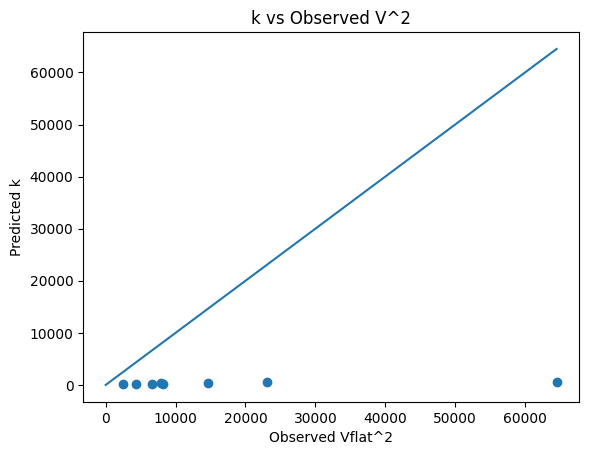

Slope log(k) vs log(V_obs^2) (should ~1): 0.5890428820458956


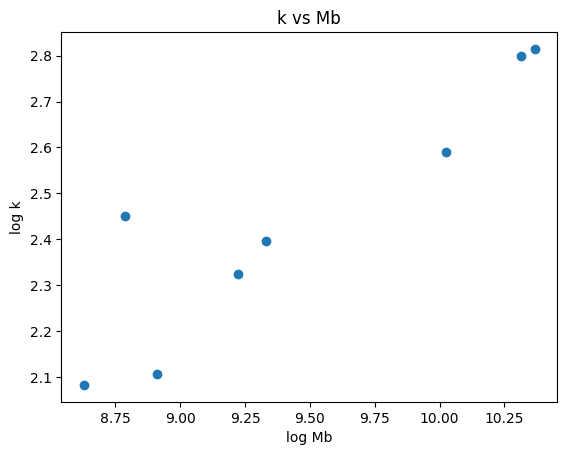

Slope log(k) vs log(Mb) (should ~0.5): 0.36413341733785765


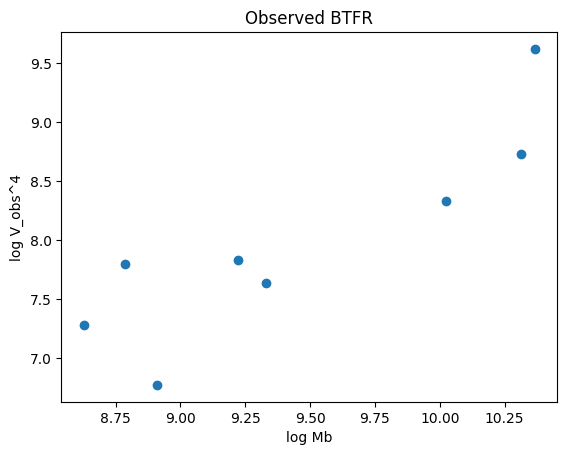

Slope log(V_obs^4) vs log(Mb) (should ~1): 1.1103651027964005


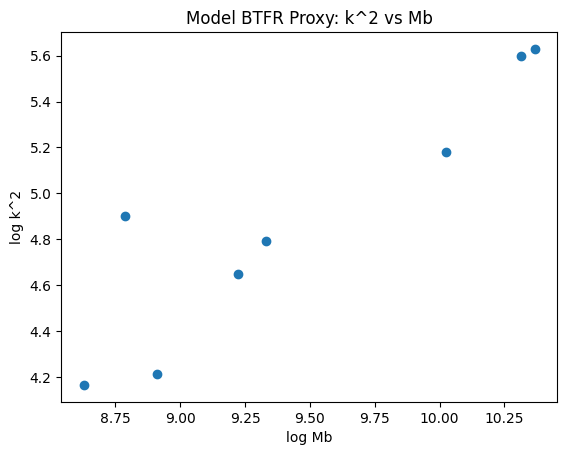

Slope log(k^2) vs log(Mb) (should ~1): 0.7282668346757153


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from glob import glob

files = glob("/content/**/*rotmod.dat", recursive=True)

G = 4.302e-6

# use the best scan point you found
a = 10.0
b = 10.0

V_obs = []
k_list = []
Mb_list = []

for f in files[:80]:
    try:
        data = pd.read_csv(f, delim_whitespace=True, comment="#")

        r = np.array(data.iloc[:, 0], dtype=float)
        v = np.array(data.iloc[:, 1], dtype=float)
        vgas = np.array(data.iloc[:, 2], dtype=float)
        vstar = np.array(data.iloc[:, 3], dtype=float)

        mask = np.isfinite(r) & np.isfinite(v) & np.isfinite(vgas) & np.isfinite(vstar) & (r > 0)
        r = r[mask]
        v = v[mask]
        vgas = vgas[mask]
        vstar = vstar[mask]

        if len(r) < 20:
            continue

        # baryonic acceleration
        gb = (vgas**2 + vstar**2) / r

        # density source estimate
        d_gb = np.gradient(gb, r)
        rho = (1.0 / (4.0 * np.pi * G)) * (d_gb + 2.0 * gb / r)

        # keep rho finite
        rho = np.nan_to_num(rho, nan=0.0, posinf=0.0, neginf=0.0)

        # enclosed baryonic mass proxy
        Mb_r = (vgas**2 + vstar**2) * r / G
        Mb_tot = np.median(Mb_r[-10:])

        r_min = max(0.05, float(np.min(r)))
        r_max = float(np.max(r))
        r_grid = np.linspace(r_min, r_max, 400)
        rho_interp = np.interp(r_grid, r, rho)

        # p=4 field equation
        def ode(rr, y):
            M = y[0]
            dM = y[1]
            rh = np.interp(rr, r_grid, rho_interp)
            d2M = b * rh - a * M**4 - (2.0 / rr) * dM
            return [dM, d2M]

        sol = solve_ivp(
            ode,
            [r_min, r_max],
            [0.1, 0.0],
            t_eval=r_grid,
            max_step=0.5,
            rtol=1e-5,
            atol=1e-7
        )

        if not sol.success:
            continue

        M = sol.y[0]

        # outer amplitude k from the tail
        tail = slice(-30, None)
        k = np.median(r_grid[tail] * M[tail])

        if not np.isfinite(k) or k <= 0:
            continue

        Vflat_obs = np.median(v[-5:])

        if np.isfinite(Vflat_obs) and Vflat_obs > 0 and np.isfinite(Mb_tot) and Mb_tot > 0:
            V_obs.append(Vflat_obs)
            k_list.append(k)
            Mb_list.append(Mb_tot)

    except Exception:
        continue

V_obs = np.array(V_obs)
k_list = np.array(k_list)
Mb_list = np.array(Mb_list)

print("Galaxies solved:", len(V_obs))

# -----------------------------
# TEST 1: k vs observed V^2
# theory prediction: k ∝ V_obs^2
# -----------------------------
plt.figure()
plt.scatter(V_obs**2, k_list)
mx = max(np.max(V_obs**2), np.max(k_list))
plt.plot([0, mx], [0, mx])
plt.xlabel("Observed Vflat^2")
plt.ylabel("Predicted k")
plt.title("k vs Observed V^2")
plt.show()

if len(V_obs) > 5:
    slope_k_v2 = np.polyfit(np.log10(V_obs**2), np.log10(k_list), 1)[0]
    print("Slope log(k) vs log(V_obs^2) (should ~1):", slope_k_v2)

# -----------------------------
# TEST 2: k vs Mb
# theory prediction: k ∝ Mb^0.5
# -----------------------------
plt.figure()
plt.scatter(np.log10(Mb_list), np.log10(k_list))
plt.xlabel("log Mb")
plt.ylabel("log k")
plt.title("k vs Mb")
plt.show()

if len(Mb_list) > 5:
    slope_k_mb = np.polyfit(np.log10(Mb_list), np.log10(k_list), 1)[0]
    print("Slope log(k) vs log(Mb) (should ~0.5):", slope_k_mb)

# -----------------------------
# TEST 3: BTFR from observed V
# theory target: V^4 ∝ Mb
# -----------------------------
plt.figure()
plt.scatter(np.log10(Mb_list), np.log10(V_obs**4))
plt.xlabel("log Mb")
plt.ylabel("log V_obs^4")
plt.title("Observed BTFR")
plt.show()

if len(Mb_list) > 5:
    slope_btfr = np.polyfit(np.log10(Mb_list), np.log10(V_obs**4), 1)[0]
    print("Slope log(V_obs^4) vs log(Mb) (should ~1):", slope_btfr)

# -----------------------------
# OPTIONAL: derived BTFR from model k
# since V^2 ∝ k, then V^4 ∝ k^2
# so compare k^2 vs Mb
# -----------------------------
plt.figure()
plt.scatter(np.log10(Mb_list), np.log10(k_list**2))
plt.xlabel("log Mb")
plt.ylabel("log k^2")
plt.title("Model BTFR Proxy: k^2 vs Mb")
plt.show()

if len(Mb_list) > 5:
    slope_model_btfr = np.polyfit(np.log10(Mb_list), np.log10(k_list**2), 1)[0]
    print("Slope log(k^2) vs log(Mb) (should ~1):", slope_model_btfr)

  p  n_gal   k_vs_V2  k_vs_Mb  BTFR_obs  BTFR_model_k2
3.5     20 -0.248150 0.421921  1.063319       0.843842
4.0     20  0.196900 0.312569  1.063319       0.625137
4.5     20  0.190783 0.338284  1.063319       0.676569
5.0     20  0.285032 0.333261  1.063319       0.666521

p=3.5
  galaxies solved: 20
  slope log(k) vs log(V_obs^2): -0.24815007061945565
  slope log(k) vs log(Mb):     0.42192103562287653
  slope log(V_obs^4) vs log(Mb): 1.063319491318389
  slope log(k^2) vs log(Mb):   0.8438420712457531


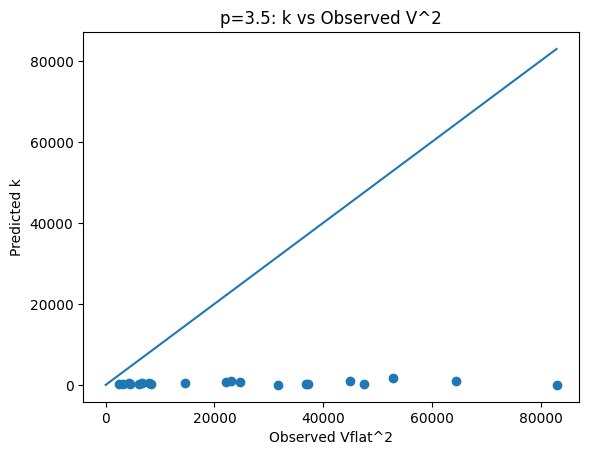

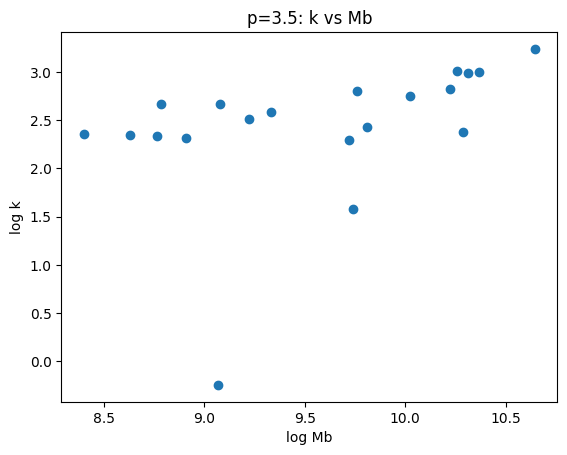

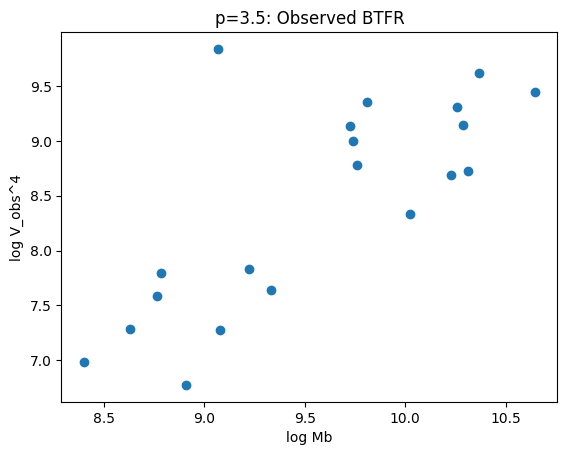

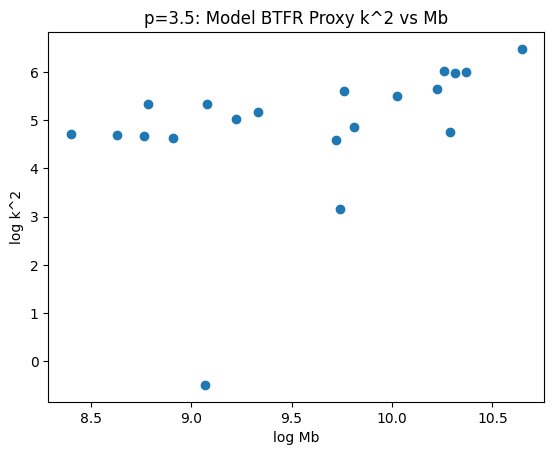


p=4.0
  galaxies solved: 20
  slope log(k) vs log(V_obs^2): 0.19690001320747869
  slope log(k) vs log(Mb):     0.3125686528174667
  slope log(V_obs^4) vs log(Mb): 1.063319491318389
  slope log(k^2) vs log(Mb):   0.6251373056349334


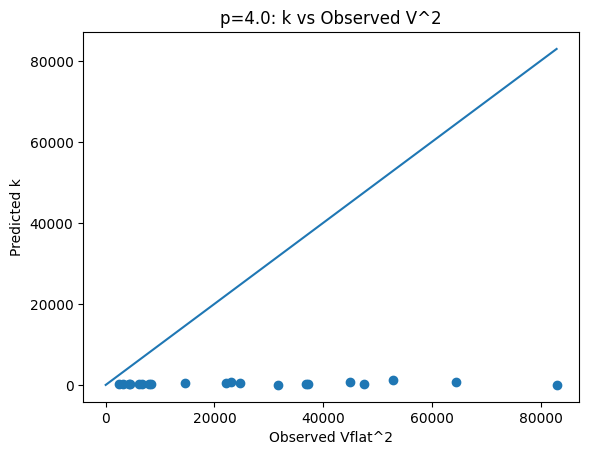

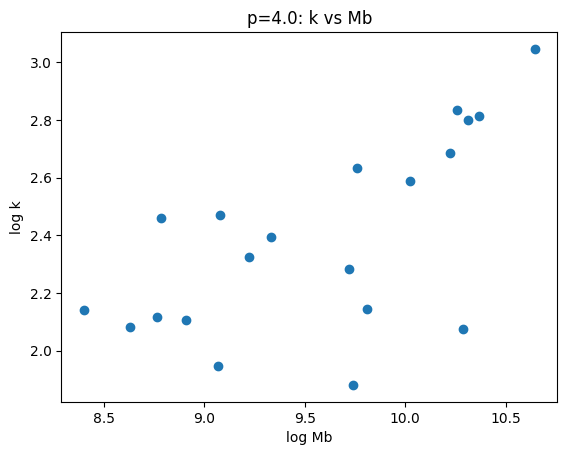

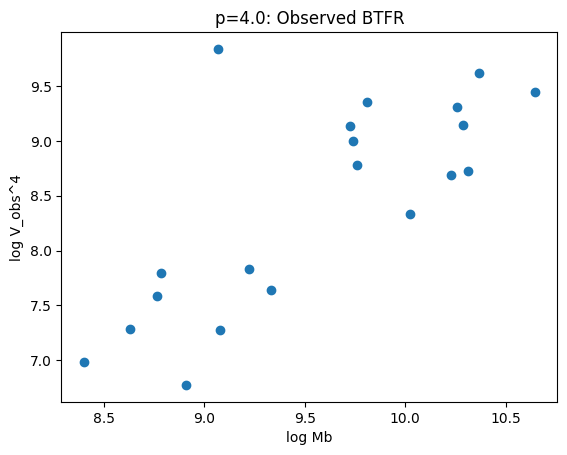

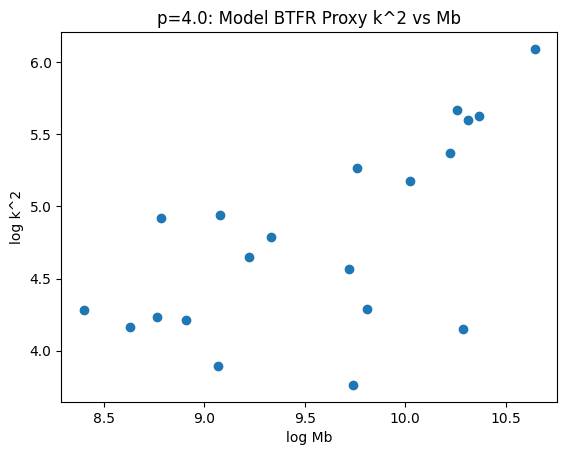


p=4.5
  galaxies solved: 20
  slope log(k) vs log(V_obs^2): 0.19078339866174004
  slope log(k) vs log(Mb):     0.33828426669219397
  slope log(V_obs^4) vs log(Mb): 1.063319491318389
  slope log(k^2) vs log(Mb):   0.6765685333843878


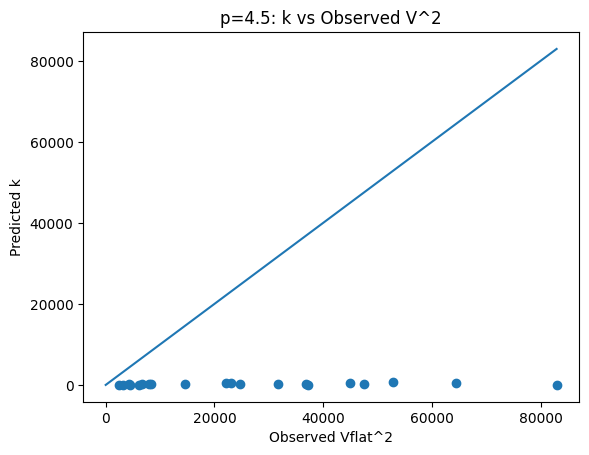

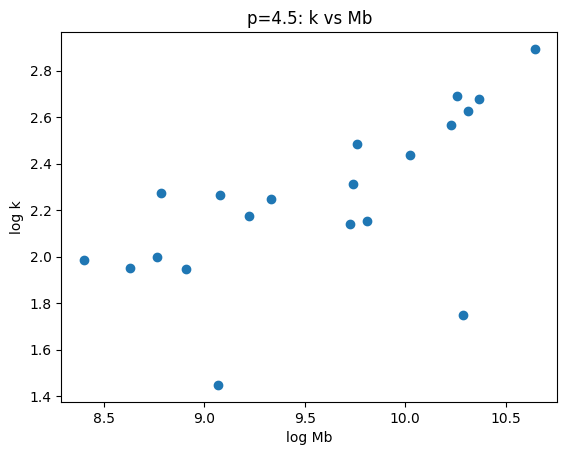

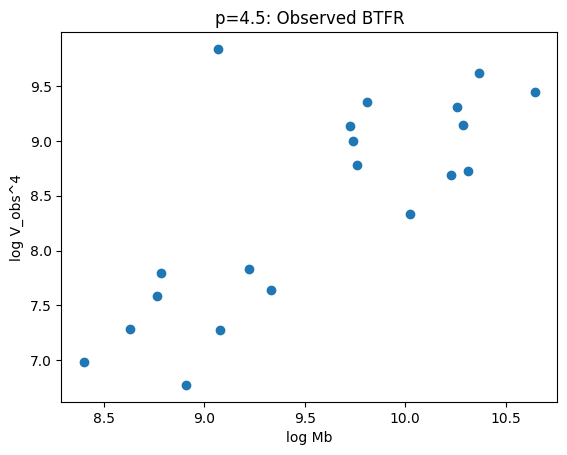

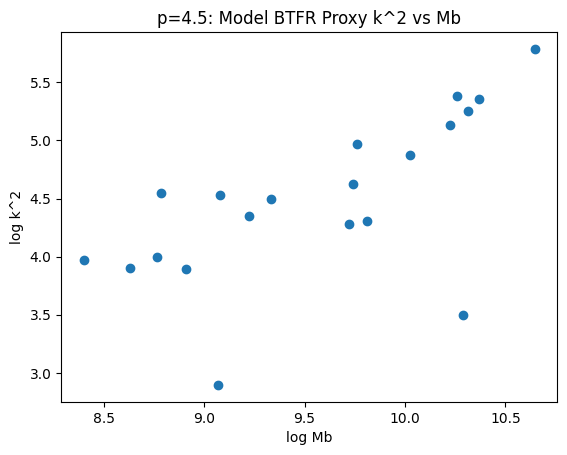


p=5.0
  galaxies solved: 20
  slope log(k) vs log(V_obs^2): 0.28503243192554345
  slope log(k) vs log(Mb):     0.33326060657817164
  slope log(V_obs^4) vs log(Mb): 1.063319491318389
  slope log(k^2) vs log(Mb):   0.6665212131563434


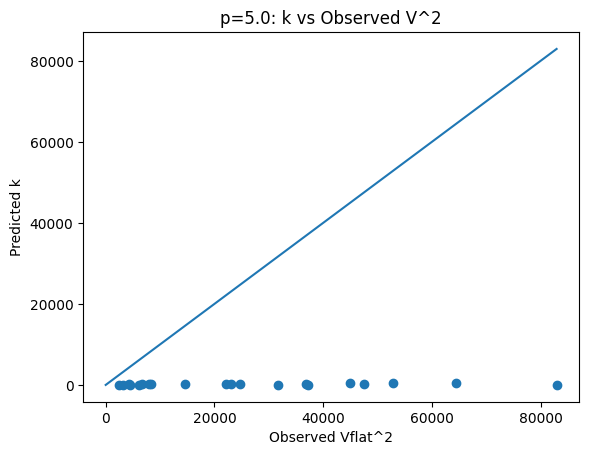

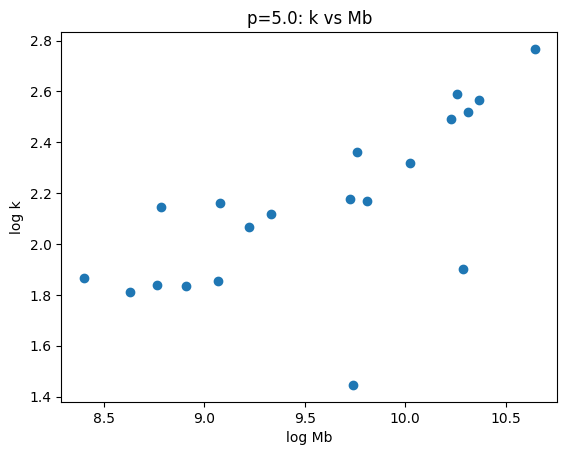

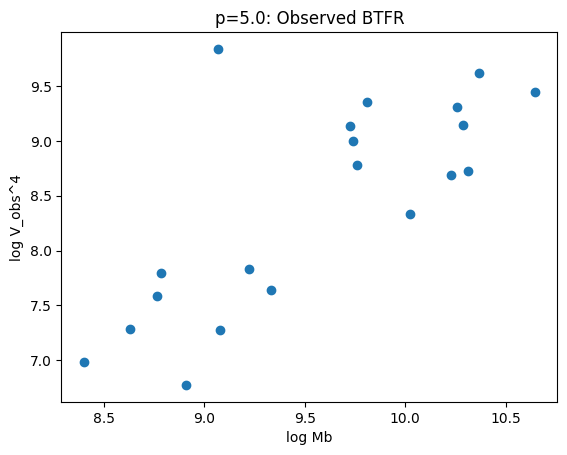

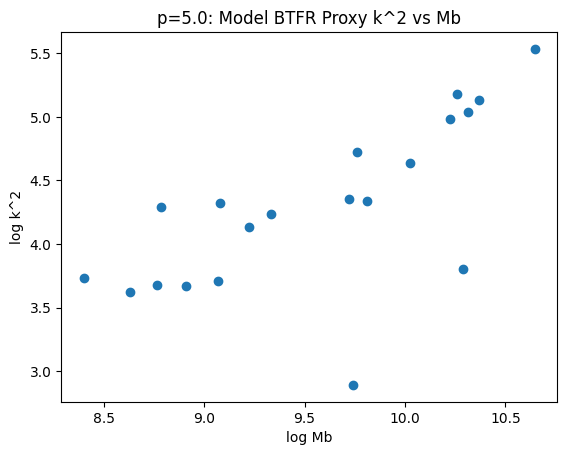

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from glob import glob

files = glob("/content/**/*rotmod.dat", recursive=True)
G = 4.302e-6

# -----------------------------
# settings
# -----------------------------
a = 10.0
b = 10.0
p_values = [3.5, 4.0, 4.5, 5.0]
max_files = 80

# -----------------------------
# helper
# -----------------------------
def run_model_for_p(p, a=10.0, b=10.0, max_files=80):
    V_obs = []
    k_list = []
    Mb_list = []

    for f in files[:max_files]:
        try:
            data = pd.read_csv(f, delim_whitespace=True, comment="#")

            r = np.array(data.iloc[:, 0], dtype=float)
            v = np.array(data.iloc[:, 1], dtype=float)
            vgas = np.array(data.iloc[:, 2], dtype=float)
            vstar = np.array(data.iloc[:, 3], dtype=float)

            mask = (
                np.isfinite(r) & np.isfinite(v) &
                np.isfinite(vgas) & np.isfinite(vstar) &
                (r > 0)
            )
            r = r[mask]
            v = v[mask]
            vgas = vgas[mask]
            vstar = vstar[mask]

            if len(r) < 20:
                continue

            # baryonic acceleration
            gb = (vgas**2 + vstar**2) / r

            # density source estimate
            d_gb = np.gradient(gb, r)
            rho = (1.0 / (4.0 * np.pi * G)) * (d_gb + 2.0 * gb / r)
            rho = np.nan_to_num(rho, nan=0.0, posinf=0.0, neginf=0.0)

            # enclosed baryonic mass proxy
            Mb_r = (vgas**2 + vstar**2) * r / G
            Mb_tot = np.median(Mb_r[-10:])

            if not np.isfinite(Mb_tot) or Mb_tot <= 0:
                continue

            r_min = max(0.05, float(np.min(r)))
            r_max = float(np.max(r))
            if r_max <= r_min:
                continue

            r_grid = np.linspace(r_min, r_max, 400)
            rho_interp = np.interp(r_grid, r, rho)

            def ode(rr, y):
                M = y[0]
                dM = y[1]
                rh = np.interp(rr, r_grid, rho_interp)
                d2M = b * rh - a * np.sign(M) * (np.abs(M) ** p) - (2.0 / rr) * dM
                return [dM, d2M]

            sol = solve_ivp(
                ode,
                [r_min, r_max],
                [0.1, 0.0],
                t_eval=r_grid,
                max_step=0.5,
                rtol=1e-5,
                atol=1e-7
            )

            if not sol.success:
                continue

            M = sol.y[0]

            # outer amplitude
            tail = slice(-30, None)
            k = np.median(r_grid[tail] * M[tail])

            Vflat_obs = np.median(v[-5:])

            if np.isfinite(k) and k > 0 and np.isfinite(Vflat_obs) and Vflat_obs > 0:
                V_obs.append(Vflat_obs)
                k_list.append(k)
                Mb_list.append(Mb_tot)

        except Exception:
            continue

    V_obs = np.array(V_obs)
    k_list = np.array(k_list)
    Mb_list = np.array(Mb_list)

    out = {
        "p": p,
        "n": len(V_obs),
        "V_obs": V_obs,
        "k": k_list,
        "Mb": Mb_list,
        "slope_k_vs_V2": np.nan,
        "slope_k_vs_Mb": np.nan,
        "slope_btfr_obs": np.nan,
        "slope_model_btfr": np.nan,
    }

    if len(V_obs) >= 5:
        try:
            out["slope_k_vs_V2"] = np.polyfit(np.log10(V_obs**2), np.log10(k_list), 1)[0]
        except Exception:
            pass
        try:
            out["slope_k_vs_Mb"] = np.polyfit(np.log10(Mb_list), np.log10(k_list), 1)[0]
        except Exception:
            pass
        try:
            out["slope_btfr_obs"] = np.polyfit(np.log10(Mb_list), np.log10(V_obs**4), 1)[0]
        except Exception:
            pass
        try:
            out["slope_model_btfr"] = np.polyfit(np.log10(Mb_list), np.log10(k_list**2), 1)[0]
        except Exception:
            pass

    return out

# -----------------------------
# run scan
# -----------------------------
results = []
for p in p_values:
    res = run_model_for_p(p, a=a, b=b, max_files=max_files)
    results.append(res)

summary = pd.DataFrame([
    {
        "p": r["p"],
        "n_gal": r["n"],
        "k_vs_V2": r["slope_k_vs_V2"],
        "k_vs_Mb": r["slope_k_vs_Mb"],
        "BTFR_obs": r["slope_btfr_obs"],
        "BTFR_model_k2": r["slope_model_btfr"],
    }
    for r in results
])

print(summary.to_string(index=False))

# -----------------------------
# plots for each p
# -----------------------------
for r in results:
    p = r["p"]
    V_obs = r["V_obs"]
    k_list = r["k"]
    Mb_list = r["Mb"]

    if len(V_obs) < 5:
        print(f"\np={p}: not enough galaxies solved")
        continue

    print(f"\np={p}")
    print("  galaxies solved:", len(V_obs))
    print("  slope log(k) vs log(V_obs^2):", r["slope_k_vs_V2"])
    print("  slope log(k) vs log(Mb):    ", r["slope_k_vs_Mb"])
    print("  slope log(V_obs^4) vs log(Mb):", r["slope_btfr_obs"])
    print("  slope log(k^2) vs log(Mb):  ", r["slope_model_btfr"])

    plt.figure()
    plt.scatter(V_obs**2, k_list)
    mx = max(np.max(V_obs**2), np.max(k_list))
    plt.plot([0, mx], [0, mx])
    plt.xlabel("Observed Vflat^2")
    plt.ylabel("Predicted k")
    plt.title(f"p={p}: k vs Observed V^2")
    plt.show()

    plt.figure()
    plt.scatter(np.log10(Mb_list), np.log10(k_list))
    plt.xlabel("log Mb")
    plt.ylabel("log k")
    plt.title(f"p={p}: k vs Mb")
    plt.show()

    plt.figure()
    plt.scatter(np.log10(Mb_list), np.log10(V_obs**4))
    plt.xlabel("log Mb")
    plt.ylabel("log V_obs^4")
    plt.title(f"p={p}: Observed BTFR")
    plt.show()

    plt.figure()
    plt.scatter(np.log10(Mb_list), np.log10(k_list**2))
    plt.xlabel("log Mb")
    plt.ylabel("log k^2")
    plt.title(f"p={p}: Model BTFR Proxy k^2 vs Mb")
    plt.show()

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from glob import glob

files = glob("/content/**/*rotmod.dat", recursive=True)
G = 4.302e-6

# -----------------------------
# settings
# -----------------------------
a = 10.0
b = 10.0
p_values = [5.0, 6.0, 7.0, 8.0]
max_files = 80

def run_model_for_p(p, a=10.0, b=10.0, max_files=80):
    V_obs = []
    k_list = []
    Mb_list = []
    Rmax_list = []
    model_btfr_basic = []
    model_btfr_log = []

    for f in files[:max_files]:
        try:
            data = pd.read_csv(f, sep=r"\s+", comment="#", engine="python")

            r = np.array(data.iloc[:, 0], dtype=float)
            v = np.array(data.iloc[:, 1], dtype=float)
            vgas = np.array(data.iloc[:, 2], dtype=float)
            vstar = np.array(data.iloc[:, 3], dtype=float)

            mask = (
                np.isfinite(r) & np.isfinite(v) &
                np.isfinite(vgas) & np.isfinite(vstar) &
                (r > 0)
            )
            r = r[mask]
            v = v[mask]
            vgas = vgas[mask]
            vstar = vstar[mask]

            if len(r) < 20:
                continue

            gb = (vgas**2 + vstar**2) / r
            d_gb = np.gradient(gb, r)
            rho = (1.0 / (4.0 * np.pi * G)) * (d_gb + 2.0 * gb / r)
            rho = np.nan_to_num(rho, nan=0.0, posinf=0.0, neginf=0.0)

            Mb_r = (vgas**2 + vstar**2) * r / G
            Mb_tot = np.median(Mb_r[-10:])
            Rmax = float(np.max(r))

            if not np.isfinite(Mb_tot) or Mb_tot <= 0 or not np.isfinite(Rmax) or Rmax <= 1.0:
                continue

            r_min = max(0.05, float(np.min(r)))
            r_max = float(np.max(r))
            if r_max <= r_min:
                continue

            r_grid = np.linspace(r_min, r_max, 400)
            rho_interp = np.interp(r_grid, r, rho)

            def ode(rr, y):
                M = y[0]
                dM = y[1]
                rh = np.interp(rr, r_grid, rho_interp)
                d2M = b * rh - a * np.sign(M) * (np.abs(M) ** p) - (2.0 / rr) * dM
                return [dM, d2M]

            sol = solve_ivp(
                ode,
                [r_min, r_max],
                [0.1, 0.0],
                t_eval=r_grid,
                max_step=0.5,
                rtol=1e-5,
                atol=1e-7
            )

            if not sol.success:
                continue

            M = sol.y[0]
            tail = slice(-30, None)
            k = np.median(r_grid[tail] * M[tail])

            Vflat_obs = np.median(v[-5:])

            if not (np.isfinite(k) and k > 0 and np.isfinite(Vflat_obs) and Vflat_obs > 0):
                continue

            # basic field BTFR proxy: V^4 ~ k^2
            btfr_basic = k**2

            # cumulative/log-corrected BTFR proxy: V^4 ~ k^2 (ln R)^2
            logR = np.log(Rmax)
            if not np.isfinite(logR) or logR <= 0:
                continue
            btfr_log = k**2 * (logR**2)

            V_obs.append(Vflat_obs)
            k_list.append(k)
            Mb_list.append(Mb_tot)
            Rmax_list.append(Rmax)
            model_btfr_basic.append(btfr_basic)
            model_btfr_log.append(btfr_log)

        except Exception:
            continue

    V_obs = np.array(V_obs)
    k_list = np.array(k_list)
    Mb_list = np.array(Mb_list)
    Rmax_list = np.array(Rmax_list)
    model_btfr_basic = np.array(model_btfr_basic)
    model_btfr_log = np.array(model_btfr_log)

    out = {
        "p": p,
        "n": len(V_obs),
        "V_obs": V_obs,
        "k": k_list,
        "Mb": Mb_list,
        "Rmax": Rmax_list,
        "basic": model_btfr_basic,
        "logcorr": model_btfr_log,
        "slope_k_vs_Mb": np.nan,
        "slope_obs_btfr": np.nan,
        "slope_basic_btfr": np.nan,
        "slope_logcorr_btfr": np.nan,
    }

    if len(V_obs) >= 5:
        try:
            out["slope_k_vs_Mb"] = np.polyfit(np.log10(Mb_list), np.log10(k_list), 1)[0]
        except Exception:
            pass
        try:
            out["slope_obs_btfr"] = np.polyfit(np.log10(Mb_list), np.log10(V_obs**4), 1)[0]
        except Exception:
            pass
        try:
            out["slope_basic_btfr"] = np.polyfit(np.log10(Mb_list), np.log10(model_btfr_basic), 1)[0]
        except Exception:
            pass
        try:
            out["slope_logcorr_btfr"] = np.polyfit(np.log10(Mb_list), np.log10(model_btfr_log), 1)[0]
        except Exception:
            pass

    return out

results = [run_model_for_p(p, a=a, b=b, max_files=max_files) for p in p_values]

summary = pd.DataFrame([
    {
        "p": r["p"],
        "n_gal": r["n"],
        "k_vs_Mb": r["slope_k_vs_Mb"],
        "BTFR_obs": r["slope_obs_btfr"],
        "BTFR_model_k2": r["slope_basic_btfr"],
        "BTFR_model_k2logR2": r["slope_logcorr_btfr"],
    }
    for r in results
])

print(summary.to_string(index=False))

# -----------------------------
# one grouped figure only
# cols:
# 1) k vs Mb
# 2) observed BTFR
# 3) model BTFR proxy k^2
# 4) log-corrected model BTFR proxy k^2 (ln R)^2
# -----------------------------
fig, axes = plt.subplots(len(results), 4, figsize=(20, 4 * len(results)))
if len(results) == 1:
    axes = np.array([axes])

for i, r in enumerate(results):
    p = r["p"]
    Mb = r["Mb"]
    k = r["k"]
    V_obs = r["V_obs"]
    basic = r["basic"]
    logcorr = r["logcorr"]

    ax1, ax2, ax3, ax4 = axes[i]

    if len(Mb) >= 5:
        ax1.scatter(np.log10(Mb), np.log10(k), s=18)
        ax1.set_xlabel("log Mb")
        ax1.set_ylabel("log k")
        ax1.set_title(f"p={p} | k vs Mb\nslope={r['slope_k_vs_Mb']:.3f}")

        ax2.scatter(np.log10(Mb), np.log10(V_obs**4), s=18)
        ax2.set_xlabel("log Mb")
        ax2.set_ylabel("log V_obs^4")
        ax2.set_title(f"Observed BTFR\nslope={r['slope_obs_btfr']:.3f}")

        ax3.scatter(np.log10(Mb), np.log10(basic), s=18)
        ax3.set_xlabel("log Mb")
        ax3.set_ylabel("log k^2")
        ax3.set_title(f"Model BTFR: k^2\nslope={r['slope_basic_btfr']:.3f}")

        ax4.scatter(np.log10(Mb), np.log10(logcorr), s=18)
        ax4.set_xlabel("log Mb")
        ax4.set_ylabel("log[k^2 (ln R)^2]")
        ax4.set_title(f"Log-corrected model BTFR\nslope={r['slope_logcorr_btfr']:.3f}")
    else:
        for ax in (ax1, ax2, ax3, ax4):
            ax.text(0.5, 0.5, f"p={p}\nnot enough galaxies solved", ha="center", va="center")
            ax.set_axis_off()

plt.tight_layout()
plt.show()

KeyboardInterrupt: 

In [ ]:
# ============================================================
# RESIDUAL-STRUCTURE AUDIT FOR CURRENT BEST GALAXY MODEL
# Best model:
#   S = (1-w) B0 + w (0.1 R1 + 0.9 R2)
#   w = 1 / (1 + exp[-2.5 (log10 Gpk - 4.05)])
# ============================================================

import os, re, glob, zipfile, warnings
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

SEARCH_ROOTS = [
    "/content/mts_realdata_workspace_v2/ROTMOD_LTG_4",
    "/content/mts_realdata_workspace_v2",
    "/content",
]

R_MIN = 1e-3
R_MAX = 55.0
N_R   = 700

Rs_fixed   = 1.5
A_src      = 0.10
UPS_DISK   = 1.0
UPS_BUL    = 1.0
R_CORE     = 0.5
SMOOTH_WIN = 9
SOURCE_FLOOR = 1e-6
MIN_POINTS = 8
HIGH_MASS_Q = 0.75

g0 = 4.05
k  = 2.5
c1 = 0.9

def norm_gal(s):
    s = str(s).strip()
    s = os.path.basename(s)
    s = re.sub(r"\.(dat|txt|csv)$", "", s, flags=re.I)
    s = re.sub(r"_rotmod$", "", s, flags=re.I)
    s = re.sub(r"[^A-Za-z0-9]", "", s).upper()
    return s

def moving_average(x, w):
    x = np.asarray(x, dtype=float)
    if w <= 1:
        return x.copy()
    w = int(max(1, w))
    if len(x) < w:
        return x.copy()
    pad = w // 2
    xp = np.pad(x, (pad, pad), mode="edge")
    ker = np.ones(w, dtype=float) / w
    y = np.convolve(xp, ker, mode="valid")
    return y[:len(x)]

def cumtrapz_np(y, x):
    y = np.asarray(y, dtype=float)
    x = np.asarray(x, dtype=float)
    out = np.zeros_like(y)
    if len(y) < 2:
        return out
    dx = np.diff(x)
    out[1:] = np.cumsum(0.5 * (y[:-1] + y[1:]) * dx)
    return out

def extract_zip_if_needed(zp):
    outdir = os.path.splitext(zp)[0] + "_extracted"
    if not os.path.exists(outdir):
        os.makedirs(outdir, exist_ok=True)
        try:
            with zipfile.ZipFile(zp, "r") as zf:
                zf.extractall(outdir)
        except Exception:
            return None
    return outdir

def collect_rotmod_files():
    files = []
    for root in SEARCH_ROOTS:
        if os.path.exists(root):
            files.extend(glob.glob(os.path.join(root, "**", "*_rotmod.dat"), recursive=True))
            files.extend(glob.glob(os.path.join(root, "**", "*rotmod*.dat"), recursive=True))
    zip_candidates = []
    for root in SEARCH_ROOTS:
        if os.path.exists(root):
            zip_candidates.extend(glob.glob(os.path.join(root, "**", "*.zip"), recursive=True))
    for zp in sorted(set(zip_candidates)):
        if "rotmod" not in os.path.basename(zp).lower():
            continue
        outdir = extract_zip_if_needed(zp)
        if outdir and os.path.exists(outdir):
            files.extend(glob.glob(os.path.join(outdir, "**", "*_rotmod.dat"), recursive=True))
            files.extend(glob.glob(os.path.join(outdir, "**", "*rotmod*.dat"), recursive=True))
    return sorted(set(files))

def parse_rotmod_file(path):
    rows = []
    with open(path, "r", errors="ignore") as fh:
        for line in fh:
            s = line.strip()
            if not s or s.startswith("#"):
                continue
            s = s.replace("D", "E").replace("d", "e")
            parts = re.split(r"\s+", s)
            vals = []
            ok = True
            for p in parts:
                try:
                    vals.append(float(p))
                except Exception:
                    ok = False
                    break
            if ok and len(vals) >= 4:
                rows.append(vals)
    if len(rows) < MIN_POINTS:
        return None
    arr = np.array(rows, dtype=float)
    ncol = arr.shape[1]
    if ncol >= 6:
        r, vobs, evobs, vgas, vdisk, vbul = arr[:,0], arr[:,1], np.abs(arr[:,2]), arr[:,3], arr[:,4], arr[:,5]
    elif ncol == 5:
        r, vobs, vgas, vdisk, vbul = arr[:,0], arr[:,1], arr[:,2], arr[:,3], arr[:,4]
        evobs = np.full(arr.shape[0], np.nan)
    elif ncol == 4:
        r, vobs, vgas, vdisk = arr[:,0], arr[:,1], arr[:,2], arr[:,3]
        vbul = np.zeros(arr.shape[0]); evobs = np.full(arr.shape[0], np.nan)
    else:
        return None
    m = np.isfinite(r)&np.isfinite(vobs)&np.isfinite(vgas)&np.isfinite(vdisk)&np.isfinite(vbul)
    r, vobs, vgas, vdisk, vbul = r[m], vobs[m], vgas[m], vdisk[m], vbul[m]
    if len(r) < MIN_POINTS:
        return None
    o = np.argsort(r)
    r, vobs, vgas, vdisk, vbul = r[o], vobs[o], vgas[o], vdisk[o], vbul[o]
    _, idx = np.unique(r, return_index=True)
    r, vobs, vgas, vdisk, vbul = r[idx], vobs[idx], vgas[idx], vdisk[idx], vbul[idx]
    if len(r) < MIN_POINTS or np.nanmax(r) <= 0:
        return None
    return {"r": r, "vobs": vobs, "vgas": vgas, "vdisk": vdisk, "vbul": vbul}

def normalise_shape(x):
    x = np.asarray(x, dtype=float)
    x = np.where(np.isfinite(x), x, 0.0)
    x = np.clip(x, 0.0, None)
    x = moving_average(x, SMOOTH_WIN)
    mx = np.nanmax(x)
    if mx > 0:
        x = x / mx
    return np.maximum(x, SOURCE_FLOOR)

def sigmoid(z):
    z = np.clip(z, -60, 60)
    return 1.0 / (1.0 + np.exp(-z))

def solve_screened_field(r_obs, rho_obs):
    rg = np.linspace(R_MIN, max(R_MAX, float(np.nanmax(r_obs)) * 1.1), N_R)
    rho_g = np.interp(rg, r_obs, rho_obs, left=rho_obs[0], right=rho_obs[-1])
    dr = rg[1] - rg[0]
    n = len(rg)
    A = np.zeros((n, n), dtype=float)
    bvec = np.zeros(n, dtype=float)
    A[0,0] = 1.0; A[0,1] = -1.0
    for i in range(1, n-1):
        rr = rg[i]
        a = 1.0/dr**2 - 1.0/(rr*dr)
        c = 1.0/dr**2 + 1.0/(rr*dr)
        d = -2.0/dr**2 - 1.0/Rs_fixed**2
        A[i,i-1] = a; A[i,i] = d; A[i,i+1] = c
        bvec[i] = -A_src * rho_g[i]
    A[-1,-1] = 1.0
    u = np.linalg.solve(A, bvec)
    du = np.gradient(u, rg)
    U = cumtrapz_np(u, rg)
    U_inf = float(np.nanmax(U))
    half = 0.5 * U_inf
    idx50 = np.where(U >= half)[0]
    r50 = float(rg[idx50[0]]) if len(idx50) else np.nan
    return rg, rho_g, u, U, U_inf, r50

def fit_global_K(df):
    U = df["U_inf"].values.astype(float)
    L = df["r50"].values.astype(float)
    V = df["Vobs"].values.astype(float)
    m = np.isfinite(U)&np.isfinite(L)&np.isfinite(V)&(U>0)&(L>0)&(V>0)
    X = U[m] / L[m]
    Y = V[m]**2
    return float(np.sum(Y*X) / np.sum(X**2))

rotmod_files = collect_rotmod_files()
file_map = {}
for f in rotmod_files:
    g = norm_gal(f)
    if g not in file_map:
        file_map[g] = f

rows = []
for gal, path in file_map.items():
    parsed = parse_rotmod_file(path)
    if parsed is None:
        continue

    r = parsed["r"]
    vobs = parsed["vobs"]
    vgas = parsed["vgas"]
    vdisk = parsed["vdisk"]
    vbul = parsed["vbul"]

    vbar2 = (
        vgas*np.abs(vgas)
        + UPS_DISK*vdisk*np.abs(vdisk)
        + UPS_BUL*vbul*np.abs(vbul)
    )
    vbar2 = np.maximum(vbar2, 0.0)

    mbar_proxy = np.sqrt(r**2 + R_CORE**2) * vbar2
    dmbar_dr = np.gradient(mbar_proxy, r)
    B0 = normalise_shape(np.clip(dmbar_dr / np.maximum(r**2 + R_CORE**2, 1e-8), 0.0, None))
    R1 = normalise_shape(vbar2 / np.sqrt(r**2 + R_CORE**2))
    R2 = normalise_shape((r * vbar2) / (r**2 + R_CORE**2))

    Gpk_proxy = float(np.nanmax(vbar2 / np.maximum(r, R_CORE)))
    w = sigmoid(k * (np.log10(max(Gpk_proxy, 1e-30)) - g0))
    Rhi = normalise_shape(c1 * R2 + (1.0 - c1) * R1)
    S = normalise_shape((1.0 - w) * B0 + w * Rhi)

    rho_peak_r = float(r[np.nanargmax(S)])
    rg, rho_g, u, U, U_inf, r50 = solve_screened_field(r, S)

    i0 = max(0, 2 * len(vobs) // 3)
    outer = vobs[i0:] if len(vobs[i0:]) >= 3 else vobs
    Vobs = float(np.median(outer))

    rmax = float(np.nanmax(r))
    Mbar_proxy = float(np.nanmax(r * vbar2))
    Sigma_proxy = Mbar_proxy / max(rmax**2, 1e-12)

    rows.append({
        "gal": gal,
        "Vobs": Vobs,
        "U_inf": U_inf,
        "r50": r50,
        "rmax": rmax,
        "rho_peak_r": rho_peak_r,
        "r50_over_rmax": r50 / rmax if rmax > 0 else np.nan,
        "Mbar_proxy": Mbar_proxy,
        "logM_proxy": np.log10(max(Mbar_proxy, 1e-30)),
        "Sigma_proxy": Sigma_proxy,
        "logSigma_proxy": np.log10(max(Sigma_proxy, 1e-30)),
        "Gpk_proxy": Gpk_proxy,
        "logGpk_proxy": np.log10(max(Gpk_proxy, 1e-30)),
        "blend_w": w,
        "B0_peak_r": float(r[np.nanargmax(B0)]),
        "R2_peak_r": float(r[np.nanargmax(R2)]),
        "n_pts": len(r),
    })

df = pd.DataFrame(rows)
Kfit = fit_global_K(df)
df["Vpred"] = np.sqrt(np.maximum(Kfit * df["U_inf"] / df["r50"], 0.0))
df["abs_err"] = np.abs(df["Vpred"] - df["Vobs"])

mass_cut = df["Mbar_proxy"].quantile(HIGH_MASS_Q)
df["is_high_mass"] = df["Mbar_proxy"] >= mass_cut

worst_hi = df[df["is_high_mass"]].sort_values("abs_err", ascending=False).head(25).copy()

print("="*72)
print("CURRENT BEST MODEL FAILURE AUDIT")
print("="*72)
print("Global Kfit =", Kfit)
print("Median abs err =", df["abs_err"].median())
print("Median abs err high-mass =", df.loc[df["is_high_mass"], "abs_err"].median())
print("Worst10 mean high-mass =", df.loc[df["is_high_mass"]].nlargest(10, "abs_err")["abs_err"].mean())

print("\n" + "="*72)
print("WORST HIGH-MASS GALAXIES")
print("="*72)
print(worst_hi[[
    "gal","Vobs","Vpred","abs_err","blend_w","logM_proxy","logSigma_proxy",
    "logGpk_proxy","rho_peak_r","r50_over_rmax","B0_peak_r","R2_peak_r","n_pts"
]].to_string(index=False))

print("\n" + "="*72)
print("MEDIANS OF WORST HIGH-MASS SUBCLASS")
print("="*72)
print(worst_hi[[
    "abs_err","blend_w","logM_proxy","logSigma_proxy","logGpk_proxy",
    "rho_peak_r","r50_over_rmax","n_pts"
]].median(numeric_only=True).to_string())

out = "/content/current_best_model_failure_audit.csv"
df.to_csv(out, index=False)
print("\nSaved:", out)

In [ ]:
# ============================================================
# HIGH-REGIME SCREENING AUDIT
# Keeps current best source law fixed:
#   S = (1-w) B0 + w (0.1 R1 + 0.9 R2)
#   w = 1 / (1 + exp[-2.5 (log10 Gpk - 4.05)])
#
# Scans only Rs_fixed to test whether the remaining hard subclass
# is source-limited or operator/screening-limited.
# ============================================================

import os, re, glob, zipfile, warnings
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

SEARCH_ROOTS = [
    "/content/mts_realdata_workspace_v2/ROTMOD_LTG_4",
    "/content/mts_realdata_workspace_v2",
    "/content",
]

R_MIN = 1e-3
R_MAX = 55.0
N_R   = 700

# current best source-law parameters
A_src      = 0.10
UPS_DISK   = 1.0
UPS_BUL    = 1.0
R_CORE     = 0.5
SMOOTH_WIN = 9
SOURCE_FLOOR = 1e-6
MIN_POINTS = 8
HIGH_MASS_Q = 0.75

g0 = 4.05
k  = 2.5
c1 = 0.9

# scan only screening length
RS_SCAN = [0.8, 1.0, 1.25, 1.5, 1.75, 2.0, 2.5, 3.0]

# worst remaining subclass to track closely
TRACK_GALS = [
    "UGC11914", "NGC5005", "ESO563G021", "UGC02487",
    "UGC02953", "UGC06787", "UGC05253", "UGC11455",
    "UGC09133", "NGC5985"
]

def norm_gal(s):
    s = str(s).strip()
    s = os.path.basename(s)
    s = re.sub(r"\.(dat|txt|csv)$", "", s, flags=re.I)
    s = re.sub(r"_rotmod$", "", s, flags=re.I)
    s = re.sub(r"[^A-Za-z0-9]", "", s).upper()
    return s

TRACK_GALS = [norm_gal(x) for x in TRACK_GALS]

def moving_average(x, w):
    x = np.asarray(x, dtype=float)
    if w <= 1:
        return x.copy()
    w = int(max(1, w))
    if len(x) < w:
        return x.copy()
    pad = w // 2
    xp = np.pad(x, (pad, pad), mode="edge")
    ker = np.ones(w, dtype=float) / w
    y = np.convolve(xp, ker, mode="valid")
    return y[:len(x)]

def cumtrapz_np(y, x):
    y = np.asarray(y, dtype=float)
    x = np.asarray(x, dtype=float)
    out = np.zeros_like(y)
    if len(y) < 2:
        return out
    dx = np.diff(x)
    out[1:] = np.cumsum(0.5 * (y[:-1] + y[1:]) * dx)
    return out

def extract_zip_if_needed(zp):
    outdir = os.path.splitext(zp)[0] + "_extracted"
    if not os.path.exists(outdir):
        os.makedirs(outdir, exist_ok=True)
        try:
            with zipfile.ZipFile(zp, "r") as zf:
                zf.extractall(outdir)
        except Exception:
            return None
    return outdir

def collect_rotmod_files():
    files = []
    for root in SEARCH_ROOTS:
        if os.path.exists(root):
            files.extend(glob.glob(os.path.join(root, "**", "*_rotmod.dat"), recursive=True))
            files.extend(glob.glob(os.path.join(root, "**", "*rotmod*.dat"), recursive=True))
    zip_candidates = []
    for root in SEARCH_ROOTS:
        if os.path.exists(root):
            zip_candidates.extend(glob.glob(os.path.join(root, "**", "*.zip"), recursive=True))
    for zp in sorted(set(zip_candidates)):
        if "rotmod" not in os.path.basename(zp).lower():
            continue
        outdir = extract_zip_if_needed(zp)
        if outdir and os.path.exists(outdir):
            files.extend(glob.glob(os.path.join(outdir, "**", "*_rotmod.dat"), recursive=True))
            files.extend(glob.glob(os.path.join(outdir, "**", "*rotmod*.dat"), recursive=True))
    return sorted(set(files))

def parse_rotmod_file(path):
    rows = []
    with open(path, "r", errors="ignore") as fh:
        for line in fh:
            s = line.strip()
            if not s or s.startswith("#"):
                continue
            s = s.replace("D", "E").replace("d", "e")
            parts = re.split(r"\s+", s)
            vals = []
            ok = True
            for p in parts:
                try:
                    vals.append(float(p))
                except Exception:
                    ok = False
                    break
            if ok and len(vals) >= 4:
                rows.append(vals)
    if len(rows) < MIN_POINTS:
        return None
    arr = np.array(rows, dtype=float)
    ncol = arr.shape[1]
    if ncol >= 6:
        r, vobs, evobs, vgas, vdisk, vbul = arr[:,0], arr[:,1], np.abs(arr[:,2]), arr[:,3], arr[:,4], arr[:,5]
    elif ncol == 5:
        r, vobs, vgas, vdisk, vbul = arr[:,0], arr[:,1], arr[:,2], arr[:,3], arr[:,4]
        evobs = np.full(arr.shape[0], np.nan)
    elif ncol == 4:
        r, vobs, vgas, vdisk = arr[:,0], arr[:,1], arr[:,2], arr[:,3]
        vbul = np.zeros(arr.shape[0]); evobs = np.full(arr.shape[0], np.nan)
    else:
        return None
    m = np.isfinite(r)&np.isfinite(vobs)&np.isfinite(vgas)&np.isfinite(vdisk)&np.isfinite(vbul)
    r, vobs, vgas, vdisk, vbul = r[m], vobs[m], vgas[m], vdisk[m], vbul[m]
    if len(r) < MIN_POINTS:
        return None
    o = np.argsort(r)
    r, vobs, vgas, vdisk, vbul = r[o], vobs[o], vgas[o], vdisk[o], vbul[o]
    _, idx = np.unique(r, return_index=True)
    r, vobs, vgas, vdisk, vbul = r[idx], vobs[idx], vgas[idx], vdisk[idx], vbul[idx]
    if len(r) < MIN_POINTS or np.nanmax(r) <= 0:
        return None
    return {"r": r, "vobs": vobs, "vgas": vgas, "vdisk": vdisk, "vbul": vbul}

def normalise_shape(x):
    x = np.asarray(x, dtype=float)
    x = np.where(np.isfinite(x), x, 0.0)
    x = np.clip(x, 0.0, None)
    x = moving_average(x, SMOOTH_WIN)
    mx = np.nanmax(x)
    if mx > 0:
        x = x / mx
    return np.maximum(x, SOURCE_FLOOR)

def sigmoid(z):
    z = np.clip(z, -60, 60)
    return 1.0 / (1.0 + np.exp(-z))

def solve_screened_field(r_obs, rho_obs, Rs_fixed):
    rg = np.linspace(R_MIN, max(R_MAX, float(np.nanmax(r_obs)) * 1.1), N_R)
    rho_g = np.interp(rg, r_obs, rho_obs, left=rho_obs[0], right=rho_obs[-1])

    dr = rg[1] - rg[0]
    n = len(rg)
    A = np.zeros((n, n), dtype=float)
    bvec = np.zeros(n, dtype=float)

    # u'(rmin)=0
    A[0, 0] = 1.0
    A[0, 1] = -1.0
    bvec[0] = 0.0

    for i in range(1, n - 1):
        rr = rg[i]
        a = 1.0 / dr**2 - 1.0 / (rr * dr)
        c = 1.0 / dr**2 + 1.0 / (rr * dr)
        d = -2.0 / dr**2 - 1.0 / Rs_fixed**2
        A[i, i - 1] = a
        A[i, i]     = d
        A[i, i + 1] = c
        bvec[i]     = -A_src * rho_g[i]

    # u(rmax)=0
    A[-1, -1] = 1.0
    bvec[-1] = 0.0

    u = np.linalg.solve(A, bvec)
    U = cumtrapz_np(u, rg)
    U_inf = float(np.nanmax(U))
    half = 0.5 * U_inf
    idx50 = np.where(U >= half)[0]
    r50 = float(rg[idx50[0]]) if len(idx50) else np.nan
    return U_inf, r50

def fit_global_K(df):
    U = df["U_inf"].values.astype(float)
    L = df["r50"].values.astype(float)
    V = df["Vobs"].values.astype(float)
    m = np.isfinite(U) & np.isfinite(L) & np.isfinite(V) & (U > 0) & (L > 0) & (V > 0)
    if m.sum() < 8:
        return np.nan
    X = U[m] / L[m]
    Y = V[m]**2
    denom = np.sum(X**2)
    if denom <= 0:
        return np.nan
    return float(np.sum(Y * X) / denom)

def corr(a, b):
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    m = np.isfinite(a) & np.isfinite(b)
    if np.sum(m) < 3:
        return np.nan
    if np.std(a[m]) == 0 or np.std(b[m]) == 0:
        return np.nan
    return float(np.corrcoef(a[m], b[m])[0, 1])

# ------------------------------------------------------------
# LOAD + CACHE CURRENT BEST SOURCE LAW INPUTS
# ------------------------------------------------------------
rotmod_files = collect_rotmod_files()
file_map = {}
for f in rotmod_files:
    g = norm_gal(f)
    if g not in file_map:
        file_map[g] = f

cache = {}
failed = []

for gal, path in file_map.items():
    parsed = parse_rotmod_file(path)
    if parsed is None:
        failed.append((gal, "parse_failed"))
        continue

    r = parsed["r"]
    vobs = parsed["vobs"]
    vgas = parsed["vgas"]
    vdisk = parsed["vdisk"]
    vbul = parsed["vbul"]

    vbar2 = (
        vgas*np.abs(vgas)
        + UPS_DISK*vdisk*np.abs(vdisk)
        + UPS_BUL*vbul*np.abs(vbul)
    )
    vbar2 = np.maximum(vbar2, 0.0)

    mbar_proxy = np.sqrt(r**2 + R_CORE**2) * vbar2
    dmbar_dr = np.gradient(mbar_proxy, r)
    B0 = normalise_shape(np.clip(dmbar_dr / np.maximum(r**2 + R_CORE**2, 1e-8), 0.0, None))
    R1 = normalise_shape(vbar2 / np.sqrt(r**2 + R_CORE**2))
    R2 = normalise_shape((r * vbar2) / (r**2 + R_CORE**2))

    Gpk_proxy = float(np.nanmax(vbar2 / np.maximum(r, R_CORE)))
    w = sigmoid(k * (np.log10(max(Gpk_proxy, 1e-30)) - g0))
    Rhi = normalise_shape(c1 * R2 + (1.0 - c1) * R1)
    S = normalise_shape((1.0 - w) * B0 + w * Rhi)

    i0 = max(0, 2 * len(vobs) // 3)
    outer = vobs[i0:] if len(vobs[i0:]) >= 3 else vobs
    Vobs = float(np.median(outer))

    rmax = float(np.nanmax(r))
    Mbar_proxy = float(np.nanmax(r * vbar2))
    Sigma_proxy = Mbar_proxy / max(rmax**2, 1e-12)

    cache[gal] = {
        "r": r,
        "S": S,
        "Vobs": Vobs,
        "Mbar_proxy": Mbar_proxy,
        "logM_proxy": np.log10(max(Mbar_proxy, 1e-30)),
        "Sigma_proxy": Sigma_proxy,
        "logSigma_proxy": np.log10(max(Sigma_proxy, 1e-30)),
        "Gpk_proxy": Gpk_proxy,
        "logGpk_proxy": np.log10(max(Gpk_proxy, 1e-30)),
        "blend_w": w,
        "n_pts": len(r),
    }

base_df = pd.DataFrame([{"gal": g, **{k:v for k,v in c.items() if k not in ["r","S"]}} for g,c in cache.items()])
mass_cut = base_df["Mbar_proxy"].quantile(HIGH_MASS_Q)

# ------------------------------------------------------------
# SCAN Rs_fixed
# ------------------------------------------------------------
all_rows = []
summary_rows = []

for Rs_fixed in RS_SCAN:
    rows = []
    for gal, c in cache.items():
        U_inf, r50 = solve_screened_field(c["r"], c["S"], Rs_fixed)
        rows.append({
            "Rs_fixed": Rs_fixed,
            "gal": gal,
            "Vobs": c["Vobs"],
            "U_inf": U_inf,
            "r50": r50,
            "Mbar_proxy": c["Mbar_proxy"],
            "logM_proxy": c["logM_proxy"],
            "logSigma_proxy": c["logSigma_proxy"],
            "logGpk_proxy": c["logGpk_proxy"],
            "blend_w": c["blend_w"],
            "n_pts": c["n_pts"],
        })
    d = pd.DataFrame(rows)
    Kfit = fit_global_K(d)
    d["Kfit"] = Kfit
    d["Vpred"] = np.sqrt(np.maximum(Kfit * d["U_inf"] / d["r50"], 0.0))
    d["abs_err"] = np.abs(d["Vpred"] - d["Vobs"])
    d["is_high_mass"] = d["Mbar_proxy"] >= mass_cut

    dhi = d[d["is_high_mass"]].copy()

    summary_rows.append({
        "Rs_fixed": Rs_fixed,
        "Kfit": Kfit,
        "median_abs_err": d["abs_err"].median(),
        "mean_abs_err": d["abs_err"].mean(),
        "median_abs_err_hiM": dhi["abs_err"].median(),
        "mean_abs_err_hiM": dhi["abs_err"].mean(),
        "worst10_mean_hiM": dhi.nlargest(min(10, len(dhi)), "abs_err")["abs_err"].mean(),
        "worst5_mean_hiM": dhi.nlargest(min(5, len(dhi)), "abs_err")["abs_err"].mean(),
        "corr_logM_abs_err": corr(d["logM_proxy"], d["abs_err"]),
    })

    all_rows.append(d)

all_df = pd.concat(all_rows, ignore_index=True)
summary_df = pd.DataFrame(summary_rows).sort_values(
    ["median_abs_err_hiM", "worst10_mean_hiM", "median_abs_err"]
)

print("=" * 72)
print("SCREENING SCAN SUMMARY")
print("=" * 72)
print(summary_df.to_string(index=False))

best_Rs = float(summary_df.iloc[0]["Rs_fixed"])
best_df = all_df[all_df["Rs_fixed"] == best_Rs].copy()

print("\n" + "=" * 72)
print("BEST Rs_fixed")
print("=" * 72)
print(best_Rs)

tracked = best_df[best_df["gal"].isin(TRACK_GALS)].copy().sort_values("abs_err", ascending=False)

print("\n" + "=" * 72)
print("TRACKED HARD GALAXIES AT BEST Rs_fixed")
print("=" * 72)
print(tracked[[
    "gal","Vobs","Vpred","abs_err","blend_w","logM_proxy","logSigma_proxy","logGpk_proxy","n_pts"
]].to_string(index=False))

# compare tracked galaxies across Rs scan
pivot = all_df[all_df["gal"].isin(TRACK_GALS)].copy()
pivot = pivot[[
    "Rs_fixed","gal","abs_err","Vpred","Vobs","blend_w","logM_proxy","logSigma_proxy","logGpk_proxy","n_pts"
]].sort_values(["gal","Rs_fixed"])

print("\n" + "=" * 72)
print("TRACKED GALAXY RESPONSE ACROSS Rs_fixed")
print("=" * 72)
for gal in sorted(pivot["gal"].unique()):
    sub = pivot[pivot["gal"] == gal][["Rs_fixed","abs_err","Vpred","Vobs"]]
    print(f"\n{gal}")
    print(sub.to_string(index=False))

summary_path = "/content/high_regime_screening_audit_summary.csv"
detail_path  = "/content/high_regime_screening_audit_detail.csv"

summary_df.to_csv(summary_path, index=False)
all_df.to_csv(detail_path, index=False)

print("\nSaved summary to:", summary_path)
print("Saved detail to:", detail_path)

In [ ]:
# ============================================================
# COMPACTNESS-WEIGHTED HIGH-REGIME TEST
#
# Fixed:
#   source gate: w = 1 / (1 + exp[-2.5 (log10 Gpk - 4.05)])
#   base source: B0
#   operator: same screened radial operator
#   Rs_fixed = 1.5
#
# Test:
#   R_hi_beta = (0.1 R1 + 0.9 R2) * G_loc^beta
#   G_loc ~ Vbar^2 / (r + r_c), normalised per galaxy
#
# Scan beta to see whether remaining failures are compactness-driven.
# ============================================================

import os, re, glob, zipfile, warnings
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

SEARCH_ROOTS = [
    "/content/mts_realdata_workspace_v2/ROTMOD_LTG_4",
    "/content/mts_realdata_workspace_v2",
    "/content",
]

R_MIN = 1e-3
R_MAX = 55.0
N_R   = 700

# fixed current-best settings
Rs_fixed  = 1.5
A_src     = 0.10
UPS_DISK  = 1.0
UPS_BUL   = 1.0
R_CORE    = 0.5
SMOOTH_WIN = 9
SOURCE_FLOOR = 1e-6
MIN_POINTS = 8
HIGH_MASS_Q = 0.75

# fixed current-best gate and hi-mix
g0 = 4.05
k  = 2.5
c1 = 0.9

# scan compactness exponent
BETA_SCAN = [0.0, 0.25, 0.5, 0.75, 1.0]

TRACK_GALS = [
    "UGC11914", "NGC5005", "ESO563G021", "UGC02487",
    "UGC02953", "UGC06787", "UGC05253", "UGC11455",
    "UGC09133", "NGC5985"
]

def norm_gal(s):
    s = str(s).strip()
    s = os.path.basename(s)
    s = re.sub(r"\.(dat|txt|csv)$", "", s, flags=re.I)
    s = re.sub(r"_rotmod$", "", s, flags=re.I)
    s = re.sub(r"[^A-Za-z0-9]", "", s).upper()
    return s

TRACK_GALS = [norm_gal(x) for x in TRACK_GALS]

def moving_average(x, w):
    x = np.asarray(x, dtype=float)
    if w <= 1:
        return x.copy()
    w = int(max(1, w))
    if len(x) < w:
        return x.copy()
    pad = w // 2
    xp = np.pad(x, (pad, pad), mode="edge")
    ker = np.ones(w, dtype=float) / w
    y = np.convolve(xp, ker, mode="valid")
    return y[:len(x)]

def cumtrapz_np(y, x):
    y = np.asarray(y, dtype=float)
    x = np.asarray(x, dtype=float)
    out = np.zeros_like(y)
    if len(y) < 2:
        return out
    dx = np.diff(x)
    out[1:] = np.cumsum(0.5 * (y[:-1] + y[1:]) * dx)
    return out

def extract_zip_if_needed(zp):
    outdir = os.path.splitext(zp)[0] + "_extracted"
    if not os.path.exists(outdir):
        os.makedirs(outdir, exist_ok=True)
        try:
            with zipfile.ZipFile(zp, "r") as zf:
                zf.extractall(outdir)
        except Exception:
            return None
    return outdir

def collect_rotmod_files():
    files = []
    for root in SEARCH_ROOTS:
        if os.path.exists(root):
            files.extend(glob.glob(os.path.join(root, "**", "*_rotmod.dat"), recursive=True))
            files.extend(glob.glob(os.path.join(root, "**", "*rotmod*.dat"), recursive=True))
    zip_candidates = []
    for root in SEARCH_ROOTS:
        if os.path.exists(root):
            zip_candidates.extend(glob.glob(os.path.join(root, "**", "*.zip"), recursive=True))
    for zp in sorted(set(zip_candidates)):
        if "rotmod" not in os.path.basename(zp).lower():
            continue
        outdir = extract_zip_if_needed(zp)
        if outdir and os.path.exists(outdir):
            files.extend(glob.glob(os.path.join(outdir, "**", "*_rotmod.dat"), recursive=True))
            files.extend(glob.glob(os.path.join(outdir, "**", "*rotmod*.dat"), recursive=True))
    return sorted(set(files))

def parse_rotmod_file(path):
    rows = []
    with open(path, "r", errors="ignore") as fh:
        for line in fh:
            s = line.strip()
            if not s or s.startswith("#"):
                continue
            s = s.replace("D", "E").replace("d", "e")
            parts = re.split(r"\s+", s)
            vals = []
            ok = True
            for p in parts:
                try:
                    vals.append(float(p))
                except Exception:
                    ok = False
                    break
            if ok and len(vals) >= 4:
                rows.append(vals)
    if len(rows) < MIN_POINTS:
        return None
    arr = np.array(rows, dtype=float)
    ncol = arr.shape[1]
    if ncol >= 6:
        r, vobs, evobs, vgas, vdisk, vbul = arr[:,0], arr[:,1], np.abs(arr[:,2]), arr[:,3], arr[:,4], arr[:,5]
    elif ncol == 5:
        r, vobs, vgas, vdisk, vbul = arr[:,0], arr[:,1], arr[:,2], arr[:,3], arr[:,4]
        evobs = np.full(arr.shape[0], np.nan)
    elif ncol == 4:
        r, vobs, vgas, vdisk = arr[:,0], arr[:,1], arr[:,2], arr[:,3]
        vbul = np.zeros(arr.shape[0]); evobs = np.full(arr.shape[0], np.nan)
    else:
        return None
    m = np.isfinite(r)&np.isfinite(vobs)&np.isfinite(vgas)&np.isfinite(vdisk)&np.isfinite(vbul)
    r, vobs, vgas, vdisk, vbul = r[m], vobs[m], vgas[m], vdisk[m], vbul[m]
    if len(r) < MIN_POINTS:
        return None
    o = np.argsort(r)
    r, vobs, vgas, vdisk, vbul = r[o], vobs[o], vgas[o], vdisk[o], vbul[o]
    _, idx = np.unique(r, return_index=True)
    r, vobs, vgas, vdisk, vbul = r[idx], vobs[idx], vgas[idx], vdisk[idx], vbul[idx]
    if len(r) < MIN_POINTS or np.nanmax(r) <= 0:
        return None
    return {"r": r, "vobs": vobs, "vgas": vgas, "vdisk": vdisk, "vbul": vbul}

def normalise_shape(x):
    x = np.asarray(x, dtype=float)
    x = np.where(np.isfinite(x), x, 0.0)
    x = np.clip(x, 0.0, None)
    x = moving_average(x, SMOOTH_WIN)
    mx = np.nanmax(x)
    if mx > 0:
        x = x / mx
    return np.maximum(x, SOURCE_FLOOR)

def sigmoid(z):
    z = np.clip(z, -60, 60)
    return 1.0 / (1.0 + np.exp(-z))

def solve_screened_field(r_obs, rho_obs):
    rg = np.linspace(R_MIN, max(R_MAX, float(np.nanmax(r_obs)) * 1.1), N_R)
    rho_g = np.interp(rg, r_obs, rho_obs, left=rho_obs[0], right=rho_obs[-1])

    dr = rg[1] - rg[0]
    n = len(rg)
    A = np.zeros((n, n), dtype=float)
    bvec = np.zeros(n, dtype=float)

    A[0, 0] = 1.0
    A[0, 1] = -1.0
    bvec[0] = 0.0

    for i in range(1, n - 1):
        rr = rg[i]
        a = 1.0 / dr**2 - 1.0 / (rr * dr)
        c = 1.0 / dr**2 + 1.0 / (rr * dr)
        d = -2.0 / dr**2 - 1.0 / Rs_fixed**2
        A[i, i - 1] = a
        A[i, i]     = d
        A[i, i + 1] = c
        bvec[i]     = -A_src * rho_g[i]

    A[-1, -1] = 1.0
    bvec[-1] = 0.0

    u = np.linalg.solve(A, bvec)
    U = cumtrapz_np(u, rg)
    U_inf = float(np.nanmax(U))
    half = 0.5 * U_inf
    idx50 = np.where(U >= half)[0]
    r50 = float(rg[idx50[0]]) if len(idx50) else np.nan
    return U_inf, r50

def fit_global_K(df):
    U = df["U_inf"].values.astype(float)
    L = df["r50"].values.astype(float)
    V = df["Vobs"].values.astype(float)
    m = np.isfinite(U) & np.isfinite(L) & np.isfinite(V) & (U > 0) & (L > 0) & (V > 0)
    if m.sum() < 8:
        return np.nan
    X = U[m] / L[m]
    Y = V[m]**2
    denom = np.sum(X**2)
    if denom <= 0:
        return np.nan
    return float(np.sum(Y * X) / denom)

def corr(a, b):
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    m = np.isfinite(a) & np.isfinite(b)
    if np.sum(m) < 3:
        return np.nan
    if np.std(a[m]) == 0 or np.std(b[m]) == 0:
        return np.nan
    return float(np.corrcoef(a[m], b[m])[0, 1])

# ------------------------------------------------------------
# LOAD + CACHE
# ------------------------------------------------------------
rotmod_files = collect_rotmod_files()
file_map = {}
for f in rotmod_files:
    g = norm_gal(f)
    if g not in file_map:
        file_map[g] = f

cache = {}
failed = []

for gal, path in file_map.items():
    parsed = parse_rotmod_file(path)
    if parsed is None:
        failed.append((gal, "parse_failed"))
        continue

    r = parsed["r"]
    vobs = parsed["vobs"]
    vgas = parsed["vgas"]
    vdisk = parsed["vdisk"]
    vbul = parsed["vbul"]

    vbar2 = (
        vgas*np.abs(vgas)
        + UPS_DISK*vdisk*np.abs(vdisk)
        + UPS_BUL*vbul*np.abs(vbul)
    )
    vbar2 = np.maximum(vbar2, 0.0)

    mbar_proxy = np.sqrt(r**2 + R_CORE**2) * vbar2
    dmbar_dr = np.gradient(mbar_proxy, r)
    B0 = normalise_shape(np.clip(dmbar_dr / np.maximum(r**2 + R_CORE**2, 1e-8), 0.0, None))
    R1 = normalise_shape(vbar2 / np.sqrt(r**2 + R_CORE**2))
    R2 = normalise_shape((r * vbar2) / (r**2 + R_CORE**2))

    # local compactness/acceleration factor
    G_loc = vbar2 / (r + R_CORE)
    G_loc = normalise_shape(G_loc)

    Gpk_proxy = float(np.nanmax(vbar2 / np.maximum(r, R_CORE)))
    w = sigmoid(k * (np.log10(max(Gpk_proxy, 1e-30)) - g0))

    i0 = max(0, 2 * len(vobs) // 3)
    outer = vobs[i0:] if len(vobs[i0:]) >= 3 else vobs
    Vobs = float(np.median(outer))

    rmax = float(np.nanmax(r))
    Mbar_proxy = float(np.nanmax(r * vbar2))
    Sigma_proxy = Mbar_proxy / max(rmax**2, 1e-12)

    cache[gal] = {
        "r": r,
        "Vobs": Vobs,
        "B0": B0,
        "R1": R1,
        "R2": R2,
        "G_loc": G_loc,
        "blend_w": w,
        "Mbar_proxy": Mbar_proxy,
        "logM_proxy": np.log10(max(Mbar_proxy, 1e-30)),
        "Sigma_proxy": Sigma_proxy,
        "logSigma_proxy": np.log10(max(Sigma_proxy, 1e-30)),
        "Gpk_proxy": Gpk_proxy,
        "logGpk_proxy": np.log10(max(Gpk_proxy, 1e-30)),
        "n_pts": len(r),
    }

base_df = pd.DataFrame([{"gal": g, **{k:v for k,v in c.items() if k not in ["r","B0","R1","R2","G_loc"]}} for g,c in cache.items()])
mass_cut = base_df["Mbar_proxy"].quantile(HIGH_MASS_Q)

# ------------------------------------------------------------
# SCAN beta
# ------------------------------------------------------------
all_rows = []
summary_rows = []

for beta in BETA_SCAN:
    rows = []
    for gal, c in cache.items():
        Rhi0 = normalise_shape(c1 * c["R2"] + (1.0 - c1) * c["R1"])
        if beta == 0.0:
            Rhi = Rhi0
        else:
            Rhi = normalise_shape(Rhi0 * np.power(np.maximum(c["G_loc"], 1e-12), beta))

        S = normalise_shape((1.0 - c["blend_w"]) * c["B0"] + c["blend_w"] * Rhi)

        U_inf, r50 = solve_screened_field(c["r"], S)

        rows.append({
            "beta": beta,
            "gal": gal,
            "Vobs": c["Vobs"],
            "U_inf": U_inf,
            "r50": r50,
            "blend_w": c["blend_w"],
            "Mbar_proxy": c["Mbar_proxy"],
            "logM_proxy": c["logM_proxy"],
            "logSigma_proxy": c["logSigma_proxy"],
            "logGpk_proxy": c["logGpk_proxy"],
            "n_pts": c["n_pts"],
        })

    d = pd.DataFrame(rows)
    Kfit = fit_global_K(d)
    d["Kfit"] = Kfit
    d["Vpred"] = np.sqrt(np.maximum(Kfit * d["U_inf"] / d["r50"], 0.0))
    d["abs_err"] = np.abs(d["Vpred"] - d["Vobs"])
    d["is_high_mass"] = d["Mbar_proxy"] >= mass_cut

    dhi = d[d["is_high_mass"]].copy()

    summary_rows.append({
        "beta": beta,
        "Kfit": Kfit,
        "median_abs_err": d["abs_err"].median(),
        "mean_abs_err": d["abs_err"].mean(),
        "median_abs_err_hiM": dhi["abs_err"].median(),
        "mean_abs_err_hiM": dhi["abs_err"].mean(),
        "worst10_mean_hiM": dhi.nlargest(min(10, len(dhi)), "abs_err")["abs_err"].mean(),
        "worst5_mean_hiM": dhi.nlargest(min(5, len(dhi)), "abs_err")["abs_err"].mean(),
        "corr_logM_abs_err": corr(d["logM_proxy"], d["abs_err"]),
    })

    all_rows.append(d)

all_df = pd.concat(all_rows, ignore_index=True)
summary_df = pd.DataFrame(summary_rows).sort_values(
    ["median_abs_err_hiM", "worst10_mean_hiM", "median_abs_err"]
)

print("=" * 72)
print("COMPACTNESS-WEIGHTED HIGH-REGIME SUMMARY")
print("=" * 72)
print(summary_df.to_string(index=False))

best_beta = float(summary_df.iloc[0]["beta"])
best_df = all_df[all_df["beta"] == best_beta].copy()

print("\n" + "=" * 72)
print("BEST beta")
print("=" * 72)
print(best_beta)

tracked = best_df[best_df["gal"].isin(TRACK_GALS)].copy().sort_values("abs_err", ascending=False)

print("\n" + "=" * 72)
print("TRACKED HARD GALAXIES AT BEST beta")
print("=" * 72)
print(tracked[[
    "gal","Vobs","Vpred","abs_err","blend_w","logM_proxy","logSigma_proxy","logGpk_proxy","n_pts"
]].to_string(index=False))

print("\n" + "=" * 72)
print("TRACKED GALAXY RESPONSE ACROSS beta")
print("=" * 72)
pivot = all_df[all_df["gal"].isin(TRACK_GALS)].copy()
for gal in sorted(pivot["gal"].unique()):
    sub = pivot[pivot["gal"] == gal][["beta","abs_err","Vpred","Vobs"]].sort_values("beta")
    print(f"\n{gal}")
    print(sub.to_string(index=False))

summary_path = "/content/compactness_weighted_high_regime_summary.csv"
detail_path  = "/content/compactness_weighted_high_regime_detail.csv"

summary_df.to_csv(summary_path, index=False)
all_df.to_csv(detail_path, index=False)

print("\nSaved summary to:", summary_path)
print("Saved detail to:", detail_path)

In [ ]:
# ============================================================
# HIGH-REGIME SHAPE DEFORMATION TEST
#
# Fixed:
#   S = (1-w) B0 + w (0.1 R1 + 0.9 R2_p)
#   w = 1 / (1 + exp[-2.5 (log10 Gpk - 4.05)])
#   Rs_fixed = 1.5
#
# Deform only the enclosed-load branch:
#   R2_p(r) = r^p * Vbar^2 / (r^2 + r_c^2)
#
# Scan p to test whether remaining failures need a different
# radial placement of the high-regime source.
# ============================================================

import os, re, glob, zipfile, warnings
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

SEARCH_ROOTS = [
    "/content/mts_realdata_workspace_v2/ROTMOD_LTG_4",
    "/content/mts_realdata_workspace_v2",
    "/content",
]

R_MIN = 1e-3
R_MAX = 55.0
N_R   = 700

# fixed current-best settings
Rs_fixed  = 1.5
A_src     = 0.10
UPS_DISK  = 1.0
UPS_BUL   = 1.0
R_CORE    = 0.5
SMOOTH_WIN = 9
SOURCE_FLOOR = 1e-6
MIN_POINTS = 8
HIGH_MASS_Q = 0.75

# fixed current-best gate and hi-mix
g0 = 4.05
k  = 2.5
c1 = 0.9

# scan radial-shape exponent
P_SCAN = [0.5, 0.75, 1.0, 1.25, 1.5]

TRACK_GALS = [
    "UGC11914", "NGC5005", "ESO563G021", "UGC02487",
    "UGC02953", "UGC06787", "UGC05253", "UGC11455",
    "UGC09133", "NGC5985"
]

def norm_gal(s):
    s = str(s).strip()
    s = os.path.basename(s)
    s = re.sub(r"\.(dat|txt|csv)$", "", s, flags=re.I)
    s = re.sub(r"_rotmod$", "", s, flags=re.I)
    s = re.sub(r"[^A-Za-z0-9]", "", s).upper()
    return s

TRACK_GALS = [norm_gal(x) for x in TRACK_GALS]

def moving_average(x, w):
    x = np.asarray(x, dtype=float)
    if w <= 1:
        return x.copy()
    w = int(max(1, w))
    if len(x) < w:
        return x.copy()
    pad = w // 2
    xp = np.pad(x, (pad, pad), mode="edge")
    ker = np.ones(w, dtype=float) / w
    y = np.convolve(xp, ker, mode="valid")
    return y[:len(x)]

def cumtrapz_np(y, x):
    y = np.asarray(y, dtype=float)
    x = np.asarray(x, dtype=float)
    out = np.zeros_like(y)
    if len(y) < 2:
        return out
    dx = np.diff(x)
    out[1:] = np.cumsum(0.5 * (y[:-1] + y[1:]) * dx)
    return out

def extract_zip_if_needed(zp):
    outdir = os.path.splitext(zp)[0] + "_extracted"
    if not os.path.exists(outdir):
        os.makedirs(outdir, exist_ok=True)
        try:
            with zipfile.ZipFile(zp, "r") as zf:
                zf.extractall(outdir)
        except Exception:
            return None
    return outdir

def collect_rotmod_files():
    files = []
    for root in SEARCH_ROOTS:
        if os.path.exists(root):
            files.extend(glob.glob(os.path.join(root, "**", "*_rotmod.dat"), recursive=True))
            files.extend(glob.glob(os.path.join(root, "**", "*rotmod*.dat"), recursive=True))
    zip_candidates = []
    for root in SEARCH_ROOTS:
        if os.path.exists(root):
            zip_candidates.extend(glob.glob(os.path.join(root, "**", "*.zip"), recursive=True))
    for zp in sorted(set(zip_candidates)):
        if "rotmod" not in os.path.basename(zp).lower():
            continue
        outdir = extract_zip_if_needed(zp)
        if outdir and os.path.exists(outdir):
            files.extend(glob.glob(os.path.join(outdir, "**", "*_rotmod.dat"), recursive=True))
            files.extend(glob.glob(os.path.join(outdir, "**", "*rotmod*.dat"), recursive=True))
    return sorted(set(files))

def parse_rotmod_file(path):
    rows = []
    with open(path, "r", errors="ignore") as fh:
        for line in fh:
            s = line.strip()
            if not s or s.startswith("#"):
                continue
            s = s.replace("D", "E").replace("d", "e")
            parts = re.split(r"\s+", s)
            vals = []
            ok = True
            for p in parts:
                try:
                    vals.append(float(p))
                except Exception:
                    ok = False
                    break
            if ok and len(vals) >= 4:
                rows.append(vals)
    if len(rows) < MIN_POINTS:
        return None
    arr = np.array(rows, dtype=float)
    ncol = arr.shape[1]
    if ncol >= 6:
        r, vobs, evobs, vgas, vdisk, vbul = arr[:,0], arr[:,1], np.abs(arr[:,2]), arr[:,3], arr[:,4], arr[:,5]
    elif ncol == 5:
        r, vobs, vgas, vdisk, vbul = arr[:,0], arr[:,1], arr[:,2], arr[:,3], arr[:,4]
        evobs = np.full(arr.shape[0], np.nan)
    elif ncol == 4:
        r, vobs, vgas, vdisk = arr[:,0], arr[:,1], arr[:,2], arr[:,3]
        vbul = np.zeros(arr.shape[0]); evobs = np.full(arr.shape[0], np.nan)
    else:
        return None
    m = np.isfinite(r)&np.isfinite(vobs)&np.isfinite(vgas)&np.isfinite(vdisk)&np.isfinite(vbul)
    r, vobs, vgas, vdisk, vbul = r[m], vobs[m], vgas[m], vdisk[m], vbul[m]
    if len(r) < MIN_POINTS:
        return None
    o = np.argsort(r)
    r, vobs, vgas, vdisk, vbul = r[o], vobs[o], vgas[o], vdisk[o], vbul[o]
    _, idx = np.unique(r, return_index=True)
    r, vobs, vgas, vdisk, vbul = r[idx], vobs[idx], vgas[idx], vdisk[idx], vbul[idx]
    if len(r) < MIN_POINTS or np.nanmax(r) <= 0:
        return None
    return {"r": r, "vobs": vobs, "vgas": vgas, "vdisk": vdisk, "vbul": vbul}

def normalise_shape(x):
    x = np.asarray(x, dtype=float)
    x = np.where(np.isfinite(x), x, 0.0)
    x = np.clip(x, 0.0, None)
    x = moving_average(x, SMOOTH_WIN)
    mx = np.nanmax(x)
    if mx > 0:
        x = x / mx
    return np.maximum(x, SOURCE_FLOOR)

def sigmoid(z):
    z = np.clip(z, -60, 60)
    return 1.0 / (1.0 + np.exp(-z))

def solve_screened_field(r_obs, rho_obs):
    rg = np.linspace(R_MIN, max(R_MAX, float(np.nanmax(r_obs)) * 1.1), N_R)
    rho_g = np.interp(rg, r_obs, rho_obs, left=rho_obs[0], right=rho_obs[-1])

    dr = rg[1] - rg[0]
    n = len(rg)
    A = np.zeros((n, n), dtype=float)
    bvec = np.zeros(n, dtype=float)

    A[0, 0] = 1.0
    A[0, 1] = -1.0
    bvec[0] = 0.0

    for i in range(1, n - 1):
        rr = rg[i]
        a = 1.0 / dr**2 - 1.0 / (rr * dr)
        c = 1.0 / dr**2 + 1.0 / (rr * dr)
        d = -2.0 / dr**2 - 1.0 / Rs_fixed**2
        A[i, i - 1] = a
        A[i, i]     = d
        A[i, i + 1] = c
        bvec[i]     = -A_src * rho_g[i]

    A[-1, -1] = 1.0
    bvec[-1] = 0.0

    u = np.linalg.solve(A, bvec)
    U = cumtrapz_np(u, rg)
    U_inf = float(np.nanmax(U))
    half = 0.5 * U_inf
    idx50 = np.where(U >= half)[0]
    r50 = float(rg[idx50[0]]) if len(idx50) else np.nan
    return U_inf, r50

def fit_global_K(df):
    U = df["U_inf"].values.astype(float)
    L = df["r50"].values.astype(float)
    V = df["Vobs"].values.astype(float)
    m = np.isfinite(U) & np.isfinite(L) & np.isfinite(V) & (U > 0) & (L > 0) & (V > 0)
    if m.sum() < 8:
        return np.nan
    X = U[m] / L[m]
    Y = V[m]**2
    denom = np.sum(X**2)
    if denom <= 0:
        return np.nan
    return float(np.sum(Y * X) / denom)

def corr(a, b):
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    m = np.isfinite(a) & np.isfinite(b)
    if np.sum(m) < 3:
        return np.nan
    if np.std(a[m]) == 0 or np.std(b[m]) == 0:
        return np.nan
    return float(np.corrcoef(a[m], b[m])[0, 1])

# ------------------------------------------------------------
# LOAD + CACHE
# ------------------------------------------------------------
rotmod_files = collect_rotmod_files()
file_map = {}
for f in rotmod_files:
    g = norm_gal(f)
    if g not in file_map:
        file_map[g] = f

cache = {}
failed = []

for gal, path in file_map.items():
    parsed = parse_rotmod_file(path)
    if parsed is None:
        failed.append((gal, "parse_failed"))
        continue

    r = parsed["r"]
    vobs = parsed["vobs"]
    vgas = parsed["vgas"]
    vdisk = parsed["vdisk"]
    vbul = parsed["vbul"]

    vbar2 = (
        vgas*np.abs(vgas)
        + UPS_DISK*vdisk*np.abs(vdisk)
        + UPS_BUL*vbul*np.abs(vbul)
    )
    vbar2 = np.maximum(vbar2, 0.0)

    mbar_proxy = np.sqrt(r**2 + R_CORE**2) * vbar2
    dmbar_dr = np.gradient(mbar_proxy, r)
    B0 = normalise_shape(np.clip(dmbar_dr / np.maximum(r**2 + R_CORE**2, 1e-8), 0.0, None))
    R1 = normalise_shape(vbar2 / np.sqrt(r**2 + R_CORE**2))

    Gpk_proxy = float(np.nanmax(vbar2 / np.maximum(r, R_CORE)))
    w = sigmoid(k * (np.log10(max(Gpk_proxy, 1e-30)) - g0))

    i0 = max(0, 2 * len(vobs) // 3)
    outer = vobs[i0:] if len(vobs[i0:]) >= 3 else vobs
    Vobs = float(np.median(outer))

    rmax = float(np.nanmax(r))
    Mbar_proxy = float(np.nanmax(r * vbar2))
    Sigma_proxy = Mbar_proxy / max(rmax**2, 1e-12)

    cache[gal] = {
        "r": r,
        "vbar2": vbar2,
        "Vobs": Vobs,
        "B0": B0,
        "R1": R1,
        "blend_w": w,
        "Mbar_proxy": Mbar_proxy,
        "logM_proxy": np.log10(max(Mbar_proxy, 1e-30)),
        "Sigma_proxy": Sigma_proxy,
        "logSigma_proxy": np.log10(max(Sigma_proxy, 1e-30)),
        "Gpk_proxy": Gpk_proxy,
        "logGpk_proxy": np.log10(max(Gpk_proxy, 1e-30)),
        "n_pts": len(r),
    }

base_df = pd.DataFrame([{"gal": g, **{k:v for k,v in c.items() if k not in ["r","vbar2","B0","R1"]}} for g,c in cache.items()])
mass_cut = base_df["Mbar_proxy"].quantile(HIGH_MASS_Q)

# ------------------------------------------------------------
# SCAN p
# ------------------------------------------------------------
all_rows = []
summary_rows = []

for p in P_SCAN:
    rows = []
    for gal, c in cache.items():
        r = c["r"]
        vbar2 = c["vbar2"]

        R2p = normalise_shape((np.power(np.maximum(r, 1e-8), p) * vbar2) / (r**2 + R_CORE**2))
        Rhi = normalise_shape(c1 * R2p + (1.0 - c1) * c["R1"])
        S = normalise_shape((1.0 - c["blend_w"]) * c["B0"] + c["blend_w"] * Rhi)

        U_inf, r50 = solve_screened_field(r, S)

        rows.append({
            "p": p,
            "gal": gal,
            "Vobs": c["Vobs"],
            "U_inf": U_inf,
            "r50": r50,
            "blend_w": c["blend_w"],
            "Mbar_proxy": c["Mbar_proxy"],
            "logM_proxy": c["logM_proxy"],
            "logSigma_proxy": c["logSigma_proxy"],
            "logGpk_proxy": c["logGpk_proxy"],
            "n_pts": c["n_pts"],
        })

    d = pd.DataFrame(rows)
    Kfit = fit_global_K(d)
    d["Kfit"] = Kfit
    d["Vpred"] = np.sqrt(np.maximum(Kfit * d["U_inf"] / d["r50"], 0.0))
    d["abs_err"] = np.abs(d["Vpred"] - d["Vobs"])
    d["is_high_mass"] = d["Mbar_proxy"] >= mass_cut

    dhi = d[d["is_high_mass"]].copy()

    summary_rows.append({
        "p": p,
        "Kfit": Kfit,
        "median_abs_err": d["abs_err"].median(),
        "mean_abs_err": d["abs_err"].mean(),
        "median_abs_err_hiM": dhi["abs_err"].median(),
        "mean_abs_err_hiM": dhi["abs_err"].mean(),
        "worst10_mean_hiM": dhi.nlargest(min(10, len(dhi)), "abs_err")["abs_err"].mean(),
        "worst5_mean_hiM": dhi.nlargest(min(5, len(dhi)), "abs_err")["abs_err"].mean(),
        "corr_logM_abs_err": corr(d["logM_proxy"], d["abs_err"]),
    })

    all_rows.append(d)

all_df = pd.concat(all_rows, ignore_index=True)
summary_df = pd.DataFrame(summary_rows).sort_values(
    ["median_abs_err_hiM", "worst10_mean_hiM", "median_abs_err"]
)

print("=" * 72)
print("HIGH-REGIME SHAPE DEFORMATION SUMMARY")
print("=" * 72)
print(summary_df.to_string(index=False))

best_p = float(summary_df.iloc[0]["p"])
best_df = all_df[all_df["p"] == best_p].copy()

print("\n" + "=" * 72)
print("BEST p")
print("=" * 72)
print(best_p)

tracked = best_df[best_df["gal"].isin(TRACK_GALS)].copy().sort_values("abs_err", ascending=False)

print("\n" + "=" * 72)
print("TRACKED HARD GALAXIES AT BEST p")
print("=" * 72)
print(tracked[[
    "gal","Vobs","Vpred","abs_err","blend_w","logM_proxy","logSigma_proxy","logGpk_proxy","n_pts"
]].to_string(index=False))

print("\n" + "=" * 72)
print("TRACKED GALAXY RESPONSE ACROSS p")
print("=" * 72)
pivot = all_df[all_df["gal"].isin(TRACK_GALS)].copy()
for gal in sorted(pivot["gal"].unique()):
    sub = pivot[pivot["gal"] == gal][["p","abs_err","Vpred","Vobs"]].sort_values("p")
    print(f"\n{gal}")
    print(sub.to_string(index=False))

summary_path = "/content/high_regime_shape_deformation_summary.csv"
detail_path  = "/content/high_regime_shape_deformation_detail.csv"

summary_df.to_csv(summary_path, index=False)
all_df.to_csv(detail_path, index=False)

print("\nSaved summary to:", summary_path)
print("Saved detail to:", detail_path)

HIGH-REGIME SHAPE DEFORMATION SUMMARY
   p          Kfit  median_abs_err  mean_abs_err  median_abs_err_hiM  mean_abs_err_hiM  worst10_mean_hiM  worst5_mean_hiM  corr_logM_abs_err
1.00 114457.322208       40.750391     47.600866           42.635153         58.134764        112.104308       133.108612           0.036873
1.25 116717.500420       40.700901     45.840887           46.011697         54.520803        102.769848       119.840191           0.003463
1.50 118315.704501       41.034426     44.430090           46.890725         50.091931         93.605286       106.794383          -0.036831
0.75 112147.547978       41.277126     49.265408           48.700019         61.318279        120.621079       143.329472           0.068996
0.50 110256.649263       43.116862     50.490496           52.090455         63.806487        126.367475       148.638747           0.088235

BEST p
1.0

TRACKED HARD GALAXIES AT BEST p
       gal  Vobs      Vpred    abs_err  blend_w  logM_proxy  logSigma_p

In [ ]:
# ============================================================
# TWO-GATE HIGH-REGIME SHAPE TEST
#
# Fixed:
#   S = (1-w) B0 + w (0.1 R1 + 0.9 R2_peff)
#   w = 1 / (1 + exp[-2.5 (log10 Gpk - 4.05)])
#   Rs_fixed = 1.5
#
# New:
#   s_sigma = 1 / (1 + exp[-k_sigma (log10 Sigma - Sigma0)])
#   p_eff   = 1 + dp * w * s_sigma
#
# So only galaxies that are both high-Gpk and high-Sigma get the
# strongest outward shift in the high-regime source.
# ============================================================

import os, re, glob, zipfile, warnings
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

SEARCH_ROOTS = [
    "/content/mts_realdata_workspace_v2/ROTMOD_LTG_4",
    "/content/mts_realdata_workspace_v2",
    "/content",
]

R_MIN = 1e-3
R_MAX = 55.0
N_R   = 700

Rs_fixed  = 1.5
A_src     = 0.10
UPS_DISK  = 1.0
UPS_BUL   = 1.0
R_CORE    = 0.5
SMOOTH_WIN = 9
SOURCE_FLOOR = 1e-6
MIN_POINTS = 8
HIGH_MASS_Q = 0.75

# fixed current-best Gpk gate
g0 = 4.05
k_gpk = 2.5
c1 = 0.9

# scan only the Sigma gate and outward-shift strength
DP_SCAN = [0.5, 1.0]
SIGMA0_SCAN = [2.6, 2.8, 3.0, 3.2]
KSIG_SCAN = [2.0, 4.0, 6.0]

TRACK_GALS = [
    "UGC11914", "NGC5005", "ESO563G021", "UGC02487",
    "UGC02953", "UGC06787", "UGC05253", "UGC11455",
    "UGC09133", "NGC5985"
]

def norm_gal(s):
    s = str(s).strip()
    s = os.path.basename(s)
    s = re.sub(r"\.(dat|txt|csv)$", "", s, flags=re.I)
    s = re.sub(r"_rotmod$", "", s, flags=re.I)
    s = re.sub(r"[^A-Za-z0-9]", "", s).upper()
    return s

TRACK_GALS = [norm_gal(x) for x in TRACK_GALS]

def moving_average(x, w):
    x = np.asarray(x, dtype=float)
    if w <= 1:
        return x.copy()
    w = int(max(1, w))
    if len(x) < w:
        return x.copy()
    pad = w // 2
    xp = np.pad(x, (pad, pad), mode="edge")
    ker = np.ones(w, dtype=float) / w
    y = np.convolve(xp, ker, mode="valid")
    return y[:len(x)]

def cumtrapz_np(y, x):
    y = np.asarray(y, dtype=float)
    x = np.asarray(x, dtype=float)
    out = np.zeros_like(y)
    if len(y) < 2:
        return out
    dx = np.diff(x)
    out[1:] = np.cumsum(0.5 * (y[:-1] + y[1:]) * dx)
    return out

def extract_zip_if_needed(zp):
    outdir = os.path.splitext(zp)[0] + "_extracted"
    if not os.path.exists(outdir):
        os.makedirs(outdir, exist_ok=True)
        try:
            with zipfile.ZipFile(zp, "r") as zf:
                zf.extractall(outdir)
        except Exception:
            return None
    return outdir

def collect_rotmod_files():
    files = []
    for root in SEARCH_ROOTS:
        if os.path.exists(root):
            files.extend(glob.glob(os.path.join(root, "**", "*_rotmod.dat"), recursive=True))
            files.extend(glob.glob(os.path.join(root, "**", "*rotmod*.dat"), recursive=True))
    zip_candidates = []
    for root in SEARCH_ROOTS:
        if os.path.exists(root):
            zip_candidates.extend(glob.glob(os.path.join(root, "**", "*.zip"), recursive=True))
    for zp in sorted(set(zip_candidates)):
        if "rotmod" not in os.path.basename(zp).lower():
            continue
        outdir = extract_zip_if_needed(zp)
        if outdir and os.path.exists(outdir):
            files.extend(glob.glob(os.path.join(outdir, "**", "*_rotmod.dat"), recursive=True))
            files.extend(glob.glob(os.path.join(outdir, "**", "*rotmod*.dat"), recursive=True))
    return sorted(set(files))

def parse_rotmod_file(path):
    rows = []
    with open(path, "r", errors="ignore") as fh:
        for line in fh:
            s = line.strip()
            if not s or s.startswith("#"):
                continue
            s = s.replace("D", "E").replace("d", "e")
            parts = re.split(r"\s+", s)
            vals = []
            ok = True
            for p in parts:
                try:
                    vals.append(float(p))
                except Exception:
                    ok = False
                    break
            if ok and len(vals) >= 4:
                rows.append(vals)
    if len(rows) < MIN_POINTS:
        return None
    arr = np.array(rows, dtype=float)
    ncol = arr.shape[1]
    if ncol >= 6:
        r, vobs, evobs, vgas, vdisk, vbul = arr[:,0], arr[:,1], np.abs(arr[:,2]), arr[:,3], arr[:,4], arr[:,5]
    elif ncol == 5:
        r, vobs, vgas, vdisk, vbul = arr[:,0], arr[:,1], arr[:,2], arr[:,3], arr[:,4]
    elif ncol == 4:
        r, vobs, vgas, vdisk = arr[:,0], arr[:,1], arr[:,2], arr[:,3]
        vbul = np.zeros(arr.shape[0])
    else:
        return None
    m = np.isfinite(r)&np.isfinite(vobs)&np.isfinite(vgas)&np.isfinite(vdisk)&np.isfinite(vbul)
    r, vobs, vgas, vdisk, vbul = r[m], vobs[m], vgas[m], vdisk[m], vbul[m]
    if len(r) < MIN_POINTS:
        return None
    o = np.argsort(r)
    r, vobs, vgas, vdisk, vbul = r[o], vobs[o], vgas[o], vdisk[o], vbul[o]
    _, idx = np.unique(r, return_index=True)
    r, vobs, vgas, vdisk, vbul = r[idx], vobs[idx], vgas[idx], vdisk[idx], vbul[idx]
    if len(r) < MIN_POINTS or np.nanmax(r) <= 0:
        return None
    return {"r": r, "vobs": vobs, "vgas": vgas, "vdisk": vdisk, "vbul": vbul}

def normalise_shape(x):
    x = np.asarray(x, dtype=float)
    x = np.where(np.isfinite(x), x, 0.0)
    x = np.clip(x, 0.0, None)
    x = moving_average(x, SMOOTH_WIN)
    mx = np.nanmax(x)
    if mx > 0:
        x = x / mx
    return np.maximum(x, SOURCE_FLOOR)

def sigmoid(z):
    z = np.clip(z, -60, 60)
    return 1.0 / (1.0 + np.exp(-z))

def solve_screened_field(r_obs, rho_obs):
    rg = np.linspace(R_MIN, max(R_MAX, float(np.nanmax(r_obs)) * 1.1), N_R)
    rho_g = np.interp(rg, r_obs, rho_obs, left=rho_obs[0], right=rho_obs[-1])

    dr = rg[1] - rg[0]
    n = len(rg)
    A = np.zeros((n, n), dtype=float)
    bvec = np.zeros(n, dtype=float)

    A[0, 0] = 1.0
    A[0, 1] = -1.0

    for i in range(1, n - 1):
        rr = rg[i]
        a = 1.0 / dr**2 - 1.0 / (rr * dr)
        c = 1.0 / dr**2 + 1.0 / (rr * dr)
        d = -2.0 / dr**2 - 1.0 / Rs_fixed**2
        A[i, i - 1] = a
        A[i, i]     = d
        A[i, i + 1] = c
        bvec[i]     = -A_src * rho_g[i]

    A[-1, -1] = 1.0
    u = np.linalg.solve(A, bvec)
    U = cumtrapz_np(u, rg)
    U_inf = float(np.nanmax(U))
    half = 0.5 * U_inf
    idx50 = np.where(U >= half)[0]
    r50 = float(rg[idx50[0]]) if len(idx50) else np.nan
    return U_inf, r50

def fit_global_K(df):
    U = df["U_inf"].values.astype(float)
    L = df["r50"].values.astype(float)
    V = df["Vobs"].values.astype(float)
    m = np.isfinite(U) & np.isfinite(L) & np.isfinite(V) & (U > 0) & (L > 0) & (V > 0)
    if m.sum() < 8:
        return np.nan
    X = U[m] / L[m]
    Y = V[m]**2
    denom = np.sum(X**2)
    if denom <= 0:
        return np.nan
    return float(np.sum(Y * X) / denom)

def corr(a, b):
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    m = np.isfinite(a) & np.isfinite(b)
    if np.sum(m) < 3:
        return np.nan
    if np.std(a[m]) == 0 or np.std(b[m]) == 0:
        return np.nan
    return float(np.corrcoef(a[m], b[m])[0, 1])

# ------------------------------------------------------------
# LOAD + CACHE
# ------------------------------------------------------------
rotmod_files = collect_rotmod_files()
file_map = {}
for f in rotmod_files:
    g = norm_gal(f)
    if g not in file_map:
        file_map[g] = f

cache = {}
failed = []

for gal, path in file_map.items():
    parsed = parse_rotmod_file(path)
    if parsed is None:
        failed.append((gal, "parse_failed"))
        continue

    r = parsed["r"]
    vobs = parsed["vobs"]
    vgas = parsed["vgas"]
    vdisk = parsed["vdisk"]
    vbul = parsed["vbul"]

    vbar2 = (
        vgas*np.abs(vgas)
        + UPS_DISK*vdisk*np.abs(vdisk)
        + UPS_BUL*vbul*np.abs(vbul)
    )
    vbar2 = np.maximum(vbar2, 0.0)

    mbar_proxy = np.sqrt(r**2 + R_CORE**2) * vbar2
    dmbar_dr = np.gradient(mbar_proxy, r)
    B0 = normalise_shape(np.clip(dmbar_dr / np.maximum(r**2 + R_CORE**2, 1e-8), 0.0, None))
    R1 = normalise_shape(vbar2 / np.sqrt(r**2 + R_CORE**2))

    Gpk_proxy = float(np.nanmax(vbar2 / np.maximum(r, R_CORE)))
    logGpk_proxy = np.log10(max(Gpk_proxy, 1e-30))
    w = sigmoid(k_gpk * (logGpk_proxy - g0))

    i0 = max(0, 2 * len(vobs) // 3)
    outer = vobs[i0:] if len(vobs[i0:]) >= 3 else vobs
    Vobs = float(np.median(outer))

    rmax = float(np.nanmax(r))
    Mbar_proxy = float(np.nanmax(r * vbar2))
    Sigma_proxy = Mbar_proxy / max(rmax**2, 1e-12)
    logSigma_proxy = np.log10(max(Sigma_proxy, 1e-30))

    cache[gal] = {
        "r": r,
        "vbar2": vbar2,
        "Vobs": Vobs,
        "B0": B0,
        "R1": R1,
        "blend_w": w,
        "Mbar_proxy": Mbar_proxy,
        "logM_proxy": np.log10(max(Mbar_proxy, 1e-30)),
        "Sigma_proxy": Sigma_proxy,
        "logSigma_proxy": logSigma_proxy,
        "Gpk_proxy": Gpk_proxy,
        "logGpk_proxy": logGpk_proxy,
        "n_pts": len(r),
    }

base_df = pd.DataFrame([{"gal": g, **{k:v for k,v in c.items() if k not in ["r","vbar2","B0","R1"]}} for g,c in cache.items()])
mass_cut = base_df["Mbar_proxy"].quantile(HIGH_MASS_Q)

# ------------------------------------------------------------
# SCAN two-gate shape law
# ------------------------------------------------------------
all_rows = []
summary_rows = []

for dp in DP_SCAN:
    for sigma0 in SIGMA0_SCAN:
        for ksig in KSIG_SCAN:
            rows = []
            for gal, c in cache.items():
                r = c["r"]
                vbar2 = c["vbar2"]
                w = c["blend_w"]
                s_sigma = sigmoid(ksig * (c["logSigma_proxy"] - sigma0))
                p_eff = 1.0 + dp * w * s_sigma

                R2peff = normalise_shape((np.power(np.maximum(r, 1e-8), p_eff) * vbar2) / (r**2 + R_CORE**2))
                Rhi = normalise_shape(c1 * R2peff + (1.0 - c1) * c["R1"])
                S = normalise_shape((1.0 - w) * c["B0"] + w * Rhi)

                U_inf, r50 = solve_screened_field(r, S)

                rows.append({
                    "dp": dp,
                    "sigma0": sigma0,
                    "ksig": ksig,
                    "gal": gal,
                    "Vobs": c["Vobs"],
                    "U_inf": U_inf,
                    "r50": r50,
                    "blend_w": w,
                    "sigma_gate": s_sigma,
                    "p_eff": p_eff,
                    "Mbar_proxy": c["Mbar_proxy"],
                    "logM_proxy": c["logM_proxy"],
                    "logSigma_proxy": c["logSigma_proxy"],
                    "logGpk_proxy": c["logGpk_proxy"],
                    "n_pts": c["n_pts"],
                })

            d = pd.DataFrame(rows)
            Kfit = fit_global_K(d)
            d["Kfit"] = Kfit
            d["Vpred"] = np.sqrt(np.maximum(Kfit * d["U_inf"] / d["r50"], 0.0))
            d["abs_err"] = np.abs(d["Vpred"] - d["Vobs"])
            d["is_high_mass"] = d["Mbar_proxy"] >= mass_cut

            dhi = d[d["is_high_mass"]].copy()

            summary_rows.append({
                "dp": dp,
                "sigma0": sigma0,
                "ksig": ksig,
                "Kfit": Kfit,
                "median_abs_err": d["abs_err"].median(),
                "mean_abs_err": d["abs_err"].mean(),
                "median_abs_err_hiM": dhi["abs_err"].median(),
                "mean_abs_err_hiM": dhi["abs_err"].mean(),
                "worst10_mean_hiM": dhi.nlargest(min(10, len(dhi)), "abs_err")["abs_err"].mean(),
                "worst5_mean_hiM": dhi.nlargest(min(5, len(dhi)), "abs_err")["abs_err"].mean(),
                "corr_logM_abs_err": corr(d["logM_proxy"], d["abs_err"]),
            })

            all_rows.append(d)

all_df = pd.concat(all_rows, ignore_index=True)
summary_df = pd.DataFrame(summary_rows).sort_values(
    ["median_abs_err_hiM", "worst10_mean_hiM", "median_abs_err"]
)

print("=" * 72)
print("TWO-GATE SHAPE SUMMARY")
print("=" * 72)
print(summary_df.head(40).to_string(index=False))

best = summary_df.iloc[0]
best_dp = float(best["dp"])
best_sigma0 = float(best["sigma0"])
best_ksig = float(best["ksig"])

best_df = all_df[
    (all_df["dp"] == best_dp) &
    (all_df["sigma0"] == best_sigma0) &
    (all_df["ksig"] == best_ksig)
].copy()

print("\n" + "=" * 72)
print("BEST TWO-GATE MODEL")
print("=" * 72)
print(f"dp={best_dp}, sigma0={best_sigma0}, ksig={best_ksig}")

tracked = best_df[best_df["gal"].isin(TRACK_GALS)].copy().sort_values("abs_err", ascending=False)

print("\n" + "=" * 72)
print("TRACKED HARD GALAXIES AT BEST TWO-GATE MODEL")
print("=" * 72)
print(tracked[[
    "gal","Vobs","Vpred","abs_err","blend_w","sigma_gate","p_eff",
    "logM_proxy","logSigma_proxy","logGpk_proxy","n_pts"
]].to_string(index=False))

print("\n" + "=" * 72)
print("TRACKED GALAXY RESPONSE UNDER BEST TWO-GATE MODEL")
print("=" * 72)
for gal in sorted(tracked["gal"].unique()):
    sub = tracked[tracked["gal"] == gal][[
        "gal","abs_err","Vpred","Vobs","blend_w","sigma_gate","p_eff"
    ]]
    print(sub.to_string(index=False))

summary_path = "/content/two_gate_shape_summary.csv"
detail_path  = "/content/two_gate_shape_detail.csv"

summary_df.to_csv(summary_path, index=False)
all_df.to_csv(detail_path, index=False)

print("\nSaved summary to:", summary_path)
print("Saved detail to:", detail_path)

TWO-GATE SHAPE SUMMARY
 dp  sigma0  ksig          Kfit  median_abs_err  mean_abs_err  median_abs_err_hiM  mean_abs_err_hiM  worst10_mean_hiM  worst5_mean_hiM  corr_logM_abs_err
1.0     2.6   6.0 114622.348785       40.413768     44.933448           44.028062         48.804694         91.829871       101.579558          -0.059819
0.5     3.0   2.0 115283.956500       41.299394     46.793361           44.706780         55.310181        102.906633       117.416518          -0.000128
0.5     3.2   2.0 115249.574495       41.262878     46.938472           44.890831         55.813426        104.079394       119.323762           0.005409
0.5     3.2   4.0 115360.089274       41.281603     47.049630           45.013084         55.896029        103.558624       117.294345           0.006266
1.0     2.8   6.0 114693.026644       40.956451     45.600363           45.206798         50.782758         94.106350       105.140801          -0.038088
1.0     2.6   4.0 114694.839835       41.082129     4

In [ ]:
# ============================================================
# CURRENT BEST TWO-GATE MODEL — FULL BENCHMARK CHECKPOINT
#
# Source law:
#   w       = 1 / (1 + exp[-2.5 (log10 Gpk - 4.05)])
#   s_sigma = 1 / (1 + exp[-6.0 (log10 Sigma - 2.6)])
#   p_eff   = 1 + w * s_sigma
#
#   R2_peff = r^(p_eff) * Vbar^2 / (r^2 + r_c^2)
#   S       = (1-w) B0 + w (0.1 R1 + 0.9 R2_peff)
#
# Prediction:
#   Vpred = sqrt(Kfit * U_inf / r50)
#
# Outputs:
#   - summary printed
#   - best/worst 20 printed
#   - residual correlations printed
#   - CSVs saved
#   - residual plots saved
# ============================================================

import os, re, glob, zipfile, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

SEARCH_ROOTS = [
    "/content/mts_realdata_workspace_v2/ROTMOD_LTG_4",
    "/content/mts_realdata_workspace_v2",
    "/content",
]

R_MIN = 1e-3
R_MAX = 55.0
N_R   = 700

Rs_fixed  = 1.5
A_src     = 0.10
UPS_DISK  = 1.0
UPS_BUL   = 1.0
R_CORE    = 0.5
SMOOTH_WIN = 9
SOURCE_FLOOR = 1e-6
MIN_POINTS = 8
HIGH_MASS_Q = 0.75

# current best two-gate parameters
g0 = 4.05
k_gpk = 2.5
c1 = 0.9
dp = 1.0
sigma0 = 2.6
ksig = 6.0

OUTDIR = "/content/current_best_two_gate_benchmark"
os.makedirs(OUTDIR, exist_ok=True)

def norm_gal(s):
    s = str(s).strip()
    s = os.path.basename(s)
    s = re.sub(r"\.(dat|txt|csv)$", "", s, flags=re.I)
    s = re.sub(r"_rotmod$", "", s, flags=re.I)
    s = re.sub(r"[^A-Za-z0-9]", "", s).upper()
    return s

def moving_average(x, w):
    x = np.asarray(x, dtype=float)
    if w <= 1:
        return x.copy()
    w = int(max(1, w))
    if len(x) < w:
        return x.copy()
    pad = w // 2
    xp = np.pad(x, (pad, pad), mode="edge")
    ker = np.ones(w, dtype=float) / w
    y = np.convolve(xp, ker, mode="valid")
    return y[:len(x)]

def cumtrapz_np(y, x):
    y = np.asarray(y, dtype=float)
    x = np.asarray(x, dtype=float)
    out = np.zeros_like(y)
    if len(y) < 2:
        return out
    dx = np.diff(x)
    out[1:] = np.cumsum(0.5 * (y[:-1] + y[1:]) * dx)
    return out

def extract_zip_if_needed(zp):
    outdir = os.path.splitext(zp)[0] + "_extracted"
    if not os.path.exists(outdir):
        os.makedirs(outdir, exist_ok=True)
        try:
            with zipfile.ZipFile(zp, "r") as zf:
                zf.extractall(outdir)
        except Exception:
            return None
    return outdir

def collect_rotmod_files():
    files = []
    for root in SEARCH_ROOTS:
        if os.path.exists(root):
            files.extend(glob.glob(os.path.join(root, "**", "*_rotmod.dat"), recursive=True))
            files.extend(glob.glob(os.path.join(root, "**", "*rotmod*.dat"), recursive=True))
    zip_candidates = []
    for root in SEARCH_ROOTS:
        if os.path.exists(root):
            zip_candidates.extend(glob.glob(os.path.join(root, "**", "*.zip"), recursive=True))
    for zp in sorted(set(zip_candidates)):
        if "rotmod" not in os.path.basename(zp).lower():
            continue
        outdir = extract_zip_if_needed(zp)
        if outdir and os.path.exists(outdir):
            files.extend(glob.glob(os.path.join(outdir, "**", "*_rotmod.dat"), recursive=True))
            files.extend(glob.glob(os.path.join(outdir, "**", "*rotmod*.dat"), recursive=True))
    return sorted(set(files))

def parse_rotmod_file(path):
    rows = []
    with open(path, "r", errors="ignore") as fh:
        for line in fh:
            s = line.strip()
            if not s or s.startswith("#"):
                continue
            s = s.replace("D", "E").replace("d", "e")
            parts = re.split(r"\s+", s)
            vals = []
            ok = True
            for p in parts:
                try:
                    vals.append(float(p))
                except Exception:
                    ok = False
                    break
            if ok and len(vals) >= 4:
                rows.append(vals)
    if len(rows) < MIN_POINTS:
        return None

    arr = np.array(rows, dtype=float)
    ncol = arr.shape[1]
    if ncol >= 6:
        r, vobs, evobs, vgas, vdisk, vbul = arr[:,0], arr[:,1], np.abs(arr[:,2]), arr[:,3], arr[:,4], arr[:,5]
    elif ncol == 5:
        r, vobs, vgas, vdisk, vbul = arr[:,0], arr[:,1], arr[:,2], arr[:,3], arr[:,4]
    elif ncol == 4:
        r, vobs, vgas, vdisk = arr[:,0], arr[:,1], arr[:,2], arr[:,3]
        vbul = np.zeros(arr.shape[0])
    else:
        return None

    m = np.isfinite(r)&np.isfinite(vobs)&np.isfinite(vgas)&np.isfinite(vdisk)&np.isfinite(vbul)
    r, vobs, vgas, vdisk, vbul = r[m], vobs[m], vgas[m], vdisk[m], vbul[m]
    if len(r) < MIN_POINTS:
        return None

    o = np.argsort(r)
    r, vobs, vgas, vdisk, vbul = r[o], vobs[o], vgas[o], vdisk[o], vbul[o]
    _, idx = np.unique(r, return_index=True)
    r, vobs, vgas, vdisk, vbul = r[idx], vobs[idx], vgas[idx], vdisk[idx], vbul[idx]

    if len(r) < MIN_POINTS or np.nanmax(r) <= 0:
        return None

    return {"r": r, "vobs": vobs, "vgas": vgas, "vdisk": vdisk, "vbul": vbul}

def normalise_shape(x):
    x = np.asarray(x, dtype=float)
    x = np.where(np.isfinite(x), x, 0.0)
    x = np.clip(x, 0.0, None)
    x = moving_average(x, SMOOTH_WIN)
    mx = np.nanmax(x)
    if mx > 0:
        x = x / mx
    return np.maximum(x, SOURCE_FLOOR)

def sigmoid(z):
    z = np.clip(z, -60, 60)
    return 1.0 / (1.0 + np.exp(-z))

def solve_screened_field(r_obs, rho_obs):
    rg = np.linspace(R_MIN, max(R_MAX, float(np.nanmax(r_obs)) * 1.1), N_R)
    rho_g = np.interp(rg, r_obs, rho_obs, left=rho_obs[0], right=rho_obs[-1])

    dr = rg[1] - rg[0]
    n = len(rg)
    A = np.zeros((n, n), dtype=float)
    bvec = np.zeros(n, dtype=float)

    A[0, 0] = 1.0
    A[0, 1] = -1.0

    for i in range(1, n - 1):
        rr = rg[i]
        a = 1.0 / dr**2 - 1.0 / (rr * dr)
        c = 1.0 / dr**2 + 1.0 / (rr * dr)
        d = -2.0 / dr**2 - 1.0 / Rs_fixed**2
        A[i, i - 1] = a
        A[i, i]     = d
        A[i, i + 1] = c
        bvec[i]     = -A_src * rho_g[i]

    A[-1, -1] = 1.0
    u = np.linalg.solve(A, bvec)
    U = cumtrapz_np(u, rg)
    U_inf = float(np.nanmax(U))
    half = 0.5 * U_inf
    idx50 = np.where(U >= half)[0]
    r50 = float(rg[idx50[0]]) if len(idx50) else np.nan
    return U_inf, r50

def fit_global_K(df):
    U = df["U_inf"].values.astype(float)
    L = df["r50"].values.astype(float)
    V = df["Vobs"].values.astype(float)
    m = np.isfinite(U) & np.isfinite(L) & np.isfinite(V) & (U > 0) & (L > 0) & (V > 0)
    if m.sum() < 8:
        return np.nan
    X = U[m] / L[m]
    Y = V[m]**2
    denom = np.sum(X**2)
    if denom <= 0:
        return np.nan
    return float(np.sum(Y * X) / denom)

def corr(a, b):
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    m = np.isfinite(a) & np.isfinite(b)
    if np.sum(m) < 3:
        return np.nan
    if np.std(a[m]) == 0 or np.std(b[m]) == 0:
        return np.nan
    return float(np.corrcoef(a[m], b[m])[0, 1])

# ------------------------------------------------------------
# LOAD + BUILD MODEL
# ------------------------------------------------------------
rotmod_files = collect_rotmod_files()
file_map = {}
for f in rotmod_files:
    g = norm_gal(f)
    if g not in file_map:
        file_map[g] = f

rows = []
failed = []

for gal, path in file_map.items():
    parsed = parse_rotmod_file(path)
    if parsed is None:
        failed.append((gal, "parse_failed"))
        continue

    try:
        r = parsed["r"]
        vobs = parsed["vobs"]
        vgas = parsed["vgas"]
        vdisk = parsed["vdisk"]
        vbul = parsed["vbul"]

        vbar2 = (
            vgas*np.abs(vgas)
            + UPS_DISK*vdisk*np.abs(vdisk)
            + UPS_BUL*vbul*np.abs(vbul)
        )
        vbar2 = np.maximum(vbar2, 0.0)

        # source pieces
        mbar_proxy_local = np.sqrt(r**2 + R_CORE**2) * vbar2
        dmbar_dr = np.gradient(mbar_proxy_local, r)
        B0 = normalise_shape(np.clip(dmbar_dr / np.maximum(r**2 + R_CORE**2, 1e-8), 0.0, None))
        R1 = normalise_shape(vbar2 / np.sqrt(r**2 + R_CORE**2))

        # proxies and gates
        Gpk_proxy = float(np.nanmax(vbar2 / np.maximum(r, R_CORE)))
        logGpk_proxy = np.log10(max(Gpk_proxy, 1e-30))

        Mbar_proxy = float(np.nanmax(r * vbar2))
        rmax = float(np.nanmax(r))
        Sigma_proxy = Mbar_proxy / max(rmax**2, 1e-12)
        logSigma_proxy = np.log10(max(Sigma_proxy, 1e-30))
        logM_proxy = np.log10(max(Mbar_proxy, 1e-30))

        w = sigmoid(k_gpk * (logGpk_proxy - g0))
        s_sigma = sigmoid(ksig * (logSigma_proxy - sigma0))
        p_eff = 1.0 + dp * w * s_sigma

        R2_peff = normalise_shape((np.power(np.maximum(r, 1e-8), p_eff) * vbar2) / (r**2 + R_CORE**2))
        Rhi = normalise_shape(c1 * R2_peff + (1.0 - c1) * R1)
        S = normalise_shape((1.0 - w) * B0 + w * Rhi)

        U_inf, r50 = solve_screened_field(r, S)

        i0 = max(0, 2 * len(vobs) // 3)
        outer = vobs[i0:] if len(vobs[i0:]) >= 3 else vobs
        Vobs = float(np.median(outer))

        rows.append({
            "gal": gal,
            "Vobs": Vobs,
            "U_inf": U_inf,
            "r50": r50,
            "rmax": rmax,
            "blend_w": w,
            "sigma_gate": s_sigma,
            "p_eff": p_eff,
            "Mbar_proxy": Mbar_proxy,
            "logM_proxy": logM_proxy,
            "Sigma_proxy": Sigma_proxy,
            "logSigma_proxy": logSigma_proxy,
            "Gpk_proxy": Gpk_proxy,
            "logGpk_proxy": logGpk_proxy,
            "n_pts": len(r),
        })

    except Exception as e:
        failed.append((gal, str(e)[:160]))

df = pd.DataFrame(rows)
if len(df) == 0:
    raise RuntimeError("No galaxies were successfully processed.")

Kfit = fit_global_K(df)
df["Kfit"] = Kfit
df["Vpred"] = np.sqrt(np.maximum(Kfit * df["U_inf"] / df["r50"], 0.0))
df["abs_err"] = np.abs(df["Vpred"] - df["Vobs"])
df["signed_err"] = df["Vpred"] - df["Vobs"]
df["frac_err"] = df["signed_err"] / df["Vobs"]

mass_cut = df["Mbar_proxy"].quantile(HIGH_MASS_Q)
df["is_high_mass"] = df["Mbar_proxy"] >= mass_cut

dhi = df[df["is_high_mass"]].copy()

summary = {
    "Kfit": Kfit,
    "n_gal": len(df),
    "n_high_mass": len(dhi),
    "median_abs_err": df["abs_err"].median(),
    "mean_abs_err": df["abs_err"].mean(),
    "median_abs_err_hiM": dhi["abs_err"].median(),
    "mean_abs_err_hiM": dhi["abs_err"].mean(),
    "worst10_mean_hiM": dhi.nlargest(min(10, len(dhi)), "abs_err")["abs_err"].mean(),
    "worst5_mean_hiM": dhi.nlargest(min(5, len(dhi)), "abs_err")["abs_err"].mean(),
    "corr_logM_abs_err": corr(df["logM_proxy"], df["abs_err"]),
    "corr_logSigma_abs_err": corr(df["logSigma_proxy"], df["abs_err"]),
    "corr_logGpk_abs_err": corr(df["logGpk_proxy"], df["abs_err"]),
}

best20 = df.sort_values("abs_err", ascending=True).head(20).copy()
worst20 = df.sort_values("abs_err", ascending=False).head(20).copy()
best20_hi = dhi.sort_values("abs_err", ascending=True).head(20).copy()
worst20_hi = dhi.sort_values("abs_err", ascending=False).head(20).copy()

print("=" * 72)
print("CURRENT BEST TWO-GATE MODEL — SUMMARY")
print("=" * 72)
for k, v in summary.items():
    print(f"{k:>24}: {v}")

print("\n" + "=" * 72)
print("BEST 20 GALAXIES")
print("=" * 72)
print(best20[[
    "gal","Vobs","Vpred","abs_err","blend_w","sigma_gate","p_eff",
    "logM_proxy","logSigma_proxy","logGpk_proxy","n_pts"
]].to_string(index=False))

print("\n" + "=" * 72)
print("WORST 20 GALAXIES")
print("=" * 72)
print(worst20[[
    "gal","Vobs","Vpred","abs_err","blend_w","sigma_gate","p_eff",
    "logM_proxy","logSigma_proxy","logGpk_proxy","n_pts"
]].to_string(index=False))

print("\n" + "=" * 72)
print("BEST 20 HIGH-MASS GALAXIES")
print("=" * 72)
print(best20_hi[[
    "gal","Vobs","Vpred","abs_err","blend_w","sigma_gate","p_eff",
    "logM_proxy","logSigma_proxy","logGpk_proxy","n_pts"
]].to_string(index=False))

print("\n" + "=" * 72)
print("WORST 20 HIGH-MASS GALAXIES")
print("=" * 72)
print(worst20_hi[[
    "gal","Vobs","Vpred","abs_err","blend_w","sigma_gate","p_eff",
    "logM_proxy","logSigma_proxy","logGpk_proxy","n_pts"
]].to_string(index=False))

# ------------------------------------------------------------
# PLOTS
# ------------------------------------------------------------
def save_scatter(x, y, xlabel, ylabel, title, path):
    plt.figure(figsize=(7,5))
    plt.scatter(x, y)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.tight_layout()
    plt.savefig(path, dpi=160)
    plt.close()

save_scatter(
    df["logM_proxy"], df["signed_err"],
    "logM_proxy", "signed_err = Vpred - Vobs",
    "Residual vs logM_proxy",
    os.path.join(OUTDIR, "residual_vs_logM.png")
)

save_scatter(
    df["logSigma_proxy"], df["signed_err"],
    "logSigma_proxy", "signed_err = Vpred - Vobs",
    "Residual vs logSigma_proxy",
    os.path.join(OUTDIR, "residual_vs_logSigma.png")
)

save_scatter(
    df["logGpk_proxy"], df["signed_err"],
    "logGpk_proxy", "signed_err = Vpred - Vobs",
    "Residual vs logGpk_proxy",
    os.path.join(OUTDIR, "residual_vs_logGpk.png")
)

save_scatter(
    df["Vobs"], df["Vpred"],
    "Vobs", "Vpred",
    "Predicted vs Observed",
    os.path.join(OUTDIR, "pred_vs_obs.png")
)

# ------------------------------------------------------------
# SAVE TABLES
# ------------------------------------------------------------
summary_df = pd.DataFrame([summary])
summary_df.to_csv(os.path.join(OUTDIR, "summary.csv"), index=False)
df.to_csv(os.path.join(OUTDIR, "full_detail.csv"), index=False)
best20.to_csv(os.path.join(OUTDIR, "best20.csv"), index=False)
worst20.to_csv(os.path.join(OUTDIR, "worst20.csv"), index=False)
best20_hi.to_csv(os.path.join(OUTDIR, "best20_high_mass.csv"), index=False)
worst20_hi.to_csv(os.path.join(OUTDIR, "worst20_high_mass.csv"), index=False)
pd.DataFrame(failed, columns=["gal","reason"]).to_csv(os.path.join(OUTDIR, "failed.csv"), index=False)

print("\nSaved outputs to:", OUTDIR)
print("Saved plots:")
print(" - residual_vs_logM.png")
print(" - residual_vs_logSigma.png")
print(" - residual_vs_logGpk.png")
print(" - pred_vs_obs.png")

CURRENT BEST TWO-GATE MODEL — SUMMARY
                    Kfit: 114622.34878463401
                   n_gal: 143
             n_high_mass: 36
          median_abs_err: 40.413768089243206
            mean_abs_err: 44.93344836870447
      median_abs_err_hiM: 44.02806152401489
        mean_abs_err_hiM: 48.80469405839435
        worst10_mean_hiM: 91.82987090877778
         worst5_mean_hiM: 101.57955806971859
       corr_logM_abs_err: -0.059818795904450744
   corr_logSigma_abs_err: -0.14936124286052105
     corr_logGpk_abs_err: -0.15994246723162983

BEST 20 GALAXIES
       gal   Vobs      Vpred  abs_err  blend_w  sigma_gate    p_eff  logM_proxy  logSigma_proxy  logGpk_proxy  n_pts
ESO116G012 110.00 109.790102 0.209898 0.137843    0.404129 1.055706    4.523039        2.535285      3.316672     15
  UGC07399 101.50 101.815621 0.315621 0.112984    0.254898 1.028800    3.996145        2.421224      3.225755     10
  UGC06818  71.20  72.253352 1.053352 0.059087    0.203191 1.012006    4.059966  

In [ ]:
# ============================================================
# RESIDUAL SUBCLASS AUDIT
#
# Uses the current best two-gate model:
#   w       = 1 / (1 + exp[-2.5 (log10 Gpk - 4.05)])
#   s_sigma = 1 / (1 + exp[-6.0 (log10 Sigma - 2.6)])
#   p_eff   = 1 + w * s_sigma
#   S       = (1-w) B0 + w (0.1 R1 + 0.9 R2_peff)
#
# Goal:
#   Compare WORST high-mass vs BEST high-mass under the same model
#   to identify what still separates the failure subclass.
# ============================================================

import os, re, glob, zipfile, warnings
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

SEARCH_ROOTS = [
    "/content/mts_realdata_workspace_v2/ROTMOD_LTG_4",
    "/content/mts_realdata_workspace_v2",
    "/content",
]

R_MIN = 1e-3
R_MAX = 55.0
N_R   = 700

Rs_fixed  = 1.5
A_src     = 0.10
UPS_DISK  = 1.0
UPS_BUL   = 1.0
R_CORE    = 0.5
SMOOTH_WIN = 9
SOURCE_FLOOR = 1e-6
MIN_POINTS = 8
HIGH_MASS_Q = 0.75

# current best two-gate parameters
g0 = 4.05
k_gpk = 2.5
c1 = 0.9
dp = 1.0
sigma0 = 2.6
ksig = 6.0

N_COMPARE = 12

def norm_gal(s):
    s = str(s).strip()
    s = os.path.basename(s)
    s = re.sub(r"\.(dat|txt|csv)$", "", s, flags=re.I)
    s = re.sub(r"_rotmod$", "", s, flags=re.I)
    s = re.sub(r"[^A-Za-z0-9]", "", s).upper()
    return s

def moving_average(x, w):
    x = np.asarray(x, dtype=float)
    if w <= 1:
        return x.copy()
    w = int(max(1, w))
    if len(x) < w:
        return x.copy()
    pad = w // 2
    xp = np.pad(x, (pad, pad), mode="edge")
    ker = np.ones(w, dtype=float) / w
    y = np.convolve(xp, ker, mode="valid")
    return y[:len(x)]

def cumtrapz_np(y, x):
    y = np.asarray(y, dtype=float)
    x = np.asarray(x, dtype=float)
    out = np.zeros_like(y)
    if len(y) < 2:
        return out
    dx = np.diff(x)
    out[1:] = np.cumsum(0.5 * (y[:-1] + y[1:]) * dx)
    return out

def extract_zip_if_needed(zp):
    outdir = os.path.splitext(zp)[0] + "_extracted"
    if not os.path.exists(outdir):
        os.makedirs(outdir, exist_ok=True)
        try:
            with zipfile.ZipFile(zp, "r") as zf:
                zf.extractall(outdir)
        except Exception:
            return None
    return outdir

def collect_rotmod_files():
    files = []
    for root in SEARCH_ROOTS:
        if os.path.exists(root):
            files.extend(glob.glob(os.path.join(root, "**", "*_rotmod.dat"), recursive=True))
            files.extend(glob.glob(os.path.join(root, "**", "*rotmod*.dat"), recursive=True))
    zip_candidates = []
    for root in SEARCH_ROOTS:
        if os.path.exists(root):
            zip_candidates.extend(glob.glob(os.path.join(root, "**", "*.zip"), recursive=True))
    for zp in sorted(set(zip_candidates)):
        if "rotmod" not in os.path.basename(zp).lower():
            continue
        outdir = extract_zip_if_needed(zp)
        if outdir and os.path.exists(outdir):
            files.extend(glob.glob(os.path.join(outdir, "**", "*_rotmod.dat"), recursive=True))
            files.extend(glob.glob(os.path.join(outdir, "**", "*rotmod*.dat"), recursive=True))
    return sorted(set(files))

def parse_rotmod_file(path):
    rows = []
    with open(path, "r", errors="ignore") as fh:
        for line in fh:
            s = line.strip()
            if not s or s.startswith("#"):
                continue
            s = s.replace("D", "E").replace("d", "e")
            parts = re.split(r"\s+", s)
            vals = []
            ok = True
            for p in parts:
                try:
                    vals.append(float(p))
                except Exception:
                    ok = False
                    break
            if ok and len(vals) >= 4:
                rows.append(vals)
    if len(rows) < MIN_POINTS:
        return None

    arr = np.array(rows, dtype=float)
    ncol = arr.shape[1]
    if ncol >= 6:
        r, vobs, evobs, vgas, vdisk, vbul = arr[:,0], arr[:,1], np.abs(arr[:,2]), arr[:,3], arr[:,4], arr[:,5]
    elif ncol == 5:
        r, vobs, vgas, vdisk, vbul = arr[:,0], arr[:,1], arr[:,2], arr[:,3], arr[:,4]
    elif ncol == 4:
        r, vobs, vgas, vdisk = arr[:,0], arr[:,1], arr[:,2], arr[:,3]
        vbul = np.zeros(arr.shape[0])
    else:
        return None

    m = np.isfinite(r)&np.isfinite(vobs)&np.isfinite(vgas)&np.isfinite(vdisk)&np.isfinite(vbul)
    r, vobs, vgas, vdisk, vbul = r[m], vobs[m], vgas[m], vdisk[m], vbul[m]
    if len(r) < MIN_POINTS:
        return None

    o = np.argsort(r)
    r, vobs, vgas, vdisk, vbul = r[o], vobs[o], vgas[o], vdisk[o], vbul[o]
    _, idx = np.unique(r, return_index=True)
    r, vobs, vgas, vdisk, vbul = r[idx], vobs[idx], vgas[idx], vdisk[idx], vbul[idx]

    if len(r) < MIN_POINTS or np.nanmax(r) <= 0:
        return None

    return {"r": r, "vobs": vobs, "vgas": vgas, "vdisk": vdisk, "vbul": vbul}

def normalise_shape(x):
    x = np.asarray(x, dtype=float)
    x = np.where(np.isfinite(x), x, 0.0)
    x = np.clip(x, 0.0, None)
    x = moving_average(x, SMOOTH_WIN)
    mx = np.nanmax(x)
    if mx > 0:
        x = x / mx
    return np.maximum(x, SOURCE_FLOOR)

def sigmoid(z):
    z = np.clip(z, -60, 60)
    return 1.0 / (1.0 + np.exp(-z))

def solve_screened_field_full(r_obs, rho_obs):
    rg = np.linspace(R_MIN, max(R_MAX, float(np.nanmax(r_obs)) * 1.1), N_R)
    rho_g = np.interp(rg, r_obs, rho_obs, left=rho_obs[0], right=rho_obs[-1])

    dr = rg[1] - rg[0]
    n = len(rg)
    A = np.zeros((n, n), dtype=float)
    bvec = np.zeros(n, dtype=float)

    A[0, 0] = 1.0
    A[0, 1] = -1.0

    for i in range(1, n - 1):
        rr = rg[i]
        a = 1.0 / dr**2 - 1.0 / (rr * dr)
        c = 1.0 / dr**2 + 1.0 / (rr * dr)
        d = -2.0 / dr**2 - 1.0 / Rs_fixed**2
        A[i, i - 1] = a
        A[i, i]     = d
        A[i, i + 1] = c
        bvec[i]     = -A_src * rho_g[i]

    A[-1, -1] = 1.0
    u = np.linalg.solve(A, bvec)
    U = cumtrapz_np(u, rg)
    U_inf = float(np.nanmax(U))
    half = 0.5 * U_inf
    idx50 = np.where(U >= half)[0]
    r50 = float(rg[idx50[0]]) if len(idx50) else np.nan
    return rg, u, U, U_inf, r50

def fit_global_K(df):
    U = df["U_inf"].values.astype(float)
    L = df["r50"].values.astype(float)
    V = df["Vobs"].values.astype(float)
    m = np.isfinite(U) & np.isfinite(L) & np.isfinite(V) & (U > 0) & (L > 0) & (V > 0)
    if m.sum() < 8:
        return np.nan
    X = U[m] / L[m]
    Y = V[m]**2
    denom = np.sum(X**2)
    if denom <= 0:
        return np.nan
    return float(np.sum(Y * X) / denom)

# ------------------------------------------------------------
# BUILD CURRENT BEST MODEL DETAIL
# ------------------------------------------------------------
rotmod_files = collect_rotmod_files()
file_map = {}
for f in rotmod_files:
    g = norm_gal(f)
    if g not in file_map:
        file_map[g] = f

rows = []
failed = []

for gal, path in file_map.items():
    parsed = parse_rotmod_file(path)
    if parsed is None:
        failed.append((gal, "parse_failed"))
        continue

    try:
        r = parsed["r"]
        vobs = parsed["vobs"]
        vgas = parsed["vgas"]
        vdisk = parsed["vdisk"]
        vbul = parsed["vbul"]

        vbar2 = (
            vgas*np.abs(vgas)
            + UPS_DISK*vdisk*np.abs(vdisk)
            + UPS_BUL*vbul*np.abs(vbul)
        )
        vbar2 = np.maximum(vbar2, 0.0)

        mbar_proxy_local = np.sqrt(r**2 + R_CORE**2) * vbar2
        dmbar_dr = np.gradient(mbar_proxy_local, r)
        B0 = normalise_shape(np.clip(dmbar_dr / np.maximum(r**2 + R_CORE**2, 1e-8), 0.0, None))
        R1 = normalise_shape(vbar2 / np.sqrt(r**2 + R_CORE**2))

        Gpk_proxy = float(np.nanmax(vbar2 / np.maximum(r, R_CORE)))
        logGpk_proxy = np.log10(max(Gpk_proxy, 1e-30))

        Mbar_proxy = float(np.nanmax(r * vbar2))
        rmax = float(np.nanmax(r))
        Sigma_proxy = Mbar_proxy / max(rmax**2, 1e-12)
        logSigma_proxy = np.log10(max(Sigma_proxy, 1e-30))
        logM_proxy = np.log10(max(Mbar_proxy, 1e-30))

        w = sigmoid(k_gpk * (logGpk_proxy - g0))
        s_sigma = sigmoid(ksig * (logSigma_proxy - sigma0))
        p_eff = 1.0 + dp * w * s_sigma

        R2_peff = normalise_shape((np.power(np.maximum(r, 1e-8), p_eff) * vbar2) / (r**2 + R_CORE**2))
        Rhi = normalise_shape(c1 * R2_peff + (1.0 - c1) * R1)
        S = normalise_shape((1.0 - w) * B0 + w * Rhi)

        rg, u, U, U_inf, r50 = solve_screened_field_full(r, S)

        i0 = max(0, 2 * len(vobs) // 3)
        outer = vobs[i0:] if len(vobs[i0:]) >= 3 else vobs
        Vobs = float(np.median(outer))

        rows.append({
            "gal": gal,
            "Vobs": Vobs,
            "U_inf": U_inf,
            "r50": r50,
            "rmax": rmax,
            "r50_over_rmax": r50 / rmax if rmax > 0 else np.nan,
            "blend_w": w,
            "sigma_gate": s_sigma,
            "p_eff": p_eff,
            "Mbar_proxy": Mbar_proxy,
            "logM_proxy": logM_proxy,
            "Sigma_proxy": Sigma_proxy,
            "logSigma_proxy": logSigma_proxy,
            "Gpk_proxy": Gpk_proxy,
            "logGpk_proxy": logGpk_proxy,
            "n_pts": len(r),
        })

    except Exception as e:
        failed.append((gal, str(e)[:160]))

df = pd.DataFrame(rows)
Kfit = fit_global_K(df)
df["Vpred"] = np.sqrt(np.maximum(Kfit * df["U_inf"] / df["r50"], 0.0))
df["abs_err"] = np.abs(df["Vpred"] - df["Vobs"])
df["signed_err"] = df["Vpred"] - df["Vobs"]

mass_cut = df["Mbar_proxy"].quantile(HIGH_MASS_Q)
dhi = df[df["Mbar_proxy"] >= mass_cut].copy()

worst = dhi.sort_values("abs_err", ascending=False).head(N_COMPARE).copy()
best  = dhi.sort_values("abs_err", ascending=True).head(N_COMPARE).copy()

cols_compare = [
    "abs_err",
    "Vobs",
    "Vpred",
    "U_inf",
    "r50",
    "r50_over_rmax",
    "blend_w",
    "sigma_gate",
    "p_eff",
    "logM_proxy",
    "logSigma_proxy",
    "logGpk_proxy",
    "n_pts",
]

worst_med = worst[cols_compare].median(numeric_only=True)
best_med  = best[cols_compare].median(numeric_only=True)
diff_med  = worst_med - best_med

print("=" * 72)
print("RESIDUAL SUBCLASS AUDIT — CURRENT BEST TWO-GATE MODEL")
print("=" * 72)
print(f"Kfit = {Kfit}")
print(f"High-mass cut = {mass_cut}")
print(f"Compared worst {N_COMPARE} vs best {N_COMPARE} high-mass galaxies")

print("\n" + "=" * 72)
print("WORST HIGH-MASS GROUP")
print("=" * 72)
print(worst[[
    "gal","Vobs","Vpred","abs_err","U_inf","r50","r50_over_rmax",
    "blend_w","sigma_gate","p_eff","logM_proxy","logSigma_proxy","logGpk_proxy","n_pts"
]].to_string(index=False))

print("\n" + "=" * 72)
print("BEST HIGH-MASS GROUP")
print("=" * 72)
print(best[[
    "gal","Vobs","Vpred","abs_err","U_inf","r50","r50_over_rmax",
    "blend_w","sigma_gate","p_eff","logM_proxy","logSigma_proxy","logGpk_proxy","n_pts"
]].to_string(index=False))

print("\n" + "=" * 72)
print("GROUP MEDIANS — WORST")
print("=" * 72)
print(worst_med.to_string())

print("\n" + "=" * 72)
print("GROUP MEDIANS — BEST")
print("=" * 72)
print(best_med.to_string())

print("\n" + "=" * 72)
print("MEDIAN DIFFERENCE (WORST - BEST)")
print("=" * 72)
print(diff_med.to_string())

outdir = "/content/current_best_two_gate_subclass_audit"
os.makedirs(outdir, exist_ok=True)
worst.to_csv(os.path.join(outdir, "worst_high_mass_group.csv"), index=False)
best.to_csv(os.path.join(outdir, "best_high_mass_group.csv"), index=False)
pd.DataFrame({
    "metric": worst_med.index,
    "worst_median": worst_med.values,
    "best_median": best_med.reindex(worst_med.index).values,
    "worst_minus_best": diff_med.values,
}).to_csv(os.path.join(outdir, "group_medians_comparison.csv"), index=False)

print("\nSaved outputs to:", outdir)

RESIDUAL SUBCLASS AUDIT — CURRENT BEST TWO-GATE MODEL
Kfit = 114622.34878463401
High-mass cut = 425050.198538
Compared worst 12 vs best 12 high-mass galaxies

WORST HIGH-MASS GROUP
       gal  Vobs      Vpred    abs_err    U_inf       r50  r50_over_rmax  blend_w  sigma_gate    p_eff  logM_proxy  logSigma_proxy  logGpk_proxy  n_pts
ESO563G021 312.5 193.365182 119.134818 5.749599 17.625858       0.415606 0.489056    0.915936 1.447944    6.252998        2.998061      4.032487     30
  UGC02487 331.0 214.548648 116.451352 7.162825 17.836189       0.221898 0.492935    0.468824 1.231100    6.389485        2.579189      4.038696     17
  UGC02885 298.0 205.032552  92.967448 6.840252 18.650728       0.251799 0.824275    0.585627 1.482718    6.396938        2.657653      4.668233     19
  UGC02953 266.0 175.793210  90.206790 2.488479  9.229944       0.147939 0.931594    0.401626 1.374153    6.123781        2.533551      5.094577    115
  UGC06787 246.5 157.362617  89.137383 1.241109  5.744815  

In [ ]:
# ============================================================
# THREE-COMPONENT HIGH-REGIME SOURCE SCAN
#
# Fixed:
#   w       = 1 / (1 + exp[-2.5 (log10 Gpk - 4.05)])
#   s_sigma = 1 / (1 + exp[-6.0 (log10 Sigma - 2.6)])
#   p_eff   = 1 + w * s_sigma
#   Rs_fixed = 1.5
#
# New high-regime family:
#   R_hi = a*R1 + b*R2 + c*R2_peff
#   with a + b + c = 1
#
# Goal:
#   fix the remaining subclass by getting earlier buildup (R1)
#   while retaining baseline cumulative load (R2)
#   and outward-tail correction (R2_peff)
# ============================================================

import os, re, glob, zipfile, warnings
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

SEARCH_ROOTS = [
    "/content/mts_realdata_workspace_v2/ROTMOD_LTG_4",
    "/content/mts_realdata_workspace_v2",
    "/content",
]

R_MIN = 1e-3
R_MAX = 55.0
N_R   = 700

Rs_fixed  = 1.5
A_src     = 0.10
UPS_DISK  = 1.0
UPS_BUL   = 1.0
R_CORE    = 0.5
SMOOTH_WIN = 9
SOURCE_FLOOR = 1e-6
MIN_POINTS = 8
HIGH_MASS_Q = 0.75

# fixed current-best gates
g0 = 4.05
k_gpk = 2.5
dp = 1.0
sigma0 = 2.6
ksig = 6.0

# scan high-regime mixtures (a,b,c) with a+b+c=1
# a = R1 weight, b = R2 weight, c = R2_peff weight
MIXES = [
    (0.10, 0.80, 0.10),
    (0.15, 0.70, 0.15),
    (0.20, 0.60, 0.20),
    (0.20, 0.50, 0.30),
    (0.25, 0.50, 0.25),
    (0.25, 0.40, 0.35),
    (0.30, 0.40, 0.30),
    (0.30, 0.30, 0.40),
    (0.35, 0.30, 0.35),
    (0.40, 0.20, 0.40),
]

TRACK_GALS = [
    "UGC11914", "NGC5005", "ESO563G021", "UGC02487",
    "UGC02953", "UGC06787", "UGC05253", "UGC11455",
    "UGC09133", "NGC5985", "UGC02885", "NGC2841"
]

def norm_gal(s):
    s = str(s).strip()
    s = os.path.basename(s)
    s = re.sub(r"\.(dat|txt|csv)$", "", s, flags=re.I)
    s = re.sub(r"_rotmod$", "", s, flags=re.I)
    s = re.sub(r"[^A-Za-z0-9]", "", s).upper()
    return s

TRACK_GALS = [norm_gal(x) for x in TRACK_GALS]

def moving_average(x, w):
    x = np.asarray(x, dtype=float)
    if w <= 1:
        return x.copy()
    w = int(max(1, w))
    if len(x) < w:
        return x.copy()
    pad = w // 2
    xp = np.pad(x, (pad, pad), mode="edge")
    ker = np.ones(w, dtype=float) / w
    y = np.convolve(xp, ker, mode="valid")
    return y[:len(x)]

def cumtrapz_np(y, x):
    y = np.asarray(y, dtype=float)
    x = np.asarray(x, dtype=float)
    out = np.zeros_like(y)
    if len(y) < 2:
        return out
    dx = np.diff(x)
    out[1:] = np.cumsum(0.5 * (y[:-1] + y[1:]) * dx)
    return out

def extract_zip_if_needed(zp):
    outdir = os.path.splitext(zp)[0] + "_extracted"
    if not os.path.exists(outdir):
        os.makedirs(outdir, exist_ok=True)
        try:
            with zipfile.ZipFile(zp, "r") as zf:
                zf.extractall(outdir)
        except Exception:
            return None
    return outdir

def collect_rotmod_files():
    files = []
    for root in SEARCH_ROOTS:
        if os.path.exists(root):
            files.extend(glob.glob(os.path.join(root, "**", "*_rotmod.dat"), recursive=True))
            files.extend(glob.glob(os.path.join(root, "**", "*rotmod*.dat"), recursive=True))
    zip_candidates = []
    for root in SEARCH_ROOTS:
        if os.path.exists(root):
            zip_candidates.extend(glob.glob(os.path.join(root, "**", "*.zip"), recursive=True))
    for zp in sorted(set(zip_candidates)):
        if "rotmod" not in os.path.basename(zp).lower():
            continue
        outdir = extract_zip_if_needed(zp)
        if outdir and os.path.exists(outdir):
            files.extend(glob.glob(os.path.join(outdir, "**", "*_rotmod.dat"), recursive=True))
            files.extend(glob.glob(os.path.join(outdir, "**", "*rotmod*.dat"), recursive=True))
    return sorted(set(files))

def parse_rotmod_file(path):
    rows = []
    with open(path, "r", errors="ignore") as fh:
        for line in fh:
            s = line.strip()
            if not s or s.startswith("#"):
                continue
            s = s.replace("D", "E").replace("d", "e")
            parts = re.split(r"\s+", s)
            vals = []
            ok = True
            for p in parts:
                try:
                    vals.append(float(p))
                except Exception:
                    ok = False
                    break
            if ok and len(vals) >= 4:
                rows.append(vals)
    if len(rows) < MIN_POINTS:
        return None

    arr = np.array(rows, dtype=float)
    ncol = arr.shape[1]
    if ncol >= 6:
        r, vobs, evobs, vgas, vdisk, vbul = arr[:,0], arr[:,1], np.abs(arr[:,2]), arr[:,3], arr[:,4], arr[:,5]
    elif ncol == 5:
        r, vobs, vgas, vdisk, vbul = arr[:,0], arr[:,1], arr[:,2], arr[:,3], arr[:,4]
    elif ncol == 4:
        r, vobs, vgas, vdisk = arr[:,0], arr[:,1], arr[:,2], arr[:,3]
        vbul = np.zeros(arr.shape[0])
    else:
        return None

    m = np.isfinite(r)&np.isfinite(vobs)&np.isfinite(vgas)&np.isfinite(vdisk)&np.isfinite(vbul)
    r, vobs, vgas, vdisk, vbul = r[m], vobs[m], vgas[m], vdisk[m], vbul[m]
    if len(r) < MIN_POINTS:
        return None

    o = np.argsort(r)
    r, vobs, vgas, vdisk, vbul = r[o], vobs[o], vgas[o], vdisk[o], vbul[o]
    _, idx = np.unique(r, return_index=True)
    r, vobs, vgas, vdisk, vbul = r[idx], vobs[idx], vgas[idx], vdisk[idx], vbul[idx]

    if len(r) < MIN_POINTS or np.nanmax(r) <= 0:
        return None

    return {"r": r, "vobs": vobs, "vgas": vgas, "vdisk": vdisk, "vbul": vbul}

def normalise_shape(x):
    x = np.asarray(x, dtype=float)
    x = np.where(np.isfinite(x), x, 0.0)
    x = np.clip(x, 0.0, None)
    x = moving_average(x, SMOOTH_WIN)
    mx = np.nanmax(x)
    if mx > 0:
        x = x / mx
    return np.maximum(x, SOURCE_FLOOR)

def sigmoid(z):
    z = np.clip(z, -60, 60)
    return 1.0 / (1.0 + np.exp(-z))

def solve_screened_field(r_obs, rho_obs):
    rg = np.linspace(R_MIN, max(R_MAX, float(np.nanmax(r_obs)) * 1.1), N_R)
    rho_g = np.interp(rg, r_obs, rho_obs, left=rho_obs[0], right=rho_obs[-1])

    dr = rg[1] - rg[0]
    n = len(rg)
    A = np.zeros((n, n), dtype=float)
    bvec = np.zeros(n, dtype=float)

    A[0, 0] = 1.0
    A[0, 1] = -1.0

    for i in range(1, n - 1):
        rr = rg[i]
        a = 1.0 / dr**2 - 1.0 / (rr * dr)
        c = 1.0 / dr**2 + 1.0 / (rr * dr)
        d = -2.0 / dr**2 - 1.0 / Rs_fixed**2
        A[i, i - 1] = a
        A[i, i]     = d
        A[i, i + 1] = c
        bvec[i]     = -A_src * rho_g[i]

    A[-1, -1] = 1.0
    u = np.linalg.solve(A, bvec)
    U = cumtrapz_np(u, rg)
    U_inf = float(np.nanmax(U))
    half = 0.5 * U_inf
    idx50 = np.where(U >= half)[0]
    r50 = float(rg[idx50[0]]) if len(idx50) else np.nan
    return U_inf, r50

def fit_global_K(df):
    U = df["U_inf"].values.astype(float)
    L = df["r50"].values.astype(float)
    V = df["Vobs"].values.astype(float)
    m = np.isfinite(U) & np.isfinite(L) & np.isfinite(V) & (U > 0) & (L > 0) & (V > 0)
    if m.sum() < 8:
        return np.nan
    X = U[m] / L[m]
    Y = V[m]**2
    denom = np.sum(X**2)
    if denom <= 0:
        return np.nan
    return float(np.sum(Y * X) / denom)

def corr(a, b):
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    m = np.isfinite(a) & np.isfinite(b)
    if np.sum(m) < 3:
        return np.nan
    if np.std(a[m]) == 0 or np.std(b[m]) == 0:
        return np.nan
    return float(np.corrcoef(a[m], b[m])[0, 1])

# ------------------------------------------------------------
# LOAD + CACHE
# ------------------------------------------------------------
rotmod_files = collect_rotmod_files()
file_map = {}
for f in rotmod_files:
    g = norm_gal(f)
    if g not in file_map:
        file_map[g] = f

cache = {}
failed = []

for gal, path in file_map.items():
    parsed = parse_rotmod_file(path)
    if parsed is None:
        failed.append((gal, "parse_failed"))
        continue

    try:
        r = parsed["r"]
        vobs = parsed["vobs"]
        vgas = parsed["vgas"]
        vdisk = parsed["vdisk"]
        vbul = parsed["vbul"]

        vbar2 = (
            vgas*np.abs(vgas)
            + UPS_DISK*vdisk*np.abs(vdisk)
            + UPS_BUL*vbul*np.abs(vbul)
        )
        vbar2 = np.maximum(vbar2, 0.0)

        mbar_proxy_local = np.sqrt(r**2 + R_CORE**2) * vbar2
        dmbar_dr = np.gradient(mbar_proxy_local, r)
        B0 = normalise_shape(np.clip(dmbar_dr / np.maximum(r**2 + R_CORE**2, 1e-8), 0.0, None))
        R1 = normalise_shape(vbar2 / np.sqrt(r**2 + R_CORE**2))
        R2 = normalise_shape((r * vbar2) / (r**2 + R_CORE**2))

        Gpk_proxy = float(np.nanmax(vbar2 / np.maximum(r, R_CORE)))
        logGpk_proxy = np.log10(max(Gpk_proxy, 1e-30))
        w = sigmoid(k_gpk * (logGpk_proxy - g0))

        Mbar_proxy = float(np.nanmax(r * vbar2))
        rmax = float(np.nanmax(r))
        Sigma_proxy = Mbar_proxy / max(rmax**2, 1e-12)
        logSigma_proxy = np.log10(max(Sigma_proxy, 1e-30))
        logM_proxy = np.log10(max(Mbar_proxy, 1e-30))

        s_sigma = sigmoid(ksig * (logSigma_proxy - sigma0))
        p_eff = 1.0 + dp * w * s_sigma
        R2_peff = normalise_shape((np.power(np.maximum(r, 1e-8), p_eff) * vbar2) / (r**2 + R_CORE**2))

        i0 = max(0, 2 * len(vobs) // 3)
        outer = vobs[i0:] if len(vobs[i0:]) >= 3 else vobs
        Vobs = float(np.median(outer))

        cache[gal] = {
            "r": r,
            "Vobs": Vobs,
            "B0": B0,
            "R1": R1,
            "R2": R2,
            "R2_peff": R2_peff,
            "blend_w": w,
            "sigma_gate": s_sigma,
            "p_eff": p_eff,
            "Mbar_proxy": Mbar_proxy,
            "logM_proxy": logM_proxy,
            "Sigma_proxy": Sigma_proxy,
            "logSigma_proxy": logSigma_proxy,
            "Gpk_proxy": Gpk_proxy,
            "logGpk_proxy": logGpk_proxy,
            "n_pts": len(r),
            "rmax": rmax,
        }
    except Exception as e:
        failed.append((gal, str(e)[:160]))

base_df = pd.DataFrame([{"gal": g, **{k:v for k,v in c.items() if k not in ["r","B0","R1","R2","R2_peff"]}} for g,c in cache.items()])
mass_cut = base_df["Mbar_proxy"].quantile(HIGH_MASS_Q)

# ------------------------------------------------------------
# SCAN MIXTURES
# ------------------------------------------------------------
all_rows = []
summary_rows = []

for a, b, c in MIXES:
    rows = []
    for gal, d0 in cache.items():
        w = d0["blend_w"]
        Rhi = normalise_shape(a*d0["R1"] + b*d0["R2"] + c*d0["R2_peff"])
        S = normalise_shape((1.0 - w) * d0["B0"] + w * Rhi)

        U_inf, r50 = solve_screened_field(d0["r"], S)

        rows.append({
            "a_R1": a,
            "b_R2": b,
            "c_R2peff": c,
            "gal": gal,
            "Vobs": d0["Vobs"],
            "U_inf": U_inf,
            "r50": r50,
            "rmax": d0["rmax"],
            "r50_over_rmax": r50 / d0["rmax"] if d0["rmax"] > 0 else np.nan,
            "blend_w": d0["blend_w"],
            "sigma_gate": d0["sigma_gate"],
            "p_eff": d0["p_eff"],
            "Mbar_proxy": d0["Mbar_proxy"],
            "logM_proxy": d0["logM_proxy"],
            "logSigma_proxy": d0["logSigma_proxy"],
            "logGpk_proxy": d0["logGpk_proxy"],
            "n_pts": d0["n_pts"],
        })

    d = pd.DataFrame(rows)
    Kfit = fit_global_K(d)
    d["Kfit"] = Kfit
    d["Vpred"] = np.sqrt(np.maximum(Kfit * d["U_inf"] / d["r50"], 0.0))
    d["abs_err"] = np.abs(d["Vpred"] - d["Vobs"])
    d["is_high_mass"] = d["Mbar_proxy"] >= mass_cut

    dhi = d[d["is_high_mass"]].copy()

    summary_rows.append({
        "a_R1": a,
        "b_R2": b,
        "c_R2peff": c,
        "Kfit": Kfit,
        "median_abs_err": d["abs_err"].median(),
        "mean_abs_err": d["abs_err"].mean(),
        "median_abs_err_hiM": dhi["abs_err"].median(),
        "mean_abs_err_hiM": dhi["abs_err"].mean(),
        "worst10_mean_hiM": dhi.nlargest(min(10, len(dhi)), "abs_err")["abs_err"].mean(),
        "worst5_mean_hiM": dhi.nlargest(min(5, len(dhi)), "abs_err")["abs_err"].mean(),
        "corr_logM_abs_err": corr(d["logM_proxy"], d["abs_err"]),
    })

    all_rows.append(d)

all_df = pd.concat(all_rows, ignore_index=True)
summary_df = pd.DataFrame(summary_rows).sort_values(
    ["median_abs_err_hiM", "worst10_mean_hiM", "median_abs_err"]
)

print("=" * 72)
print("THREE-COMPONENT HIGH-REGIME SUMMARY")
print("=" * 72)
print(summary_df.to_string(index=False))

best = summary_df.iloc[0]
a_best = float(best["a_R1"])
b_best = float(best["b_R2"])
c_best = float(best["c_R2peff"])

best_df = all_df[
    (all_df["a_R1"] == a_best) &
    (all_df["b_R2"] == b_best) &
    (all_df["c_R2peff"] == c_best)
].copy()

print("\n" + "=" * 72)
print("BEST THREE-COMPONENT MODEL")
print("=" * 72)
print(f"a_R1={a_best}, b_R2={b_best}, c_R2peff={c_best}")

tracked = best_df[best_df["gal"].isin(TRACK_GALS)].copy().sort_values("abs_err", ascending=False)

print("\n" + "=" * 72)
print("TRACKED HARD GALAXIES AT BEST THREE-COMPONENT MODEL")
print("=" * 72)
print(tracked[[
    "gal","Vobs","Vpred","abs_err","U_inf","r50","r50_over_rmax",
    "blend_w","sigma_gate","p_eff","logM_proxy","logSigma_proxy","logGpk_proxy","n_pts"
]].to_string(index=False))

summary_path = "/content/three_component_high_regime_summary.csv"
detail_path  = "/content/three_component_high_regime_detail.csv"
summary_df.to_csv(summary_path, index=False)
all_df.to_csv(detail_path, index=False)

print("\nSaved summary to:", summary_path)
print("Saved detail to:", detail_path)

THREE-COMPONENT HIGH-REGIME SUMMARY
 a_R1  b_R2  c_R2peff          Kfit  median_abs_err  mean_abs_err  median_abs_err_hiM  mean_abs_err_hiM  worst10_mean_hiM  worst5_mean_hiM  corr_logM_abs_err
 0.10   0.8      0.10 115030.047840       41.104539     47.582713           43.905787         57.725250        108.871681       127.440268           0.028607
 0.15   0.7      0.15 115322.632734       41.220352     47.562936           44.671493         57.585054        107.406086       124.854747           0.024704
 0.25   0.5      0.25 115723.896321       41.362768     47.443001           45.361094         56.843281        104.466121       119.096857           0.013280
 0.20   0.6      0.20 115522.531213       41.279967     47.539466           45.389906         57.345833        106.043475       122.077333           0.020529
 0.20   0.5      0.30 115812.277009       41.492701     47.272340           45.982050         56.332971        102.778084       116.365336           0.007838
 0.30   0.4     